# Prepare one 4D-CT patient and train canonical MedGS models

This notebook prepares one respiratory 4D-CT study and trains static MedGS models for one selected respiratory phase.

It:

1. selects a patient with `PATIENT_ID`;
2. unpacks that patient's DICOM series;
3. lists available studies and uses the manually selected `STUDY_INSTANCE_UID`;
4. identifies and orders the respiratory CT phases;
5. saves every phase as raw and Gaussian-denoised HU volumes;
6. provides an interactive original/denoised slice browser;
7. converts one canonical phase to the MedGS `original/` and `mirror/` layout;
8. trains and evaluates raw and denoised canonical models;
9. reports PSNR, SSIM, and LPIPS and provides an input/reconstruction browser.

The canonical model represents only one static respiratory phase. Respiratory deformation, temporal conditioning, and multi-phase training are added later in this notebook.

## How to use it

The notebook may be opened locally in PyCharm while running on a remote WORF or Helios kernel. All paths refer to the filesystem of the remote kernel.

For a normal run:

1. set `PATIENT_ID` and the training parameters;
2. unpack the selected patient;
3. inspect the study table;
4. assign the chosen full DICOM UID to `STUDY_INSTANCE_UID`;
5. run the remaining cells from top to bottom.

Prepared volumes, MedGS datasets, and completed models are reused unless the corresponding rebuild flags are enabled.

The Gaussian filter is only a simple raw-versus-denoised baseline, not a final medical denoising method.

## Outputs

```text
results/
├── prepared_4d_patients/
│   └── <PATIENT_ID>/
│       └── study_<UID_SUFFIX>/
│           ├── preparation.json
│           ├── phase_summary.csv
│           ├── phase_slice_manifest.csv
│           └── volumes/
│               ├── raw/
│               │   ├── phase_00.npy
│               │   └── ...
│               └── denoised/
│                   ├── phase_00.npy
│                   └── ...
└── canonical_medgs/
    └── patient_<PATIENT_ID>__study_<UID_SUFFIX>__phase_<PHASE>__<raw|denoised>__poly<P>__iter<N>/
        ├── run.json
        ├── frame_manifest.csv
        ├── dataset/
        │   ├── original/
        │   └── mirror/
        ├── model/
        ├── train_metrics.csv
        └── train_metrics_summary.csv
```

`<UID_SUFFIX>` is the last 12 digits of the full `StudyInstanceUID`. The complete UID is retained in the JSON and CSV metadata.

`prepared_4d_patients/` contains reusable study-level medical data. `canonical_medgs/` contains separate training experiments for different phases, input representations, and MedGS settings.


In [17]:
# Main configuration: normally this is the only cell that needs editing.

PATIENT_ID = "117_HM10395"

# Leave as None to select automatically the study with the most CT phases.
# STUDY_INSTANCE_UID = None

# The phase used to train the canonical MedGS model.
CANONICAL_PHASE_PERCENT = 20.0

# Choose which prepared representation is converted to MedGS PNG input.
TRAIN_ON_DENOISED = False

HU_WINDOW_LOW = -1000.0
HU_WINDOW_HIGH = 400.0

# Mild 3D Gaussian denoising in voxel units: (slice, row, column).
# DENOISE_SIGMA = (0.35, 0.70, 0.70)
DENOISE_SIGMA = (0.20, 0.40, 0.40)

ITERATIONS = 30_000
POLY_DEGREE = 2
BATCH_SIZE = 3
CAMERA = "mirror"

RUN_TRAINING = True
REUSE_COMPLETED_MODEL = True
REBUILD_PREPARED_VOLUMES = False
REBUILD_MEDGS_DATASET = False

## 1. Imports and project paths

Shared DICOM data and the MedGS repository are read from the existing project location. Generated arrays, PNG files, manifests, and model checkpoints are written under the current user's `medgs4d/results` directory.

In [ ]:
from __future__ import annotations

from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import copy
import importlib.util
import io
import ipywidgets as widgets
import json
import lpips
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import re
import shlex
import shutil
import subprocess
import sys
import time
import torch
import warnings
from IPython.display import clear_output, display
from PIL import Image
from argparse import Namespace
from functools import lru_cache
from gaussian_renderer import render as medgs_render
from models import gaussianModel
from pydicom.dataset import Dataset
from scene import Scene
from scipy.ndimage import gaussian_filter
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)
from torch import nn
from torch.utils.checkpoint import checkpoint
from typing import Any
from utils.loss_utils import l1_loss, ssim

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 500)

# ------------------------------------------------------------------
# Project paths
# ------------------------------------------------------------------

# WORF paths — active.
PROJECT_ROOT = Path(
    "/home/jovyan/shared/mtm_medgs_stack"
).resolve()

DATA_ROOT = (
        PROJECT_ROOT
        / "data"
        / "tcia_4d_lung"
)

SERIES_ZIPS_ROOT = (
        DATA_ROOT
        / "raw"
        / "series_zips"
)

DICOM_ROOT = (
        DATA_ROOT
        / "raw"
        / "dicom_by_series"
)

MEDGS4D_REPOSITORY = (
        PROJECT_ROOT
        / "repo"
        / "medgs4d"
)

MEDGS_REPOSITORY = (
        PROJECT_ROOT
        / "repo"
        / "MedGS"
)

RESULTS_ROOT = PROJECT_ROOT / "results"

# HELIOS paths — uncomment this block and comment out the WORF block
# when running the notebook on Helios.
#
# PROJECT_ROOT = Path(
#     "/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d"
# ).resolve()
#
# DATA_ROOT = PROJECT_ROOT / "data"
#
# SERIES_ZIPS_ROOT = (
#     DATA_ROOT
#     / "raw"
#     / "series_zips"
# )
#
# DICOM_ROOT = (
#     DATA_ROOT
#     / "raw"
#     / "dicom_by_series"
# )
#
# MEDGS4D_REPOSITORY = (
#     PROJECT_ROOT
#     / "repo"
#     / "medgs4d"
# )
#
# MEDGS_REPOSITORY = (
#     PROJECT_ROOT
#     / "repo"
#     / "MedGS"
# )
#
# RESULTS_ROOT = PROJECT_ROOT / "results"


PREPARED_4D_ROOT = (
        RESULTS_ROOT
        / "prepared_4d_patients"
)

CANONICAL_EXPERIMENTS_ROOT = (
        RESULTS_ROOT
        / "canonical_medgs"
)

required_paths = [DICOM_ROOT, MEDGS_REPOSITORY]
missing_paths = [path for path in required_paths if not path.is_dir()]
if missing_paths:
    raise FileNotFoundError(
        "Required directories are missing:\n"
        + "\n".join(str(path) for path in missing_paths)
    )



In [3]:
required_paths = [
    SERIES_ZIPS_ROOT,
    MEDGS4D_REPOSITORY,
    MEDGS_REPOSITORY,
]

missing_paths = [
    path
    for path in required_paths
    if not path.is_dir()
]

if missing_paths:
    raise FileNotFoundError(
        "Required directories are missing:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

DICOM_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
PREPARED_4D_ROOT.mkdir(parents=True, exist_ok=True)
CANONICAL_EXPERIMENTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Python:           {sys.executable}")
print(f"CUDA available:   {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU:              {torch.cuda.get_device_name(0)}")

print(f"Project root:     {PROJECT_ROOT}")
print(f"Series ZIPs:      {SERIES_ZIPS_ROOT}")
print(f"DICOM root:       {DICOM_ROOT}")
print(f"MedGS4D repo:     {MEDGS4D_REPOSITORY}")
print(f"MedGS repository: {MEDGS_REPOSITORY}")
print(f"Results root:     {RESULTS_ROOT}")

Python:           /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python
CUDA available:   True
GPU:              NVIDIA RTX A5500
Project root:     /home/jovyan/shared/mtm_medgs_stack
Series ZIPs:      /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/series_zips
DICOM root:       /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series
MedGS4D repo:     /home/jovyan/shared/mtm_medgs_stack/repo/medgs4d
MedGS repository: /home/jovyan/shared/mtm_medgs_stack/repo/MedGS
Results root:     /home/jovyan/shared/mtm_medgs_stack/results


In [6]:
patient_ids = sorted(
    path.name
    for path in SERIES_ZIPS_ROOT.iterdir()
    if path.is_dir()
)

print(f"Available patients: {len(patient_ids)}\n")

for patient_id in patient_ids:
    marker = "  <-- selected" if patient_id == PATIENT_ID else ""
    print(f"{patient_id}{marker}")

Available patients: 20

100_HM10395
101_HM10395
102_HM10395
103_HM10395
104_HM10395
105_HM10395
106_HM10395
107_HM10395
108_HM10395
109_HM10395
110_HM10395
111_HM10395
112_HM10395
113_HM10395
114_HM10395
115_HM10395
116_HM10395
117_HM10395  <-- selected
118_HM10395
119_HM10395


In [22]:


dataset_readers_path = (
        MEDGS_REPOSITORY
        / "models"
        / "scenes"
        / "dataset_readers.py"
)

source = dataset_readers_path.read_text(
    encoding="utf-8"
)

assert "dtype=np.byte" in source

source = source.replace(
    "dtype=np.byte",
    "dtype=np.uint8",
)

dataset_readers_path.write_text(
    source,
    encoding="utf-8",
)

# shutil.rmtree(model_root)

print(f"Patched MedGS reader: {dataset_readers_path}")
print(f"Removed failed model: {model_root}")

Patched MedGS reader: /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/models/scenes/dataset_readers.py
Removed failed model: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model


## 2. DICOM helper functions

Respiratory phase percentages are read from `SeriesDescription`, exactly as in the earlier inspection notebook. Slices are ordered by their physical coordinate along the DICOM slice normal, not by filename.

In [5]:
# Extract the selected patient using the existing MedGS4D
# extraction and verification functions.


UNPACK_SCRIPT = (
        MEDGS4D_REPOSITORY
        / "scripts"
        / "unpack_4d_lung.py"
)

if not UNPACK_SCRIPT.is_file():
    raise FileNotFoundError(
        f"Unpacking script not found: {UNPACK_SCRIPT}"
    )

spec = importlib.util.spec_from_file_location(
    "medgs4d_unpack_4d_lung",
    UNPACK_SCRIPT,
)

if spec is None or spec.loader is None:
    raise RuntimeError(
        f"Could not load the unpacking script: {UNPACK_SCRIPT}"
    )

unpack_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(unpack_module)

archives = unpack_module.discover_archives(
    SERIES_ZIPS_ROOT,
    [PATIENT_ID],
)

if not archives:
    raise FileNotFoundError(
        f"No ZIP archives found for patient {PATIENT_ID} "
        f"under {SERIES_ZIPS_ROOT}"
    )

tasks = [
    (
        str(archive),
        str(SERIES_ZIPS_ROOT),
        str(DICOM_ROOT),
        False,  # force
        False,  # dry_run
    )
    for archive in archives
]

print(f"Patient:             {PATIENT_ID}")
print(f"Selected archives:   {len(archives)}")
print(f"Archive root:        {SERIES_ZIPS_ROOT}")
print(f"Destination root:    {DICOM_ROOT}")
print("Extracting and verifying series...")

worker_count = min(4, len(tasks))

with ThreadPoolExecutor(
        max_workers=worker_count
) as executor:
    results = list(
        executor.map(
            unpack_module.extract_one,
            tasks,
        )
    )

status_counts = {}

for result in results:
    status = result["status"]
    status_counts[status] = (
            status_counts.get(status, 0) + 1
    )

print("\nExtraction summary:")

for status in (
        "extracted",
        "skipped",
        "failed",
):
    print(
        f"  {status.capitalize():10s}: "
        f"{status_counts.get(status, 0)}"
    )

failed_results = [
    result
    for result in results
    if result["status"] == "failed"
]

if failed_results:
    failed_preview = "\n".join(
        (
            f"{result['archive']}: "
            f"{result['message']}"
        )
        for result in failed_results[:10]
    )

    raise RuntimeError(
        "Some archives could not be extracted:\n"
        + failed_preview
    )

patient_dicom_root = DICOM_ROOT / PATIENT_ID

extracted_series = sorted(
    path
    for path in patient_dicom_root.iterdir()
    if path.is_dir()
    and not path.name.startswith(".")
)

print(
    f"\nPatient {PATIENT_ID}: "
    f"{len(extracted_series)} extracted series."
)
print(f"Patient DICOM root: {patient_dicom_root}")

Patient:             117_HM10395
Selected archives:   420
Archive root:        /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/series_zips
Destination root:    /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series
Extracting and verifying series...

Extraction summary:
  Extracted : 420
  Skipped   : 0
  Failed    : 0

Patient 117_HM10395: 420 extracted series.
Patient DICOM root: /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395


In [7]:
PHASE_PATTERN = re.compile(r"(\d+(?:\.\d+)?)\s*%")


def parse_phase_percent(description: str) -> float:
    """Extract a respiratory phase percentage or return NaN."""

    match = PHASE_PATTERN.search(description)
    return float(match.group(1)) if match else float("nan")


def phase_tag(phase: float) -> str:
    """Return a filesystem-safe phase label."""

    return f"{phase:g}".replace(".", "p")


def list_dicom_files(series_dir: Path) -> list[Path]:
    """Return DICOM files stored directly in one series directory."""

    return sorted(path for path in series_dir.glob("*.dcm") if path.is_file())


def read_float_vector(
        dataset: Dataset,
        attribute: str,
        expected_length: int,
) -> np.ndarray:
    """Read a required fixed-length numeric DICOM vector."""

    if not hasattr(dataset, attribute):
        raise ValueError(f"Missing DICOM attribute {attribute}.")

    vector = np.asarray(
        [float(value) for value in getattr(dataset, attribute)],
        dtype=np.float64,
    )
    if vector.size != expected_length:
        raise ValueError(
            f"{attribute} has length {vector.size}; expected {expected_length}."
        )
    return vector


def slice_coordinate(dataset: Dataset) -> float:
    """Calculate the signed position along the DICOM slice normal."""

    position = read_float_vector(dataset, "ImagePositionPatient", 3)
    orientation = read_float_vector(dataset, "ImageOrientationPatient", 6)
    normal = np.cross(orientation[:3], orientation[3:])
    normal /= np.linalg.norm(normal)
    return float(np.dot(position, normal))


def inspect_series(patient_directory: Path) -> pd.DataFrame:
    """Read one representative header from every patient series."""

    records: list[dict[str, Any]] = []
    for series_dir in sorted(path for path in patient_directory.iterdir() if path.is_dir()):
        files = list_dicom_files(series_dir)
        if not files:
            continue

        dataset = pydicom.dcmread(
            str(files[0]), stop_before_pixels=True, force=True
        )
        description = str(getattr(dataset, "SeriesDescription", ""))
        records.append(
            {
                "StudyDate": str(getattr(dataset, "StudyDate", "")),
                "StudyDescription": str(
                    getattr(dataset, "StudyDescription", "")
                ),
                "StudyInstanceUID": str(
                    getattr(dataset, "StudyInstanceUID", "")
                ),
                "Modality": str(getattr(dataset, "Modality", "")),
                "PhasePercent": parse_phase_percent(description),
                "SeriesNumber": getattr(dataset, "SeriesNumber", ""),
                "SeriesDescription": description,
                "SeriesInstanceUID": str(
                    getattr(dataset, "SeriesInstanceUID", "")
                ),
                "DICOM files": len(files),
                "Series path": str(series_dir),
            }
        )

    frame = pd.DataFrame(records)
    if frame.empty:
        raise RuntimeError(f"No readable DICOM series found in {patient_directory}.")
    return frame


def read_slice_table(
        series_dir: Path,
        expected_series_uid: str,
) -> pd.DataFrame:
    """Read and physically order all CT slices from one series."""

    records: list[dict[str, Any]] = []
    for path in list_dicom_files(series_dir):
        dataset = pydicom.dcmread(
            str(path), stop_before_pixels=True, force=True
        )
        if str(getattr(dataset, "Modality", "")) != "CT":
            raise ValueError(f"Non-CT object found: {path}")
        if str(getattr(dataset, "SeriesInstanceUID", "")) != expected_series_uid:
            raise ValueError(f"Unexpected SeriesInstanceUID in {path}")

        position = read_float_vector(dataset, "ImagePositionPatient", 3)
        orientation = read_float_vector(
            dataset, "ImageOrientationPatient", 6
        )
        pixel_spacing = read_float_vector(dataset, "PixelSpacing", 2)

        records.append(
            {
                "File": path.name,
                "Path": str(path),
                "SOPInstanceUID": str(
                    getattr(dataset, "SOPInstanceUID", "")
                ),
                "InstanceNumber": int(
                    getattr(dataset, "InstanceNumber", -1)
                ),
                "SliceCoordinate": slice_coordinate(dataset),
                "PositionX": float(position[0]),
                "PositionY": float(position[1]),
                "PositionZ": float(position[2]),
                "Rows": int(dataset.Rows),
                "Columns": int(dataset.Columns),
                "PixelSpacingRow": float(pixel_spacing[0]),
                "PixelSpacingColumn": float(pixel_spacing[1]),
                "SliceThickness": float(
                    getattr(dataset, "SliceThickness", np.nan)
                ),
                "RescaleSlope": float(
                    getattr(dataset, "RescaleSlope", 1.0)
                ),
                "RescaleIntercept": float(
                    getattr(dataset, "RescaleIntercept", 0.0)
                ),
                "Orientation": tuple(float(value) for value in orientation),
            }
        )

    frame = pd.DataFrame(records).sort_values(
        ["SliceCoordinate", "InstanceNumber", "File"]
    ).reset_index(drop=True)
    frame.insert(0, "SliceIndex", np.arange(len(frame), dtype=int))
    return frame


def read_hu_image(path: Path) -> np.ndarray:
    """Read one CT slice and convert stored values to Hounsfield units."""

    dataset = pydicom.dcmread(str(path), force=True)
    pixels = dataset.pixel_array.astype(np.float32)
    slope = float(getattr(dataset, "RescaleSlope", 1.0))
    intercept = float(getattr(dataset, "RescaleIntercept", 0.0))
    return pixels * slope + intercept


def window_hu(image_hu: np.ndarray, low: float, high: float) -> np.ndarray:
    """Clip one HU image and normalize it to [0, 1]."""

    if high <= low:
        raise ValueError("HU_WINDOW_HIGH must exceed HU_WINDOW_LOW.")
    clipped = np.clip(image_hu, low, high)
    return (clipped - low) / (high - low)


def grayscale_to_rgb_uint8(image: np.ndarray) -> np.ndarray:
    """Convert normalized grayscale to three-channel uint8 RGB."""

    grayscale = np.round(image * 255.0).astype(np.uint8)
    return np.repeat(grayscale[..., None], 3, axis=2)

## 3. Select the patient, study, and one CT series per phase

If multiple studies exist for the patient, automatic selection prefers the study with the largest number of distinct respiratory phases and then the largest total number of CT slices. Within a phase, the CT series with the largest slice count is selected.

In [10]:
patient_dir = DICOM_ROOT / PATIENT_ID

series_df = inspect_series(patient_dir)

ct_phase_series_df = series_df.loc[
    (series_df["Modality"] == "CT")
    & series_df["PhasePercent"].notna()
    ].copy()

if ct_phase_series_df.empty:
    raise RuntimeError(
        f"No phase-labelled CT series found for patient {PATIENT_ID}."
    )

study_summary_df = (
    ct_phase_series_df.groupby(
        "StudyInstanceUID",
        as_index=False,
    )
    .agg(
        StudyDate=("StudyDate", "first"),
        StudyDescription=("StudyDescription", "first"),
        Phases=("PhasePercent", "nunique"),
        CTSeries=("SeriesInstanceUID", "nunique"),
        TotalSlices=("DICOM files", "sum"),
    )
    .sort_values(
        ["Phases", "TotalSlices"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

study_summary_df.insert(
    0,
    "StudyIndex",
    study_summary_df.index,
)

print(f"Patient:          {PATIENT_ID}")
print(f"Detected studies: {len(study_summary_df)}")
print()
# print(study_summary_df.to_string(index=False))

display(study_summary_df)

Patient:          117_HM10395
Detected studies: 34



,StudyIndex,StudyInstanceUID,StudyDate,StudyDescription,Phases,CTSeries,TotalSlices
0,0,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20001024,p4,10,10,1470
1,1,1.3.6.1.4.1.14519.5.2.1.6834.5010.262507920541737267747764039873,20001031,p4,10,10,1170
2,2,1.3.6.1.4.1.14519.5.2.1.6834.5010.292491295549436721879304177874,20001107,p4,10,10,1170
3,3,1.3.6.1.4.1.14519.5.2.1.6834.5010.158466884027749484040796826752,20001128,p4,10,10,1050
4,4,1.3.6.1.4.1.14519.5.2.1.6834.5010.154051254217750840976295179553,20001121,p4,10,10,910
5,5,1.3.6.1.4.1.14519.5.2.1.6834.5010.322681136408267760646893201309,20001204,p4,10,10,900
6,6,1.3.6.1.4.1.14519.5.2.1.6834.5010.183612837156574038288724943681,20001117,p4,10,10,880
7,7,1.3.6.1.4.1.14519.5.2.1.6834.5010.253771392853795552765799739432,20001009,p4,10,10,770
8,8,1.3.6.1.4.1.14519.5.2.1.6834.5010.107025610280264464701477361897,20001019,p4,10,10,500
9,9,1.3.6.1.4.1.14519.5.2.1.6834.5010.115679706801800900578804691850,20001106,p4,10,10,500


In [24]:
# Select one StudyInstanceUID from the table above.
STUDY_INSTANCE_UID = (
    "1.3.6.1.4.1.14519.5.2.1.6834.5010."
    "378204929111417980831212264180"
)

In [12]:

selected_study_uid = STUDY_INSTANCE_UID

selected_study_series_df = ct_phase_series_df.loc[
    ct_phase_series_df["StudyInstanceUID"]
    == selected_study_uid
    ].copy()

if selected_study_series_df.empty:
    raise ValueError(
        f"Study not found for patient {PATIENT_ID}: "
        f"{selected_study_uid}"
    )

phase_series_df = (
    selected_study_series_df.sort_values(
        [
            "PhasePercent",
            "DICOM files",
            "SeriesInstanceUID",
        ],
        ascending=[True, False, True],
    )
    .drop_duplicates(
        subset=["PhasePercent"],
        keep="first",
    )
    .sort_values("PhasePercent")
    .reset_index(drop=True)
)

selected_study_info = study_summary_df.loc[
    study_summary_df["StudyInstanceUID"]
    == selected_study_uid
    ].iloc[0]

phase_summary_df = phase_series_df[
    [
        "PhasePercent",
        "DICOM files",
        "SeriesNumber",
        "SeriesDescription",
        "SeriesInstanceUID",
        "Series path",
    ]
].copy()

print(f"Selected patient: {PATIENT_ID}")
print(f"Selected study:   {selected_study_uid}")
print(f"Study date:       {selected_study_info['StudyDate']}")
print(f"Detected phases:  {len(phase_series_df)}")
print(f"Total slices:     {selected_study_info['TotalSlices']}")
print()
# print(phase_summary_df.to_string(index=False))

display(phase_summary_df)

Selected patient: 117_HM10395
Selected study:   1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180
Study date:       20001024
Detected phases:  10
Total slices:     1470



,PhasePercent,DICOM files,SeriesNumber,SeriesDescription,SeriesInstanceUID,Series path
0,0.0,147,1,"P4^P117^S301^I00003, Gated, 0.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.148529694733361305012151030542,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
1,10.0,147,1,"P4^P117^S301^I00004, Gated, 10.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.126969234347231214775450287756,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
2,20.0,147,1,"P4^P117^S301^I00005, Gated, 20.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
3,30.0,147,1,"P4^P117^S301^I00006, Gated, 30.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.265853994490570208708415104191,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
4,40.0,147,1,"P4^P117^S301^I00007, Gated, 40.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.268641441554830768026549171437,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
5,50.0,147,1,"P4^P117^S301^I00008, Gated, 50.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.142000484786251122043719870687,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
6,60.0,147,1,"P4^P117^S301^I00009, Gated, 60.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.183882293876244172928996511379,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
7,70.0,147,1,"P4^P117^S301^I00010, Gated, 70.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.240633073422000755437203884091,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
8,80.0,147,1,"P4^P117^S301^I00011, Gated, 80.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.213548587798491983341081227810,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
9,90.0,147,1,"P4^P117^S301^I00012, Gated, 90.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.329406950451472064474907839203,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...


## 4. Read and summarize all phase stacks

Each phase is ordered independently by physical slice position. The summary below shows whether the phase stacks have matching image geometry and comparable coordinate ranges. No resampling is performed in this simple preparation notebook.

In [14]:
assert phase_series_df["StudyInstanceUID"].astype(str).eq(
    str(STUDY_INSTANCE_UID)
).all()

phase_slice_tables: dict[float, pd.DataFrame] = {}
phase_summary_rows = []

for _, phase_row in phase_series_df.iterrows():
    phase = float(phase_row["PhasePercent"])

    table = read_slice_table(
        Path(phase_row["Series path"]),
        str(phase_row["SeriesInstanceUID"]),
    )

    coordinates = table["SliceCoordinate"].to_numpy(dtype=float)
    spacings = np.diff(coordinates)

    assert len(table) >= 3
    assert np.all(spacings > 0)

    phase_slice_tables[phase] = table

    phase_summary_rows.append(
        {
            "PhasePercent": phase,
            "Slices": len(table),
            "Rows": int(table.iloc[0]["Rows"]),
            "Columns": int(table.iloc[0]["Columns"]),
            "FirstCoordinate": float(coordinates[0]),
            "LastCoordinate": float(coordinates[-1]),
            "MedianSpacing": float(np.median(spacings)),
            "PixelSpacingRow": float(
                table.iloc[0]["PixelSpacingRow"]
            ),
            "PixelSpacingColumn": float(
                table.iloc[0]["PixelSpacingColumn"]
            ),
        }
    )

phase_summary_df = (
    pd.DataFrame(phase_summary_rows)
    .sort_values("PhasePercent")
    .reset_index(drop=True)
)

print(f"Patient:            {PATIENT_ID}")
print(f"Study:              {STUDY_INSTANCE_UID}")
print(f"Respiratory phases: {len(phase_summary_df)}")
print(f"Total CT slices:    {int(phase_summary_df['Slices'].sum())}")
print(
    "Slices per phase:  "
    f"min={int(phase_summary_df['Slices'].min())}, "
    f"max={int(phase_summary_df['Slices'].max())}"
)

display(phase_summary_df)

Patient:            117_HM10395
Study:              1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180
Respiratory phases: 10
Total CT slices:    1470
Slices per phase:  min=147, max=147


,PhasePercent,Slices,Rows,Columns,FirstCoordinate,LastCoordinate,MedianSpacing,PixelSpacingRow,PixelSpacingColumn
0,0.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
1,10.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
2,20.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
3,30.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
4,40.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
5,50.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
6,60.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
7,70.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
8,80.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
9,90.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766


## 5. Prepare original and mildly denoised HU volumes

For every phase, the notebook writes two NumPy arrays:

- `raw/phase_*.npy`: original HU values read from DICOM;
- `denoised/phase_*.npy`: the same volume after a mild 3D Gaussian filter.

Volumes are processed one phase at a time, so the complete 4D dataset is not held twice in RAM. The `.npy` format also allows memory-mapped browsing without loading all phases at once.

In [18]:
study_tag = str(STUDY_INSTANCE_UID)[-12:]

patient_prepared_root = (
        PREPARED_4D_ROOT
        / PATIENT_ID
        / f"study_{study_tag}"
)

raw_volumes_root = patient_prepared_root / "volumes" / "raw"
denoised_volumes_root = (
        patient_prepared_root
        / "volumes"
        / "denoised"
)

raw_volumes_root.mkdir(parents=True, exist_ok=True)
denoised_volumes_root.mkdir(parents=True, exist_ok=True)

phase_volume_paths: dict[tuple[float, bool], Path] = {}
manifest_parts = []

for phase, table in phase_slice_tables.items():
    tag = phase_tag(phase)

    raw_path = raw_volumes_root / f"phase_{tag}.npy"
    denoised_path = (
            denoised_volumes_root
            / f"phase_{tag}.npy"
    )

    rebuild_raw = (
            REBUILD_PREPARED_VOLUMES
            or not raw_path.is_file()
    )

    if rebuild_raw:
        print(f"Reading phase {phase:g}%: {len(table)} slices")

        raw_volume = np.stack(
            [
                read_hu_image(Path(path))
                for path in table["Path"]
            ],
            axis=0,
        ).astype(np.float32)

        np.save(raw_path, raw_volume)

    else:
        raw_volume = np.load(
            raw_path,
            mmap_mode="r",
        )

    rebuild_denoised = (
            REBUILD_PREPARED_VOLUMES
            or not denoised_path.is_file()
    )

    if rebuild_denoised:
        print(
            f"Denoising phase {phase:g}% "
            f"with sigma={DENOISE_SIGMA}"
        )

        denoised_volume = gaussian_filter(
            np.asarray(
                raw_volume,
                dtype=np.float32,
            ),
            sigma=DENOISE_SIGMA,
            mode="nearest",
        ).astype(np.float32)

        np.save(
            denoised_path,
            denoised_volume,
        )

    phase_volume_paths[(phase, False)] = raw_path
    phase_volume_paths[(phase, True)] = denoised_path

    phase_manifest = table.copy()
    phase_manifest.insert(
        0,
        "PhasePercent",
        phase,
    )

    phase_manifest["StudyInstanceUID"] = str(
        STUDY_INSTANCE_UID
    )
    phase_manifest["RawVolumePath"] = str(raw_path)
    phase_manifest["DenoisedVolumePath"] = str(
        denoised_path
    )

    manifest_parts.append(phase_manifest)

all_slices_manifest_df = (
    pd.concat(
        manifest_parts,
        ignore_index=True,
    )
    .sort_values(
        ["PhasePercent", "SliceIndex"]
    )
    .reset_index(drop=True)
)

manifest_path = (
        patient_prepared_root
        / "phase_slice_manifest.csv"
)

summary_path = (
        patient_prepared_root
        / "phase_summary.csv"
)

config_path = (
        patient_prepared_root
        / "preparation.json"
)

all_slices_manifest_df.to_csv(
    manifest_path,
    index=False,
)

phase_summary_df.to_csv(
    summary_path,
    index=False,
)

preparation_config = {
    "patient_id": PATIENT_ID,
    "study_instance_uid": str(STUDY_INSTANCE_UID),
    "phases": sorted(
        float(value)
        for value in phase_slice_tables
    ),
    "hu_window": [
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    ],
    "denoise_method": "scipy.ndimage.gaussian_filter",
    "denoise_sigma_voxels": list(DENOISE_SIGMA),
    "raw_volumes_root": str(raw_volumes_root),
    "denoised_volumes_root": str(
        denoised_volumes_root
    ),
    "manifest": str(manifest_path),
}

config_path.write_text(
    json.dumps(
        preparation_config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

print(f"Patient:               {PATIENT_ID}")
print(f"Study:                 {STUDY_INSTANCE_UID}")
print(f"Prepared patient root: {patient_prepared_root}")
print(f"Manifest:              {manifest_path}")
print(f"Raw volumes:           {raw_volumes_root}")
print(f"Denoised volumes:      {denoised_volumes_root}")

Reading phase 0%: 147 slices
Denoising phase 0% with sigma=(0.2, 0.4, 0.4)
Reading phase 10%: 147 slices
Denoising phase 10% with sigma=(0.2, 0.4, 0.4)
Reading phase 20%: 147 slices
Denoising phase 20% with sigma=(0.2, 0.4, 0.4)
Reading phase 30%: 147 slices
Denoising phase 30% with sigma=(0.2, 0.4, 0.4)
Reading phase 40%: 147 slices
Denoising phase 40% with sigma=(0.2, 0.4, 0.4)
Reading phase 50%: 147 slices
Denoising phase 50% with sigma=(0.2, 0.4, 0.4)
Reading phase 60%: 147 slices
Denoising phase 60% with sigma=(0.2, 0.4, 0.4)
Reading phase 70%: 147 slices
Denoising phase 70% with sigma=(0.2, 0.4, 0.4)
Reading phase 80%: 147 slices
Denoising phase 80% with sigma=(0.2, 0.4, 0.4)
Reading phase 90%: 147 slices
Denoising phase 90% with sigma=(0.2, 0.4, 0.4)
Patient:               117_HM10395
Study:                 None
Prepared patient root: /home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_None
Manifest:              /home/jovyan/shared/mtm_medgs_stack

## 6. Interactive phase and slice browser

Use the phase slider to move through respiratory time, the slice slider to move through the ordered CT stack, and the checkbox to switch between the original and denoised volume.

In [19]:
available_phases = sorted(phase_slice_tables)
initial_phase = float(CANONICAL_PHASE_PERCENT)

phase_slider = widgets.SelectionSlider(
    options=[
        (f"{phase:g}%", phase)
        for phase in available_phases
    ],
    value=initial_phase,
    description="Phase",
    continuous_update=False,
    layout=widgets.Layout(width="650px"),
)

slice_slider = widgets.IntSlider(
    value=len(phase_slice_tables[initial_phase]) // 2,
    min=0,
    max=len(phase_slice_tables[initial_phase]) - 1,
    step=1,
    description="Slice",
    continuous_update=False,
    layout=widgets.Layout(width="650px"),
)

denoised_checkbox = widgets.Checkbox(
    value=False,
    description="Show denoised",
    indent=False,
)

browser_output = widgets.Output()


def update_slice_range(change: dict | None = None) -> None:
    """Update the valid slice range after changing the phase."""

    phase = float(phase_slider.value)
    maximum = len(phase_slice_tables[phase]) - 1

    slice_slider.max = maximum
    slice_slider.value = min(
        slice_slider.value,
        maximum,
    )


def draw_selected_slice(change: dict | None = None) -> None:
    """Render the selected CT slice."""

    phase = float(phase_slider.value)
    slice_index = int(slice_slider.value)
    use_denoised = bool(denoised_checkbox.value)

    volume = np.load(
        phase_volume_paths[(phase, use_denoised)],
        mmap_mode="r",
    )

    table = phase_slice_tables[phase]
    row = table.iloc[slice_index]

    image = window_hu(
        np.asarray(volume[slice_index]),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    representation = (
        "denoised"
        if use_denoised
        else "original"
    )

    with browser_output:
        clear_output(wait=True)

        plt.figure(figsize=(7, 7))
        plt.imshow(
            image,
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )

        plt.title(
            f"Patient {PATIENT_ID} | "
            f"phase {phase:g}% | "
            f"slice {slice_index}/{len(table) - 1}\n"
            f"{representation} | "
            f"coordinate "
            f"{row['SliceCoordinate']:.3f} mm | "
            f"HU [{HU_WINDOW_LOW:g}, {HU_WINDOW_HIGH:g}]"
        )

        plt.axis("off")
        plt.tight_layout()
        plt.show()


phase_slider.observe(
    update_slice_range,
    names="value",
)

phase_slider.observe(
    draw_selected_slice,
    names="value",
)

slice_slider.observe(
    draw_selected_slice,
    names="value",
)

denoised_checkbox.observe(
    draw_selected_slice,
    names="value",
)

update_slice_range()
draw_selected_slice()

display(
    widgets.VBox(
        [
            phase_slider,
            slice_slider,
            denoised_checkbox,
            browser_output,
        ]
    )
)

## 7. Select the canonical phase and create the MedGS image dataset

All slices from the selected phase are used. Each HU slice is windowed to `[0, 1]`, converted to RGB PNG, and written both in its original orientation and as a horizontal mirror, matching the existing MedGS input convention.

In [20]:
matching_phases = [
    phase
    for phase in available_phases
    if np.isclose(phase, CANONICAL_PHASE_PERCENT)
]
if len(matching_phases) != 1:
    raise ValueError(
        f"Canonical phase {CANONICAL_PHASE_PERCENT:g}% is unavailable. "
        f"Available phases: {available_phases}"
    )

canonical_phase = float(matching_phases[0])
canonical_table = phase_slice_tables[canonical_phase]
representation_name = "denoised" if TRAIN_ON_DENOISED else "raw"

run_name = (
    f"patient_{PATIENT_ID}"
    f"__phase_{phase_tag(canonical_phase)}"
    f"__{representation_name}"
    f"__poly{POLY_DEGREE}"
    f"__iter{ITERATIONS}"
)

run_root = CANONICAL_EXPERIMENTS_ROOT / run_name
medgs_dataset_root = run_root / "dataset"
original_images_root = medgs_dataset_root / "original"
mirror_images_root = medgs_dataset_root / "mirror"
model_root = run_root / "model"

source_volume_path = phase_volume_paths[
    (canonical_phase, TRAIN_ON_DENOISED)
]
source_volume = np.load(source_volume_path, mmap_mode="r")

existing_originals = sorted(original_images_root.glob("*.png"))
expected_frames = len(canonical_table)
can_reuse_dataset = (
        not REBUILD_MEDGS_DATASET
        and len(existing_originals) == expected_frames
        and len(list(mirror_images_root.glob("*.png"))) == expected_frames
)

if can_reuse_dataset:
    print(f"Reusing existing MedGS dataset: {medgs_dataset_root}")
else:
    shutil.rmtree(medgs_dataset_root, ignore_errors=True)
    original_images_root.mkdir(parents=True)
    mirror_images_root.mkdir(parents=True)

    frame_rows = []
    for frame_index in range(expected_frames):
        normalized = window_hu(
            np.asarray(source_volume[frame_index]),
            HU_WINDOW_LOW,
            HU_WINDOW_HIGH,
        )
        rgb = grayscale_to_rgb_uint8(normalized)
        filename = f"{frame_index:04d}.png"
        original_path = original_images_root / filename
        mirror_path = mirror_images_root / filename
        Image.fromarray(rgb).save(original_path)
        Image.fromarray(np.fliplr(rgb)).save(mirror_path)

        row = canonical_table.iloc[frame_index]
        frame_rows.append(
            {
                "FrameIndex": frame_index,
                "SliceIndex": int(row["SliceIndex"]),
                "SliceCoordinate": float(row["SliceCoordinate"]),
                "DICOMPath": str(row["Path"]),
                "OriginalPNG": str(original_path),
                "MirrorPNG": str(mirror_path),
            }
        )

    pd.DataFrame(frame_rows).to_csv(
        run_root / "frame_manifest.csv", index=False
    )

print(f"Canonical phase:       {canonical_phase:g}%")
print(f"Input representation:  {representation_name}")
print(f"Canonical slices:      {expected_frames}")
print(f"MedGS dataset:         {medgs_dataset_root}")
print(f"Model output:          {model_root}")

Canonical phase:       20%
Input representation:  raw
Canonical slices:      147
MedGS dataset:         /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dataset
Model output:          /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model


## 8. Train the canonical MedGS model

The command is the same image pipeline used previously: quadratic folding, mirror cameras, batch size 3, and a checkpoint at the final iteration. A complete existing model is reused when `REUSE_COMPLETED_MODEL=True`.

### Train original (not denoised)

In [23]:
train_script = MEDGS_REPOSITORY / "train.py"

completed_model_marker = (
        model_root
        / "point_cloud"
        / f"iteration_{ITERATIONS}"
        / "point_cloud.ply"
)

train_command = [
    sys.executable,
    str(train_script),
    "-s",
    str(medgs_dataset_root),
    "-m",
    str(model_root),
    "--pipeline",
    "img",
    "--iterations",
    str(ITERATIONS),
    "--poly_degree",
    str(POLY_DEGREE),
    "--batch_size",
    str(BATCH_SIZE),
    "--camera",
    CAMERA,
    "--test_iterations",
    str(ITERATIONS),
    "--save_iterations",
    str(ITERATIONS),
    "--checkpoint_iterations",
    str(ITERATIONS),
]

run_config = {
    "patient_id": PATIENT_ID,
    "study_instance_uid": STUDY_INSTANCE_UID,
    "canonical_phase_percent": canonical_phase,
    "input_representation": representation_name,
    "source_volume": str(source_volume_path),
    "hu_window": [
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    ],
    "denoise_sigma_voxels": list(DENOISE_SIGMA),
    "medgs_dataset": str(medgs_dataset_root),
    "model_root": str(model_root),
    "iterations": ITERATIONS,
    "poly_degree": POLY_DEGREE,
    "batch_size": BATCH_SIZE,
    "camera": CAMERA,
    "command": train_command,
}

run_root.mkdir(
    parents=True,
    exist_ok=True,
)

(run_root / "run.json").write_text(
    json.dumps(run_config, indent=2) + "\n",
    encoding="utf-8",
)

print("Training command:")
print(shlex.join(train_command))

if completed_model_marker.is_file() and REUSE_COMPLETED_MODEL:
    print(f"Complete model already exists; reusing {model_root}")

elif RUN_TRAINING:
    shutil.rmtree(
        model_root,
        ignore_errors=True,
    )

    subprocess.run(
        train_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )

else:
    print("Training is disabled by RUN_TRAINING=False.")

print(f"Expected final model marker: {completed_model_marker}")
print(f"Marker exists:               {completed_model_marker.is_file()}")

Training command:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/train.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model --pipeline img --iterations 30000 --poly_degree 2 --batch_size 3 --camera mirror --test_iterations 30000 --save_iterations 30000 --checkpoint_iterations 30000
torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model
Training with photometric loss [29/07 12:47:43]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model [29/07 12:47:43]
Tensorboard not available: not logging progress [29/07 12:47:43]
frames 147 [29/07 12:47:43]
Distance: 1.0 [29/

Training progress:  53%|█████▎    | 15900/30000 [17:12<23:08, 10.15it/s, Loss=0.0369916, psnr=36.71, point=1296510]

prev_next_overlap 2 [29/07 12:47:53]

[ITER 600] Densifying Gaussians [29/07 12:48:12]

[ITER 700] Densifying Gaussians [29/07 12:48:15]

[ITER 800] Densifying Gaussians [29/07 12:48:19]

[ITER 900] Densifying Gaussians [29/07 12:48:22]

[ITER 1000] Densifying Gaussians [29/07 12:48:26]

[ITER 1100] Densifying Gaussians [29/07 12:48:29]

[ITER 1200] Densifying Gaussians [29/07 12:48:32]

[ITER 1300] Densifying Gaussians [29/07 12:48:36]

[ITER 1400] Densifying Gaussians [29/07 12:48:39]

[ITER 1500] Densifying Gaussians [29/07 12:48:43]

[ITER 1600] Densifying Gaussians [29/07 12:48:46]

[ITER 1700] Densifying Gaussians [29/07 12:48:50]

[ITER 1800] Densifying Gaussians [29/07 12:48:54]

[ITER 1900] Densifying Gaussians [29/07 12:48:58]

[ITER 2000] Densifying Gaussians [29/07 12:49:02]

[ITER 2100] Densifying Gaussians [29/07 12:49:06]

[ITER 2200] Densifying Gaussians [29/07 12:49:10]

[ITER 2300] Densifying Gaussians [29/07 12:49:14]

[ITER 2400] Densifying Gaussians [29/07 12:49:18

Training progress: 100%|██████████| 30000/30000 [39:56<00:00, 12.52it/s, Loss=0.0365584, psnr=36.14, point=1410016]



[ITER 15900] Densifying Gaussians [29/07 13:05:06]

[ITER 16000] Densifying Gaussians [29/07 13:05:16]

[ITER 16100] Densifying Gaussians [29/07 13:05:26]

[ITER 16200] Densifying Gaussians [29/07 13:05:36]

[ITER 16300] Densifying Gaussians [29/07 13:05:46]

[ITER 16400] Densifying Gaussians [29/07 13:05:56]

[ITER 16500] Densifying Gaussians [29/07 13:06:06]

[ITER 16600] Densifying Gaussians [29/07 13:06:16]

[ITER 16700] Densifying Gaussians [29/07 13:06:26]

[ITER 16800] Densifying Gaussians [29/07 13:06:36]

[ITER 16900] Densifying Gaussians [29/07 13:06:46]

[ITER 17000] Densifying Gaussians [29/07 13:06:56]

[ITER 17100] Densifying Gaussians [29/07 13:07:06]

[ITER 17200] Densifying Gaussians [29/07 13:07:16]

[ITER 17300] Densifying Gaussians [29/07 13:07:26]

[ITER 17400] Densifying Gaussians [29/07 13:07:36]

[ITER 17500] Densifying Gaussians [29/07 13:07:46]

[ITER 17600] Densifying Gaussians [29/07 13:07:57]

[ITER 17700] Densifying Gaussians [29/07 13:08:07]

[ITER 17800

In [25]:



def load_gray_image(path: Path) -> np.ndarray:
    """Load a PNG as a normalized grayscale array."""

    with Image.open(path) as image:
        return (
                np.asarray(
                    image.convert("L"),
                    dtype=np.float32,
                )
                / 255.0
        )


def lpips_distance(
        model: torch.nn.Module,
        reference: np.ndarray,
        reconstruction: np.ndarray,
) -> float:
    """Compute LPIPS for two normalized grayscale images."""

    reference_tensor = (
            torch.from_numpy(
                np.ascontiguousarray(reference)
            )
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )

    reconstruction_tensor = (
            torch.from_numpy(
                np.ascontiguousarray(reconstruction)
            )
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )

    with torch.no_grad():
        return float(
            model(
                reference_tensor,
                reconstruction_tensor,
            ).item()
        )


def render_and_measure_current_model():
    """Render and evaluate the model selected by current run variables."""

    render_root = model_root / "render_img"

    shutil.rmtree(
        render_root,
        ignore_errors=True,
    )

    render_command = [
        sys.executable,
        str(MEDGS_REPOSITORY / "render.py"),
        "-s",
        str(medgs_dataset_root),
        "-m",
        str(model_root),
        "--iteration",
        str(ITERATIONS),
        "--poly_degree",
        str(POLY_DEGREE),
        "--camera",
        CAMERA,
        "--pipeline",
        "img",
        "--interp",
        "1",
    ]

    print("Rendering final model:")
    print(shlex.join(render_command))

    subprocess.run(
        render_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )

    current_frame_manifest_df = pd.read_csv(
        run_root / "frame_manifest.csv"
    )

    current_lpips_model = (
        lpips.LPIPS(net="alex")
        .cuda()
        .eval()
    )

    metric_rows = []

    for _, frame in current_frame_manifest_df.iterrows():
        frame_index = int(frame["FrameIndex"])

        original_path = Path(frame["OriginalPNG"])
        reconstruction_path = (
                render_root
                / f"{frame_index:05d}_0.png"
        )

        original = load_gray_image(original_path)
        reconstruction = load_gray_image(
            reconstruction_path
        )

        metric_rows.append(
            {
                "FrameIndex": frame_index,
                "SliceIndex": int(frame["SliceIndex"]),
                "SliceCoordinate": float(
                    frame["SliceCoordinate"]
                ),
                "PSNR": peak_signal_noise_ratio(
                    original,
                    reconstruction,
                    data_range=1.0,
                ),
                "SSIM": structural_similarity(
                    original,
                    reconstruction,
                    data_range=1.0,
                ),
                "LPIPS": lpips_distance(
                    current_lpips_model,
                    original,
                    reconstruction,
                ),
                "OriginalPath": str(original_path),
                "ReconstructionPath": str(
                    reconstruction_path
                ),
            }
        )

    current_metrics_df = pd.DataFrame(metric_rows)

    current_summary_df = pd.DataFrame(
        [
            {
                "PatientID": PATIENT_ID,
                "StudyInstanceUID": STUDY_INSTANCE_UID,
                "PhasePercent": canonical_phase,
                "Representation": representation_name,
                "Slices": len(current_metrics_df),
                "PSNR": current_metrics_df["PSNR"].mean(),
                "SSIM": current_metrics_df["SSIM"].mean(),
                "LPIPS": current_metrics_df["LPIPS"].mean(),
            }
        ]
    )

    current_metrics_df.to_csv(
        run_root / "train_metrics.csv",
        index=False,
    )

    current_summary_df.to_csv(
        run_root / "train_metrics_summary.csv",
        index=False,
    )

    del current_lpips_model
    torch.cuda.empty_cache()

    return (
        current_frame_manifest_df,
        current_metrics_df,
        current_summary_df,
    )


(
    frame_manifest_df,
    train_metrics_df,
    train_metrics_summary_df,
) = render_and_measure_current_model()

print(f"Metrics saved to: {run_root / 'train_metrics.csv'}")
display(train_metrics_summary_df)
# display(train_metrics_df)

Rendering final model:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model --iteration 30000 --poly_degree 2 --camera mirror --pipeline img --interp 1


/home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py:168: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state, loaded_iter = torch.load(ckpt_path, map_location="cu

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model
Distance: 1.0 [29/07 13:28:51]
Loading trained model at iteration 30000 [29/07 13:28:51]
Creating Training Transforms [29/07 13:28:51]
Creating Test Transforms [29/07 13:28:56]
AAAAA radius 1.1 [29/07 13:28:59]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [29/07 13:28:59]
Generating random point cloud (100000)... [29/07 13:28:59]
Loading Training Cameras [29/07 13:28:59]
Loading Test Cameras [29/07 13:29:00]
Loading checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model/chkpnt30000.pth

Rendering progress: 100%|██████████| 147/147 [00:06<00:00, 21.74it/s]


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/jovyan/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:02<00:00, 106MB/s]  
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/lpips.py:107

Loading model from: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Metrics saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/train_metrics.csv


,PatientID,StudyInstanceUID,PhasePercent,Representation,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,147,37.876642,0.938719,0.086408


,FrameIndex,SliceIndex,SliceCoordinate,PSNR,SSIM,LPIPS,OriginalPath,ReconstructionPath
0,0,0,-266.2,38.687058,0.943455,0.072683,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
1,1,1,-263.2,40.323765,0.953662,0.073976,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
2,2,2,-260.2,39.550590,0.946209,0.080697,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
3,3,3,-257.2,39.728602,0.949805,0.077676,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
4,4,4,-254.2,38.702013,0.933900,0.092153,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
5,5,5,-251.2,39.717573,0.951096,0.073987,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
6,6,6,-248.2,39.645944,0.950293,0.075053,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
7,7,7,-245.2,39.626318,0.949787,0.073330,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
8,8,8,-242.2,39.739775,0.951177,0.070046,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
9,9,9,-239.2,39.286302,0.944613,0.079988,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...


In [26]:
print(
    "Creating the canonical input/reconstruction browser."
)

comparison_slider = widgets.IntSlider(
    value=len(frame_manifest_df) // 2,
    min=0,
    max=len(frame_manifest_df) - 1,
    step=1,
    description="Slice",
    continuous_update=False,
    layout=widgets.Layout(width="700px"),
)

comparison_output = widgets.Output()


def draw_canonical_comparison(
        change: dict | None = None,
) -> None:
    """Display a fixed-size input/reconstruction canvas."""

    position = int(comparison_slider.value)
    frame = frame_manifest_df.iloc[position]

    frame_index = int(frame["FrameIndex"])
    slice_index = int(frame["SliceIndex"])
    coordinate = float(frame["SliceCoordinate"])

    original = load_gray_image(
        Path(frame["OriginalPNG"])
    )

    reconstruction_path = (
            model_root
            / "render_img"
            / f"{frame_index:05d}_0.png"
    )

    if reconstruction_path.is_file():
        reconstruction = load_gray_image(
            reconstruction_path
        )

        metric_row = train_metrics_df.loc[
            train_metrics_df["FrameIndex"]
            == frame_index
            ].iloc[0]

        metric_text = (
            f"PSNR {metric_row['PSNR']:.3f} dB | "
            f"SSIM {metric_row['SSIM']:.4f} | "
            f"LPIPS {metric_row['LPIPS']:.4f}"
        )
    else:
        reconstruction = np.zeros_like(original)
        metric_text = "Reconstruction unavailable"

    separator = np.ones(
        (original.shape[0], 8),
        dtype=np.float32,
    )

    comparison_canvas = np.concatenate(
        [
            original,
            separator,
            reconstruction,
        ],
        axis=1,
    )

    with comparison_output:
        clear_output(wait=True)

        plt.figure(figsize=(14, 7))
        plt.imshow(
            comparison_canvas,
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )

        plt.title(
            f"Original {representation_name} input"
            f"                         "
            f"MedGS reconstruction\n"
            f"Patient {PATIENT_ID} | "
            f"phase {canonical_phase:g}% | "
            f"slice {slice_index} | "
            f"coordinate {coordinate:.3f} mm\n"
            f"{metric_text}"
        )

        plt.axis("off")
        plt.tight_layout()
        plt.show()


comparison_slider.observe(
    draw_canonical_comparison,
    names="value",
)

draw_canonical_comparison()

display(
    widgets.VBox(
        [
            comparison_slider,
            comparison_output,
        ]
    )
)

Creating the canonical input/reconstruction browser.


### Train denoised

In [28]:
TRAIN_ON_DENOISED = True

canonical_phase = float(CANONICAL_PHASE_PERCENT)
study_tag = str(STUDY_INSTANCE_UID)[-12:]
representation_name = "denoised"

patient_prepared_root = (
        PREPARED_4D_ROOT
        / PATIENT_ID
        / f"study_{study_tag}"
)

source_volume_path = (
        patient_prepared_root
        / "volumes"
        / "denoised"
        / f"phase_{phase_tag(canonical_phase)}.npy"
)

source_volume = np.load(
    source_volume_path,
    mmap_mode="r",
)

canonical_table = (
    phase_slice_tables[canonical_phase]
    .reset_index(drop=True)
)

run_name = (
    f"patient_{PATIENT_ID}"
    f"__study_{study_tag}"
    f"__phase_{phase_tag(canonical_phase)}"
    f"__{representation_name}"
    f"__poly{POLY_DEGREE}"
    f"__iter{ITERATIONS}"
)

run_root = CANONICAL_EXPERIMENTS_ROOT / run_name
medgs_dataset_root = run_root / "dataset"
model_root = run_root / "model"

original_images_root = medgs_dataset_root / "original"
mirror_images_root = medgs_dataset_root / "mirror"
frame_manifest_path = run_root / "frame_manifest.csv"

if REBUILD_MEDGS_DATASET or not frame_manifest_path.is_file():
    shutil.rmtree(
        medgs_dataset_root,
        ignore_errors=True,
    )

    original_images_root.mkdir(
        parents=True,
    )

    mirror_images_root.mkdir(
        parents=True,
    )

    frame_rows = []

    for frame_index in range(len(canonical_table)):
        normalized = window_hu(
            np.asarray(source_volume[frame_index]),
            HU_WINDOW_LOW,
            HU_WINDOW_HIGH,
        )

        rgb = grayscale_to_rgb_uint8(normalized)
        filename = f"{frame_index:04d}.png"

        original_path = (
                original_images_root
                / filename
        )

        mirror_path = (
                mirror_images_root
                / filename
        )

        Image.fromarray(rgb).save(original_path)

        Image.fromarray(
            np.fliplr(rgb).copy()
        ).save(mirror_path)

        row = canonical_table.iloc[frame_index]

        frame_rows.append(
            {
                "PatientID": PATIENT_ID,
                "StudyInstanceUID": STUDY_INSTANCE_UID,
                "PhasePercent": canonical_phase,
                "FrameIndex": frame_index,
                "SliceIndex": int(row["SliceIndex"]),
                "SliceCoordinate": float(
                    row["SliceCoordinate"]
                ),
                "DICOMPath": str(row["Path"]),
                "SourceVolumePath": str(
                    source_volume_path
                ),
                "OriginalPNG": str(original_path),
                "MirrorPNG": str(mirror_path),
            }
        )

    frame_manifest_df = pd.DataFrame(frame_rows)

    frame_manifest_df.to_csv(
        frame_manifest_path,
        index=False,
    )

else:
    frame_manifest_df = pd.read_csv(
        frame_manifest_path
    )

completed_model_marker = (
        model_root
        / "point_cloud"
        / f"iteration_{ITERATIONS}"
        / "point_cloud.ply"
)

train_command = [
    sys.executable,
    str(MEDGS_REPOSITORY / "train.py"),
    "-s",
    str(medgs_dataset_root),
    "-m",
    str(model_root),
    "--pipeline",
    "img",
    "--iterations",
    str(ITERATIONS),
    "--poly_degree",
    str(POLY_DEGREE),
    "--batch_size",
    str(BATCH_SIZE),
    "--camera",
    CAMERA,
    "--test_iterations",
    str(ITERATIONS),
    "--save_iterations",
    str(ITERATIONS),
    "--checkpoint_iterations",
    str(ITERATIONS),
]

print(f"Patient:               {PATIENT_ID}")
print(f"Study:                 {STUDY_INSTANCE_UID}")
print(f"Canonical phase:       {canonical_phase:g}%")
print(f"Input representation:  {representation_name}")
print(f"Source volume:         {source_volume_path}")
print(f"Canonical slices:      {len(canonical_table)}")
print(f"MedGS dataset:         {medgs_dataset_root}")
print(f"Model output:          {model_root}")
print()
print("Training command:")
print(shlex.join(train_command))

if completed_model_marker.is_file() and REUSE_COMPLETED_MODEL:
    print("Reusing completed denoised model.")
else:
    shutil.rmtree(
        model_root,
        ignore_errors=True,
    )

    subprocess.run(
        train_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )

Patient:               117_HM10395
Study:                 1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180
Canonical phase:       20%
Input representation:  denoised
Source volume:         /home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/denoised/phase_20.npy
Canonical slices:      147
MedGS dataset:         /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/dataset
Model output:          /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model

Training command:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/train.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/dataset -m /home/jovyan/sha

Training progress:  53%|█████▎    | 15900/30000 [15:08<17:19, 13.56it/s, Loss=0.0241909, psnr=39.33, point=604595]

prev_next_overlap 2 [29/07 13:35:28]

[ITER 600] Densifying Gaussians [29/07 13:36:22]

[ITER 700] Densifying Gaussians [29/07 13:36:26]

[ITER 800] Densifying Gaussians [29/07 13:36:29]

[ITER 900] Densifying Gaussians [29/07 13:36:32]

[ITER 1000] Densifying Gaussians [29/07 13:36:36]

[ITER 1100] Densifying Gaussians [29/07 13:36:39]

[ITER 1200] Densifying Gaussians [29/07 13:36:42]

[ITER 1300] Densifying Gaussians [29/07 13:36:45]

[ITER 1400] Densifying Gaussians [29/07 13:36:49]

[ITER 1500] Densifying Gaussians [29/07 13:36:52]

[ITER 1600] Densifying Gaussians [29/07 13:36:55]

[ITER 1700] Densifying Gaussians [29/07 13:36:59]

[ITER 1800] Densifying Gaussians [29/07 13:37:02]

[ITER 1900] Densifying Gaussians [29/07 13:37:05]

[ITER 2000] Densifying Gaussians [29/07 13:37:09]

[ITER 2100] Densifying Gaussians [29/07 13:37:13]

[ITER 2200] Densifying Gaussians [29/07 13:37:17]

[ITER 2300] Densifying Gaussians [29/07 13:37:21]

[ITER 2400] Densifying Gaussians [29/07 13:37:24

Training progress: 100%|██████████| 30000/30000 [31:53<00:00, 15.68it/s, Loss=0.0240901, psnr=39.22, point=653206]



[ITER 15900] Densifying Gaussians [29/07 13:50:35]

[ITER 16000] Densifying Gaussians [29/07 13:50:43]

[ITER 16100] Densifying Gaussians [29/07 13:50:50]

[ITER 16200] Densifying Gaussians [29/07 13:50:57]

[ITER 16300] Densifying Gaussians [29/07 13:51:05]

[ITER 16400] Densifying Gaussians [29/07 13:51:12]

[ITER 16500] Densifying Gaussians [29/07 13:51:20]

[ITER 16600] Densifying Gaussians [29/07 13:51:27]

[ITER 16700] Densifying Gaussians [29/07 13:51:34]

[ITER 16800] Densifying Gaussians [29/07 13:51:42]

[ITER 16900] Densifying Gaussians [29/07 13:51:49]

[ITER 17000] Densifying Gaussians [29/07 13:51:57]

[ITER 17100] Densifying Gaussians [29/07 13:52:04]

[ITER 17200] Densifying Gaussians [29/07 13:52:12]

[ITER 17300] Densifying Gaussians [29/07 13:52:19]

[ITER 17400] Densifying Gaussians [29/07 13:52:27]

[ITER 17500] Densifying Gaussians [29/07 13:52:34]

[ITER 17600] Densifying Gaussians [29/07 13:52:42]

[ITER 17700] Densifying Gaussians [29/07 13:52:50]

[ITER 17800

In [33]:
(
    frame_manifest_df,
    denoised_target_metrics_df,
    denoised_target_summary_df,
) = render_and_measure_current_model()

raw_volume_path = (
        PREPARED_4D_ROOT
        / PATIENT_ID
        / f"study_{str(STUDY_INSTANCE_UID)[-12:]}"
        / "volumes"
        / "raw"
        / f"phase_{phase_tag(canonical_phase)}.npy"
)

raw_volume = np.load(
    raw_volume_path,
    mmap_mode="r",
)

raw_lpips_model = (
    lpips.LPIPS(net="alex")
    .cuda()
    .eval()
)

raw_metric_rows = []

for _, frame in frame_manifest_df.iterrows():
    frame_index = int(frame["FrameIndex"])
    slice_index = int(frame["SliceIndex"])

    reconstruction_path = (
            model_root
            / "render_img"
            / f"{frame_index:05d}_0.png"
    )

    reconstruction = load_gray_image(
        reconstruction_path
    )

    raw_target = window_hu(
        np.asarray(raw_volume[slice_index]),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    raw_target = (
            grayscale_to_rgb_uint8(raw_target)[:, :, 0]
            .astype(np.float32)
            / 255.0
    )

    raw_metric_rows.append(
        {
            "FrameIndex": frame_index,
            "PSNR_vs_raw": peak_signal_noise_ratio(
                raw_target,
                reconstruction,
                data_range=1.0,
            ),
            "SSIM_vs_raw": structural_similarity(
                raw_target,
                reconstruction,
                data_range=1.0,
            ),
            "LPIPS_vs_raw": lpips_distance(
                raw_lpips_model,
                raw_target,
                reconstruction,
            ),
        }
    )

raw_metrics_df = pd.DataFrame(raw_metric_rows)

denoised_metrics_df = (
    denoised_target_metrics_df.rename(
        columns={
            "PSNR": "PSNR_vs_denoised",
            "SSIM": "SSIM_vs_denoised",
            "LPIPS": "LPIPS_vs_denoised",
        }
    )
    .merge(
        raw_metrics_df,
        on="FrameIndex",
    )
)

denoised_metrics_summary_df = pd.DataFrame(
    [
        {
            "PatientID": PATIENT_ID,
            "StudyInstanceUID": STUDY_INSTANCE_UID,
            "PhasePercent": canonical_phase,
            "ModelInput": "denoised",
            "EvaluationTarget": "denoised",
            "Slices": len(denoised_metrics_df),
            "PSNR": denoised_metrics_df[
                "PSNR_vs_denoised"
            ].mean(),
            "SSIM": denoised_metrics_df[
                "SSIM_vs_denoised"
            ].mean(),
            "LPIPS": denoised_metrics_df[
                "LPIPS_vs_denoised"
            ].mean(),
        },
        {
            "PatientID": PATIENT_ID,
            "StudyInstanceUID": STUDY_INSTANCE_UID,
            "PhasePercent": canonical_phase,
            "ModelInput": "denoised",
            "EvaluationTarget": "raw",
            "Slices": len(denoised_metrics_df),
            "PSNR": denoised_metrics_df[
                "PSNR_vs_raw"
            ].mean(),
            "SSIM": denoised_metrics_df[
                "SSIM_vs_raw"
            ].mean(),
            "LPIPS": denoised_metrics_df[
                "LPIPS_vs_raw"
            ].mean(),
        },
    ]
)

denoised_metrics_path = (
        run_root
        / "denoised_metrics.csv"
)

denoised_summary_path = (
        run_root
        / "denoised_metrics_summary.csv"
)

denoised_metrics_df.to_csv(
    denoised_metrics_path,
    index=False,
)

denoised_metrics_summary_df.to_csv(
    denoised_summary_path,
    index=False,
)

print(f"Metrics saved to: {denoised_metrics_path}")
print(f"Summary saved to: {denoised_summary_path}")

display(denoised_metrics_summary_df)
display(denoised_metrics_df)

Rendering final model:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model --iteration 30000 --poly_degree 2 --camera mirror --pipeline img --interp 1


/home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py:168: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state, loaded_iter = torch.load(ckpt_path, map_location="cu

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model
Distance: 1.0 [29/07 14:11:12]
Loading trained model at iteration 30000 [29/07 14:11:12]
Creating Training Transforms [29/07 14:11:12]
Creating Test Transforms [29/07 14:11:17]
AAAAA radius 1.1 [29/07 14:11:20]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [29/07 14:11:20]
Generating random point cloud (100000)... [29/07 14:11:20]
Loading Training Cameras [29/07 14:11:20]
Loading Test Cameras [29/07 14:11:21]
Loading checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs

Rendering progress: 100%|██████████| 147/147 [00:05<00:00, 25.69it/s]


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


...

Loading model from: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch

Metrics saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/denoised_metrics.csv
Summary saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/denoised_metrics_summary.csv


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,denoised,147,40.621407,0.962294,0.057387
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,raw,147,33.486089,0.886973,0.177803


,FrameIndex,SliceIndex,SliceCoordinate,PSNR_vs_denoised,SSIM_vs_denoised,LPIPS_vs_denoised,OriginalPath,ReconstructionPath,PSNR_vs_raw,SSIM_vs_raw,LPIPS_vs_raw
0,0,0,-266.2,41.625067,0.964838,0.044998,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.334724,0.898506,0.158561
1,1,1,-263.2,43.410461,0.971483,0.047173,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.766669,0.904760,0.164757
2,2,2,-260.2,42.729618,0.967713,0.051926,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.604528,0.896885,0.178482
3,3,3,-257.2,42.849514,0.969272,0.050161,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.721770,0.901676,0.175032
4,4,4,-254.2,41.807485,0.962916,0.057030,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.545322,0.897559,0.177149
5,5,5,-251.2,42.796925,0.970089,0.047476,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.863488,0.908326,0.169323
6,6,6,-248.2,42.619859,0.968516,0.047842,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.836053,0.905630,0.167943
7,7,7,-245.2,42.567058,0.968354,0.046548,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.892810,0.906381,0.164926
8,8,8,-242.2,42.613329,0.968838,0.044952,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.950736,0.907366,0.161947
9,9,9,-239.2,42.274292,0.967358,0.048220,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.847793,0.903402,0.165398


In [32]:
print(
    "Creating the raw input / denoised-model reconstruction browser."
)

comparison_slider = widgets.IntSlider(
    value=len(frame_manifest_df) // 2,
    min=0,
    max=len(frame_manifest_df) - 1,
    step=1,
    description="Slice",
    continuous_update=False,
    layout=widgets.Layout(width="700px"),
)

comparison_output = widgets.Output()


def draw_denoised_model_comparison(
        change: dict | None = None,
) -> None:
    position = int(comparison_slider.value)
    frame = frame_manifest_df.iloc[position]

    frame_index = int(frame["FrameIndex"])
    slice_index = int(frame["SliceIndex"])
    coordinate = float(frame["SliceCoordinate"])

    raw_target = window_hu(
        np.asarray(raw_volume[slice_index]),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    raw_target = (
            grayscale_to_rgb_uint8(raw_target)[:, :, 0]
            .astype(np.float32)
            / 255.0
    )

    reconstruction_path = (
            model_root
            / "render_img"
            / f"{frame_index:05d}_0.png"
    )

    if reconstruction_path.is_file():
        reconstruction = load_gray_image(
            reconstruction_path
        )

        metric_row = denoised_metrics_df.loc[
            denoised_metrics_df["FrameIndex"]
            == frame_index
            ].iloc[0]

        metric_text = (
            f"PSNR {metric_row['PSNR_vs_raw']:.3f} dB | "
            f"SSIM {metric_row['SSIM_vs_raw']:.4f} | "
            f"LPIPS {metric_row['LPIPS_vs_raw']:.4f}"
        )
    else:
        reconstruction = np.zeros_like(raw_target)
        metric_text = "Reconstruction unavailable"

    separator = np.ones(
        (raw_target.shape[0], 8),
        dtype=np.float32,
    )

    comparison_canvas = np.concatenate(
        [
            raw_target,
            separator,
            reconstruction,
        ],
        axis=1,
    )

    with comparison_output:
        clear_output(wait=True)

        plt.figure(figsize=(14, 7))
        plt.imshow(
            comparison_canvas,
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )

        plt.title(
            "Original raw CT"
            "                         "
            "MedGS reconstruction trained on denoised CT\n"
            f"Patient {PATIENT_ID} | "
            f"phase {canonical_phase:g}% | "
            f"slice {slice_index} | "
            f"coordinate {coordinate:.3f} mm\n"
            f"{metric_text}"
        )

        plt.axis("off")
        plt.tight_layout()
        plt.show()


comparison_slider.observe(
    draw_denoised_model_comparison,
    names="value",
)

draw_denoised_model_comparison()

display(
    widgets.VBox(
        [
            comparison_slider,
            comparison_output,
        ]
    )
)

Creating the raw input / denoised-model reconstruction browser.


In [35]:



def load_gray_image(path: Path) -> np.ndarray:
    """Load a PNG as a normalized grayscale array."""

    with Image.open(path) as image:
        return (
                np.asarray(
                    image.convert("L"),
                    dtype=np.float32,
                )
                / 255.0
        )


def volume_slice_to_gray(
        volume: np.ndarray,
        slice_index: int,
) -> np.ndarray:
    """Convert one HU slice to the same normalized grayscale representation."""

    windowed_slice = window_hu(
        np.asarray(volume[slice_index]),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    return (
            grayscale_to_rgb_uint8(windowed_slice)[:, :, 0]
            .astype(np.float32)
            / 255.0
    )


def lpips_distance(
        model: torch.nn.Module,
        reference: np.ndarray,
        reconstruction: np.ndarray,
) -> float:
    """Compute LPIPS for two normalized grayscale images."""

    reference_tensor = (
            torch.from_numpy(
                np.ascontiguousarray(reference)
            )
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )

    reconstruction_tensor = (
            torch.from_numpy(
                np.ascontiguousarray(reconstruction)
            )
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )

    with torch.no_grad():
        return float(
            model(
                reference_tensor,
                reconstruction_tensor,
            ).item()
        )


def evaluate_canonical_model(
        current_run_root: Path,
        model_input: str,
        lpips_model: torch.nn.Module,
):
    """Render one canonical model and evaluate it against both targets."""

    current_model_root = current_run_root / "model"
    current_dataset_root = current_run_root / "dataset"
    render_root = current_model_root / "render_img"

    shutil.rmtree(
        render_root,
        ignore_errors=True,
    )

    render_command = [
        sys.executable,
        str(MEDGS_REPOSITORY / "render.py"),
        "-s",
        str(current_dataset_root),
        "-m",
        str(current_model_root),
        "--iteration",
        str(ITERATIONS),
        "--poly_degree",
        str(POLY_DEGREE),
        "--camera",
        CAMERA,
        "--pipeline",
        "img",
        "--interp",
        "1",
    ]

    print(f"Rendering {model_input} model:")
    print(shlex.join(render_command))

    subprocess.run(
        render_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )

    frame_manifest_df = pd.read_csv(
        current_run_root / "frame_manifest.csv"
    )

    study_tag = str(STUDY_INSTANCE_UID)[-12:]

    prepared_volume_root = (
            PREPARED_4D_ROOT
            / PATIENT_ID
            / f"study_{study_tag}"
            / "volumes"
    )

    raw_volume_path = (
            prepared_volume_root
            / "raw"
            / f"phase_{phase_tag(canonical_phase)}.npy"
    )

    denoised_volume_path = (
            prepared_volume_root
            / "denoised"
            / f"phase_{phase_tag(canonical_phase)}.npy"
    )

    target_volumes = {
        "raw": np.load(
            raw_volume_path,
            mmap_mode="r",
        ),
        "denoised": np.load(
            denoised_volume_path,
            mmap_mode="r",
        ),
    }

    metric_rows = []

    for _, frame in frame_manifest_df.iterrows():
        frame_index = int(frame["FrameIndex"])
        slice_index = int(frame["SliceIndex"])

        reconstruction_path = (
                render_root
                / f"{frame_index:05d}_0.png"
        )

        reconstruction = load_gray_image(
            reconstruction_path
        )

        for evaluation_target, target_volume in (
                target_volumes.items()
        ):
            target = volume_slice_to_gray(
                target_volume,
                slice_index,
            )

            metric_rows.append(
                {
                    "PatientID": PATIENT_ID,
                    "StudyInstanceUID": STUDY_INSTANCE_UID,
                    "PhasePercent": canonical_phase,
                    "ModelInput": model_input,
                    "EvaluationTarget": evaluation_target,
                    "FrameIndex": frame_index,
                    "SliceIndex": slice_index,
                    "SliceCoordinate": float(
                        frame["SliceCoordinate"]
                    ),
                    "PSNR": peak_signal_noise_ratio(
                        target,
                        reconstruction,
                        data_range=1.0,
                    ),
                    "SSIM": structural_similarity(
                        target,
                        reconstruction,
                        data_range=1.0,
                    ),
                    "LPIPS": lpips_distance(
                        lpips_model,
                        target,
                        reconstruction,
                    ),
                    "ReconstructionPath": str(
                        reconstruction_path
                    ),
                }
            )

    metrics_df = pd.DataFrame(metric_rows)

    summary_df = (
        metrics_df.groupby(
            [
                "PatientID",
                "StudyInstanceUID",
                "PhasePercent",
                "ModelInput",
                "EvaluationTarget",
            ],
            as_index=False,
            sort=False,
        )
        .agg(
            Slices=("FrameIndex", "count"),
            PSNR=("PSNR", "mean"),
            SSIM=("SSIM", "mean"),
            LPIPS=("LPIPS", "mean"),
        )
    )

    metrics_path = (
            current_run_root
            / "evaluation_metrics.csv"
    )

    summary_path = (
            current_run_root
            / "evaluation_metrics_summary.csv"
    )

    metrics_df.to_csv(
        metrics_path,
        index=False,
    )

    summary_df.to_csv(
        summary_path,
        index=False,
    )

    print(f"Metrics saved to: {metrics_path}")
    print(f"Summary saved to: {summary_path}")

    return (
        frame_manifest_df,
        metrics_df,
        summary_df,
    )


study_tag = str(STUDY_INSTANCE_UID)[-12:]
phase_name = phase_tag(canonical_phase)

canonical_medgs_root = (
        RESULTS_ROOT
        / "canonical_medgs"
)

raw_run_root = (
        canonical_medgs_root
        / (
            f"patient_{PATIENT_ID}"
            f"__study_{study_tag}"
            f"__phase_{phase_name}"
            f"__raw"
            f"__poly{POLY_DEGREE}"
            f"__iter{ITERATIONS}"
        )
)

denoised_run_root = (
        canonical_medgs_root
        / (
            f"patient_{PATIENT_ID}"
            f"__study_{study_tag}"
            f"__phase_{phase_name}"
            f"__denoised"
            f"__poly{POLY_DEGREE}"
            f"__iter{ITERATIONS}"
        )
)

comparison_lpips_model = (
    lpips.LPIPS(net="alex")
    .cuda()
    .eval()
)

(
    raw_frame_manifest_df,
    raw_metrics_df,
    raw_metrics_summary_df,
) = evaluate_canonical_model(
    raw_run_root,
    model_input="raw",
    lpips_model=comparison_lpips_model,
)

(
    denoised_frame_manifest_df,
    denoised_metrics_df,
    denoised_metrics_summary_df,
) = evaluate_canonical_model(
    denoised_run_root,
    model_input="denoised",
    lpips_model=comparison_lpips_model,
)

del comparison_lpips_model
torch.cuda.empty_cache()

print("Canonical model evaluation completed.")

display(raw_metrics_summary_df)
display(denoised_metrics_summary_df)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Rendering raw model:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model --iteration 30000 --poly_degree 2 --camera mirror --pipeline img --interp 1


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model
Distance: 1.0 [29/07 14:18:12]
Loading trained model at iteration 30000 [29/07 14:18:12]
Creating Training Transforms [29/07 14:18:12]
Creating Test Transforms [29/07 14:18:18]
AAAAA radius 1.1 [29/07 14:18:21]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [29/07 14:18:21]
Generating random point cloud (100000)... [29/07 14:18:21]
Loading Training Cameras [29/07 14:18:21]
Loading Test Cameras [29/07 14:18:22]
Loading checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM

...

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model
Distance: 1.0 [29/07 14:18:37]
Loading trained model at iteration 30000 [29/07 14:18:37]
Creating Training Transforms [29/07 14:18:37]
Creating Test Transforms [29/07 14:18:43]
AAAAA radius 1.1 [29/07 14:18:46]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [29/07 14:18:46]
Generating random point cloud (100000)... [29/07 14:18:46]
Loading Training Cameras [29/07 14:18:46]
Loading Test Cameras [29/07 14:18:46]
Loading checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs

Rendering progress: 100%|██████████| 147/147 [00:05<00:00, 26.21it/s]


Metrics saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/evaluation_metrics.csv
Summary saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/evaluation_metrics_summary.csv
Canonical model evaluation completed.


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,raw,147,37.876642,0.938719,0.086408
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,denoised,147,35.564167,0.950572,0.069546


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,raw,147,33.486089,0.886973,0.177803
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,denoised,147,40.621407,0.962294,0.057387


In [36]:
canonical_comparison_df = pd.concat(
    [
        raw_metrics_summary_df,
        denoised_metrics_summary_df,
    ],
    ignore_index=True,
)

canonical_comparison_df = (
    canonical_comparison_df.sort_values(
        [
            "EvaluationTarget",
            "ModelInput",
        ]
    )
    .reset_index(drop=True)
)

raw_target_comparison_df = (
    canonical_comparison_df.loc[
        canonical_comparison_df[
            "EvaluationTarget"
        ]
        == "raw"
        ]
    .copy()
    .reset_index(drop=True)
)

raw_model_reference = (
    raw_target_comparison_df.loc[
        raw_target_comparison_df["ModelInput"]
        == "raw"
        ]
    .iloc[0]
)

raw_target_comparison_df[
    "PSNR_change_vs_raw_model"
] = (
        raw_target_comparison_df["PSNR"]
        - raw_model_reference["PSNR"]
)

raw_target_comparison_df[
    "SSIM_change_vs_raw_model"
] = (
        raw_target_comparison_df["SSIM"]
        - raw_model_reference["SSIM"]
)

raw_target_comparison_df[
    "LPIPS_change_vs_raw_model"
] = (
        raw_target_comparison_df["LPIPS"]
        - raw_model_reference["LPIPS"]
)

comparison_path = (
        canonical_medgs_root
        / (
            f"patient_{PATIENT_ID}"
            f"__study_{study_tag}"
            f"__phase_{phase_name}"
            f"__raw_vs_denoised_summary.csv"
        )
)

canonical_comparison_df.to_csv(
    comparison_path,
    index=False,
)

print(f"Comparison saved to: {comparison_path}")
print(
    "Fair model comparison uses EvaluationTarget = raw. "
    "Higher PSNR/SSIM and lower LPIPS are better."
)

display(canonical_comparison_df)
display(raw_target_comparison_df)

Comparison saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw_vs_denoised_summary.csv
Fair model comparison uses EvaluationTarget = raw. Higher PSNR/SSIM and lower LPIPS are better.


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,denoised,147,40.621407,0.962294,0.057387
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,denoised,147,35.564167,0.950572,0.069546
2,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,raw,147,33.486089,0.886973,0.177803
3,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,raw,147,37.876642,0.938719,0.086408


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS,PSNR_change_vs_raw_model,SSIM_change_vs_raw_model,LPIPS_change_vs_raw_model
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,raw,147,33.486089,0.886973,0.177803,-4.390553,-0.051746,0.091395
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,raw,147,37.876642,0.938719,0.086408,0.000000,0.000000,0.000000


## Phase-conditioned MedGS4D

This section extends the static canonical MedGS representation with a respiratory-phase-conditioned deformation network.

The raw MedGS model trained on respiratory phase 20% is used as the canonical representation because it preserved the original CT substantially better than the model trained on denoised data.

### Slice position and respiratory phase

The dynamic CT data depend on two independent continuous variables:

- `t` identifies the axial position rendered within one CT volume;
- `tau` identifies the respiratory phase.

The reconstructed image can therefore be written as:

$$
I = I(t,\tau).
$$

For the current canonical MedGS model, 147 axial slices are mapped to normalized slice positions:

$$
t_j = \frac{j}{147},
\qquad
j \in \{0,\ldots,146\}.
$$

Thus, `t` specifies where the volume is sampled, whereas `tau` specifies how the anatomy is deformed by respiration.

The respiratory phases are represented as:

$$
\tau \in
\{0.0,0.1,\ldots,0.9\}.
$$

A cyclic phase encoding is used:

$$
\gamma(\tau)
=
\left[
\sin(2\pi\tau),
\cos(2\pi\tau),
\sin(4\pi\tau),
\cos(4\pi\tau)
\right].
$$

This preserves continuity between the end and the beginning of the respiratory cycle.

### Continuous Gaussian location along the slice stack

Each Gaussian has a raw slice-center parameter called an `m` logit:

$$
\ell_{m,i} \in \mathbb{R}.
$$

The renderer converts it to a normalized continuous slice-axis center:

$$
m_i
=
\operatorname{sigmoid}(\ell_{m,i}).
$$

Consequently:

$$
0 < m_i < 1.
$$

The center does not have to coincide with an acquired slice. Its approximate position expressed as a slice index is:

$$
j_i \approx 147m_i.
$$

A Gaussian may therefore be centered, for example, at slice position `67.8`, between acquired slices 67 and 68.

Its effective scale along a rendered slice is controlled by:

$$
a_i(t)
=
\exp
\left(
-\frac{(m_i-t)^2}{2\sigma_i^2}
\right).
$$

The Gaussian is strongest near its center `m_i` and gradually disappears for more distant slice positions. The parameter `sigma_i` controls how many neighboring slices it influences.

### Polynomial motion along the slice stack

The MedGS renderer uses the spatial coordinates `x` and `z`. Define the canonical in-plane position as:

$$
\mathbf{p}_i^c
=
\left(
x_i^c,
z_i^c
\right).
$$

The difference between the Gaussian center and the currently rendered slice is:

$$
d_i(t)
=
m_i-t.
$$

With `poly_degree = 2`, the rendered position follows a quadratic trajectory:

$$
\mathbf{p}_i(t)
=
\mathbf{p}_i^c
+
\mathbf{w}_{i,1}d_i(t)
+
\mathbf{w}_{i,2}d_i(t)^2.
$$

The first polynomial term describes linear displacement across the slice stack. The second term allows the trajectory to curve.

This lets one Gaussian represent the same local anatomical structure across several neighboring slices instead of assigning an independent Gaussian to every image.

### Respiratory deformation

The canonical Gaussian parameters and the number of Gaussians are initially frozen.

A shared MLP receives the normalized canonical coordinates `x`, `z`, and `m`, together with the cyclic respiratory encoding:

$$
f_\phi
\left(
\bar{x}_i^c,
\bar{z}_i^c,
\bar{m}_i^c,
\gamma(\tau)
\right).
$$

It predicts three respiratory residuals:

$$
\Delta_i(\tau)
=
\left(
\Delta x_i(\tau),
\Delta z_i(\tau),
\Delta \ell_{m,i}(\tau)
\right).
$$

The deformation is defined relative to the canonical respiratory phase 20%:

$$
\Delta_i(\tau)
=
f_\phi
\left(
\bar{x}_i^c,
\bar{z}_i^c,
\bar{m}_i^c,
\gamma(\tau)
\right)
-
f_\phi
\left(
\bar{x}_i^c,
\bar{z}_i^c,
\bar{m}_i^c,
\gamma(0.2)
\right).
$$

Therefore:

$$
\Delta_i(0.2)=0.
$$

The phase-dependent slice-axis center is:

$$
m_i(\tau)
=
\operatorname{sigmoid}
\left(
\ell_{m,i}^c
+
\Delta\ell_{m,i}(\tau)
\right).
$$

Define:

$$
d_i(t,\tau)
=
m_i(\tau)-t.
$$

The final position used for rendering becomes:

$$
\mathbf{p}_i(t,\tau)
=
\mathbf{p}_i^c
+
\Delta\mathbf{p}_i(\tau)
+
\mathbf{w}_{i,1}d_i(t,\tau)
+
\mathbf{w}_{i,2}d_i(t,\tau)^2,
$$

where:

$$
\Delta\mathbf{p}_i(\tau)
=
\left(
\Delta x_i(\tau),
\Delta z_i(\tau)
\right).
$$

The model is trained on raw CT volumes from all ten respiratory phases.

In the initial version, the MLP changes only:

- spatial position `x` and `z`;
- the logit of the slice-axis center `m`.

The canonical polynomial weights, temporal width, scale, rotation, opacity, intensity, and remaining Gaussian parameters stay fixed.

## Overfit one phase/slice pair to test deformation capacity

Iteration 0001/1000 | loss=0.105681 | PSNR=26.393 | SSIM=0.76433 | grad=5.254e-01
Iteration 0100/1000 | loss=0.097312 | PSNR=28.485 | SSIM=0.77613 | grad=2.164e-02
Iteration 0200/1000 | loss=0.096635 | PSNR=28.570 | SSIM=0.77782 | grad=2.529e-01
Iteration 0300/1000 | loss=0.096101 | PSNR=28.700 | SSIM=0.77924 | grad=3.121e-01
Iteration 0400/1000 | loss=0.095423 | PSNR=28.852 | SSIM=0.78042 | grad=1.691e-01
Iteration 0500/1000 | loss=0.094832 | PSNR=29.022 | SSIM=0.78165 | grad=5.921e-01
Iteration 0600/1000 | loss=0.093520 | PSNR=29.333 | SSIM=0.78364 | grad=1.878e-01
Iteration 0700/1000 | loss=0.093008 | PSNR=29.446 | SSIM=0.78458 | grad=3.135e-01
Iteration 0800/1000 | loss=0.092477 | PSNR=29.551 | SSIM=0.78562 | grad=2.121e-01
Iteration 0900/1000 | loss=0.092158 | PSNR=29.617 | SSIM=0.78636 | grad=2.104e-01
Iteration 1000/1000 | loss=0.091853 | PSNR=29.686 | SSIM=0.78707 | grad=2.543e-01


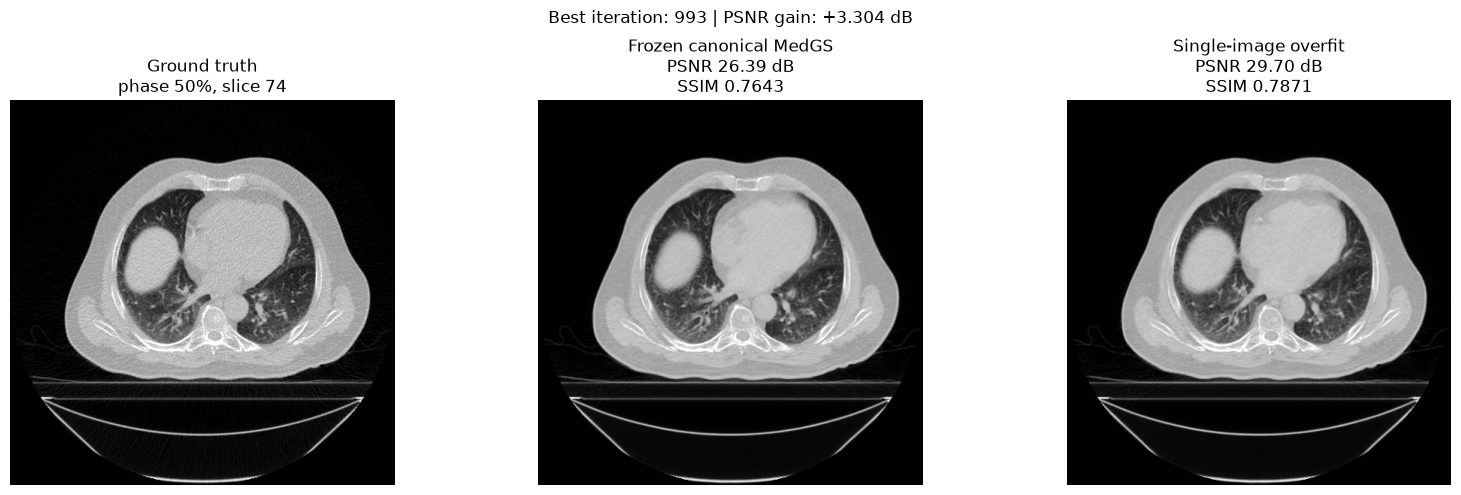

Single-pair overfit completed.
Target: phase 50%, slice 74
Best iteration: 993
Baseline PSNR / SSIM: 26.3931 / 0.764325
Overfit PSNR / SSIM: 29.6975 / 0.787091
PSNR gain: +3.3044 dB
SSIM gain: +0.022766
Mean |delta x|: 0.00082652
Mean |delta z|: 0.00133774
Mean / P95 |delta m| in slices: 0.6882 / 2.0906
Elapsed time: 3.00 minutes
Configuration saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d_overfit/patient_117_HM10395__phase_50__slice_074__iter1000/overfit_config.json
History saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d_overfit/patient_117_HM10395__phase_50__slice_074__iter1000/overfit_history.csv
Best checkpoint saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d_overfit/patient_117_HM10395__phase_50__slice_074__iter1000/overfit_best_checkpoint.pth
Comparison image saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d_overfit/patient_117_HM10395__phase_50__slice_074

In [70]:
# Overfit one phase/slice pair to test deformation capacity and optimization.
# Train a fresh local MLP on phase 50%, slice 74 without regularization.
#
# Saves configuration, history, best checkpoint, and comparison image.


warnings.filterwarnings(
    "ignore",
    message=(
        r".*torch\.cpu\.amp\.autocast"
        r".*deprecated.*"
    ),
    category=FutureWarning,
    module=r"torch\.utils\.checkpoint",
)

OVERFIT_PHASE_PERCENT = 50
OVERFIT_RESPIRATORY_TIME = 0.5

OVERFIT_CANONICAL_PHASE_PERCENT = 20
OVERFIT_CANONICAL_RESPIRATORY_TIME = 0.2

OVERFIT_SLICE_INDEX = 74
OVERFIT_ITERATIONS = 1000
OVERFIT_LEARNING_RATE = 5e-4

OVERFIT_PHASE_ENCODING_FREQUENCIES = 2
OVERFIT_MLP_HIDDEN_DIM = 128
OVERFIT_MLP_HIDDEN_LAYERS = 3
OVERFIT_MLP_CHUNK_SIZE = 131_072

OVERFIT_LOG_EVERY = 100
OVERFIT_SEED = 42

OVERFIT_HU_WINDOW_LOW = -1000.0
OVERFIT_HU_WINDOW_HIGH = 400.0

OVERFIT_RAW_VOLUME_PATH = Path(
    "/home/jovyan/shared/mtm_medgs_stack/results/"
    "prepared_4d_patients/117_HM10395/"
    "study_831212264180/volumes/raw/phase_50.npy"
)

OVERFIT_RUN_ROOT = Path(
    "/home/jovyan/shared/mtm_medgs_stack/results/"
    "phase_conditioned_medgs4d_overfit/"
    "patient_117_HM10395"
    "__phase_50"
    "__slice_074"
    "__iter1000"
)

OVERFIT_RUN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

OVERFIT_CONFIG_PATH = (
        OVERFIT_RUN_ROOT
        / "overfit_config.json"
)

OVERFIT_HISTORY_PATH = (
        OVERFIT_RUN_ROOT
        / "overfit_history.csv"
)

OVERFIT_CHECKPOINT_PATH = (
        OVERFIT_RUN_ROOT
        / "overfit_best_checkpoint.pth"
)

OVERFIT_COMPARISON_PATH = (
        OVERFIT_RUN_ROOT
        / "overfit_comparison.png"
)

assert OVERFIT_RAW_VOLUME_PATH.is_file()

assert len(canonical_cameras) == 147

assert 0 <= OVERFIT_SLICE_INDEX < len(
    canonical_cameras
)

torch.manual_seed(
    OVERFIT_SEED
)

torch.cuda.manual_seed_all(
    OVERFIT_SEED
)

overfit_canonical_xyz = (
    canonical_gaussians
    .get_xyz
    .detach()
    .clone()
)

overfit_canonical_xz = (
    overfit_canonical_xyz[
        :,
        [0, -1],
    ]
)

overfit_canonical_m_logits = (
    canonical_gaussians
    .m
    .detach()
    .clone()
)

overfit_canonical_m = (
    canonical_gaussians
    .get_m
    .detach()
    .clone()
)

overfit_xz_mean = (
    overfit_canonical_xz.mean(
        dim=0,
        keepdim=True,
    )
)

overfit_xz_scale = (
    overfit_canonical_xz.std(
        dim=0,
        keepdim=True,
        unbiased=False,
    )
    .clamp_min(1e-6)
)

overfit_m_mean = (
    overfit_canonical_m.mean(
        dim=0,
        keepdim=True,
    )
)

overfit_m_scale = (
    overfit_canonical_m.std(
        dim=0,
        keepdim=True,
        unbiased=False,
    )
    .clamp_min(1e-6)
)

overfit_gaussian_inputs = torch.cat(
    [
        (
                overfit_canonical_xz
                - overfit_xz_mean
        )
        / overfit_xz_scale,
        (
                overfit_canonical_m
                - overfit_m_mean
        )
        / overfit_m_scale,
    ],
    dim=-1,
).detach()


def overfit_encode_phase(
        respiratory_time: float,
) -> torch.Tensor:
    """Encode one respiratory phase cyclically."""

    tau = torch.tensor(
        respiratory_time,
        device=overfit_canonical_xyz.device,
        dtype=overfit_canonical_xyz.dtype,
    )

    frequencies = (
            2.0
            ** torch.arange(
        OVERFIT_PHASE_ENCODING_FREQUENCIES,
        device=overfit_canonical_xyz.device,
        dtype=overfit_canonical_xyz.dtype,
    )
    )

    angles = (
            2.0
            * torch.pi
            * torch.remainder(
        tau,
        1.0,
    )
            * frequencies
    )

    return torch.stack(
        [
            torch.sin(angles),
            torch.cos(angles),
        ],
        dim=-1,
    ).flatten()


OVERFIT_MLP_INPUT_DIM = (
        overfit_gaussian_inputs.shape[1]
        + overfit_encode_phase(
    OVERFIT_RESPIRATORY_TIME
).numel()
)


class OverfitDeformationMLP(nn.Module):
    """Predict x, z, and m-logit residuals."""

    def __init__(self) -> None:
        super().__init__()

        layers = []
        current_dim = OVERFIT_MLP_INPUT_DIM

        for _ in range(
                OVERFIT_MLP_HIDDEN_LAYERS
        ):
            layers.extend(
                [
                    nn.Linear(
                        current_dim,
                        OVERFIT_MLP_HIDDEN_DIM,
                    ),
                    nn.SiLU(),
                ]
            )

            current_dim = (
                OVERFIT_MLP_HIDDEN_DIM
            )

        self.backbone = nn.Sequential(
            *layers
        )

        self.output_layer = nn.Linear(
            current_dim,
            3,
        )

        nn.init.zeros_(
            self.output_layer.weight
        )

        nn.init.zeros_(
            self.output_layer.bias
        )

    def forward(
            self,
            inputs: torch.Tensor,
    ) -> torch.Tensor:
        return self.output_layer(
            self.backbone(
                inputs
            )
        )


overfit_mlp = (
    OverfitDeformationMLP()
    .to(
        device=overfit_canonical_xyz.device,
        dtype=overfit_canonical_xyz.dtype,
    )
)


def overfit_build_mlp_inputs(
        gaussian_inputs: torch.Tensor,
        respiratory_time: float,
) -> torch.Tensor:
    """Append one phase encoding to Gaussian inputs."""

    phase_encoding = (
        overfit_encode_phase(
            respiratory_time
        )
    )

    phase_features = (
        phase_encoding
        .unsqueeze(0)
        .expand(
            gaussian_inputs.shape[0],
            -1,
        )
    )

    return torch.cat(
        [
            gaussian_inputs,
            phase_features,
        ],
        dim=-1,
    )


def overfit_predict_relative_deformation(
        respiratory_time: float,
        use_checkpointing: bool,
) -> torch.Tensor:
    """Predict deformation relative to phase 20%."""

    output_chunks = []

    for start in range(
            0,
            overfit_gaussian_inputs.shape[0],
            OVERFIT_MLP_CHUNK_SIZE,
    ):
        end = min(
            start
            + OVERFIT_MLP_CHUNK_SIZE,
            overfit_gaussian_inputs.shape[0],
        )

        spatial_chunk = (
            overfit_gaussian_inputs[
                start:end
            ]
        )

        selected_inputs = (
            overfit_build_mlp_inputs(
                spatial_chunk,
                respiratory_time,
            )
        )

        canonical_inputs = (
            overfit_build_mlp_inputs(
                spatial_chunk,
                OVERFIT_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_inputs = torch.cat(
            [
                selected_inputs,
                canonical_inputs,
            ],
            dim=0,
        )

        if use_checkpointing:
            joint_outputs = checkpoint(
                overfit_mlp,
                joint_inputs,
                use_reentrant=False,
            )
        else:
            joint_outputs = overfit_mlp(
                joint_inputs
            )

        chunk_count = (
            spatial_chunk.shape[0]
        )

        output_chunks.append(
            joint_outputs[
                :chunk_count
            ]
            - joint_outputs[
                chunk_count:
            ]
        )

    return torch.cat(
        output_chunks,
        dim=0,
    )


class OverfitGaussianView:
    """Override dynamic xyz and m while forwarding fixed parameters."""

    def __init__(
            self,
            dynamic_xyz: torch.Tensor,
            dynamic_m: torch.Tensor,
    ) -> None:
        self._dynamic_xyz = dynamic_xyz
        self._dynamic_m = dynamic_m

    @property
    def get_xyz(self) -> torch.Tensor:
        return self._dynamic_xyz

    @property
    def get_m(self) -> torch.Tensor:
        return self._dynamic_m

    def __getattr__(
            self,
            name: str,
    ):
        return getattr(
            canonical_gaussians,
            name,
        )


def overfit_build_gaussian_view(
        use_checkpointing: bool,
) -> tuple[
    OverfitGaussianView,
    dict[str, torch.Tensor],
]:
    """Build the deformed Gaussian representation."""

    deformation = (
        overfit_predict_relative_deformation(
            respiratory_time=(
                OVERFIT_RESPIRATORY_TIME
            ),
            use_checkpointing=(
                use_checkpointing
            ),
        )
    )

    delta_xz = deformation[:, :2]
    delta_m_logit = deformation[:, 2:3]

    dynamic_xz = (
            overfit_canonical_xz
            + delta_xz
    )

    dynamic_m = torch.sigmoid(
        overfit_canonical_m_logits
        + delta_m_logit
    )

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[:, 0],
            overfit_canonical_xyz[:, 1],
            dynamic_xz[:, 1],
        ],
        dim=-1,
    )

    state = {
        "delta_xz": delta_xz,
        "delta_m_logit": (
            delta_m_logit
        ),
        "delta_m": (
                dynamic_m
                - overfit_canonical_m
        ),
        "dynamic_xyz": dynamic_xyz,
        "dynamic_m": dynamic_m,
    }

    return (
        OverfitGaussianView(
            dynamic_xyz=dynamic_xyz,
            dynamic_m=dynamic_m,
        ),
        state,
    )


def overfit_preprocess_ct_slice(
        raw_slice: np.ndarray,
) -> np.ndarray:
    """Apply the verified CT window and uint8 rounding."""

    normalized = np.clip(
        (
                raw_slice.astype(
                    np.float32
                )
                - OVERFIT_HU_WINDOW_LOW
        )
        / (
                OVERFIT_HU_WINDOW_HIGH
                - OVERFIT_HU_WINDOW_LOW
        ),
        0.0,
        1.0,
    )

    return (
            np.rint(
                normalized * 255.0
            )
            .clip(
                0.0,
                255.0,
            )
            .astype(
                np.uint8
            )
            .astype(
                np.float32
            )
            / 255.0
    )


overfit_raw_volume = np.load(
    OVERFIT_RAW_VOLUME_PATH,
    mmap_mode="r",
)

overfit_raw_slice = np.array(
    overfit_raw_volume[
        OVERFIT_SLICE_INDEX
    ],
    dtype=np.float32,
    copy=True,
)

overfit_target_array = (
    overfit_preprocess_ct_slice(
        overfit_raw_slice
    )
)

overfit_target = (
    torch.from_numpy(
        np.ascontiguousarray(
            overfit_target_array
        )
    )
    .to(
        device=overfit_canonical_xyz.device,
        dtype=overfit_canonical_xyz.dtype,
    )
    .unsqueeze(0)
    .repeat(
        3,
        1,
        1,
    )
)

overfit_camera = canonical_cameras[
    OVERFIT_SLICE_INDEX
]


def overfit_metrics(
        rendered_image: torch.Tensor,
) -> dict[str, float]:
    """Calculate metrics against the fixed target."""

    difference = (
            rendered_image
            - overfit_target
    )

    l1_value = (
        difference.abs().mean()
    )

    mse_value = (
        difference.square().mean()
    )

    psnr_value = (
            -10.0
            * torch.log10(
        mse_value.clamp_min(
            1e-12
        )
    )
    )

    ssim_value = ssim(
        rendered_image.unsqueeze(0),
        overfit_target.unsqueeze(0),
    )

    return {
        "L1": float(
            l1_value.item()
        ),
        "PSNR": float(
            psnr_value.item()
        ),
        "SSIM": float(
            ssim_value.item()
        ),
    }


with torch.no_grad():
    overfit_baseline_result = (
        medgs_render(
            overfit_camera,
            canonical_gaussians,
            canonical_pipeline,
            canonical_background,
        )
    )

    overfit_baseline_image = (
        overfit_baseline_result[
            "render"
        ]
        .detach()
        .clone()
    )

overfit_baseline_metrics = (
    overfit_metrics(
        overfit_baseline_image
    )
)

overfit_optimizer = torch.optim.Adam(
    overfit_mlp.parameters(),
    lr=OVERFIT_LEARNING_RATE,
)

overfit_config = {
    "phase_percent": (
        OVERFIT_PHASE_PERCENT
    ),
    "canonical_phase_percent": (
        OVERFIT_CANONICAL_PHASE_PERCENT
    ),
    "slice_index": (
        OVERFIT_SLICE_INDEX
    ),
    "iterations": (
        OVERFIT_ITERATIONS
    ),
    "learning_rate": (
        OVERFIT_LEARNING_RATE
    ),
    "hidden_dim": (
        OVERFIT_MLP_HIDDEN_DIM
    ),
    "hidden_layers": (
        OVERFIT_MLP_HIDDEN_LAYERS
    ),
    "phase_encoding_frequencies": (
        OVERFIT_PHASE_ENCODING_FREQUENCIES
    ),
    "loss": (
        "2.0 * L1 + 0.25 * (1 - SSIM)"
    ),
    "regularization": None,
    "raw_volume_path": str(
        OVERFIT_RAW_VOLUME_PATH
    ),
    "output_directory": str(
        OVERFIT_RUN_ROOT
    ),
}

OVERFIT_CONFIG_PATH.write_text(
    json.dumps(
        overfit_config,
        indent=2,
    ),
    encoding="utf-8",
)

overfit_history_rows = []

overfit_best_loss = float("inf")
overfit_best_iteration = 0
overfit_best_state_dict = None

overfit_mlp.train()

torch.cuda.reset_peak_memory_stats()

overfit_start_time = (
    time.perf_counter()
)

for iteration in range(
        1,
        OVERFIT_ITERATIONS + 1,
):
    overfit_optimizer.zero_grad(
        set_to_none=True
    )

    gaussian_view, deformation_state = (
        overfit_build_gaussian_view(
            use_checkpointing=True
        )
    )

    render_result = medgs_render(
        overfit_camera,
        gaussian_view,
        canonical_pipeline,
        canonical_background,
        train=True,
        iter=iteration,
    )

    rendered_image = (
        render_result["render"]
    )

    l1_value = l1_loss(
        rendered_image.unsqueeze(0),
        overfit_target.unsqueeze(0),
    )

    ssim_value = ssim(
        rendered_image.unsqueeze(0),
        overfit_target.unsqueeze(0),
    )

    total_loss = (
            2.0 * l1_value
            + 0.25
            * (
                    1.0 - ssim_value
            )
    )

    current_loss = float(
        total_loss.detach().item()
    )

    if current_loss < overfit_best_loss:
        overfit_best_loss = current_loss
        overfit_best_iteration = iteration

        overfit_best_state_dict = (
            copy.deepcopy(
                overfit_mlp.state_dict()
            )
        )

    total_loss.backward()

    gradient_norm = float(
        torch.nn.utils.clip_grad_norm_(
            overfit_mlp.parameters(),
            max_norm=10.0,
        ).item()
    )

    overfit_optimizer.step()

    current_metrics = overfit_metrics(
        rendered_image.detach()
    )

    elapsed_seconds = (
            time.perf_counter()
            - overfit_start_time
    )

    overfit_history_rows.append(
        {
            "Iteration": iteration,
            "TotalLoss": current_loss,
            "L1": current_metrics["L1"],
            "PSNR": current_metrics["PSNR"],
            "SSIM": current_metrics["SSIM"],
            "GradientNorm": gradient_norm,
            "ElapsedSeconds": (
                elapsed_seconds
            ),
            "PeakGpuMemoryGB": (
                    torch.cuda
                    .max_memory_allocated()
                    / 1024 ** 3
            ),
        }
    )

    if (
            iteration % OVERFIT_LOG_EVERY
            == 0
            or iteration == 1
    ):
        print(
            f"Iteration "
            f"{iteration:04d}/"
            f"{OVERFIT_ITERATIONS:04d} | "
            f"loss={current_loss:.6f} | "
            f"PSNR="
            f"{current_metrics['PSNR']:.3f} | "
            f"SSIM="
            f"{current_metrics['SSIM']:.5f} | "
            f"grad={gradient_norm:.3e}"
        )

        pd.DataFrame(
            overfit_history_rows
        ).to_csv(
            OVERFIT_HISTORY_PATH,
            index=False,
        )

    del gaussian_view
    del deformation_state
    del render_result
    del rendered_image
    del total_loss
    del l1_value
    del ssim_value

pd.DataFrame(
    overfit_history_rows
).to_csv(
    OVERFIT_HISTORY_PATH,
    index=False,
)

overfit_mlp.load_state_dict(
    overfit_best_state_dict
)

overfit_mlp.eval()

torch.save(
    {
        "iteration": (
            overfit_best_iteration
        ),
        "model_state_dict": (
            overfit_mlp.state_dict()
        ),
        "optimizer_state_dict": (
            overfit_optimizer.state_dict()
        ),
        "config": overfit_config,
        "best_loss": overfit_best_loss,
    },
    OVERFIT_CHECKPOINT_PATH,
)

with torch.no_grad():
    best_gaussian_view, best_state = (
        overfit_build_gaussian_view(
            use_checkpointing=False
        )
    )

    best_render_result = medgs_render(
        overfit_camera,
        best_gaussian_view,
        canonical_pipeline,
        canonical_background,
    )

    overfit_best_image = (
        best_render_result[
            "render"
        ]
        .detach()
        .clone()
    )

overfit_best_metrics = (
    overfit_metrics(
        overfit_best_image
    )
)

delta_m_slices = (
        best_state["delta_m"]
        * len(canonical_cameras)
)

mean_abs_delta_x = float(
    best_state[
        "delta_xz"
    ][:, 0]
    .abs()
    .mean()
    .item()
)

mean_abs_delta_z = float(
    best_state[
        "delta_xz"
    ][:, 1]
    .abs()
    .mean()
    .item()
)

mean_abs_delta_m_slices = float(
    delta_m_slices
    .abs()
    .mean()
    .item()
)

p95_abs_delta_m_slices = float(
    torch.quantile(
        delta_m_slices
        .abs()
        .flatten(),
        0.95,
    ).item()
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

axes[0].imshow(
    overfit_target[0]
    .detach()
    .cpu()
    .numpy(),
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)

axes[0].set_title(
    "Ground truth\n"
    "phase 50%, slice 74"
)

axes[1].imshow(
    overfit_baseline_image[0]
    .detach()
    .cpu()
    .numpy(),
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)

axes[1].set_title(
    "Frozen canonical MedGS\n"
    f"PSNR "
    f"{overfit_baseline_metrics['PSNR']:.2f} dB\n"
    f"SSIM "
    f"{overfit_baseline_metrics['SSIM']:.4f}"
)

axes[2].imshow(
    overfit_best_image[0]
    .detach()
    .cpu()
    .numpy(),
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)

axes[2].set_title(
    "Single-image overfit\n"
    f"PSNR "
    f"{overfit_best_metrics['PSNR']:.2f} dB\n"
    f"SSIM "
    f"{overfit_best_metrics['SSIM']:.4f}"
)

for axis in axes:
    axis.axis("off")

figure.suptitle(
    f"Best iteration: "
    f"{overfit_best_iteration} | "
    f"PSNR gain: "
    f"{overfit_best_metrics['PSNR'] - overfit_baseline_metrics['PSNR']:+.3f} dB"
)

figure.tight_layout()

figure.savefig(
    OVERFIT_COMPARISON_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

overfit_elapsed_minutes = (
                                  time.perf_counter()
                                  - overfit_start_time
                          ) / 60.0

print("Single-pair overfit completed.")

print(
    f"Target: phase "
    f"{OVERFIT_PHASE_PERCENT}%, "
    f"slice {OVERFIT_SLICE_INDEX}"
)

print(
    f"Best iteration: "
    f"{overfit_best_iteration}"
)

print(
    "Baseline PSNR / SSIM: "
    f"{overfit_baseline_metrics['PSNR']:.4f} / "
    f"{overfit_baseline_metrics['SSIM']:.6f}"
)

print(
    "Overfit PSNR / SSIM: "
    f"{overfit_best_metrics['PSNR']:.4f} / "
    f"{overfit_best_metrics['SSIM']:.6f}"
)

print(
    f"PSNR gain: "
    f"{overfit_best_metrics['PSNR'] - overfit_baseline_metrics['PSNR']:+.4f} dB"
)

print(
    f"SSIM gain: "
    f"{overfit_best_metrics['SSIM'] - overfit_baseline_metrics['SSIM']:+.6f}"
)

print(
    f"Mean |delta x|: "
    f"{mean_abs_delta_x:.8f}"
)

print(
    f"Mean |delta z|: "
    f"{mean_abs_delta_z:.8f}"
)

print(
    "Mean / P95 |delta m| in slices: "
    f"{mean_abs_delta_m_slices:.4f} / "
    f"{p95_abs_delta_m_slices:.4f}"
)

print(
    f"Elapsed time: "
    f"{overfit_elapsed_minutes:.2f} minutes"
)

print(
    f"Configuration saved to: "
    f"{OVERFIT_CONFIG_PATH}"
)

print(
    f"History saved to: "
    f"{OVERFIT_HISTORY_PATH}"
)

print(
    f"Best checkpoint saved to: "
    f"{OVERFIT_CHECKPOINT_PATH}"
)

print(
    f"Comparison image saved to: "
    f"{OVERFIT_COMPARISON_PATH}"
)

torch.cuda.empty_cache()

## Smoke test / pilot

In [71]:
# Configure the phase-conditioned MedGS4D experiment.
#
# This cell selects the raw MedGS model trained on respiratory phase 20%
# as the frozen canonical representation. It defines the respiratory phases,
# deformation-network architecture, optimization parameters, regularization
# weights, training length, checkpoint frequency, and output directories.
#
# Short and full training runs use separate output paths, so they cannot
# overwrite the canonical model or each other.

DYNAMIC_CANONICAL_PHASE_PERCENT = 20.0
DYNAMIC_PHASE_PERCENTS = tuple(
    float(phase)
    for phase in range(0, 100, 10)
)

CANONICAL_MODEL_ITERATION = 30_000

# Current short run.
# DYNAMIC_RUN_LABEL = "smoke"
DYNAMIC_RUN_LABEL = "pilot"
DYNAMIC_ITERATIONS = 5000
DYNAMIC_BATCH_SIZE = 1

# Overnight run:
# DYNAMIC_RUN_LABEL = "full"
# DYNAMIC_ITERATIONS = 30_000
# DYNAMIC_BATCH_SIZE = 3

DYNAMIC_PHASE_ENCODING_FREQUENCIES = 2

DYNAMIC_MLP_HIDDEN_DIM = 128
DYNAMIC_MLP_HIDDEN_LAYERS = 3

DYNAMIC_LEARNING_RATE = 1e-4

DYNAMIC_DEFORMATION_MAGNITUDE_WEIGHT = 1e-4
DYNAMIC_TEMPORAL_SMOOTHNESS_WEIGHT = 1e-3

DYNAMIC_LOG_EVERY = 25
DYNAMIC_CHECKPOINT_EVERY = 250

DYNAMIC_SEED = 42

RUN_DYNAMIC_TRAINING = True
REUSE_COMPLETED_DYNAMIC_MODEL = True

study_tag = str(STUDY_INSTANCE_UID)[-12:]
dynamic_canonical_phase_tag = phase_tag(
    DYNAMIC_CANONICAL_PHASE_PERCENT
)

canonical_raw_run_root = (
        RESULTS_ROOT
        / "canonical_medgs"
        / (
            f"patient_{PATIENT_ID}"
            f"__study_{study_tag}"
            f"__phase_{dynamic_canonical_phase_tag}"
            f"__raw"
            f"__poly{POLY_DEGREE}"
            f"__iter{CANONICAL_MODEL_ITERATION}"
        )
)

canonical_model_root = (
        canonical_raw_run_root
        / "model"
)

canonical_checkpoint_path = (
        canonical_model_root
        / f"chkpnt{CANONICAL_MODEL_ITERATION}.pth"
)

canonical_frame_manifest_path = (
        canonical_raw_run_root
        / "frame_manifest.csv"
)

assert canonical_checkpoint_path.is_file()
assert canonical_frame_manifest_path.is_file()

DYNAMIC_RESULTS_ROOT = (
        RESULTS_ROOT
        / "phase_conditioned_medgs4d"
)

dynamic_run_name = (
    f"patient_{PATIENT_ID}"
    f"__study_{study_tag}"
    f"__canonical_phase_{dynamic_canonical_phase_tag}_raw"
    f"__all_phases"
    f"__deform_xz_m"
    f"__{DYNAMIC_RUN_LABEL}"
    f"__iter{DYNAMIC_ITERATIONS}"
)

dynamic_run_root = (
        DYNAMIC_RESULTS_ROOT
        / dynamic_run_name
)

dynamic_checkpoint_root = (
        dynamic_run_root
        / "checkpoints"
)

dynamic_render_root = (
        dynamic_run_root
        / "renders"
)

dynamic_training_log_path = (
        dynamic_run_root
        / "training_log.csv"
)

dynamic_config_path = (
        dynamic_run_root
        / "run.json"
)

dynamic_run_root.mkdir(
    parents=True,
    exist_ok=True,
)

dynamic_checkpoint_root.mkdir(
    parents=True,
    exist_ok=True,
)

print("Phase-conditioned MedGS4D configuration")
print(f"Canonical checkpoint: {canonical_checkpoint_path}")
print(f"Training phases: {DYNAMIC_PHASE_PERCENTS}")
print(f"Dynamic iterations: {DYNAMIC_ITERATIONS}")
print(f"Batch size: {DYNAMIC_BATCH_SIZE}")
print(f"Dynamic run: {dynamic_run_root}")

Phase-conditioned MedGS4D configuration
Canonical checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model/chkpnt30000.pth
Training phases: (0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0)
Dynamic iterations: 5000
Batch size: 1
Dynamic run: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000


In [72]:
# Build a common phase-by-slice index for dynamic MedGS4D training.
#
# Each row identifies one raw CT target using two independent variables:
# respiratory phase and axial slice position. The respiratory phase controls
# Gaussian deformation, while the slice index is mapped to the corresponding
# camera from the canonical MedGS model.
#
# The cell verifies that all ten phases contain the same number of slices,
# use compatible slice coordinates, and have their raw volume files available.
# The resulting index and phase summary are saved with the dynamic experiment.

prepared_study_root = (
        PREPARED_4D_ROOT
        / PATIENT_ID
        / f"study_{study_tag}"
)

prepared_phase_manifest_path = (
        prepared_study_root
        / "phase_slice_manifest.csv"
)

prepared_phase_manifest_df = pd.read_csv(
    prepared_phase_manifest_path
)

canonical_frame_manifest_df = pd.read_csv(
    canonical_frame_manifest_path
)

dynamic_phase_index_df = (
    prepared_phase_manifest_df.loc[
        prepared_phase_manifest_df[
            "PhasePercent"
        ].astype(float).isin(
            DYNAMIC_PHASE_PERCENTS
        ),
        [
            "PhasePercent",
            "SliceIndex",
            "SliceCoordinate",
        ],
    ]
    .copy()
)

dynamic_phase_index_df["PhasePercent"] = (
    dynamic_phase_index_df[
        "PhasePercent"
    ].astype(float)
)

dynamic_phase_index_df["SliceIndex"] = (
    dynamic_phase_index_df[
        "SliceIndex"
    ].astype(int)
)

dynamic_phase_index_df["SliceCoordinate"] = (
    dynamic_phase_index_df[
        "SliceCoordinate"
    ].astype(float)
)

dynamic_phase_index_df["RespiratoryTime"] = (
        dynamic_phase_index_df["PhasePercent"]
        / 100.0
)

phase_index_by_percent = {
    phase_percent: phase_index
    for phase_index, phase_percent in enumerate(
        DYNAMIC_PHASE_PERCENTS
    )
}

dynamic_phase_index_df["PhaseIndex"] = (
    dynamic_phase_index_df[
        "PhasePercent"
    ].map(phase_index_by_percent)
)

canonical_camera_df = (
    canonical_frame_manifest_df[
        [
            "FrameIndex",
            "SliceIndex",
            "SliceCoordinate",
        ]
    ]
    .rename(
        columns={
            "FrameIndex": "CameraIndex",
            "SliceCoordinate": (
                "CanonicalSliceCoordinate"
            ),
        }
    )
)

canonical_camera_df["SliceIndex"] = (
    canonical_camera_df[
        "SliceIndex"
    ].astype(int)
)

dynamic_phase_index_df = (
    dynamic_phase_index_df.merge(
        canonical_camera_df,
        on="SliceIndex",
        how="left",
        validate="many_to_one",
    )
)

dynamic_phase_index_df["RawVolumePath"] = (
    dynamic_phase_index_df[
        "PhasePercent"
    ].map(
        lambda phase_percent: str(
            prepared_study_root
            / "volumes"
            / "raw"
            / (
                f"phase_"
                f"{phase_tag(phase_percent)}"
                f".npy"
            )
        )
    )
)

dynamic_phase_index_df["Split"] = "train"

dynamic_phase_index_df = (
    dynamic_phase_index_df.sort_values(
        [
            "PhasePercent",
            "SliceIndex",
        ]
    )
    .reset_index(drop=True)
)

phase_counts = (
    dynamic_phase_index_df.groupby(
        "PhasePercent"
    )
    .size()
)

expected_slices = len(
    canonical_frame_manifest_df
)

assert tuple(phase_counts.index) == (
    DYNAMIC_PHASE_PERCENTS
)

assert phase_counts.eq(
    expected_slices
).all()

assert dynamic_phase_index_df[
    "CameraIndex"
].notna().all()

assert np.allclose(
    dynamic_phase_index_df[
        "SliceCoordinate"
    ],
    dynamic_phase_index_df[
        "CanonicalSliceCoordinate"
    ],
    atol=1e-3,
)

assert dynamic_phase_index_df[
    "RawVolumePath"
].map(
    lambda path: Path(path).is_file()
).all()

for phase_percent in DYNAMIC_PHASE_PERCENTS:
    phase_rows = (
        dynamic_phase_index_df.loc[
            dynamic_phase_index_df[
                "PhasePercent"
            ]
            == phase_percent
            ]
        .sort_values("SliceIndex")
    )

    phase_volume = np.load(
        phase_rows[
            "RawVolumePath"
        ].iloc[0],
        mmap_mode="r",
    )

    assert phase_volume.shape[0] == expected_slices

dynamic_phase_summary_df = (
    dynamic_phase_index_df.groupby(
        [
            "PhaseIndex",
            "PhasePercent",
            "RespiratoryTime",
            "Split",
        ],
        as_index=False,
        sort=True,
    )
    .agg(
        Slices=("SliceIndex", "count"),
        FirstSliceCoordinate=(
            "SliceCoordinate",
            "min",
        ),
        LastSliceCoordinate=(
            "SliceCoordinate",
            "max",
        ),
        RawVolumePath=(
            "RawVolumePath",
            "first",
        ),
    )
)

dynamic_phase_index_path = (
        dynamic_run_root
        / "phase_slice_index.csv"
)

dynamic_phase_summary_path = (
        dynamic_run_root
        / "phase_summary.csv"
)

dynamic_phase_index_df.to_csv(
    dynamic_phase_index_path,
    index=False,
)

dynamic_phase_summary_df.to_csv(
    dynamic_phase_summary_path,
    index=False,
)

print(
    f"Dynamic index created: "
    f"{len(dynamic_phase_index_df)} rows, "
    f"{len(DYNAMIC_PHASE_PERCENTS)} phases, "
    f"{expected_slices} slices per phase."
)

print(
    f"Index saved to: "
    f"{dynamic_phase_index_path}"
)

display(dynamic_phase_summary_df)
display(dynamic_phase_index_df.head())

Dynamic index created: 1470 rows, 10 phases, 147 slices per phase.
Index saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/phase_slice_index.csv


,PhaseIndex,PhasePercent,RespiratoryTime,Split,Slices,FirstSliceCoordinate,LastSliceCoordinate,RawVolumePath
0,0,0.0,0.0,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy
1,1,10.0,0.1,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_10...
2,2,20.0,0.2,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_20...
3,3,30.0,0.3,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_30...
4,4,40.0,0.4,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_40...
5,5,50.0,0.5,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_50...
6,6,60.0,0.6,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_60...
7,7,70.0,0.7,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_70...
8,8,80.0,0.8,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_80...
9,9,90.0,0.9,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_90...


,PhasePercent,SliceIndex,SliceCoordinate,RespiratoryTime,PhaseIndex,CameraIndex,CanonicalSliceCoordinate,RawVolumePath,Split
0,0.0,0,-266.2,0.0,0,0,-266.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train
1,0.0,1,-263.2,0.0,0,1,-263.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train
2,0.0,2,-260.2,0.0,0,2,-260.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train
3,0.0,3,-257.2,0.0,0,3,-257.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train
4,0.0,4,-254.2,0.0,0,4,-254.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train


In [73]:
# Load and freeze the raw phase-20 canonical MedGS model.
# Keep immutable xyz and slice-axis centers as the reference geometry
# for phase-dependent residual deformation.
#
# Reads the canonical checkpoint and camera configuration.
# Keeps the restored model in memory and writes no new files.


if str(MEDGS_REPOSITORY) not in sys.path:
    sys.path.insert(
        0,
        str(MEDGS_REPOSITORY),
    )

canonical_cfg_path = (
        canonical_model_root
        / "cfg_args"
)

canonical_cfg_text = canonical_cfg_path.read_text(
    encoding="utf-8"
)

canonical_dataset_args = eval(
    canonical_cfg_text,
    {
        "Namespace": Namespace,
        "__builtins__": {},
    },
)

canonical_dataset_root = (
        canonical_raw_run_root
        / "dataset"
)

canonical_dataset_args.source_path = str(
    canonical_dataset_root
)

canonical_dataset_args.model_path = str(
    canonical_model_root
)

canonical_dataset_args.gs_type = "gs"
canonical_dataset_args.camera = CAMERA
canonical_dataset_args.poly_degree = POLY_DEGREE
canonical_dataset_args.data_device = "cuda"

canonical_frame_count = len(
    list(
        (
                canonical_dataset_root
                / "original"
        ).glob("*.png")
    )
)

assert canonical_frame_count == len(
    canonical_frame_manifest_df
)

(
    canonical_model_state,
    canonical_loaded_iteration,
) = torch.load(
    canonical_checkpoint_path,
    map_location="cuda",
)

assert int(canonical_loaded_iteration) == (
    CANONICAL_MODEL_ITERATION
)

canonical_gaussians = gaussianModel["gs"](
    canonical_dataset_args.sh_degree,
    canonical_dataset_args.poly_degree,
    canonical_frame_count,
    use_dff=False,
)

canonical_scene = Scene(
    canonical_dataset_args,
    canonical_gaussians,
    load_iteration=canonical_loaded_iteration,
    shuffle=False,
)

canonical_gaussians.restore(
    canonical_model_state,
    training_args=None,
    load_optimizer=False,
)

canonical_cameras = (
    canonical_scene.getTestCameras()
)

assert len(canonical_cameras) == (
    canonical_frame_count
)

canonical_parameter_names = (
    "_xyz",
    "_features_dc",
    "_features_rest",
    "_scaling",
    "_rotation",
    "_opacity",
    "m",
    "sigma",
    "_w1",
    "time_func",
)

for parameter_name in canonical_parameter_names:
    parameter = getattr(
        canonical_gaussians,
        parameter_name,
    )

    if isinstance(parameter, torch.Tensor):
        parameter.requires_grad_(False)

canonical_gaussians.optimizer = None

canonical_xyz = (
    canonical_gaussians
    .get_xyz
    .detach()
    .clone()
)

canonical_m_logits = (
    canonical_gaussians
    .m
    .detach()
    .clone()
)

canonical_m = (
    canonical_gaussians
    .get_m
    .detach()
    .clone()
)

canonical_pipeline = Namespace(
    convert_SHs_python=getattr(
        canonical_dataset_args,
        "convert_SHs_python",
        False,
    ),
    compute_cov3D_python=getattr(
        canonical_dataset_args,
        "compute_cov3D_python",
        False,
    ),
    debug=False,
    antialiasing=getattr(
        canonical_dataset_args,
        "antialiasing",
        False,
    ),
)

canonical_background = torch.tensor(
    (
        [1.0, 1.0, 1.0]
        if canonical_dataset_args.white_background
        else [0.0, 0.0, 0.0]
    ),
    dtype=torch.float32,
    device="cuda",
)

canonical_trainable_tensors = [
    parameter_name
    for parameter_name in canonical_parameter_names
    if (
            isinstance(
                getattr(
                    canonical_gaussians,
                    parameter_name,
                ),
                torch.Tensor,
            )
            and getattr(
        canonical_gaussians,
        parameter_name,
    ).requires_grad
    )
]

assert not canonical_trainable_tensors
assert canonical_xyz.shape[0] == (
    canonical_m.shape[0]
)

print("Canonical raw MedGS model loaded and frozen.")
print(
    f"Checkpoint iteration: "
    f"{canonical_loaded_iteration}"
)
print(
    f"Canonical Gaussians: "
    f"{canonical_xyz.shape[0]:,}"
)
print(
    f"Canonical cameras: "
    f"{len(canonical_cameras)}"
)
print(
    f"xyz shape: "
    f"{tuple(canonical_xyz.shape)}"
)
print(
    f"m shape: "
    f"{tuple(canonical_m.shape)}"
)
print(
    f"Polynomial weights shape: "
    f"{tuple(canonical_gaussians._w1.shape)}"
)
print(
    "Trainable canonical tensors: "
    f"{canonical_trainable_tensors}"
)

/tmp/ipykernel_7670/2883460704.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ) = torch.load(


Distance: 1.0
Loading trained model at iteration 30000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Canonical raw MedGS model loaded and frozen.
Checkpoint iteration: 30000
Canonical Gaussians: 1,410,016
Canonical cameras: 147
xyz shape: (1410016, 3)
m shape: (1410016, 1)
Polynomial weights shape: (1410016, 4)
Trainable canonical tensors: []


In [74]:
# Normalize the canonical x, z, and activated m coordinates used by MedGS.
# Encode the respiratory phase with cyclic sine/cosine features.
#
# Writes deformation_input_normalization.json with the input statistics.

canonical_xz = (
    canonical_xyz[:, [0, -1]]
    .detach()
    .clone()
)

canonical_xz_mean = canonical_xz.mean(
    dim=0,
    keepdim=True,
)

canonical_xz_scale = canonical_xz.std(
    dim=0,
    keepdim=True,
    unbiased=False,
).clamp_min(1e-6)

canonical_m_mean = canonical_m.mean(
    dim=0,
    keepdim=True,
)

canonical_m_scale = canonical_m.std(
    dim=0,
    keepdim=True,
    unbiased=False,
).clamp_min(1e-6)

canonical_xz_normalized = (
                                  canonical_xz - canonical_xz_mean
                          ) / canonical_xz_scale

canonical_m_normalized = (
                                 canonical_m - canonical_m_mean
                         ) / canonical_m_scale

canonical_deformation_inputs = torch.cat(
    [
        canonical_xz_normalized,
        canonical_m_normalized,
    ],
    dim=-1,
).detach()


def encode_respiratory_phase(
        respiratory_time: float | torch.Tensor,
) -> torch.Tensor:
    """Encode normalized respiratory phase with cyclic features."""

    tau = torch.as_tensor(
        respiratory_time,
        dtype=canonical_xyz.dtype,
        device=canonical_xyz.device,
    )

    tau = torch.remainder(
        tau,
        1.0,
    )

    frequencies = 2.0 ** torch.arange(
        DYNAMIC_PHASE_ENCODING_FREQUENCIES,
        dtype=canonical_xyz.dtype,
        device=canonical_xyz.device,
    )

    angles = (
            2.0
            * torch.pi
            * tau.unsqueeze(-1)
            * frequencies
    )

    return torch.stack(
        [
            torch.sin(angles),
            torch.cos(angles),
        ],
        dim=-1,
    ).flatten(
        start_dim=-2,
    )


phase_encoding_rows = []

for phase_percent in DYNAMIC_PHASE_PERCENTS:
    respiratory_time = phase_percent / 100.0

    encoding = encode_respiratory_phase(
        respiratory_time
    )

    phase_encoding_rows.append(
        {
            "PhasePercent": phase_percent,
            "RespiratoryTime": respiratory_time,
            **{
                f"Encoding_{index}": value
                for index, value in enumerate(
                    encoding.detach().cpu().tolist()
                )
            },
        }
    )

phase_encoding_df = pd.DataFrame(
    phase_encoding_rows
)

encoding_at_zero = encode_respiratory_phase(
    0.0
)

encoding_at_cycle_end = encode_respiratory_phase(
    1.0
)

canonical_phase_encoding = (
    encode_respiratory_phase(
        DYNAMIC_CANONICAL_PHASE_PERCENT
        / 100.0
    )
)

assert torch.allclose(
    encoding_at_zero,
    encoding_at_cycle_end,
    atol=1e-6,
)

assert torch.isfinite(
    canonical_deformation_inputs
).all()

assert canonical_deformation_inputs.shape == (
    canonical_xyz.shape[0],
    3,
)

normalization_config = {
    "canonical_phase_percent": (
        DYNAMIC_CANONICAL_PHASE_PERCENT
    ),
    "gaussian_input_coordinates": [
        "x",
        "z",
        "m",
    ],
    "phase_encoding_frequencies": (
        DYNAMIC_PHASE_ENCODING_FREQUENCIES
    ),
    "phase_encoding_dimension": int(
        canonical_phase_encoding.numel()
    ),
    "gaussian_input_dimension": int(
        canonical_deformation_inputs.shape[1]
    ),
    "mlp_input_dimension": int(
        canonical_deformation_inputs.shape[1]
        + canonical_phase_encoding.numel()
    ),
    "gaussian_count": int(
        canonical_deformation_inputs.shape[0]
    ),
    "xz_mean": (
        canonical_xz_mean
        .squeeze(0)
        .detach()
        .cpu()
        .tolist()
    ),
    "xz_scale": (
        canonical_xz_scale
        .squeeze(0)
        .detach()
        .cpu()
        .tolist()
    ),
    "m_mean": float(
        canonical_m_mean.item()
    ),
    "m_scale": float(
        canonical_m_scale.item()
    ),
}

normalization_config_path = (
        dynamic_run_root
        / "deformation_input_normalization.json"
)

normalization_config_path.write_text(
    json.dumps(
        normalization_config,
        indent=2,
    ),
    encoding="utf-8",
)

print("Canonical deformation inputs prepared.")
print(
    f"Gaussians: "
    f"{canonical_deformation_inputs.shape[0]:,}"
)
print(
    f"Gaussian input shape: "
    f"{tuple(canonical_deformation_inputs.shape)}"
)
print(
    f"Phase encoding dimension: "
    f"{canonical_phase_encoding.numel()}"
)
print(
    f"Total MLP input dimension: "
    f"{canonical_deformation_inputs.shape[1] + canonical_phase_encoding.numel()}"
)
print(
    f"Normalization saved to: "
    f"{normalization_config_path}"
)

display(phase_encoding_df)

Canonical deformation inputs prepared.
Gaussians: 1,410,016
Gaussian input shape: (1410016, 3)
Phase encoding dimension: 4
Total MLP input dimension: 7
Normalization saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/deformation_input_normalization.json


,PhasePercent,RespiratoryTime,Encoding_0,Encoding_1,Encoding_2,Encoding_3
0,0.0,0.0,0.000000e+00,1.000000,0.000000e+00,1.000000
1,10.0,0.1,5.877852e-01,0.809017,9.510565e-01,0.309017
2,20.0,0.2,9.510565e-01,0.309017,5.877852e-01,-0.809017
3,30.0,0.3,9.510565e-01,-0.309017,-5.877855e-01,-0.809017
4,40.0,0.4,5.877852e-01,-0.809017,-9.510565e-01,0.309017
5,50.0,0.5,-8.742278e-08,-1.000000,1.748456e-07,1.000000
6,60.0,0.6,-5.877855e-01,-0.809017,9.510567e-01,0.309016
7,70.0,0.7,-9.510565e-01,-0.309017,5.877855e-01,-0.809017
8,80.0,0.8,-9.510565e-01,0.309017,-5.877855e-01,-0.809017
9,90.0,0.9,-5.877853e-01,0.809017,-9.510566e-01,0.309017


### Forward and backward flow

The canonical raw MedGS model remains frozen. For a selected respiratory phase `tau`, the deformation MLP predicts residual changes relative to the canonical phase 20%.

```text
canonical x, z, m
        │
        └── stop-gradient
                │
                ▼
      deformation MLP(x, z, m, tau)
                │
                ▼
       Delta x, Delta z, Delta m-logit
                │
                ▼
       temporary phase-dependent Gaussians
                │
                ▼
      MedGS polynomial and visibility model
                │
                ▼
      differentiable Gaussian rasterizer
                │
                ▼
         reconstructed CT slice

In [75]:
# Define the shared phase-conditioned deformation MLP.
# Combine normalized x, z, m coordinates with cyclic phase features and
# predict residual x, z, and m-logit offsets for every canonical Gaussian.
#
# Initializes zero deformation, keeps the network in GPU memory,
# and writes no files.


DYNAMIC_GAUSSIAN_INPUT_DIM = int(
    canonical_deformation_inputs.shape[1]
)

DYNAMIC_PHASE_INPUT_DIM = int(
    canonical_phase_encoding.numel()
)

DYNAMIC_MLP_INPUT_DIM = (
        DYNAMIC_GAUSSIAN_INPUT_DIM
        + DYNAMIC_PHASE_INPUT_DIM
)

DYNAMIC_MLP_OUTPUT_DIM = 3

DYNAMIC_OUTPUT_NAMES = (
    "delta_x",
    "delta_z",
    "delta_m_logit",
)


class PhaseConditionedDeformationMLP(nn.Module):
    """Predict phase-dependent residuals for canonical MedGS Gaussians."""

    def __init__(
            self,
            input_dim: int,
            hidden_dim: int,
            hidden_layers: int,
            output_dim: int,
    ) -> None:
        super().__init__()

        layers = []

        current_dim = input_dim

        for _ in range(hidden_layers):
            layers.extend(
                [
                    nn.Linear(
                        current_dim,
                        hidden_dim,
                    ),
                    nn.SiLU(),
                ]
            )

            current_dim = hidden_dim

        self.backbone = nn.Sequential(
            *layers
        )

        self.output_layer = nn.Linear(
            current_dim,
            output_dim,
        )

        nn.init.zeros_(
            self.output_layer.weight
        )

        nn.init.zeros_(
            self.output_layer.bias
        )

    def forward(
            self,
            inputs: torch.Tensor,
    ) -> torch.Tensor:
        hidden = self.backbone(
            inputs
        )

        return self.output_layer(
            hidden
        )


def build_deformation_mlp_inputs(
        gaussian_inputs: torch.Tensor,
        respiratory_time: float | torch.Tensor,
) -> torch.Tensor:
    """Combine per-Gaussian coordinates with one respiratory encoding."""

    phase_encoding = encode_respiratory_phase(
        respiratory_time
    )

    phase_features = phase_encoding.unsqueeze(
        0
    ).expand(
        gaussian_inputs.shape[0],
        -1,
    )

    return torch.cat(
        [
            gaussian_inputs,
            phase_features,
        ],
        dim=-1,
    )


torch.manual_seed(
    DYNAMIC_SEED
)

torch.cuda.manual_seed_all(
    DYNAMIC_SEED
)

deformation_mlp = (
    PhaseConditionedDeformationMLP(
        input_dim=DYNAMIC_MLP_INPUT_DIM,
        hidden_dim=DYNAMIC_MLP_HIDDEN_DIM,
        hidden_layers=DYNAMIC_MLP_HIDDEN_LAYERS,
        output_dim=DYNAMIC_MLP_OUTPUT_DIM,
    )
    .to(
        device=canonical_xyz.device,
        dtype=canonical_xyz.dtype,
    )
)

deformation_parameter_count = sum(
    parameter.numel()
    for parameter in deformation_mlp.parameters()
)

deformation_trainable_parameter_count = sum(
    parameter.numel()
    for parameter in deformation_mlp.parameters()
    if parameter.requires_grad
)

sample_gaussian_count = min(
    4096,
    canonical_deformation_inputs.shape[0],
)

sample_mlp_inputs = build_deformation_mlp_inputs(
    canonical_deformation_inputs[
        :sample_gaussian_count
    ],
    respiratory_time=0.5,
)

with torch.no_grad():
    initial_sample_output = deformation_mlp(
        sample_mlp_inputs
    )

assert sample_mlp_inputs.shape == (
    sample_gaussian_count,
    DYNAMIC_MLP_INPUT_DIM,
)

assert initial_sample_output.shape == (
    sample_gaussian_count,
    DYNAMIC_MLP_OUTPUT_DIM,
)

assert torch.count_nonzero(
    initial_sample_output
).item() == 0

print("Phase-conditioned deformation MLP created.")
print(
    f"Architecture: "
    f"{DYNAMIC_MLP_INPUT_DIM} inputs, "
    f"{DYNAMIC_MLP_HIDDEN_LAYERS} hidden layers, "
    f"{DYNAMIC_MLP_HIDDEN_DIM} hidden units, "
    f"{DYNAMIC_MLP_OUTPUT_DIM} outputs"
)
print(
    f"Output fields: "
    f"{DYNAMIC_OUTPUT_NAMES}"
)
print(
    f"Trainable parameters: "
    f"{deformation_trainable_parameter_count:,}"
)
print(
    f"Initial maximum absolute output: "
    f"{initial_sample_output.abs().max().item():.6f}"
)

Phase-conditioned deformation MLP created.
Architecture: 7 inputs, 3 hidden layers, 128 hidden units, 3 outputs
Output fields: ('delta_x', 'delta_z', 'delta_m_logit')
Trainable parameters: 34,435
Initial maximum absolute output: 0.000000


In [76]:
# Convert MLP predictions into phase-relative Gaussian parameters.
# Subtract the phase-20 prediction to guarantee zero canonical deformation,
# then build temporary x/z positions and sigmoid-activated m centers.
#
# Uses chunked checkpointed MLP evaluation, keeps results in memory,
# and writes no files.


DYNAMIC_CANONICAL_RESPIRATORY_TIME = (
        DYNAMIC_CANONICAL_PHASE_PERCENT
        / 100.0
)

DYNAMIC_MLP_CHUNK_SIZE = 131_072


def predict_relative_deformation(
        respiratory_time: float | torch.Tensor,
        gaussian_inputs: torch.Tensor,
        chunk_size: int = DYNAMIC_MLP_CHUNK_SIZE,
) -> torch.Tensor:
    """Predict deformation relative to the canonical respiratory phase."""

    deformation_chunks = []

    for start in range(
            0,
            gaussian_inputs.shape[0],
            chunk_size,
    ):
        end = min(
            start + chunk_size,
            gaussian_inputs.shape[0],
        )

        spatial_chunk = gaussian_inputs[start:end]

        phase_inputs = build_deformation_mlp_inputs(
            spatial_chunk,
            respiratory_time,
        )

        canonical_phase_inputs = (
            build_deformation_mlp_inputs(
                spatial_chunk,
                DYNAMIC_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_inputs = torch.cat(
            [
                phase_inputs,
                canonical_phase_inputs,
            ],
            dim=0,
        )

        joint_outputs = checkpoint(
            deformation_mlp,
            joint_inputs,
            use_reentrant=False,
        )

        current_count = spatial_chunk.shape[0]

        phase_outputs = joint_outputs[
            :current_count
        ]

        canonical_phase_outputs = joint_outputs[
            current_count:
        ]

        deformation_chunks.append(
            phase_outputs
            - canonical_phase_outputs
        )

    return torch.cat(
        deformation_chunks,
        dim=0,
    )


def build_phase_deformed_state(
        respiratory_time: float | torch.Tensor,
        gaussian_count: int | None = None,
) -> dict[str, torch.Tensor]:
    """Build temporary phase-dependent x, z, and m parameters."""

    if gaussian_count is None:
        gaussian_count = (
            canonical_deformation_inputs.shape[0]
        )

    gaussian_inputs = (
        canonical_deformation_inputs[
            :gaussian_count
        ]
    )

    deformation = predict_relative_deformation(
        respiratory_time,
        gaussian_inputs,
    )

    delta_xz = deformation[:, :2]
    delta_m_logit = deformation[:, 2:3]

    canonical_xz_subset = (
        canonical_xz[
            :gaussian_count
        ]
    )

    canonical_m_logits_subset = (
        canonical_m_logits[
            :gaussian_count
        ]
    )

    canonical_m_subset = (
        canonical_m[
            :gaussian_count
        ]
    )

    dynamic_xz = (
            canonical_xz_subset
            + delta_xz
    )

    dynamic_m_logits = (
            canonical_m_logits_subset
            + delta_m_logit
    )

    dynamic_m = torch.sigmoid(
        dynamic_m_logits
    )

    delta_m = (
            dynamic_m
            - canonical_m_subset
    )

    return {
        "dynamic_xz": dynamic_xz,
        "dynamic_m": dynamic_m,
        "dynamic_m_logits": dynamic_m_logits,
        "delta_xz": delta_xz,
        "delta_m": delta_m,
        "delta_m_logit": delta_m_logit,
    }


test_gaussian_count = min(
    4096,
    canonical_deformation_inputs.shape[0],
)

canonical_test_state = (
    build_phase_deformed_state(
        DYNAMIC_CANONICAL_RESPIRATORY_TIME,
        gaussian_count=test_gaussian_count,
    )
)

phase_50_test_state = (
    build_phase_deformed_state(
        0.5,
        gaussian_count=test_gaussian_count,
    )
)

assert canonical_test_state[
           "dynamic_xz"
       ].shape == (
           test_gaussian_count,
           2,
       )

assert canonical_test_state[
           "dynamic_m"
       ].shape == (
           test_gaussian_count,
           1,
       )

assert torch.count_nonzero(
    canonical_test_state["delta_xz"]
).item() == 0

assert torch.count_nonzero(
    canonical_test_state["delta_m_logit"]
).item() == 0

assert torch.all(
    canonical_test_state["dynamic_m"] > 0.0
)

assert torch.all(
    canonical_test_state["dynamic_m"] < 1.0
)

print(
    "Phase-dependent Gaussian state "
    "functions prepared."
)

print(
    f"Test Gaussians: "
    f"{test_gaussian_count:,}"
)

print(
    "Canonical phase maximum |delta xz|: "
    f"{canonical_test_state['delta_xz'].abs().max().item():.6f}"
)

print(
    "Canonical phase maximum |delta m-logit|: "
    f"{canonical_test_state['delta_m_logit'].abs().max().item():.6f}"
)

print(
    "Phase 50% initial maximum |delta xz|: "
    f"{phase_50_test_state['delta_xz'].abs().max().item():.6f}"
)

print(
    "Phase 50% initial maximum |delta m-logit|: "
    f"{phase_50_test_state['delta_m_logit'].abs().max().item():.6f}"
)

Phase-dependent Gaussian state functions prepared.
Test Gaussians: 4,096
Canonical phase maximum |delta xz|: 0.000000
Canonical phase maximum |delta m-logit|: 0.000000
Phase 50% initial maximum |delta xz|: 0.000000
Phase 50% initial maximum |delta m-logit|: 0.000000


### Phase-conditioned deformation

The frozen raw MedGS model trained at respiratory phase 20% provides the canonical Gaussian parameters.

For each Gaussian, the deformation MLP receives the normalized canonical coordinates `x`, `z`, and `m`, together with a cyclic encoding of respiratory phase `tau`. It predicts:

- `Delta x`;
- `Delta z`;
- `Delta m_logit`.

The deformation is defined relative to the canonical phase:

$$
\Delta_i(\tau)
=
f_\phi(q_i,\gamma(\tau))
-
f_\phi(q_i,\gamma(0.2)).
$$

Therefore:

$$
\Delta_i(0.2)=0.
$$

The temporary phase-dependent parameters are:

$$
x_i(\tau)=x_i^c+\Delta x_i(\tau),
$$

$$
z_i(\tau)=z_i^c+\Delta z_i(\tau),
$$

$$
m_i(\tau)
=
\operatorname{sigmoid}
\left(
\ell_{m,i}^c+\Delta\ell_{m,i}(\tau)
\right).
$$

The forward and backward flow is:

```text
frozen canonical x, z, m
          ↓ stop-gradient
deformation MLP conditioned on tau
          ↓
temporary x(tau), z(tau), m(tau)
          ↓
MedGS polynomial and visibility calculations
          ↓
differentiable Gaussian rasterizer
          ↓
reconstructed CT slice and image loss
          ↓
gradient updates only the deformation MLP
```


In [77]:
# Connect phase-dependent x, z, and m values to the existing MedGS renderer.
# A lightweight proxy overrides only get_xyz and get_m while forwarding all
# remaining Gaussian parameters to the frozen canonical model.
#
# Verifies the integration on one canonical-phase slice and writes no files.


class PhaseDeformedGaussianView:
    """Expose temporary geometry while forwarding fixed Gaussian parameters."""

    def __init__(
            self,
            canonical_model,
            dynamic_xyz: torch.Tensor,
            dynamic_m: torch.Tensor,
    ) -> None:
        self._canonical_model = canonical_model
        self._dynamic_xyz = dynamic_xyz
        self._dynamic_m = dynamic_m

    @property
    def get_xyz(self) -> torch.Tensor:
        return self._dynamic_xyz

    @property
    def get_m(self) -> torch.Tensor:
        return self._dynamic_m

    def __getattr__(self, name):
        return getattr(
            self._canonical_model,
            name,
        )


def build_phase_deformed_gaussian_view(
        respiratory_time: float | torch.Tensor,
) -> tuple[
    PhaseDeformedGaussianView,
    dict[str, torch.Tensor],
]:
    """Build a temporary Gaussian view for one respiratory phase."""

    deformed_state = build_phase_deformed_state(
        respiratory_time=respiratory_time,
    )

    dynamic_xz = deformed_state[
        "dynamic_xz"
    ]

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[:, 0],
            canonical_xyz[:, 1],
            dynamic_xz[:, 1],
        ],
        dim=-1,
    )

    deformed_view = PhaseDeformedGaussianView(
        canonical_model=canonical_gaussians,
        dynamic_xyz=dynamic_xyz,
        dynamic_m=deformed_state["dynamic_m"],
    )

    deformed_state["dynamic_xyz"] = dynamic_xyz

    return (
        deformed_view,
        deformed_state,
    )


def render_phase_deformed_slice(
        viewpoint_camera,
        respiratory_time: float | torch.Tensor,
        **render_kwargs,
) -> tuple[
    dict[str, torch.Tensor],
    dict[str, torch.Tensor],
]:
    """Render one CT slice using phase-dependent Gaussian geometry."""

    deformed_view, deformed_state = (
        build_phase_deformed_gaussian_view(
            respiratory_time=respiratory_time,
        )
    )

    render_result = medgs_render(
        viewpoint_camera,
        deformed_view,
        canonical_pipeline,
        canonical_background,
        **render_kwargs,
    )

    return (
        render_result,
        deformed_state,
    )


test_camera_index = (
        len(canonical_cameras)
        // 2
)

test_camera = canonical_cameras[
    test_camera_index
]

with torch.no_grad():
    canonical_render_result = medgs_render(
        test_camera,
        canonical_gaussians,
        canonical_pipeline,
        canonical_background,
    )

    deformed_render_result, deformed_test_state = (
        render_phase_deformed_slice(
            viewpoint_camera=test_camera,
            respiratory_time=(
                DYNAMIC_CANONICAL_RESPIRATORY_TIME
            ),
        )
    )

canonical_test_image = (
    canonical_render_result["render"]
)

deformed_test_image = (
    deformed_render_result["render"]
)

canonical_render_max_error = (
    canonical_test_image
    .sub(deformed_test_image)
    .abs()
    .max()
    .item()
)

canonical_render_mean_error = (
    canonical_test_image
    .sub(deformed_test_image)
    .abs()
    .mean()
    .item()
)

assert deformed_test_state[
           "dynamic_xyz"
       ].shape == canonical_xyz.shape

assert deformed_test_state[
           "dynamic_m"
       ].shape == canonical_m.shape

assert torch.allclose(
    canonical_test_image,
    deformed_test_image,
    atol=1e-6,
    rtol=1e-5,
)

print(
    "Phase-dependent Gaussian view connected "
    "to the MedGS renderer."
)

print(
    f"Test camera index: "
    f"{test_camera_index}"
)

print(
    f"Rendered image shape: "
    f"{tuple(deformed_test_image.shape)}"
)

print(
    "Canonical render maximum absolute error: "
    f"{canonical_render_max_error:.8f}"
)

print(
    "Canonical render mean absolute error: "
    f"{canonical_render_mean_error:.8f}"
)

del canonical_render_result
del deformed_render_result
del deformed_test_state
del canonical_test_image
del deformed_test_image

torch.cuda.empty_cache()

Phase-dependent Gaussian view connected to the MedGS renderer.
Test camera index: 73
Rendered image shape: (3, 512, 512)
Canonical render maximum absolute error: 0.00000000
Canonical render mean absolute error: 0.00000000


### Canonical anchoring and gradient test

The deformation is defined relative to the canonical respiratory phase 20%:

$$
\Delta_i(\tau)
=
f_\phi(q_i,\gamma(\tau))
-
f_\phi(q_i,\gamma(0.2)).
$$

At the canonical phase, both terms are identical:

$$
\Delta_i(0.2)
=
f_\phi(q_i,\gamma(0.2))
-
f_\phi(q_i,\gamma(0.2))
=
0.
$$

Therefore, phase 20% remains exactly undeformed even after training. Other phases may acquire positive or negative residuals.

The optimizer updates only the deformation MLP. The frozen canonical MedGS parameters are not included in Adam.

The image loss is:

$$
L_{\mathrm{image}}
=
2L_1
+
0.25(1-\mathrm{SSIM}).
$$

A small deformation-magnitude penalty discourages unnecessarily large motion:

$$
L
=
L_{\mathrm{image}}
+
\lambda_{\mathrm{mag}}L_{\mathrm{mag}}.
$$

The gradient test performs one forward and backward pass through the renderer and the deformation MLP, but it does not call `optimizer.step()`. It only verifies that the image loss produces a nonzero gradient for the MLP output layer.


In [78]:
# Prepare the optimizer, image loss, and deformation regularization.
# Run one backward pass through the renderer and deformation MLP to verify
# gradient flow without changing any model parameters.
#
# Writes no files and performs no optimizer step.


DYNAMIC_MAGNITUDE_WEIGHT = 1e-4
DYNAMIC_SMOOTHNESS_WEIGHT = 1e-3

deformation_optimizer = torch.optim.Adam(
    deformation_mlp.parameters(),
    lr=DYNAMIC_LEARNING_RATE,
)


def compute_dynamic_image_loss(
        rendered_image: torch.Tensor,
        target_image: torch.Tensor,
) -> dict[str, torch.Tensor]:
    """Compute the dynamic reconstruction image loss."""

    if rendered_image.ndim == 3:
        rendered_batch = rendered_image.unsqueeze(0)
    else:
        rendered_batch = rendered_image

    if target_image.ndim == 3:
        target_batch = target_image.unsqueeze(0)
    else:
        target_batch = target_image

    l1 = l1_loss(
        rendered_batch,
        target_batch,
    )

    ssim_loss = (
            1.0
            - ssim(
        rendered_batch,
        target_batch,
    )
    )

    image_loss = (
            2.0 * l1
            + 0.25 * ssim_loss
    )

    return {
        "image_loss": image_loss,
        "l1": l1,
        "ssim_loss": ssim_loss,
    }


def normalized_deformation(
        deformed_state: dict[str, torch.Tensor],
) -> torch.Tensor:
    """Express x, z, and effective m displacement in normalized units."""

    normalized_delta_xz = (
            deformed_state["delta_xz"]
            / canonical_xz_scale
    )

    normalized_delta_m = (
            deformed_state["delta_m"]
            / canonical_m_scale
    )

    return torch.cat(
        [
            normalized_delta_xz,
            normalized_delta_m,
        ],
        dim=-1,
    )


def compute_deformation_magnitude_loss(
        deformed_state: dict[str, torch.Tensor],
) -> torch.Tensor:
    """Penalize large respiratory deformations."""

    deformation = normalized_deformation(
        deformed_state
    )

    return deformation.square().mean()


def compute_temporal_smoothness_loss(
        first_state: dict[str, torch.Tensor],
        second_state: dict[str, torch.Tensor],
) -> torch.Tensor:
    """Penalize deformation changes between neighboring phases."""

    first_deformation = normalized_deformation(
        first_state
    )

    second_deformation = normalized_deformation(
        second_state
    )

    return (
            first_deformation
            - second_deformation
    ).square().mean()


deformation_mlp.train()

deformation_optimizer.zero_grad(
    set_to_none=True
)

gradient_test_render_result, gradient_test_state = (
    render_phase_deformed_slice(
        viewpoint_camera=test_camera,
        respiratory_time=0.5,
        train=True,
        iter=0,
    )
)

gradient_test_rendered = (
    gradient_test_render_result["render"]
)

gradient_test_target = (
    test_camera
    .get_image(
        canonical_background,
        False,
    )
    .to(
        device=canonical_xyz.device,
        dtype=canonical_xyz.dtype,
    )
    .detach()
)

gradient_test_losses = compute_dynamic_image_loss(
    rendered_image=gradient_test_rendered,
    target_image=gradient_test_target,
)

gradient_test_magnitude_loss = (
    compute_deformation_magnitude_loss(
        gradient_test_state
    )
)

gradient_test_total_loss = (
        gradient_test_losses["image_loss"]
        + DYNAMIC_MAGNITUDE_WEIGHT
        * gradient_test_magnitude_loss
)

gradient_test_total_loss.backward()

output_weight_gradient = (
    deformation_mlp
    .output_layer
    .weight
    .grad
)

output_bias_gradient = (
    deformation_mlp
    .output_layer
    .bias
    .grad
)

first_hidden_weight_gradient = (
    deformation_mlp
    .backbone[0]
    .weight
    .grad
)

output_weight_gradient_norm = (
    0.0
    if output_weight_gradient is None
    else output_weight_gradient.norm().item()
)

output_bias_gradient_norm = (
    0.0
    if output_bias_gradient is None
    else output_bias_gradient.norm().item()
)

first_hidden_gradient_norm = (
    0.0
    if first_hidden_weight_gradient is None
    else first_hidden_weight_gradient.norm().item()
)

assert torch.isfinite(
    gradient_test_total_loss
).item()

assert output_weight_gradient_norm > 0.0

print("Dynamic training losses and optimizer prepared.")

print(
    f"Optimizer: Adam, "
    f"learning rate: {DYNAMIC_LEARNING_RATE:.2e}"
)

print(
    f"Gradient-test image loss: "
    f"{gradient_test_losses['image_loss'].item():.8f}"
)

print(
    f"Gradient-test L1: "
    f"{gradient_test_losses['l1'].item():.8f}"
)

print(
    f"Gradient-test SSIM loss: "
    f"{gradient_test_losses['ssim_loss'].item():.8f}"
)

print(
    f"Initial deformation magnitude loss: "
    f"{gradient_test_magnitude_loss.item():.8f}"
)

print(
    f"Output-layer weight gradient norm: "
    f"{output_weight_gradient_norm:.8e}"
)

print(
    f"Output-layer bias gradient norm: "
    f"{output_bias_gradient_norm:.8e}"
)

print(
    f"First hidden-layer gradient norm: "
    f"{first_hidden_gradient_norm:.8e}"
)

print("No optimizer step was performed.")

deformation_optimizer.zero_grad(
    set_to_none=True
)

deformation_mlp.eval()

del gradient_test_render_result
del gradient_test_state
del gradient_test_rendered
del gradient_test_target
del gradient_test_losses
del gradient_test_magnitude_loss
del gradient_test_total_loss

torch.cuda.empty_cache()

Dynamic training losses and optimizer prepared.
Optimizer: Adam, learning rate: 1.00e-04
Gradient-test image loss: 0.03955271
Gradient-test L1: 0.01189460
Gradient-test SSIM loss: 0.06305408
Initial deformation magnitude loss: 0.00000000
Output-layer weight gradient norm: 7.83987284e-01
Output-layer bias gradient norm: 2.70029110e-09
First hidden-layer gradient norm: 0.00000000e+00
No optimizer step was performed.


In [79]:
# Inspect raw volume values and locate the prepared slice images used by MedGS.
# Compare the NumPy representation with the canonical camera target before
# choosing the exact target-loading and normalization procedure.
#
# Writes no files.


print("Phase index columns:")
for column in dynamic_phase_index_df.columns:
    print(f"  {column}")

print("\nPath-like columns and example values:")

path_like_columns = [
    column
    for column in dynamic_phase_index_df.columns
    if (
            "path" in column.lower()
            or "file" in column.lower()
            or "volume" in column.lower()
            or "image" in column.lower()
    )
]

for column in path_like_columns:
    non_null_values = (
        dynamic_phase_index_df[column]
        .dropna()
        .astype(str)
    )

    if len(non_null_values) == 0:
        continue

    example_path = Path(
        non_null_values.iloc[0]
    )

    image_suffix_count = sum(
        Path(value).suffix.lower()
        in {
            ".png",
            ".jpg",
            ".jpeg",
            ".tif",
            ".tiff",
            ".bmp",
        }
        for value in non_null_values
    )

    print(
        f"  {column}: "
        f"example={example_path}, "
        f"suffix={example_path.suffix}, "
        f"existing={example_path.exists()}, "
        f"image paths={image_suffix_count:,}"
    )

phase_20_rows = dynamic_phase_index_df.loc[
    dynamic_phase_index_df[
        "PhasePercent"
    ].eq(
        DYNAMIC_CANONICAL_PHASE_PERCENT
    )
]

raw_volume_columns = [
    column
    for column in path_like_columns
    if phase_20_rows[
        column
    ].astype(str).str.endswith(
        ".npy"
    ).all()
]

print("\nNumPy volume columns:")
for column in raw_volume_columns:
    print(f"  {column}")

phase_20_volume_path = Path(
    phase_20_rows[
        raw_volume_columns[0]
    ].iloc[0]
)

phase_20_volume = np.load(
    phase_20_volume_path,
    mmap_mode="r",
)

diagnostic_slice_index = (
        len(canonical_cameras)
        // 2
)

phase_20_slice = np.asarray(
    phase_20_volume[
        diagnostic_slice_index
    ]
)

phase_20_percentiles = np.percentile(
    phase_20_slice,
    [
        0,
        1,
        5,
        50,
        95,
        99,
        100,
    ],
)

canonical_camera_target = (
    canonical_cameras[
        diagnostic_slice_index
    ]
    .get_image(
        canonical_background,
        False,
    )
    .detach()
    .cpu()
)

print("\nRaw phase-20 volume:")
print(
    f"  path: {phase_20_volume_path}"
)
print(
    f"  shape: {phase_20_volume.shape}"
)
print(
    f"  dtype: {phase_20_volume.dtype}"
)
print(
    f"  volume minimum: "
    f"{float(np.min(phase_20_volume)):.6f}"
)
print(
    f"  volume maximum: "
    f"{float(np.max(phase_20_volume)):.6f}"
)

print(
    f"\nRaw slice {diagnostic_slice_index}:"
)
print(
    f"  shape: {phase_20_slice.shape}"
)
print(
    f"  minimum: "
    f"{float(phase_20_slice.min()):.6f}"
)
print(
    f"  maximum: "
    f"{float(phase_20_slice.max()):.6f}"
)
print(
    f"  mean: "
    f"{float(phase_20_slice.mean()):.6f}"
)
print(
    "  percentiles "
    "[0, 1, 5, 50, 95, 99, 100]:"
)
print(
    " ",
    [
        round(float(value), 6)
        for value in phase_20_percentiles
    ],
)

print("\nCanonical MedGS camera target:")
print(
    f"  shape: "
    f"{tuple(canonical_camera_target.shape)}"
)
print(
    f"  dtype: "
    f"{canonical_camera_target.dtype}"
)
print(
    f"  minimum: "
    f"{canonical_camera_target.min().item():.6f}"
)
print(
    f"  maximum: "
    f"{canonical_camera_target.max().item():.6f}"
)
print(
    f"  mean: "
    f"{canonical_camera_target.mean().item():.6f}"
)

prepared_study_root = (
    phase_20_volume_path.parents[2]
)

prepared_image_paths = []

for pattern in (
        "*.png",
        "*.jpg",
        "*.jpeg",
        "*.tif",
        "*.tiff",
        "*.bmp",
):
    prepared_image_paths.extend(
        prepared_study_root.rglob(
            pattern
        )
    )

prepared_image_paths = sorted(
    set(prepared_image_paths)
)

print("\nPrepared study root:")
print(
    f"  {prepared_study_root}"
)

print(
    f"Prepared image files found: "
    f"{len(prepared_image_paths):,}"
)

print("First prepared image paths:")

for image_path in prepared_image_paths[:20]:
    print(
        f"  {image_path.relative_to(prepared_study_root)}"
    )

del canonical_camera_target

Phase index columns:
  PhasePercent
  SliceIndex
  SliceCoordinate
  RespiratoryTime
  PhaseIndex
  CameraIndex
  CanonicalSliceCoordinate
  RawVolumePath
  Split

Path-like columns and example values:
  RawVolumePath: example=/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy, suffix=.npy, existing=True, image paths=0

NumPy volume columns:
  RawVolumePath

Raw phase-20 volume:
  path: /home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_20.npy
  shape: (147, 512, 512)
  dtype: float32
  volume minimum: -1000.000000
  volume maximum: 2976.000000

Raw slice 73:
  shape: (512, 512)
  minimum: -1000.000000
  maximum: 1020.000000
  mean: -659.749146
  percentiles [0, 1, 5, 50, 95, 99, 100]:
  [-1000.0, -1000.0, -1000.0, -956.0, 59.0, 227.0, 1020.0]

Canonical MedGS camera target:
  shape: (3, 512, 512)
  dtype: torch.float32
  minimum: 0.000000
  maximum: 1.000

In [80]:
# Evaluate candidate HU windows and 8-bit quantization methods.
# Compare transformed phase-20 slices with canonical MedGS camera images.
#
# Ranks candidates for manual inspection and writes no files.


phase_20_volume_path = Path(
    dynamic_phase_index_df.loc[
        dynamic_phase_index_df["PhasePercent"].eq(
            DYNAMIC_CANONICAL_PHASE_PERCENT
        ),
        "RawVolumePath",
    ].iloc[0]
)

phase_20_volume = np.load(
    phase_20_volume_path,
    mmap_mode="r",
)

validation_slice_indices = np.linspace(
    0,
    len(canonical_cameras) - 1,
    num=9,
    dtype=int,
).tolist()

raw_validation_slices = {
    slice_index: np.asarray(
        phase_20_volume[slice_index],
        dtype=np.float32,
    )
    for slice_index in validation_slice_indices
}

camera_validation_slices = {}

for slice_index in validation_slice_indices:
    camera_image = (
        canonical_cameras[slice_index]
        .get_image(
            canonical_background,
            False,
        )
        .detach()
        .cpu()
        .float()
    )

    assert camera_image.shape[0] == 3

    channel_difference = (
            camera_image
            - camera_image[0:1]
    ).abs().max().item()

    assert channel_difference < 1e-6

    camera_validation_slices[
        slice_index
    ] = camera_image[0].numpy()


def apply_hu_window(
        raw_slice: np.ndarray,
        window_low: float,
        window_high: float,
) -> np.ndarray:
    """Map one HU slice to the normalized interval [0, 1]."""

    assert window_high > window_low

    normalized = (
                         raw_slice - window_low
                 ) / (
                         window_high - window_low
                 )

    return np.clip(
        normalized,
        0.0,
        1.0,
    ).astype(
        np.float32,
        copy=False,
    )


def apply_quantization(
        normalized_slice: np.ndarray,
        method: str,
) -> np.ndarray:
    """Apply a possible image-export quantization method."""

    if method == "continuous":
        return normalized_slice

    scaled = normalized_slice * 255.0

    if method == "floor_uint8":
        quantized = np.floor(
            scaled
        )

    elif method == "round_uint8":
        quantized = np.rint(
            scaled
        )

    else:
        raise ValueError(
            f"Unknown quantization method: {method}"
        )

    return (
            np.clip(
                quantized,
                0.0,
                255.0,
            )
            / 255.0
    ).astype(
        np.float32,
        copy=False,
    )


def evaluate_target_transform(
        window_low: float,
        window_high: float,
        quantization: str,
) -> dict:
    """Compare one preprocessing candidate with canonical camera targets."""

    absolute_error_sum = 0.0
    squared_error_sum = 0.0
    pixel_count = 0

    foreground_error_sum = 0.0
    foreground_pixel_count = 0

    maximum_error = 0.0
    within_one_level_count = 0

    for slice_index in validation_slice_indices:
        raw_slice = raw_validation_slices[
            slice_index
        ]

        camera_slice = camera_validation_slices[
            slice_index
        ]

        candidate_slice = apply_hu_window(
            raw_slice,
            window_low=window_low,
            window_high=window_high,
        )

        candidate_slice = apply_quantization(
            candidate_slice,
            method=quantization,
        )

        absolute_error = np.abs(
            candidate_slice
            - camera_slice
        )

        absolute_error_sum += float(
            absolute_error.sum()
        )

        squared_error_sum += float(
            np.square(
                absolute_error
            ).sum()
        )

        pixel_count += int(
            absolute_error.size
        )

        maximum_error = max(
            maximum_error,
            float(
                absolute_error.max()
            ),
        )

        within_one_level_count += int(
            (
                    absolute_error
                    <= (
                            1.0 / 255.0
                            + 1e-7
                    )
            ).sum()
        )

        foreground_mask = (
                raw_slice > -900.0
        )

        foreground_error_sum += float(
            absolute_error[
                foreground_mask
            ].sum()
        )

        foreground_pixel_count += int(
            foreground_mask.sum()
        )

    return {
        "WindowLowHU": float(
            window_low
        ),
        "WindowHighHU": float(
            window_high
        ),
        "WindowCenterHU": float(
            (
                    window_low
                    + window_high
            )
            / 2.0
        ),
        "WindowWidthHU": float(
            window_high
            - window_low
        ),
        "Quantization": quantization,
        "MAE_AllPixels": (
                absolute_error_sum
                / pixel_count
        ),
        "RMSE_AllPixels": np.sqrt(
            squared_error_sum
            / pixel_count
        ),
        "MAE_Foreground": (
                foreground_error_sum
                / foreground_pixel_count
        ),
        "MaximumError": maximum_error,
        "FractionWithinOne8BitLevel": (
                within_one_level_count
                / pixel_count
        ),
    }


camera_grid_distance_sum = 0.0
camera_grid_value_count = 0
camera_grid_maximum_distance = 0.0

for camera_slice in (
        camera_validation_slices.values()
):
    scaled_camera = (
            camera_slice * 255.0
    )

    grid_distance = np.abs(
        scaled_camera
        - np.rint(
            scaled_camera
        )
    )

    camera_grid_distance_sum += float(
        grid_distance.sum()
    )

    camera_grid_value_count += int(
        grid_distance.size
    )

    camera_grid_maximum_distance = max(
        camera_grid_maximum_distance,
        float(
            grid_distance.max()
        ),
    )

candidate_window_lows = (
    -1200.0,
    -1100.0,
    -1024.0,
    -1000.0,
    -950.0,
    -900.0,
    -800.0,
    -700.0,
    -600.0,
    -500.0,
)

candidate_window_highs = (
    200.0,
    300.0,
    400.0,
    500.0,
    600.0,
    800.0,
    1000.0,
    1500.0,
    2000.0,
    3000.0,
)

continuous_window_rows = []

for window_low in candidate_window_lows:
    for window_high in candidate_window_highs:
        continuous_window_rows.append(
            evaluate_target_transform(
                window_low=window_low,
                window_high=window_high,
                quantization="continuous",
            )
        )

windowing_results_df = (
    pd.DataFrame(
        continuous_window_rows
    )
    .sort_values(
        [
            "MAE_AllPixels",
            "MAE_Foreground",
        ]
    )
    .reset_index(
        drop=True
    )
)

top_window_pairs = (
    windowing_results_df[
        [
            "WindowLowHU",
            "WindowHighHU",
        ]
    ]
    .head(12)
    .drop_duplicates()
)

quantization_rows = []

for _, row in top_window_pairs.iterrows():
    for quantization in (
            "continuous",
            "floor_uint8",
            "round_uint8",
    ):
        quantization_rows.append(
            evaluate_target_transform(
                window_low=float(
                    row["WindowLowHU"]
                ),
                window_high=float(
                    row["WindowHighHU"]
                ),
                quantization=quantization,
            )
        )

quantization_results_df = (
    pd.DataFrame(
        quantization_rows
    )
    .sort_values(
        [
            "MAE_AllPixels",
            "MAE_Foreground",
        ]
    )
    .reset_index(
        drop=True
    )
)

print("HU windowing diagnostics completed.")

print(
    f"Phase-20 volume: "
    f"{phase_20_volume_path}"
)

print(
    f"Validation slice indices: "
    f"{validation_slice_indices}"
)

print(
    "Camera distance from exact 8-bit grid:"
)

print(
    "  mean distance in 0-255 units: "
    f"{camera_grid_distance_sum / camera_grid_value_count:.8e}"
)

print(
    "  maximum distance in 0-255 units: "
    f"{camera_grid_maximum_distance:.8e}"
)

print(
    "\nTop continuous-window candidates:"
)

display(
    windowing_results_df.head(15)
)

print(
    "\nTop window and quantization combinations:"
)

display(
    quantization_results_df.head(20)
)

HU windowing diagnostics completed.
Phase-20 volume: /home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_20.npy
Validation slice indices: [0, 18, 36, 54, 73, 91, 109, 127, 146]
Camera distance from exact 8-bit grid:
  mean distance in 0-255 units: 0.00000000e+00
  maximum distance in 0-255 units: 0.00000000e+00

Top continuous-window candidates:


,WindowLowHU,WindowHighHU,WindowCenterHU,WindowWidthHU,Quantization,MAE_AllPixels,RMSE_AllPixels,MAE_Foreground,MaximumError,FractionWithinOne8BitLevel
0,-1000.0,400.0,-300.0,1400.0,continuous,0.000646,0.000919,0.000974,0.001961,1.000000
1,-950.0,400.0,-275.0,1350.0,continuous,0.011321,0.016283,0.014467,0.037211,0.393845
2,-1024.0,400.0,-312.0,1424.0,continuous,0.012924,0.014011,0.006594,0.018550,0.073924
3,-1000.0,500.0,-250.0,1500.0,continuous,0.015494,0.025990,0.040126,0.068078,0.607187
4,-1000.0,300.0,-350.0,1300.0,continuous,0.017749,0.029800,0.045945,0.072971,0.587104
5,-900.0,400.0,-250.0,1300.0,continuous,0.018198,0.026341,0.030051,0.072971,0.390322
6,-800.0,300.0,-250.0,1100.0,continuous,0.018880,0.034009,0.031879,0.144189,0.429406
7,-900.0,300.0,-300.0,1200.0,continuous,0.019996,0.028249,0.034871,0.072843,0.392147
8,-950.0,300.0,-325.0,1250.0,continuous,0.020040,0.027719,0.038073,0.072910,0.395771
9,-1024.0,500.0,-262.0,1524.0,continuous,0.022185,0.025706,0.034496,0.066945,0.021790



Top window and quantization combinations:


,WindowLowHU,WindowHighHU,WindowCenterHU,WindowWidthHU,Quantization,MAE_AllPixels,RMSE_AllPixels,MAE_Foreground,MaximumError,FractionWithinOne8BitLevel
0,-1000.0,400.0,-300.0,1400.0,round_uint8,0.000000,0.000000,0.000000,0.000000,1.000000
1,-1000.0,400.0,-300.0,1400.0,continuous,0.000646,0.000919,0.000974,0.001961,1.000000
2,-1000.0,400.0,-300.0,1400.0,floor_uint8,0.001229,0.002195,0.001929,0.003922,1.000000
3,-1024.0,400.0,-312.0,1424.0,floor_uint8,0.011241,0.012590,0.004670,0.015686,0.290460
4,-950.0,400.0,-275.0,1350.0,round_uint8,0.011318,0.016296,0.014456,0.035294,0.399601
5,-950.0,400.0,-275.0,1350.0,continuous,0.011321,0.016283,0.014467,0.037211,0.393845
6,-950.0,400.0,-275.0,1350.0,floor_uint8,0.012180,0.017271,0.016389,0.039216,0.393845
7,-1024.0,400.0,-312.0,1424.0,round_uint8,0.012528,0.013574,0.006597,0.019608,0.202352
8,-1024.0,400.0,-312.0,1424.0,continuous,0.012924,0.014011,0.006594,0.018550,0.073924
9,-1000.0,500.0,-250.0,1500.0,round_uint8,0.015412,0.026007,0.040125,0.066667,0.637818


In [81]:
# Define the verified CT windowing and target preprocessing explicitly.
# Prepare all phase/slice records and validate every canonical phase-20 target.
#
# Writes dynamic_target_preprocessing.json to the dynamic run directory.


DYNAMIC_RAW_VOLUME_PATH_COLUMN = "RawVolumePath"
DYNAMIC_CAMERA_INDEX_COLUMN = "CameraIndex"

DYNAMIC_HU_WINDOW_LOW = -1000.0
DYNAMIC_HU_WINDOW_HIGH = 400.0
DYNAMIC_HU_WINDOW_CENTER = -300.0
DYNAMIC_HU_WINDOW_WIDTH = 1400.0

DYNAMIC_TARGET_QUANTIZATION = "round_uint8"


@lru_cache(
    maxsize=len(DYNAMIC_PHASE_PERCENTS)
)
def load_dynamic_raw_volume(
        volume_path: str,
) -> np.ndarray:
    """Open one respiratory-phase CT volume as a memory-mapped array."""

    volume = np.load(
        volume_path,
        mmap_mode="r",
    )

    assert volume.shape == (
        len(canonical_cameras),
        512,
        512,
    )

    assert volume.dtype == np.float32

    return volume


def preprocess_dynamic_ct_slice(
        raw_slice: np.ndarray,
) -> np.ndarray:
    """Apply the verified HU window and round-to-uint8 conversion."""

    normalized = np.clip(
        (
                raw_slice.astype(np.float32)
                - DYNAMIC_HU_WINDOW_LOW
        )
        / (
                DYNAMIC_HU_WINDOW_HIGH
                - DYNAMIC_HU_WINDOW_LOW
        ),
        0.0,
        1.0,
    )

    quantized = np.rint(
        normalized * 255.0
    ).clip(
        0.0,
        255.0,
    ).astype(
        np.uint8
    )

    return (
            quantized.astype(np.float32)
            / 255.0
    )


dynamic_all_records = [
    {
        "phase_percent": int(
            row["PhasePercent"]
        ),
        "respiratory_time": float(
            row["RespiratoryTime"]
        ),
        "slice_index": int(
            row["SliceIndex"]
        ),
        "camera_index": int(
            row[DYNAMIC_CAMERA_INDEX_COLUMN]
        ),
        "slice_coordinate": float(
            row["SliceCoordinate"]
        ),
        "volume_path": Path(
            row[DYNAMIC_RAW_VOLUME_PATH_COLUMN]
        ),
    }
    for _, row in (
        dynamic_phase_index_df
        .sort_values(
            [
                "PhasePercent",
                DYNAMIC_CAMERA_INDEX_COLUMN,
            ]
        )
        .iterrows()
    )
]

dynamic_training_records = [
    record
    for record in dynamic_all_records
    if record["phase_percent"]
       != DYNAMIC_CANONICAL_PHASE_PERCENT
]

dynamic_anchor_records = [
    record
    for record in dynamic_all_records
    if record["phase_percent"]
       == DYNAMIC_CANONICAL_PHASE_PERCENT
]


def load_dynamic_target_image(
        record: dict,
) -> torch.Tensor:
    """Load one phase-specific CT target as a three-channel GPU tensor."""

    volume = load_dynamic_raw_volume(
        str(record["volume_path"])
    )

    raw_slice = np.array(
        volume[record["slice_index"]],
        dtype=np.float32,
        copy=True,
    )

    processed_slice = (
        preprocess_dynamic_ct_slice(
            raw_slice
        )
    )

    target = torch.from_numpy(
        np.ascontiguousarray(
            processed_slice
        )
    ).to(
        device=canonical_xyz.device,
        dtype=canonical_xyz.dtype,
    )

    return target.unsqueeze(0).repeat(
        3,
        1,
        1,
    )


unique_volume_paths = sorted(
    {
        record["volume_path"]
        for record in dynamic_all_records
    }
)

for volume_path in unique_volume_paths:
    assert volume_path.is_file()

    load_dynamic_raw_volume(
        str(volume_path)
    )

canonical_absolute_error_sum = 0.0
canonical_pixel_count = 0
canonical_maximum_error = 0.0

for record in dynamic_anchor_records:
    target = load_dynamic_target_image(
        record
    )

    camera_target = (
        canonical_cameras[
            record["camera_index"]
        ]
        .get_image(
            canonical_background,
            False,
        )
        .to(
            device=canonical_xyz.device,
            dtype=canonical_xyz.dtype,
        )
    )

    absolute_error = (
            target - camera_target
    ).abs()

    canonical_absolute_error_sum += float(
        absolute_error.sum().item()
    )

    canonical_pixel_count += int(
        absolute_error.numel()
    )

    canonical_maximum_error = max(
        canonical_maximum_error,
        float(
            absolute_error.max().item()
        ),
    )

canonical_mean_error = (
        canonical_absolute_error_sum
        / canonical_pixel_count
)

validation_camera_index = (
        len(canonical_cameras)
        // 2
)

phase_20_validation_record = next(
    record
    for record in dynamic_anchor_records
    if record["camera_index"]
    == validation_camera_index
)

phase_50_validation_record = next(
    record
    for record in dynamic_training_records
    if (
            record["phase_percent"] == 50
            and record["camera_index"]
            == validation_camera_index
    )
)

phase_20_target = load_dynamic_target_image(
    phase_20_validation_record
)

phase_50_target = load_dynamic_target_image(
    phase_50_validation_record
)

phase_20_to_50_mean_difference = (
        phase_20_target
        - phase_50_target
).abs().mean().item()

training_phase_counts = {
    phase_percent: sum(
        record["phase_percent"]
        == phase_percent
        for record in dynamic_training_records
    )
    for phase_percent in DYNAMIC_PHASE_PERCENTS
    if phase_percent
       != DYNAMIC_CANONICAL_PHASE_PERCENT
}

target_preprocessing_config = {
    "raw_value_unit": "HU",
    "window_low_hu": (
        DYNAMIC_HU_WINDOW_LOW
    ),
    "window_high_hu": (
        DYNAMIC_HU_WINDOW_HIGH
    ),
    "window_center_hu": (
        DYNAMIC_HU_WINDOW_CENTER
    ),
    "window_width_hu": (
        DYNAMIC_HU_WINDOW_WIDTH
    ),
    "quantization": (
        DYNAMIC_TARGET_QUANTIZATION
    ),
    "output_range": [
        0.0,
        1.0,
    ],
    "output_channels": 3,
    "all_record_count": len(
        dynamic_all_records
    ),
    "training_record_count": len(
        dynamic_training_records
    ),
    "canonical_anchor_record_count": len(
        dynamic_anchor_records
    ),
}

target_preprocessing_config_path = (
        dynamic_run_root
        / "dynamic_target_preprocessing.json"
)

target_preprocessing_config_path.write_text(
    json.dumps(
        target_preprocessing_config,
        indent=2,
    ),
    encoding="utf-8",
)

assert len(unique_volume_paths) == len(
    DYNAMIC_PHASE_PERCENTS
)

assert len(dynamic_all_records) == (
        len(DYNAMIC_PHASE_PERCENTS)
        * len(canonical_cameras)
)

assert len(dynamic_training_records) == (
        (
                len(DYNAMIC_PHASE_PERCENTS)
                - 1
        )
        * len(canonical_cameras)
)

assert len(dynamic_anchor_records) == len(
    canonical_cameras
)

assert all(
    count == len(canonical_cameras)
    for count in training_phase_counts.values()
)

assert canonical_maximum_error == 0.0

assert canonical_mean_error == 0.0

assert phase_20_to_50_mean_difference > 0.0

print("Dynamic target preprocessing prepared.")

print(
    "Verified CT window: "
    f"[{DYNAMIC_HU_WINDOW_LOW:.0f}, "
    f"{DYNAMIC_HU_WINDOW_HIGH:.0f}] HU"
)

print(
    "Window center / width: "
    f"{DYNAMIC_HU_WINDOW_CENTER:.0f} / "
    f"{DYNAMIC_HU_WINDOW_WIDTH:.0f} HU"
)

print(
    f"Quantization: "
    f"{DYNAMIC_TARGET_QUANTIZATION}"
)

print(
    f"Raw respiratory volumes: "
    f"{len(unique_volume_paths)}"
)

print(
    f"All phase/slice records: "
    f"{len(dynamic_all_records):,}"
)

print(
    f"MLP training records: "
    f"{len(dynamic_training_records):,}"
)

print(
    f"Canonical anchor records: "
    f"{len(dynamic_anchor_records):,}"
)

print(
    f"Training records per phase: "
    f"{training_phase_counts}"
)

print(
    "All phase-20 targets maximum error: "
    f"{canonical_maximum_error:.8f}"
)

print(
    "All phase-20 targets mean error: "
    f"{canonical_mean_error:.8f}"
)

print(
    "Mean target difference, phase 20% versus 50%: "
    f"{phase_20_to_50_mean_difference:.8f}"
)

print(
    f"Preprocessing configuration saved to: "
    f"{target_preprocessing_config_path}"
)

del phase_20_target
del phase_50_target

torch.cuda.empty_cache()

Dynamic target preprocessing prepared.
Verified CT window: [-1000, 400] HU
Window center / width: -300 / 1400 HU
Quantization: round_uint8
Raw respiratory volumes: 10
All phase/slice records: 1,470
MLP training records: 1,323
Canonical anchor records: 147
Training records per phase: {0.0: 147, 10.0: 147, 30.0: 147, 40.0: 147, 50.0: 147, 60.0: 147, 70.0: 147, 80.0: 147, 90.0: 147}
All phase-20 targets maximum error: 0.00000000
All phase-20 targets mean error: 0.00000000
Mean target difference, phase 20% versus 50%: 0.02308815
Preprocessing configuration saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/dynamic_target_preprocessing.json


In [82]:
# Save the explicit dataset split and deterministic balanced sampling plan.
# Balance noncanonical phases, shuffle slices within each phase, and record
# the neighboring phase used for temporal smoothness.
#
# Writes dynamic_dataset_index.csv, dynamic_sampling_plan.csv, and
# dynamic_sampling_config.json to the dynamic run directory.


all_phase_percents = tuple(
    int(phase_percent)
    for phase_percent in DYNAMIC_PHASE_PERCENTS
)

canonical_phase_percent = int(
    DYNAMIC_CANONICAL_PHASE_PERCENT
)

training_phase_percents = tuple(
    phase_percent
    for phase_percent in all_phase_percents
    if phase_percent != canonical_phase_percent
)

dataset_rows = []

for record in dynamic_all_records:
    phase_percent = int(
        record["phase_percent"]
    )

    dataset_rows.append(
        {
            "RecordId": (
                f"phase_{phase_percent:02d}"
                f"__slice_{record['slice_index']:03d}"
            ),
            "DynamicSplit": (
                "canonical_anchor"
                if phase_percent
                   == canonical_phase_percent
                else "mlp_train"
            ),
            "PhasePercent": phase_percent,
            "RespiratoryTime": float(
                record["respiratory_time"]
            ),
            "SliceIndex": int(
                record["slice_index"]
            ),
            "CameraIndex": int(
                record["camera_index"]
            ),
            "SliceCoordinate": float(
                record["slice_coordinate"]
            ),
            "RawVolumePath": str(
                record["volume_path"]
            ),
        }
    )

dynamic_dataset_index_df = (
    pd.DataFrame(dataset_rows)
    .sort_values(
        [
            "PhasePercent",
            "SliceIndex",
        ]
    )
    .reset_index(
        drop=True
    )
)

dynamic_dataset_index_path = (
        dynamic_run_root
        / "dynamic_dataset_index.csv"
)

dynamic_dataset_index_df.to_csv(
    dynamic_dataset_index_path,
    index=False,
)

records_by_phase = {
    phase_percent: sorted(
        [
            record
            for record in dynamic_training_records
            if int(record["phase_percent"])
               == phase_percent
        ],
        key=lambda record: (
            record["slice_index"]
        ),
    )
    for phase_percent in training_phase_percents
}

sampling_rng = np.random.default_rng(
    DYNAMIC_SEED
)

total_planned_samples = (
        DYNAMIC_ITERATIONS
        * DYNAMIC_BATCH_SIZE
)

phase_sampling_sequence = []

while len(phase_sampling_sequence) < (
        total_planned_samples
):
    phase_sampling_sequence.extend(
        int(phase_percent)
        for phase_percent in sampling_rng.permutation(
            training_phase_percents
        )
    )

phase_sampling_sequence = (
    phase_sampling_sequence[
        :total_planned_samples
    ]
)

record_orders_by_phase = {}
record_positions_by_phase = {}


def draw_record_for_phase(
        phase_percent: int,
) -> dict:
    """Draw one slice without replacement within the current phase cycle."""

    records = records_by_phase[
        phase_percent
    ]

    current_position = (
        record_positions_by_phase.get(
            phase_percent,
            len(records),
        )
    )

    current_order = (
        record_orders_by_phase.get(
            phase_percent
        )
    )

    if (
            current_order is None
            or current_position >= len(records)
    ):
        current_order = (
            sampling_rng.permutation(
                len(records)
            ).tolist()
        )

        current_position = 0

        record_orders_by_phase[
            phase_percent
        ] = current_order

    record_index = current_order[
        current_position
    ]

    record_positions_by_phase[
        phase_percent
    ] = current_position + 1

    return records[
        record_index
    ]


sampling_rows = []

for global_sample_index, phase_percent in enumerate(
        phase_sampling_sequence
):
    record = draw_record_for_phase(
        phase_percent
    )

    phase_position = (
        all_phase_percents.index(
            phase_percent
        )
    )

    neighboring_phases = (
        all_phase_percents[
            (
                    phase_position - 1
            )
            % len(all_phase_percents)
            ],
        all_phase_percents[
            (
                    phase_position + 1
            )
            % len(all_phase_percents)
            ],
    )

    smoothness_neighbor_phase = int(
        neighboring_phases[
            int(
                sampling_rng.integers(
                    0,
                    2,
                )
            )
        ]
    )

    iteration = (
            global_sample_index
            // DYNAMIC_BATCH_SIZE
            + 1
    )

    batch_slot = (
            global_sample_index
            % DYNAMIC_BATCH_SIZE
    )

    sampling_rows.append(
        {
            "GlobalSampleIndex": (
                global_sample_index
            ),
            "Iteration": iteration,
            "BatchSlot": batch_slot,
            "RecordId": (
                f"phase_{phase_percent:02d}"
                f"__slice_{record['slice_index']:03d}"
            ),
            "PhasePercent": phase_percent,
            "RespiratoryTime": (
                    phase_percent / 100.0
            ),
            "SliceIndex": int(
                record["slice_index"]
            ),
            "CameraIndex": int(
                record["camera_index"]
            ),
            "SliceCoordinate": float(
                record["slice_coordinate"]
            ),
            "RawVolumePath": str(
                record["volume_path"]
            ),
            "SmoothnessNeighborPhasePercent": (
                smoothness_neighbor_phase
            ),
            "SmoothnessNeighborRespiratoryTime": (
                    smoothness_neighbor_phase
                    / 100.0
            ),
        }
    )

dynamic_sampling_plan_df = pd.DataFrame(
    sampling_rows
)

dynamic_sampling_plan_path = (
        dynamic_run_root
        / "dynamic_sampling_plan.csv"
)

dynamic_sampling_plan_df.to_csv(
    dynamic_sampling_plan_path,
    index=False,
)

dynamic_sampling_config = {
    "seed": int(
        DYNAMIC_SEED
    ),
    "iterations": int(
        DYNAMIC_ITERATIONS
    ),
    "batch_size": int(
        DYNAMIC_BATCH_SIZE
    ),
    "planned_sample_count": int(
        total_planned_samples
    ),
    "canonical_phase_percent": (
        canonical_phase_percent
    ),
    "training_phase_percents": list(
        training_phase_percents
    ),
    "sampling_strategy": (
        "balanced shuffled phase cycles with "
        "per-phase slice permutations"
    ),
    "slice_replacement": (
        "without replacement until all 147 "
        "slices of a phase are exhausted"
    ),
    "smoothness_neighbor_strategy": (
        "random previous or next phase on "
        "the cyclic respiratory grid"
    ),
    "dataset_index_path": str(
        dynamic_dataset_index_path
    ),
    "sampling_plan_path": str(
        dynamic_sampling_plan_path
    ),
}

dynamic_sampling_config_path = (
        dynamic_run_root
        / "dynamic_sampling_config.json"
)

dynamic_sampling_config_path.write_text(
    json.dumps(
        dynamic_sampling_config,
        indent=2,
    ),
    encoding="utf-8",
)

sampling_summary_df = (
    dynamic_sampling_plan_df
    .groupby(
        "PhasePercent",
        as_index=False,
    )
    .agg(
        PlannedSamples=(
            "GlobalSampleIndex",
            "size",
        ),
        UniqueSlices=(
            "SliceIndex",
            "nunique",
        ),
        FirstIteration=(
            "Iteration",
            "min",
        ),
        LastIteration=(
            "Iteration",
            "max",
        ),
    )
    .sort_values(
        "PhasePercent"
    )
    .reset_index(
        drop=True
    )
)

split_counts = (
    dynamic_dataset_index_df[
        "DynamicSplit"
    ]
    .value_counts()
    .to_dict()
)

phase_sample_counts = (
    dynamic_sampling_plan_df[
        "PhasePercent"
    ]
    .value_counts()
)

assert len(
    dynamic_dataset_index_df
) == 1470

assert split_counts[
           "mlp_train"
       ] == 1323

assert split_counts[
           "canonical_anchor"
       ] == 147

assert len(
    dynamic_sampling_plan_df
) == total_planned_samples

assert (
        dynamic_sampling_plan_df[
            "Iteration"
        ].nunique()
        == DYNAMIC_ITERATIONS
)

assert (
    dynamic_sampling_plan_df
    .groupby("Iteration")
    .size()
    .eq(DYNAMIC_BATCH_SIZE)
    .all()
)

assert canonical_phase_percent not in set(
    dynamic_sampling_plan_df[
        "PhasePercent"
    ]
)

assert (
        phase_sample_counts.max()
        - phase_sample_counts.min()
        <= 1
)

print(
    "Dynamic dataset split and sampling plan saved."
)

print(
    f"Dataset records: "
    f"{len(dynamic_dataset_index_df):,}"
)

print(
    f"Split counts: "
    f"{split_counts}"
)

print(
    f"Planned iterations: "
    f"{DYNAMIC_ITERATIONS:,}"
)

print(
    f"Batch size: "
    f"{DYNAMIC_BATCH_SIZE}"
)

print(
    f"Planned samples: "
    f"{total_planned_samples:,}"
)

print(
    f"Sampling seed: "
    f"{DYNAMIC_SEED}"
)

print(
    f"Dataset index saved to: "
    f"{dynamic_dataset_index_path}"
)

print(
    f"Exact sampling plan saved to: "
    f"{dynamic_sampling_plan_path}"
)

print(
    f"Sampling configuration saved to: "
    f"{dynamic_sampling_config_path}"
)

print(
    "\nPlanned samples by phase:"
)

display(
    sampling_summary_df
)

print(
    "\nFirst 20 planned samples:"
)

display(
    dynamic_sampling_plan_df.head(20)
)

Dynamic dataset split and sampling plan saved.
Dataset records: 1,470
Split counts: {'mlp_train': 1323, 'canonical_anchor': 147}
Planned iterations: 5,000
Batch size: 1
Planned samples: 5,000
Sampling seed: 42
Dataset index saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/dynamic_dataset_index.csv
Exact sampling plan saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/dynamic_sampling_plan.csv
Sampling configuration saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/dynamic_sampling_config.json

Planned samples by phase:


,PhasePercent,PlannedSamples,UniqueSlices,FirstIteration,LastIteration
0,0,555,147,2,4990
1,10,556,147,7,4999
2,30,555,147,4,4989
3,40,556,147,1,4997
4,50,556,147,5,5000
5,60,556,147,8,4996
6,70,556,147,6,4998
7,80,555,147,3,4987
8,90,555,147,9,4988



First 20 planned samples:


,GlobalSampleIndex,Iteration,BatchSlot,RecordId,PhasePercent,RespiratoryTime,SliceIndex,CameraIndex,SliceCoordinate,RawVolumePath,SmoothnessNeighborPhasePercent,SmoothnessNeighborRespiratoryTime
0,0,1,0,phase_40__slice_068,40,0.4,68,68,-62.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_40...,30,0.3
1,1,2,0,phase_00__slice_030,0,0.0,30,30,-176.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,10,0.1
2,2,3,0,phase_80__slice_089,80,0.8,89,89,0.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_80...,90,0.9
3,3,4,0,phase_30__slice_138,30,0.3,138,138,147.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_30...,40,0.4
4,4,5,0,phase_50__slice_103,50,0.5,103,103,42.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_50...,60,0.6
5,5,6,0,phase_70__slice_007,70,0.7,7,7,-245.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_70...,80,0.8
6,6,7,0,phase_10__slice_125,10,0.1,125,125,108.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_10...,20,0.2
7,7,8,0,phase_60__slice_026,60,0.6,26,26,-188.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_60...,50,0.5
8,8,9,0,phase_90__slice_065,90,0.9,65,65,-71.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_90...,80,0.8
9,9,10,0,phase_70__slice_027,70,0.7,27,27,-185.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_70...,80,0.8


In [83]:
# Silence the known PyTorch checkpoint autocast deprecation warning.
# The warning comes from the installed PyTorch implementation and does not
# affect checkpointing, gradient computation, or CUDA execution.


warnings.filterwarnings(
    "ignore",
    message=(
        r".*torch\.cpu\.amp\.autocast"
        r".*deprecated.*"
    ),
    category=FutureWarning,
    module=r"torch\.utils\.checkpoint",
)

print(
    "PyTorch checkpoint autocast "
    "deprecation warning suppressed."
)

PyTorch checkpoint autocast deprecation warning suppressed.


In [84]:
# Train the phase-conditioned deformation MLP on the saved sampling plan.
# Use all Gaussians for image reconstruction and a fixed Gaussian subset
# for temporal smoothness between neighboring respiratory phases.
#
# Writes training configuration, history, Gaussian subset indices,
# and periodic deformation checkpoints to the dynamic run directory.


DYNAMIC_SMOOTHNESS_GAUSSIAN_COUNT = min(
    65_536,
    canonical_deformation_inputs.shape[0],
)

DYNAMIC_SMOOTHNESS_SEED = (
        DYNAMIC_SEED + 1001
)

training_history_path = (
        dynamic_run_root
        / "dynamic_training_history.csv"
)

training_config_path = (
        dynamic_run_root
        / "dynamic_training_config.json"
)

smoothness_indices_path = (
        dynamic_run_root
        / "smoothness_gaussian_indices.npy"
)

latest_checkpoint_path = (
        dynamic_checkpoint_root
        / "deformation_latest.pth"
)

assert len(dynamic_sampling_plan_df) == (
        DYNAMIC_ITERATIONS
        * DYNAMIC_BATCH_SIZE
)

assert not training_history_path.exists()

assert not list(
    dynamic_checkpoint_root.glob(
        "deformation_iter_*.pth"
    )
)

smoothness_rng = np.random.default_rng(
    DYNAMIC_SMOOTHNESS_SEED
)

smoothness_gaussian_indices_np = np.sort(
    smoothness_rng.choice(
        canonical_deformation_inputs.shape[0],
        size=DYNAMIC_SMOOTHNESS_GAUSSIAN_COUNT,
        replace=False,
    ).astype(
        np.int64
    )
)

np.save(
    smoothness_indices_path,
    smoothness_gaussian_indices_np,
)

smoothness_gaussian_indices = (
    torch.from_numpy(
        smoothness_gaussian_indices_np
    )
    .to(
        device=canonical_xyz.device,
        dtype=torch.long,
    )
)


def build_phase_deformed_subset(
        respiratory_time: float,
        gaussian_indices: torch.Tensor,
) -> dict[str, torch.Tensor]:
    """Build a phase-dependent state for an arbitrary Gaussian subset."""

    gaussian_inputs = (
        canonical_deformation_inputs
        .index_select(
            0,
            gaussian_indices,
        )
    )

    deformation = predict_relative_deformation(
        respiratory_time=respiratory_time,
        gaussian_inputs=gaussian_inputs,
        chunk_size=min(
            DYNAMIC_MLP_CHUNK_SIZE,
            gaussian_inputs.shape[0],
        ),
    )

    delta_xz = deformation[:, :2]
    delta_m_logit = deformation[:, 2:3]

    subset_m_logits = (
        canonical_m_logits.index_select(
            0,
            gaussian_indices,
        )
    )

    subset_m = canonical_m.index_select(
        0,
        gaussian_indices,
    )

    dynamic_m = torch.sigmoid(
        subset_m_logits
        + delta_m_logit
    )

    return {
        "delta_xz": delta_xz,
        "delta_m_logit": delta_m_logit,
        "delta_m": dynamic_m - subset_m,
        "dynamic_m": dynamic_m,
    }


def save_deformation_checkpoint(
        iteration: int,
) -> Path:
    """Save the MLP, optimizer, and reproducibility state."""

    checkpoint_path = (
            dynamic_checkpoint_root
            / f"deformation_iter_{iteration:06d}.pth"
    )

    checkpoint = {
        "iteration": int(iteration),
        "deformation_mlp_state_dict": (
            deformation_mlp.state_dict()
        ),
        "optimizer_state_dict": (
            deformation_optimizer.state_dict()
        ),
        "canonical_phase_percent": int(
            DYNAMIC_CANONICAL_PHASE_PERCENT
        ),
        "iterations": int(
            DYNAMIC_ITERATIONS
        ),
        "batch_size": int(
            DYNAMIC_BATCH_SIZE
        ),
        "learning_rate": float(
            DYNAMIC_LEARNING_RATE
        ),
        "magnitude_weight": float(
            DYNAMIC_MAGNITUDE_WEIGHT
        ),
        "smoothness_weight": float(
            DYNAMIC_SMOOTHNESS_WEIGHT
        ),
        "smoothness_gaussian_count": int(
            DYNAMIC_SMOOTHNESS_GAUSSIAN_COUNT
        ),
        "smoothness_indices_path": str(
            smoothness_indices_path
        ),
        "sampling_plan_path": str(
            dynamic_sampling_plan_path
        ),
        "torch_rng_state": (
            torch.get_rng_state()
        ),
        "cuda_rng_state_all": (
            torch.cuda.get_rng_state_all()
        ),
    }

    torch.save(
        checkpoint,
        checkpoint_path,
    )

    torch.save(
        checkpoint,
        latest_checkpoint_path,
    )

    return checkpoint_path


training_config = {
    "iterations": int(
        DYNAMIC_ITERATIONS
    ),
    "batch_size": int(
        DYNAMIC_BATCH_SIZE
    ),
    "optimizer": "Adam",
    "learning_rate": float(
        DYNAMIC_LEARNING_RATE
    ),
    "image_loss": (
        "2.0 * L1 + 0.25 * (1 - SSIM)"
    ),
    "magnitude_weight": float(
        DYNAMIC_MAGNITUDE_WEIGHT
    ),
    "smoothness_weight": float(
        DYNAMIC_SMOOTHNESS_WEIGHT
    ),
    "smoothness_gaussian_count": int(
        DYNAMIC_SMOOTHNESS_GAUSSIAN_COUNT
    ),
    "smoothness_gaussian_seed": int(
        DYNAMIC_SMOOTHNESS_SEED
    ),
    "sampling_plan_path": str(
        dynamic_sampling_plan_path
    ),
    "history_path": str(
        training_history_path
    ),
    "checkpoint_directory": str(
        dynamic_checkpoint_root
    ),
}

training_config_path.write_text(
    json.dumps(
        training_config,
        indent=2,
    ),
    encoding="utf-8",
)

training_history_rows = []

deformation_mlp.train()

torch.cuda.reset_peak_memory_stats()

training_start_time = time.perf_counter()

initial_checkpoint_path = (
    save_deformation_checkpoint(
        iteration=0
    )
)

for iteration in range(
        1,
        DYNAMIC_ITERATIONS + 1,
):
    batch_df = dynamic_sampling_plan_df.loc[
        dynamic_sampling_plan_df[
            "Iteration"
        ].eq(iteration)
    ]

    assert len(batch_df) == (
        DYNAMIC_BATCH_SIZE
    )

    deformation_optimizer.zero_grad(
        set_to_none=True
    )

    sample_total_losses = []
    sample_log_rows = []

    for row in batch_df.itertuples(
            index=False
    ):
        camera_index = int(
            row.CameraIndex
        )

        respiratory_time = float(
            row.RespiratoryTime
        )

        neighbor_time = float(
            row.SmoothnessNeighborRespiratoryTime
        )

        target_record = {
            "volume_path": Path(
                row.RawVolumePath
            ),
            "slice_index": int(
                row.SliceIndex
            ),
        }

        target_image = (
            load_dynamic_target_image(
                target_record
            )
        )

        render_result, deformed_state = (
            render_phase_deformed_slice(
                viewpoint_camera=(
                    canonical_cameras[
                        camera_index
                    ]
                ),
                respiratory_time=(
                    respiratory_time
                ),
                train=True,
                iter=iteration,
            )
        )

        image_losses = (
            compute_dynamic_image_loss(
                rendered_image=(
                    render_result["render"]
                ),
                target_image=target_image,
            )
        )

        magnitude_loss = (
            compute_deformation_magnitude_loss(
                deformed_state
            )
        )

        current_subset_state = {
            "delta_xz": (
                deformed_state[
                    "delta_xz"
                ].index_select(
                    0,
                    smoothness_gaussian_indices,
                )
            ),
            "delta_m": (
                deformed_state[
                    "delta_m"
                ].index_select(
                    0,
                    smoothness_gaussian_indices,
                )
            ),
        }

        neighbor_subset_state = (
            build_phase_deformed_subset(
                respiratory_time=(
                    neighbor_time
                ),
                gaussian_indices=(
                    smoothness_gaussian_indices
                ),
            )
        )

        smoothness_loss = (
            compute_temporal_smoothness_loss(
                current_subset_state,
                neighbor_subset_state,
            )
        )

        sample_total_loss = (
                image_losses["image_loss"]
                + DYNAMIC_MAGNITUDE_WEIGHT
                * magnitude_loss
                + DYNAMIC_SMOOTHNESS_WEIGHT
                * smoothness_loss
        )

        sample_total_losses.append(
            sample_total_loss
        )

        sample_log_rows.append(
            {
                "phase_percent": int(
                    row.PhasePercent
                ),
                "slice_index": int(
                    row.SliceIndex
                ),
                "image_loss": float(
                    image_losses[
                        "image_loss"
                    ].detach().item()
                ),
                "l1": float(
                    image_losses[
                        "l1"
                    ].detach().item()
                ),
                "ssim": float(
                    1.0
                    - image_losses[
                        "ssim_loss"
                    ].detach().item()
                ),
                "magnitude_loss": float(
                    magnitude_loss
                    .detach()
                    .item()
                ),
                "smoothness_loss": float(
                    smoothness_loss
                    .detach()
                    .item()
                ),
            }
        )

        del target_image
        del render_result
        del deformed_state
        del image_losses
        del magnitude_loss
        del smoothness_loss
        del current_subset_state
        del neighbor_subset_state

    batch_total_loss = torch.stack(
        sample_total_losses
    ).mean()

    batch_total_loss.backward()

    gradient_squared_sum = 0.0

    for parameter in deformation_mlp.parameters():
        if parameter.grad is not None:
            gradient_squared_sum += float(
                parameter.grad
                .detach()
                .float()
                .square()
                .sum()
                .item()
            )

    gradient_norm = (
            gradient_squared_sum ** 0.5
    )

    deformation_optimizer.step()

    elapsed_seconds = (
            time.perf_counter()
            - training_start_time
    )

    training_history_rows.append(
        {
            "Iteration": iteration,
            "BatchPhases": ",".join(
                str(row["phase_percent"])
                for row in sample_log_rows
            ),
            "BatchSlices": ",".join(
                str(row["slice_index"])
                for row in sample_log_rows
            ),
            "TotalLoss": float(
                batch_total_loss
                .detach()
                .item()
            ),
            "ImageLoss": float(
                np.mean(
                    [
                        row["image_loss"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "L1": float(
                np.mean(
                    [
                        row["l1"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "SSIM": float(
                np.mean(
                    [
                        row["ssim"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "MagnitudeLoss": float(
                np.mean(
                    [
                        row["magnitude_loss"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "SmoothnessLoss": float(
                np.mean(
                    [
                        row["smoothness_loss"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "GradientNorm": gradient_norm,
            "LearningRate": float(
                deformation_optimizer
                .param_groups[0]["lr"]
            ),
            "ElapsedSeconds": (
                elapsed_seconds
            ),
            "PeakGpuMemoryGB": (
                    torch.cuda
                    .max_memory_allocated()
                    / 1024 ** 3
            ),
        }
    )

    pd.DataFrame(
        training_history_rows
    ).to_csv(
        training_history_path,
        index=False,
    )

    if (
            iteration % DYNAMIC_LOG_EVERY == 0
            or iteration == 1
            or iteration == DYNAMIC_ITERATIONS
    ):
        recent_rows = (
            training_history_rows[
                -min(
                    DYNAMIC_LOG_EVERY,
                    len(
                        training_history_rows
                    ),
                ):
            ]
        )

        print(
            f"Iteration "
            f"{iteration:04d}/"
            f"{DYNAMIC_ITERATIONS:04d} | "
            f"loss="
            f"{np.mean([r['TotalLoss'] for r in recent_rows]):.6f} | "
            f"L1="
            f"{np.mean([r['L1'] for r in recent_rows]):.6f} | "
            f"SSIM="
            f"{np.mean([r['SSIM'] for r in recent_rows]):.6f} | "
            f"grad="
            f"{gradient_norm:.3e} | "
            f"peak GPU="
            f"{torch.cuda.max_memory_allocated() / 1024 ** 3:.2f} GB"
        )

    if (
            iteration
            % DYNAMIC_CHECKPOINT_EVERY
            == 0
            or iteration
            == DYNAMIC_ITERATIONS
    ):
        checkpoint_path = (
            save_deformation_checkpoint(
                iteration=iteration
            )
        )

        print(
            f"Checkpoint saved: "
            f"{checkpoint_path}"
        )

    del sample_total_losses
    del batch_total_loss

deformation_mlp.eval()

final_training_seconds = (
        time.perf_counter()
        - training_start_time
)

final_history_df = pd.DataFrame(
    training_history_rows
)

print("Dynamic smoke training completed.")

print(
    f"Iterations: "
    f"{DYNAMIC_ITERATIONS:,}"
)

print(
    f"Elapsed time: "
    f"{final_training_seconds / 60.0:.2f} minutes"
)

print(
    f"Final total loss: "
    f"{final_history_df.iloc[-1]['TotalLoss']:.8f}"
)

print(
    f"Final L1: "
    f"{final_history_df.iloc[-1]['L1']:.8f}"
)

print(
    f"Final SSIM: "
    f"{final_history_df.iloc[-1]['SSIM']:.8f}"
)

print(
    f"Peak GPU memory: "
    f"{torch.cuda.max_memory_allocated() / 1024 ** 3:.2f} GB"
)

print(
    f"Training history saved to: "
    f"{training_history_path}"
)

print(
    f"Latest checkpoint saved to: "
    f"{latest_checkpoint_path}"
)

print(
    f"Smoothness Gaussian indices saved to: "
    f"{smoothness_indices_path}"
)

torch.cuda.empty_cache()

Iteration 0001/5000 | loss=0.116170 | L1=0.023377 | SSIM=0.722335 | grad=6.045e-01 | peak GPU=1.73 GB
Iteration 0025/5000 | loss=0.084151 | L1=0.017857 | SSIM=0.806251 | grad=3.032e-01 | peak GPU=1.74 GB
Iteration 0050/5000 | loss=0.095954 | L1=0.019370 | SSIM=0.771145 | grad=1.897e+00 | peak GPU=1.74 GB
Iteration 0075/5000 | loss=0.093604 | L1=0.019424 | SSIM=0.780978 | grad=1.374e+00 | peak GPU=1.74 GB
Iteration 0100/5000 | loss=0.088218 | L1=0.017941 | SSIM=0.790652 | grad=8.981e-01 | peak GPU=1.74 GB
Iteration 0125/5000 | loss=0.093384 | L1=0.018898 | SSIM=0.777647 | grad=7.115e-01 | peak GPU=1.74 GB
Iteration 0150/5000 | loss=0.086916 | L1=0.017949 | SSIM=0.795926 | grad=3.844e-01 | peak GPU=1.74 GB
Iteration 0175/5000 | loss=0.091195 | L1=0.018737 | SSIM=0.785115 | grad=2.683e-01 | peak GPU=1.74 GB
Iteration 0200/5000 | loss=0.085525 | L1=0.017731 | SSIM=0.799753 | grad=5.543e-01 | peak GPU=1.74 GB
Iteration 0225/5000 | loss=0.084060 | L1=0.016540 | SSIM=0.796081 | grad=2.514e-01

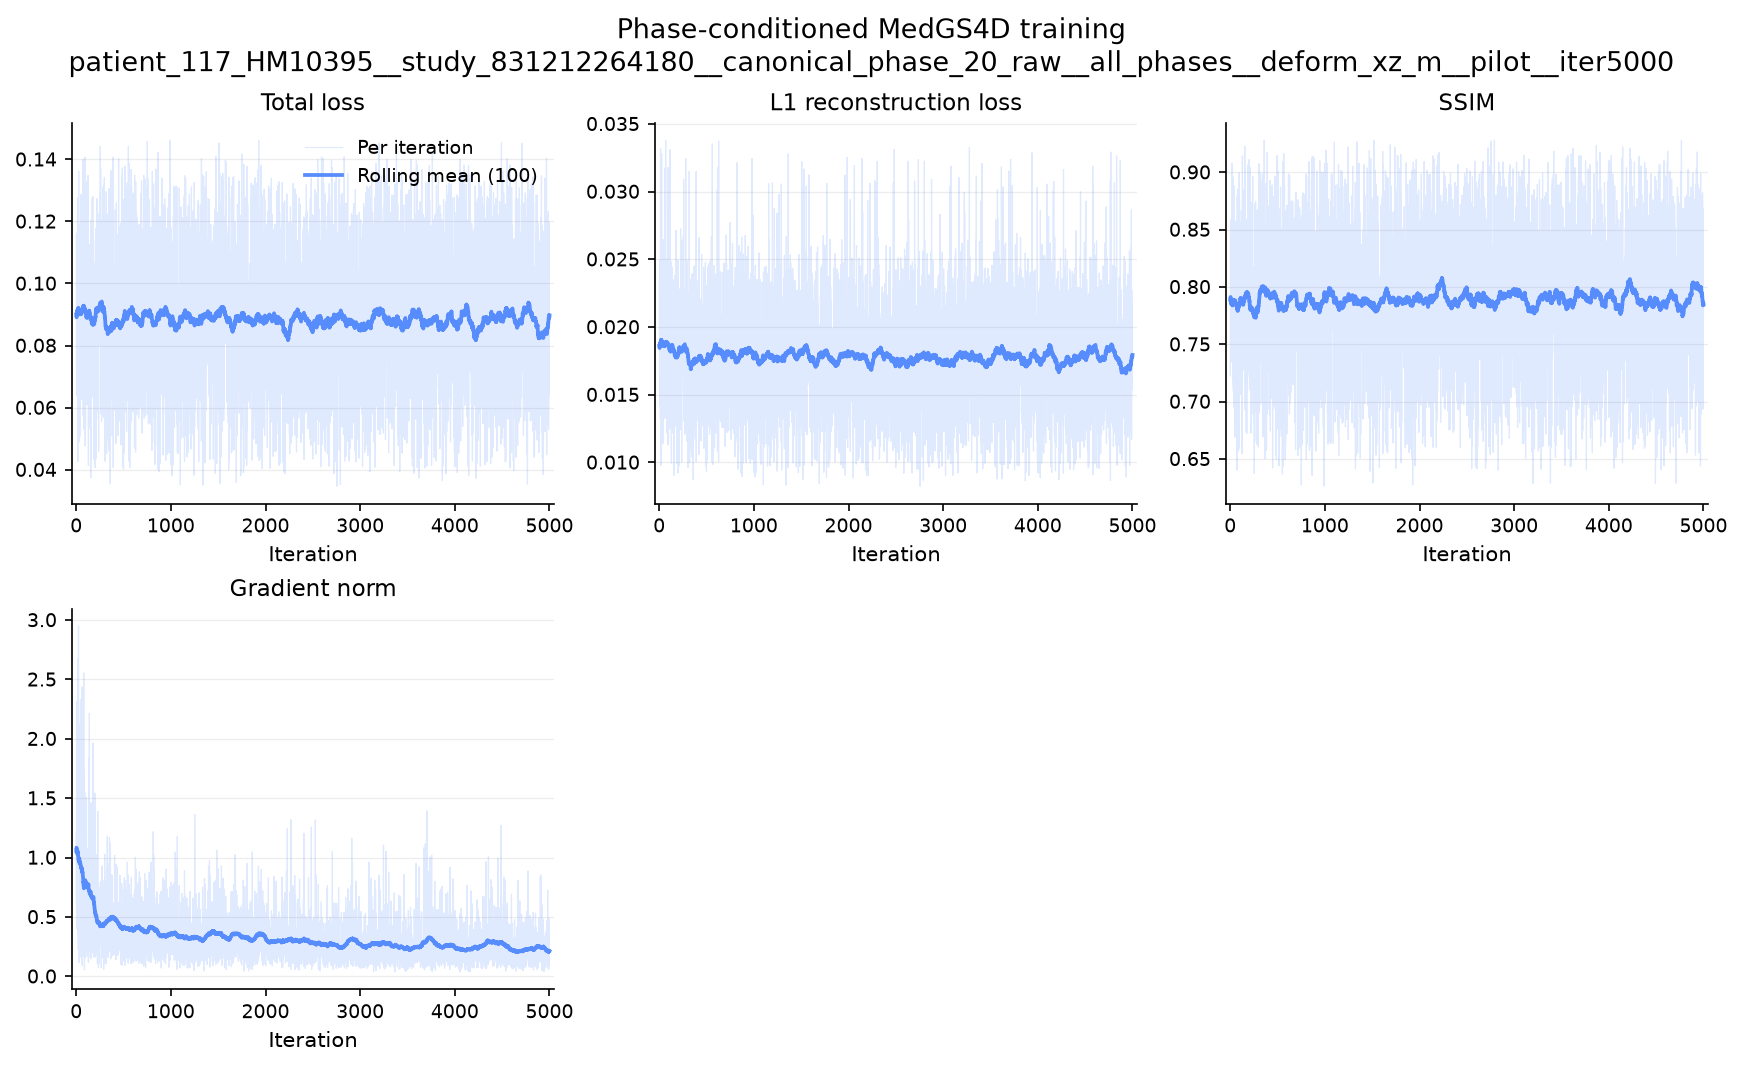

Training curves saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/dynamic_training_curves.pdf


In [89]:
# Plot training curves for the completed dynamic run.
# Save a vector PDF in the experiment directory and display it in the notebook.

plot_run_root = globals().get(
    "dynamic_run_root",
    globals().get("DYNAMIC_RUN_ROOT"),
)

assert plot_run_root is not None, (
    "Dynamic run root is not defined."
)

plot_run_root = Path(plot_run_root)

training_history_path = (
        plot_run_root
        / "dynamic_training_history.csv"
)

training_curves_path = (
        plot_run_root
        / "dynamic_training_curves.pdf"
)

assert training_history_path.is_file(), (
    f"Training history not found: "
    f"{training_history_path}"
)

training_history = pd.read_csv(
    training_history_path
)

assert not training_history.empty

assert "Iteration" in training_history.columns

metric_specifications = [
    (
        "TotalLoss",
        "Total loss",
    ),
    (
        "L1",
        "L1 reconstruction loss",
    ),
    (
        "SSIM",
        "SSIM",
    ),
    (
        "DeformationMagnitudeLoss",
        "Deformation magnitude loss",
    ),
    (
        "TemporalSmoothnessLoss",
        "Temporal smoothness loss",
    ),
    (
        "GradientNorm",
        "Gradient norm",
    ),
]

available_metrics = [
    specification
    for specification in metric_specifications
    if specification[0]
       in training_history.columns
]

assert available_metrics, (
    "No recognized metrics found in "
    "dynamic_training_history.csv."
)

smoothing_window = max(
    10,
    min(
        100,
        len(training_history) // 50,
    ),
)

with plt.rc_context(
        {
            "font.size": 10,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
):
    figure, axes = plt.subplots(
        2,
        3,
        figsize=(11.5, 7.0),
        constrained_layout=True,
    )

    axes = axes.ravel()

    iterations = training_history[
        "Iteration"
    ]

    for axis, (
            column_name,
            display_name,
    ) in zip(
        axes,
        available_metrics,
    ):
        values = pd.to_numeric(
            training_history[column_name],
            errors="coerce",
        )

        smoothed_values = values.rolling(
            window=smoothing_window,
            min_periods=1,
            center=True,
        ).mean()

        raw_line = axis.plot(
            iterations,
            values,
            linewidth=0.6,
            alpha=0.18,
            label="Per iteration",
        )[0]

        axis.plot(
            iterations,
            smoothed_values,
            linewidth=1.8,
            color=raw_line.get_color(),
            label=(
                f"Rolling mean "
                f"({smoothing_window})"
            ),
        )

        axis.set_title(
            display_name
        )

        axis.set_xlabel(
            "Iteration"
        )

        axis.grid(
            axis="y",
            alpha=0.22,
            linewidth=0.6,
        )

        axis.spines[
            "top"
        ].set_visible(False)

        axis.spines[
            "right"
        ].set_visible(False)

        axis.margins(
            x=0.01
        )

    for axis in axes[
        len(available_metrics):
    ]:
        axis.set_visible(False)

    axes[0].legend(
        frameon=False,
        loc="best",
        fontsize=9,
    )

    figure.suptitle(
        (
            "Phase-conditioned MedGS4D training\n"
            f"{plot_run_root.name}"
        ),
        fontsize=13,
    )

    figure.savefig(
        training_curves_path,
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()

    plt.close(
        figure
    )

print(
    f"Training curves saved to: "
    f"{training_curves_path}"
)

/tmp/ipykernel_7670/4159271867.py:220: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_payload = torch.load(


[01/20] iteration 0250 | PSNR gain +0.1079 dB | SSIM gain +0.000932 | 10.0s


/tmp/ipykernel_7670/4159271867.py:220: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_payload = torch.load(


[02/20] iteration 0500 | PSNR gain +0.1717 dB | SSIM gain +0.001338 | 10.0s


/tmp/ipykernel_7670/4159271867.py:220: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_payload = torch.load(


...

[18/20] iteration 4500 | PSNR gain +0.3797 dB | SSIM gain +0.003100 | 10.1s


/tmp/ipykernel_7670/4159271867.py:220: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_payload = torch.load(


[19/20] iteration 4750 | PSNR gain +0.4119 dB | SSIM gain +0.003290 | 10.1s


/tmp/ipykernel_7670/4159271867.py:220: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_payload = torch.load(


[20/20] iteration 5000 | PSNR gain +0.4170 dB | SSIM gain +0.003292 | 9.9s


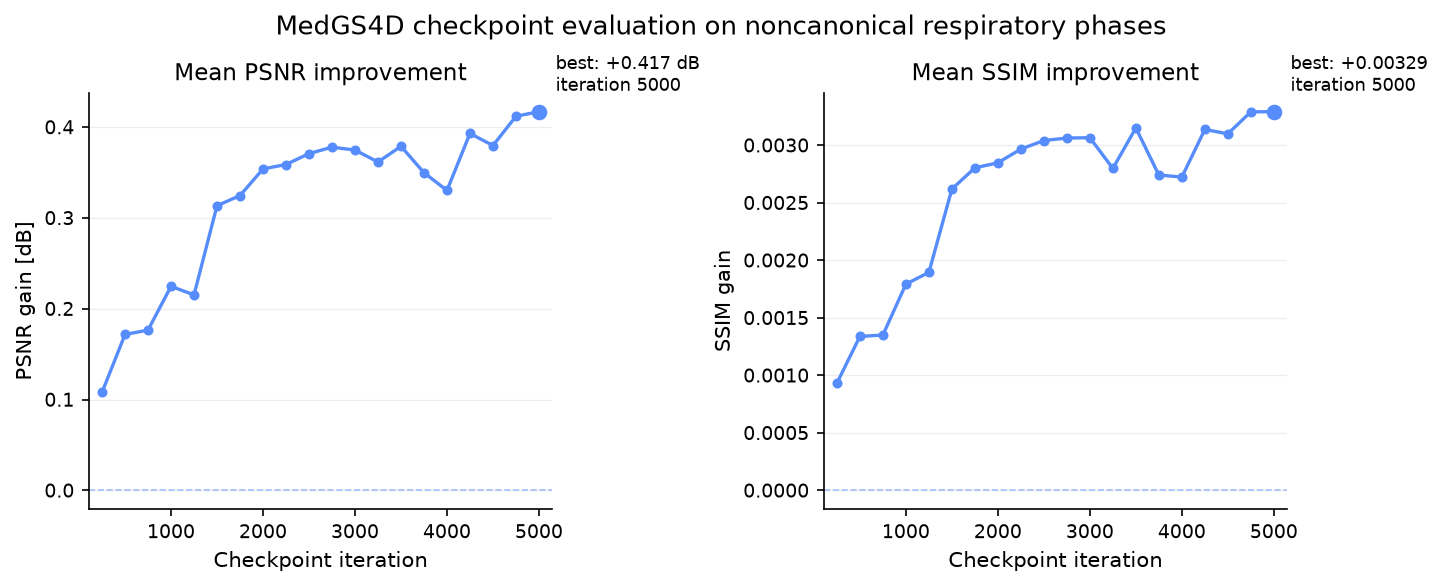

,CheckpointIteration,DynamicL1,L1Reduction,DynamicPSNR,PSNRGain,DynamicSSIM,SSIMGain
0,250,0.017956,0.000100,29.549374,0.107944,0.787476,0.000932
1,500,0.017904,0.000152,29.613097,0.171667,0.787882,0.001338
2,750,0.017952,0.000105,29.617958,0.176527,0.787894,0.001350
3,1000,0.017840,0.000217,29.666084,0.224654,0.788337,0.001793
4,1250,0.017854,0.000202,29.656690,0.215260,0.788439,0.001895
5,1500,0.017765,0.000292,29.754890,0.313460,0.789163,0.002619
6,1750,0.017737,0.000319,29.766008,0.324577,0.789347,0.002804
7,2000,0.017714,0.000342,29.795354,0.353924,0.789391,0.002847
8,2250,0.017712,0.000345,29.800221,0.358790,0.789510,0.002967
9,2500,0.017696,0.000361,29.812250,0.370820,0.789585,0.003041


Best PSNR checkpoint: 5000 (+0.4170 dB)
Best SSIM checkpoint: 5000 (+0.003292)
Total evaluation time: 3.33 minutes
Overall results saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/checkpoint_evaluation_overall.csv
Per-phase results saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/checkpoint_evaluation_per_phase.csv
Figure saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/checkpoint_evaluation_curves.pdf


In [90]:
# Evaluate every saved deformation checkpoint on the fixed noncanonical set.
# Save per-checkpoint and per-phase metrics with publication-ready PDF curves.
# Restore the previously loaded deformation model after evaluation.

checkpoint_evaluation_run_root = Path(
    plot_run_root
)

checkpoint_directory = (
        checkpoint_evaluation_run_root
        / "checkpoints"
)

baseline_results_path = (
        checkpoint_evaluation_run_root
        / "dynamic_evaluation_per_slice.csv"
)

checkpoint_overall_path = (
        checkpoint_evaluation_run_root
        / "checkpoint_evaluation_overall.csv"
)

checkpoint_per_phase_path = (
        checkpoint_evaluation_run_root
        / "checkpoint_evaluation_per_phase.csv"
)

checkpoint_figure_path = (
        checkpoint_evaluation_run_root
        / "checkpoint_evaluation_curves.pdf"
)

checkpoint_iterations = list(
    range(
        250,
        5001,
        250,
    )
)

checkpoint_paths = [
    checkpoint_directory
    / f"deformation_iter_{iteration:06d}.pth"
    for iteration in checkpoint_iterations
]

missing_checkpoints = [
    path
    for path in checkpoint_paths
    if not path.is_file()
]

assert not missing_checkpoints, (
        "Missing checkpoints:\n"
        + "\n".join(
    str(path)
    for path in missing_checkpoints
)
)

assert baseline_results_path.is_file(), (
    f"Baseline evaluation not found: "
    f"{baseline_results_path}"
)

baseline_results = pd.read_csv(
    baseline_results_path
)

required_baseline_columns = {
    "PhasePercent",
    "SliceIndex",
    "BaselineL1",
    "BaselinePSNR",
    "BaselineSSIM",
}

assert required_baseline_columns.issubset(
    baseline_results.columns
), (
    "Unexpected columns in "
    "dynamic_evaluation_per_slice.csv"
)

baseline_lookup = {
    (
        int(row.PhasePercent),
        int(row.SliceIndex),
    ): {
        "L1": float(
            row.BaselineL1
        ),
        "PSNR": float(
            row.BaselinePSNR
        ),
        "SSIM": float(
            row.BaselineSSIM
        ),
    }
    for row in baseline_results.itertuples(
        index=False
    )
}

noncanonical_phases = sorted(
    {
        int(record["phase_percent"])
        for record in dynamic_all_records
        if int(
        record["phase_percent"]
    ) != 20
    }
)

records_by_phase = {
    phase_percent: sorted(
        [
            record
            for record in dynamic_all_records
            if int(
            record["phase_percent"]
        )
               == phase_percent
        ],
        key=lambda record: int(
            record["slice_index"]
        ),
    )
    for phase_percent
    in noncanonical_phases
}

assert all(
    len(records_by_phase[phase_percent])
    == len(canonical_cameras)
    for phase_percent
    in noncanonical_phases
)


def calculate_reconstruction_metrics(
        rendered_image: torch.Tensor,
        target_image: torch.Tensor,
) -> dict[str, float]:
    """Calculate L1, PSNR, and SSIM for one reconstructed slice."""

    difference = (
            rendered_image
            - target_image
    )

    l1_value = (
        difference
        .abs()
        .mean()
    )

    mse_value = (
        difference
        .square()
        .mean()
    )

    psnr_value = (
            -10.0
            * torch.log10(
        mse_value.clamp_min(
            1e-12
        )
    )
    )

    ssim_value = ssim(
        rendered_image.unsqueeze(0),
        target_image.unsqueeze(0),
    )

    return {
        "L1": float(
            l1_value.item()
        ),
        "MSE": float(
            mse_value.item()
        ),
        "PSNR": float(
            psnr_value.item()
        ),
        "SSIM": float(
            ssim_value.item()
        ),
    }


def build_evaluation_gaussian_view(
        respiratory_time: float,
) -> tuple[
    PhaseDeformedGaussianView,
    dict[str, torch.Tensor],
]:
    """Build one reusable Gaussian view for an entire respiratory phase."""

    deformation = (
        predict_relative_deformation_for_evaluation(
            respiratory_time=respiratory_time,
            gaussian_inputs=(
                canonical_deformation_inputs
            ),
        )
    )

    delta_xz = deformation[:, :2]
    delta_m_logit = deformation[:, 2:3]

    dynamic_xz = (
            canonical_xz
            + delta_xz
    )

    dynamic_m_logits = (
            canonical_m_logits
            + delta_m_logit
    )

    dynamic_m = torch.sigmoid(
        dynamic_m_logits
    )

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[:, 0],
            canonical_xyz[:, 1],
            dynamic_xz[:, 1],
        ],
        dim=-1,
    )

    gaussian_view = PhaseDeformedGaussianView(
        canonical_model=canonical_gaussians,
        dynamic_xyz=dynamic_xyz,
        dynamic_m=dynamic_m,
    )

    state = {
        "delta_xz": delta_xz,
        "delta_m_logit": delta_m_logit,
        "delta_m": dynamic_m - canonical_m,
        "dynamic_xyz": dynamic_xyz,
        "dynamic_m": dynamic_m,
    }

    return gaussian_view, state


def extract_deformation_state_dict(
        checkpoint_payload,
):
    """Extract the deformation MLP state from supported checkpoint layouts."""

    candidate_keys = [
        "deformation_mlp_state_dict",
        "deformation_model_state_dict",
        "model_state_dict",
        "mlp_state_dict",
        "state_dict",
    ]

    if isinstance(
            checkpoint_payload,
            dict,
    ):
        for candidate_key in candidate_keys:
            if candidate_key in checkpoint_payload:
                return checkpoint_payload[
                    candidate_key
                ]

        if (
                checkpoint_payload
                and all(
            torch.is_tensor(value)
            for value
            in checkpoint_payload.values()
        )
        ):
            return checkpoint_payload

    raise KeyError(
        "Cannot find deformation MLP state "
        "in checkpoint."
    )


saved_deformation_state = {
    name: tensor.detach().clone()
    for name, tensor
    in deformation_mlp.state_dict().items()
}

saved_training_mode = (
    deformation_mlp.training
)

evaluation_device = next(
    deformation_mlp.parameters()
).device

checkpoint_overall_rows = []
checkpoint_per_phase_rows = []

evaluation_start_time = (
    time.perf_counter()
)

try:
    for checkpoint_index, (
            checkpoint_iteration,
            checkpoint_path,
    ) in enumerate(
        zip(
            checkpoint_iterations,
            checkpoint_paths,
        ),
        start=1,
    ):
        checkpoint_payload = torch.load(
            checkpoint_path,
            map_location=evaluation_device,
        )

        deformation_mlp.load_state_dict(
            extract_deformation_state_dict(
                checkpoint_payload
            ),
            strict=True,
        )

        deformation_mlp.eval()

        checkpoint_baseline_l1 = []
        checkpoint_dynamic_l1 = []

        checkpoint_baseline_psnr = []
        checkpoint_dynamic_psnr = []

        checkpoint_baseline_ssim = []
        checkpoint_dynamic_ssim = []

        checkpoint_start_time = (
            time.perf_counter()
        )

        for phase_percent in noncanonical_phases:
            phase_baseline_l1 = []
            phase_dynamic_l1 = []

            phase_baseline_psnr = []
            phase_dynamic_psnr = []

            phase_baseline_ssim = []
            phase_dynamic_ssim = []

            with torch.no_grad():
                phase_gaussian_view, phase_state = (
                    build_evaluation_gaussian_view(
                        respiratory_time=(
                                phase_percent
                                / 100.0
                        )
                    )
                )

                for record in records_by_phase[
                    phase_percent
                ]:
                    slice_index = int(
                        record["slice_index"]
                    )

                    camera = canonical_cameras[
                        int(
                            record[
                                "camera_index"
                            ]
                        )
                    ]

                    target_image = (
                        load_dynamic_target_image(
                            record
                        )
                    )

                    render_result = medgs_render(
                        camera,
                        phase_gaussian_view,
                        canonical_pipeline,
                        canonical_background,
                    )

                    rendered_image = (
                        render_result[
                            "render"
                        ]
                    )

                    dynamic_metrics = (
                        calculate_reconstruction_metrics(
                            rendered_image=(
                                rendered_image
                            ),
                            target_image=(
                                target_image
                            ),
                        )
                    )

                    baseline_metrics = (
                        baseline_lookup[
                            (
                                phase_percent,
                                slice_index,
                            )
                        ]
                    )

                    phase_baseline_l1.append(
                        baseline_metrics["L1"]
                    )

                    phase_dynamic_l1.append(
                        dynamic_metrics["L1"]
                    )

                    phase_baseline_psnr.append(
                        baseline_metrics["PSNR"]
                    )

                    phase_dynamic_psnr.append(
                        dynamic_metrics["PSNR"]
                    )

                    phase_baseline_ssim.append(
                        baseline_metrics["SSIM"]
                    )

                    phase_dynamic_ssim.append(
                        dynamic_metrics["SSIM"]
                    )

                    del target_image
                    del render_result
                    del rendered_image

            mean_baseline_l1 = sum(
                phase_baseline_l1
            ) / len(
                phase_baseline_l1
            )

            mean_dynamic_l1 = sum(
                phase_dynamic_l1
            ) / len(
                phase_dynamic_l1
            )

            mean_baseline_psnr = sum(
                phase_baseline_psnr
            ) / len(
                phase_baseline_psnr
            )

            mean_dynamic_psnr = sum(
                phase_dynamic_psnr
            ) / len(
                phase_dynamic_psnr
            )

            mean_baseline_ssim = sum(
                phase_baseline_ssim
            ) / len(
                phase_baseline_ssim
            )

            mean_dynamic_ssim = sum(
                phase_dynamic_ssim
            ) / len(
                phase_dynamic_ssim
            )

            checkpoint_per_phase_rows.append(
                {
                    "CheckpointIteration": (
                        checkpoint_iteration
                    ),
                    "PhasePercent": (
                        phase_percent
                    ),
                    "SliceCount": len(
                        phase_dynamic_psnr
                    ),
                    "BaselineL1": (
                        mean_baseline_l1
                    ),
                    "DynamicL1": (
                        mean_dynamic_l1
                    ),
                    "L1Reduction": (
                            mean_baseline_l1
                            - mean_dynamic_l1
                    ),
                    "BaselinePSNR": (
                        mean_baseline_psnr
                    ),
                    "DynamicPSNR": (
                        mean_dynamic_psnr
                    ),
                    "PSNRGain": (
                            mean_dynamic_psnr
                            - mean_baseline_psnr
                    ),
                    "BaselineSSIM": (
                        mean_baseline_ssim
                    ),
                    "DynamicSSIM": (
                        mean_dynamic_ssim
                    ),
                    "SSIMGain": (
                            mean_dynamic_ssim
                            - mean_baseline_ssim
                    ),
                }
            )

            checkpoint_baseline_l1.extend(
                phase_baseline_l1
            )

            checkpoint_dynamic_l1.extend(
                phase_dynamic_l1
            )

            checkpoint_baseline_psnr.extend(
                phase_baseline_psnr
            )

            checkpoint_dynamic_psnr.extend(
                phase_dynamic_psnr
            )

            checkpoint_baseline_ssim.extend(
                phase_baseline_ssim
            )

            checkpoint_dynamic_ssim.extend(
                phase_dynamic_ssim
            )

            del phase_gaussian_view
            del phase_state

            torch.cuda.empty_cache()

        overall_baseline_l1 = sum(
            checkpoint_baseline_l1
        ) / len(
            checkpoint_baseline_l1
        )

        overall_dynamic_l1 = sum(
            checkpoint_dynamic_l1
        ) / len(
            checkpoint_dynamic_l1
        )

        overall_baseline_psnr = sum(
            checkpoint_baseline_psnr
        ) / len(
            checkpoint_baseline_psnr
        )

        overall_dynamic_psnr = sum(
            checkpoint_dynamic_psnr
        ) / len(
            checkpoint_dynamic_psnr
        )

        overall_baseline_ssim = sum(
            checkpoint_baseline_ssim
        ) / len(
            checkpoint_baseline_ssim
        )

        overall_dynamic_ssim = sum(
            checkpoint_dynamic_ssim
        ) / len(
            checkpoint_dynamic_ssim
        )

        checkpoint_seconds = (
                time.perf_counter()
                - checkpoint_start_time
        )

        checkpoint_overall_rows.append(
            {
                "CheckpointIteration": (
                    checkpoint_iteration
                ),
                "ImageCount": len(
                    checkpoint_dynamic_psnr
                ),
                "BaselineL1": (
                    overall_baseline_l1
                ),
                "DynamicL1": (
                    overall_dynamic_l1
                ),
                "L1Reduction": (
                        overall_baseline_l1
                        - overall_dynamic_l1
                ),
                "BaselinePSNR": (
                    overall_baseline_psnr
                ),
                "DynamicPSNR": (
                    overall_dynamic_psnr
                ),
                "PSNRGain": (
                        overall_dynamic_psnr
                        - overall_baseline_psnr
                ),
                "BaselineSSIM": (
                    overall_baseline_ssim
                ),
                "DynamicSSIM": (
                    overall_dynamic_ssim
                ),
                "SSIMGain": (
                        overall_dynamic_ssim
                        - overall_baseline_ssim
                ),
                "EvaluationSeconds": (
                    checkpoint_seconds
                ),
                "CheckpointPath": str(
                    checkpoint_path
                ),
            }
        )

        pd.DataFrame(
            checkpoint_overall_rows
        ).to_csv(
            checkpoint_overall_path,
            index=False,
        )

        pd.DataFrame(
            checkpoint_per_phase_rows
        ).to_csv(
            checkpoint_per_phase_path,
            index=False,
        )

        print(
            f"[{checkpoint_index:02d}/"
            f"{len(checkpoint_paths):02d}] "
            f"iteration "
            f"{checkpoint_iteration:04d} | "
            f"PSNR gain "
            f"{overall_dynamic_psnr - overall_baseline_psnr:+.4f} dB | "
            f"SSIM gain "
            f"{overall_dynamic_ssim - overall_baseline_ssim:+.6f} | "
            f"{checkpoint_seconds:.1f}s"
        )

finally:
    deformation_mlp.load_state_dict(
        saved_deformation_state,
        strict=True,
    )

    deformation_mlp.train(
        saved_training_mode
    )

    torch.cuda.empty_cache()

checkpoint_evaluation = (
    pd.DataFrame(
        checkpoint_overall_rows
    )
    .sort_values(
        "CheckpointIteration"
    )
    .reset_index(
        drop=True
    )
)

checkpoint_per_phase_evaluation = (
    pd.DataFrame(
        checkpoint_per_phase_rows
    )
    .sort_values(
        [
            "CheckpointIteration",
            "PhasePercent",
        ]
    )
    .reset_index(
        drop=True
    )
)

checkpoint_evaluation.to_csv(
    checkpoint_overall_path,
    index=False,
)

checkpoint_per_phase_evaluation.to_csv(
    checkpoint_per_phase_path,
    index=False,
)

best_psnr_row = checkpoint_evaluation.loc[
    checkpoint_evaluation[
        "PSNRGain"
    ].idxmax()
]

best_ssim_row = checkpoint_evaluation.loc[
    checkpoint_evaluation[
        "SSIMGain"
    ].idxmax()
]

with plt.rc_context(
        {
            "font.size": 10,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(9.5, 3.8),
        constrained_layout=True,
    )

    psnr_line = axes[0].plot(
        checkpoint_evaluation[
            "CheckpointIteration"
        ],
        checkpoint_evaluation[
            "PSNRGain"
        ],
        marker="o",
        markersize=3.8,
        linewidth=1.6,
    )[0]

    axes[0].scatter(
        best_psnr_row[
            "CheckpointIteration"
        ],
        best_psnr_row[
            "PSNRGain"
        ],
        s=42,
        color=psnr_line.get_color(),
        zorder=3,
    )

    axes[0].annotate(
        (
            f"best: "
            f"{best_psnr_row['PSNRGain']:+.3f} dB\n"
            f"iteration "
            f"{int(best_psnr_row['CheckpointIteration'])}"
        ),
        xy=(
            best_psnr_row[
                "CheckpointIteration"
            ],
            best_psnr_row[
                "PSNRGain"
            ],
        ),
        xytext=(8, 10),
        textcoords="offset points",
        fontsize=8.5,
    )

    axes[0].axhline(
        0.0,
        linewidth=0.8,
        linestyle="--",
        alpha=0.5,
    )

    axes[0].set_title(
        "Mean PSNR improvement"
    )

    axes[0].set_xlabel(
        "Checkpoint iteration"
    )

    axes[0].set_ylabel(
        "PSNR gain [dB]"
    )

    ssim_line = axes[1].plot(
        checkpoint_evaluation[
            "CheckpointIteration"
        ],
        checkpoint_evaluation[
            "SSIMGain"
        ],
        marker="o",
        markersize=3.8,
        linewidth=1.6,
    )[0]

    axes[1].scatter(
        best_ssim_row[
            "CheckpointIteration"
        ],
        best_ssim_row[
            "SSIMGain"
        ],
        s=42,
        color=ssim_line.get_color(),
        zorder=3,
    )

    axes[1].annotate(
        (
            f"best: "
            f"{best_ssim_row['SSIMGain']:+.5f}\n"
            f"iteration "
            f"{int(best_ssim_row['CheckpointIteration'])}"
        ),
        xy=(
            best_ssim_row[
                "CheckpointIteration"
            ],
            best_ssim_row[
                "SSIMGain"
            ],
        ),
        xytext=(8, 10),
        textcoords="offset points",
        fontsize=8.5,
    )

    axes[1].axhline(
        0.0,
        linewidth=0.8,
        linestyle="--",
        alpha=0.5,
    )

    axes[1].set_title(
        "Mean SSIM improvement"
    )

    axes[1].set_xlabel(
        "Checkpoint iteration"
    )

    axes[1].set_ylabel(
        "SSIM gain"
    )

    for axis in axes:
        axis.grid(
            axis="y",
            alpha=0.22,
            linewidth=0.6,
        )

        axis.spines[
            "top"
        ].set_visible(False)

        axis.spines[
            "right"
        ].set_visible(False)

        axis.margins(
            x=0.03
        )

    figure.suptitle(
        (
            "MedGS4D checkpoint evaluation "
            "on noncanonical respiratory phases"
        ),
        fontsize=12.5,
    )

    figure.savefig(
        checkpoint_figure_path,
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()

    plt.close(
        figure
    )

evaluation_minutes = (
                             time.perf_counter()
                             - evaluation_start_time
                     ) / 60.0

display(
    checkpoint_evaluation[
        [
            "CheckpointIteration",
            "DynamicL1",
            "L1Reduction",
            "DynamicPSNR",
            "PSNRGain",
            "DynamicSSIM",
            "SSIMGain",
        ]
    ]
)

print(
    f"Best PSNR checkpoint: "
    f"{int(best_psnr_row['CheckpointIteration'])} "
    f"({best_psnr_row['PSNRGain']:+.4f} dB)"
)

print(
    f"Best SSIM checkpoint: "
    f"{int(best_ssim_row['CheckpointIteration'])} "
    f"({best_ssim_row['SSIMGain']:+.6f})"
)

print(
    f"Total evaluation time: "
    f"{evaluation_minutes:.2f} minutes"
)

print(
    f"Overall results saved to: "
    f"{checkpoint_overall_path}"
)

print(
    f"Per-phase results saved to: "
    f"{checkpoint_per_phase_path}"
)

print(
    f"Figure saved to: "
    f"{checkpoint_figure_path}"
)

In [85]:
# Summarize smoke-training convergence and learned deformation magnitudes.
# Compare early and late losses and inspect x/z/m shifts across all phases
# on the fixed reproducible Gaussian subset.
#
# Writes dynamic_training_summary.csv and dynamic_deformation_summary.csv.


warnings.filterwarnings(
    "ignore",
    message=(
        r".*torch\.cpu\.amp\.autocast"
        r".*deprecated.*"
    ),
    category=FutureWarning,
    module=r"torch\.utils\.checkpoint",
)

final_checkpoint = torch.load(
    latest_checkpoint_path,
    map_location=canonical_xyz.device,
    weights_only=False,
)

assert final_checkpoint["iteration"] == (
    DYNAMIC_ITERATIONS
)

deformation_mlp.load_state_dict(
    final_checkpoint[
        "deformation_mlp_state_dict"
    ]
)

deformation_mlp.eval()

training_history_df = pd.read_csv(
    training_history_path
)

assert len(training_history_df) == (
    DYNAMIC_ITERATIONS
)

summary_window = min(
    DYNAMIC_LOG_EVERY,
    len(training_history_df),
)

first_window_df = training_history_df.head(
    summary_window
)

last_window_df = training_history_df.tail(
    summary_window
)


def summarize_training_window(
        label: str,
        history_window_df: pd.DataFrame,
) -> dict:
    """Summarize one contiguous training-history window."""

    return {
        "Window": label,
        "Iterations": len(
            history_window_df
        ),
        "IterationFrom": int(
            history_window_df[
                "Iteration"
            ].min()
        ),
        "IterationTo": int(
            history_window_df[
                "Iteration"
            ].max()
        ),
        "MeanTotalLoss": float(
            history_window_df[
                "TotalLoss"
            ].mean()
        ),
        "MeanImageLoss": float(
            history_window_df[
                "ImageLoss"
            ].mean()
        ),
        "MeanL1": float(
            history_window_df[
                "L1"
            ].mean()
        ),
        "MeanSSIM": float(
            history_window_df[
                "SSIM"
            ].mean()
        ),
        "MeanMagnitudeLoss": float(
            history_window_df[
                "MagnitudeLoss"
            ].mean()
        ),
        "MeanSmoothnessLoss": float(
            history_window_df[
                "SmoothnessLoss"
            ].mean()
        ),
        "MeanGradientNorm": float(
            history_window_df[
                "GradientNorm"
            ].mean()
        ),
    }


dynamic_training_summary_df = pd.DataFrame(
    [
        summarize_training_window(
            "first",
            first_window_df,
        ),
        summarize_training_window(
            "last",
            last_window_df,
        ),
    ]
)

dynamic_training_summary_path = (
        dynamic_run_root
        / "dynamic_training_summary.csv"
)

dynamic_training_summary_df.to_csv(
    dynamic_training_summary_path,
    index=False,
)

smoothness_gaussian_indices_np = np.load(
    smoothness_indices_path
)

diagnostic_gaussian_indices = (
    torch.from_numpy(
        smoothness_gaussian_indices_np
    )
    .to(
        device=canonical_xyz.device,
        dtype=torch.long,
    )
)


def tensor_absolute_statistics(
        values: torch.Tensor,
) -> dict[str, float]:
    """Calculate absolute-value statistics for one tensor."""

    absolute_values = (
        values
        .detach()
        .abs()
        .flatten()
    )

    return {
        "mean": float(
            absolute_values.mean().item()
        ),
        "p95": float(
            torch.quantile(
                absolute_values,
                0.95,
            ).item()
        ),
        "maximum": float(
            absolute_values.max().item()
        ),
    }


deformation_summary_rows = []

with torch.no_grad():
    for phase_percent in (
            DYNAMIC_PHASE_PERCENTS
    ):
        respiratory_time = (
                float(phase_percent)
                / 100.0
        )

        phase_state = (
            build_phase_deformed_subset(
                respiratory_time=(
                    respiratory_time
                ),
                gaussian_indices=(
                    diagnostic_gaussian_indices
                ),
            )
        )

        delta_x = (
            phase_state[
                "delta_xz"
            ][:, 0]
        )

        delta_z = (
            phase_state[
                "delta_xz"
            ][:, 1]
        )

        delta_m = (
            phase_state[
                "delta_m"
            ][:, 0]
        )

        delta_m_slices = (
                delta_m
                * len(canonical_cameras)
        )

        delta_x_statistics = (
            tensor_absolute_statistics(
                delta_x
            )
        )

        delta_z_statistics = (
            tensor_absolute_statistics(
                delta_z
            )
        )

        delta_m_statistics = (
            tensor_absolute_statistics(
                delta_m
            )
        )

        delta_m_slice_statistics = (
            tensor_absolute_statistics(
                delta_m_slices
            )
        )

        normalized_delta_xz = (
                phase_state[
                    "delta_xz"
                ]
                / canonical_xz_scale
        )

        normalized_delta_m = (
                phase_state[
                    "delta_m"
                ]
                / canonical_m_scale
        )

        normalized_deformation = (
            torch.cat(
                [
                    normalized_delta_xz,
                    normalized_delta_m,
                ],
                dim=-1,
            )
        )

        normalized_rms = float(
            normalized_deformation
            .square()
            .mean()
            .sqrt()
            .item()
        )

        deformation_summary_rows.append(
            {
                "PhasePercent": int(
                    phase_percent
                ),
                "RespiratoryTime": (
                    respiratory_time
                ),
                "GaussianCount": int(
                    diagnostic_gaussian_indices
                    .numel()
                ),
                "MeanAbsDeltaX": (
                    delta_x_statistics[
                        "mean"
                    ]
                ),
                "P95AbsDeltaX": (
                    delta_x_statistics[
                        "p95"
                    ]
                ),
                "MaxAbsDeltaX": (
                    delta_x_statistics[
                        "maximum"
                    ]
                ),
                "MeanAbsDeltaZ": (
                    delta_z_statistics[
                        "mean"
                    ]
                ),
                "P95AbsDeltaZ": (
                    delta_z_statistics[
                        "p95"
                    ]
                ),
                "MaxAbsDeltaZ": (
                    delta_z_statistics[
                        "maximum"
                    ]
                ),
                "MeanAbsDeltaM": (
                    delta_m_statistics[
                        "mean"
                    ]
                ),
                "P95AbsDeltaM": (
                    delta_m_statistics[
                        "p95"
                    ]
                ),
                "MaxAbsDeltaM": (
                    delta_m_statistics[
                        "maximum"
                    ]
                ),
                "MeanAbsDeltaMSlices": (
                    delta_m_slice_statistics[
                        "mean"
                    ]
                ),
                "P95AbsDeltaMSlices": (
                    delta_m_slice_statistics[
                        "p95"
                    ]
                ),
                "MaxAbsDeltaMSlices": (
                    delta_m_slice_statistics[
                        "maximum"
                    ]
                ),
                "NormalizedDeformationRMS": (
                    normalized_rms
                ),
            }
        )

        del phase_state

dynamic_deformation_summary_df = (
    pd.DataFrame(
        deformation_summary_rows
    )
)

dynamic_deformation_summary_path = (
        dynamic_run_root
        / "dynamic_deformation_summary.csv"
)

dynamic_deformation_summary_df.to_csv(
    dynamic_deformation_summary_path,
    index=False,
)

canonical_deformation_row = (
    dynamic_deformation_summary_df.loc[
        dynamic_deformation_summary_df[
            "PhasePercent"
        ].eq(
            DYNAMIC_CANONICAL_PHASE_PERCENT
        )
    ]
    .iloc[0]
)

noncanonical_deformation_df = (
    dynamic_deformation_summary_df.loc[
        ~dynamic_deformation_summary_df[
            "PhasePercent"
        ].eq(
            DYNAMIC_CANONICAL_PHASE_PERCENT
        )
    ]
)

assert canonical_deformation_row[
           "MaxAbsDeltaX"
       ] == 0.0

assert canonical_deformation_row[
           "MaxAbsDeltaZ"
       ] == 0.0

assert canonical_deformation_row[
           "MaxAbsDeltaM"
       ] == 0.0

assert np.isfinite(
    dynamic_deformation_summary_df
    .select_dtypes(
        include=[np.number]
    )
    .to_numpy()
).all()

assert (
        noncanonical_deformation_df[
            [
                "MaxAbsDeltaX",
                "MaxAbsDeltaZ",
                "MaxAbsDeltaM",
            ]
        ]
        .to_numpy()
        .max()
        > 0.0
)

first_mean_loss = (
    dynamic_training_summary_df.loc[
        dynamic_training_summary_df[
            "Window"
        ].eq("first"),
        "MeanTotalLoss",
    ].iloc[0]
)

last_mean_loss = (
    dynamic_training_summary_df.loc[
        dynamic_training_summary_df[
            "Window"
        ].eq("last"),
        "MeanTotalLoss",
    ].iloc[0]
)

relative_loss_change_percent = (
        100.0
        * (
                last_mean_loss
                - first_mean_loss
        )
        / first_mean_loss
)

print(
    "Dynamic smoke-training diagnostics completed."
)

print(
    f"Checkpoint iteration: "
    f"{final_checkpoint['iteration']}"
)

print(
    f"Diagnostic Gaussians: "
    f"{diagnostic_gaussian_indices.numel():,}"
)

print(
    f"First {summary_window} iterations "
    f"mean loss: {first_mean_loss:.8f}"
)

print(
    f"Last {summary_window} iterations "
    f"mean loss: {last_mean_loss:.8f}"
)

print(
    f"Relative mean-loss change: "
    f"{relative_loss_change_percent:.2f}%"
)

print(
    f"Training summary saved to: "
    f"{dynamic_training_summary_path}"
)

print(
    f"Deformation summary saved to: "
    f"{dynamic_deformation_summary_path}"
)

print(
    "\nTraining-window summary:"
)

display(
    dynamic_training_summary_df
)

print(
    "\nPhase-dependent deformation summary:"
)

display(
    dynamic_deformation_summary_df[
        [
            "PhasePercent",
            "MeanAbsDeltaX",
            "P95AbsDeltaX",
            "MeanAbsDeltaZ",
            "P95AbsDeltaZ",
            "MeanAbsDeltaMSlices",
            "P95AbsDeltaMSlices",
            "MaxAbsDeltaMSlices",
            "NormalizedDeformationRMS",
        ]
    ]
)

torch.cuda.empty_cache()

Dynamic smoke-training diagnostics completed.
Checkpoint iteration: 5000
Diagnostic Gaussians: 65,536
First 25 iterations mean loss: 0.08415090
Last 25 iterations mean loss: 0.09133682
Relative mean-loss change: 8.54%
Training summary saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/dynamic_training_summary.csv
Deformation summary saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot__iter5000/dynamic_deformation_summary.csv

Training-window summary:


,Window,Iterations,IterationFrom,IterationTo,MeanTotalLoss,MeanImageLoss,MeanL1,MeanSSIM,MeanMagnitudeLoss,MeanSmoothnessLoss,MeanGradientNorm
0,first,25,1,25,0.084151,0.084151,0.017857,0.806251,8.906776e-07,3.411110e-07,1.178335
1,last,25,4976,5000,0.091337,0.091337,0.018591,0.783385,1.197563e-05,3.849297e-06,0.224735



Phase-dependent deformation summary:


,PhasePercent,MeanAbsDeltaX,P95AbsDeltaX,MeanAbsDeltaZ,P95AbsDeltaZ,MeanAbsDeltaMSlices,P95AbsDeltaMSlices,MaxAbsDeltaMSlices,NormalizedDeformationRMS
0,0,0.000433,0.001316,0.000305,0.001101,0.233760,0.572599,0.775633,0.004922
1,10,0.000196,0.000585,0.000171,0.000628,0.161693,0.388120,0.474066,0.003174
2,20,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,30,0.000093,0.000242,0.000163,0.000565,0.119941,0.260805,0.281497,0.002340
4,40,0.000066,0.000196,0.000264,0.000951,0.172417,0.380617,0.421714,0.003430
5,50,0.000055,0.000150,0.000325,0.001148,0.194749,0.429960,0.494122,0.003917
6,60,0.000044,0.000155,0.000316,0.001062,0.187994,0.418298,0.508505,0.003714
7,70,0.000141,0.000444,0.000106,0.000378,0.104186,0.244007,0.349726,0.001964
8,80,0.000321,0.001125,0.000182,0.000613,0.098778,0.288582,0.479406,0.002716
9,90,0.000465,0.001568,0.000318,0.001128,0.208618,0.516499,0.774835,0.004759


In [86]:
# Evaluate the static canonical baseline and trained MedGS4D model.
# Render every phase/slice pair and compute L1, PSNR, and SSIM metrics.
#
# Writes per-slice, per-phase, and overall evaluation results.


dynamic_evaluation_per_slice_path = (
        dynamic_run_root
        / "dynamic_evaluation_per_slice.csv"
)

dynamic_evaluation_per_phase_path = (
        dynamic_run_root
        / "dynamic_evaluation_per_phase.csv"
)

dynamic_evaluation_overall_path = (
        dynamic_run_root
        / "dynamic_evaluation_overall.json"
)


def predict_relative_deformation_for_evaluation(
        respiratory_time: float,
        gaussian_inputs: torch.Tensor,
        chunk_size: int = DYNAMIC_MLP_CHUNK_SIZE,
) -> torch.Tensor:
    """Predict all Gaussian residuals without gradient checkpointing."""

    deformation_chunks = []

    for start in range(
            0,
            gaussian_inputs.shape[0],
            chunk_size,
    ):
        end = min(
            start + chunk_size,
            gaussian_inputs.shape[0],
        )

        spatial_chunk = gaussian_inputs[
            start:end
        ]

        phase_inputs = build_deformation_mlp_inputs(
            spatial_chunk,
            respiratory_time,
        )

        canonical_phase_inputs = (
            build_deformation_mlp_inputs(
                spatial_chunk,
                DYNAMIC_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_outputs = deformation_mlp(
            torch.cat(
                [
                    phase_inputs,
                    canonical_phase_inputs,
                ],
                dim=0,
            )
        )

        current_count = spatial_chunk.shape[0]

        deformation_chunks.append(
            joint_outputs[:current_count]
            - joint_outputs[current_count:]
        )

    return torch.cat(
        deformation_chunks,
        dim=0,
    )


deformation_mlp.eval()

evaluation_start_time = (
    time.perf_counter()
)

print(
    "Rendering 147 canonical baseline slices..."
)

baseline_render_cache = []

with torch.no_grad():
    for camera_index, camera in enumerate(
            canonical_cameras
    ):
        render_result = medgs_render(
            camera,
            canonical_gaussians,
            canonical_pipeline,
            canonical_background,
        )

        baseline_render_cache.append(
            render_result["render"]
            .detach()
            .cpu()
        )

        del render_result

        if (
                (camera_index + 1) % 25 == 0
                or camera_index + 1
                == len(canonical_cameras)
        ):
            print(
                f"  Baseline slices: "
                f"{camera_index + 1}/"
                f"{len(canonical_cameras)}"
            )

evaluation_rows = []

with torch.no_grad():
    for phase_percent in (
            DYNAMIC_PHASE_PERCENTS
    ):
        phase_percent = int(
            phase_percent
        )

        respiratory_time = (
                phase_percent / 100.0
        )

        phase_start_time = (
            time.perf_counter()
        )

        phase_gaussian_view, phase_state = (
            build_evaluation_gaussian_view(
                respiratory_time=(
                    respiratory_time
                )
            )
        )

        phase_records = sorted(
            [
                record
                for record in dynamic_all_records
                if int(
                record["phase_percent"]
            ) == phase_percent
            ],
            key=lambda record: (
                record["camera_index"]
            ),
        )

        assert len(phase_records) == len(
            canonical_cameras
        )

        for record in phase_records:
            camera_index = int(
                record["camera_index"]
            )

            target_image = (
                load_dynamic_target_image(
                    record
                )
            )

            baseline_image = (
                baseline_render_cache[
                    camera_index
                ]
                .to(
                    device=canonical_xyz.device,
                    dtype=canonical_xyz.dtype,
                )
            )

            dynamic_render_result = (
                medgs_render(
                    canonical_cameras[
                        camera_index
                    ],
                    phase_gaussian_view,
                    canonical_pipeline,
                    canonical_background,
                )
            )

            dynamic_image = (
                dynamic_render_result[
                    "render"
                ]
            )

            baseline_metrics = (
                calculate_reconstruction_metrics(
                    rendered_image=(
                        baseline_image
                    ),
                    target_image=(
                        target_image
                    ),
                )
            )

            dynamic_metrics = (
                calculate_reconstruction_metrics(
                    rendered_image=(
                        dynamic_image
                    ),
                    target_image=(
                        target_image
                    ),
                )
            )

            evaluation_rows.append(
                {
                    "PhasePercent": (
                        phase_percent
                    ),
                    "RespiratoryTime": (
                        respiratory_time
                    ),
                    "SliceIndex": int(
                        record["slice_index"]
                    ),
                    "CameraIndex": (
                        camera_index
                    ),
                    "SliceCoordinate": float(
                        record[
                            "slice_coordinate"
                        ]
                    ),
                    "DynamicSplit": (
                        "canonical_anchor"
                        if phase_percent
                           == int(
                            DYNAMIC_CANONICAL_PHASE_PERCENT
                        )
                        else "mlp_train"
                    ),
                    "BaselineL1": (
                        baseline_metrics["L1"]
                    ),
                    "BaselineMSE": (
                        baseline_metrics["MSE"]
                    ),
                    "BaselinePSNR": (
                        baseline_metrics["PSNR"]
                    ),
                    "BaselineSSIM": (
                        baseline_metrics["SSIM"]
                    ),
                    "DynamicL1": (
                        dynamic_metrics["L1"]
                    ),
                    "DynamicMSE": (
                        dynamic_metrics["MSE"]
                    ),
                    "DynamicPSNR": (
                        dynamic_metrics["PSNR"]
                    ),
                    "DynamicSSIM": (
                        dynamic_metrics["SSIM"]
                    ),
                    "L1Reduction": (
                            baseline_metrics["L1"]
                            - dynamic_metrics["L1"]
                    ),
                    "PSNRGain": (
                            dynamic_metrics["PSNR"]
                            - baseline_metrics["PSNR"]
                    ),
                    "SSIMGain": (
                            dynamic_metrics["SSIM"]
                            - baseline_metrics["SSIM"]
                    ),
                }
            )

            del target_image
            del baseline_image
            del dynamic_render_result
            del dynamic_image

        pd.DataFrame(
            evaluation_rows
        ).to_csv(
            dynamic_evaluation_per_slice_path,
            index=False,
        )

        phase_rows_df = pd.DataFrame(
            [
                row
                for row in evaluation_rows
                if row["PhasePercent"]
                   == phase_percent
            ]
        )

        phase_elapsed_seconds = (
                time.perf_counter()
                - phase_start_time
        )

        print(
            f"Phase {phase_percent:02d}% | "
            f"baseline PSNR="
            f"{phase_rows_df['BaselinePSNR'].mean():.3f} | "
            f"dynamic PSNR="
            f"{phase_rows_df['DynamicPSNR'].mean():.3f} | "
            f"gain="
            f"{phase_rows_df['PSNRGain'].mean():+.3f} | "
            f"SSIM gain="
            f"{phase_rows_df['SSIMGain'].mean():+.5f} | "
            f"time="
            f"{phase_elapsed_seconds:.1f}s"
        )

        del phase_gaussian_view
        del phase_state
        del phase_rows_df

        torch.cuda.empty_cache()

dynamic_evaluation_per_slice_df = (
    pd.DataFrame(
        evaluation_rows
    )
    .sort_values(
        [
            "PhasePercent",
            "SliceIndex",
        ]
    )
    .reset_index(
        drop=True
    )
)

dynamic_evaluation_per_phase_df = (
    dynamic_evaluation_per_slice_df
    .groupby(
        "PhasePercent",
        as_index=False,
    )
    .agg(
        SliceCount=(
            "SliceIndex",
            "size",
        ),
        BaselineL1=(
            "BaselineL1",
            "mean",
        ),
        DynamicL1=(
            "DynamicL1",
            "mean",
        ),
        L1Reduction=(
            "L1Reduction",
            "mean",
        ),
        BaselinePSNR=(
            "BaselinePSNR",
            "mean",
        ),
        DynamicPSNR=(
            "DynamicPSNR",
            "mean",
        ),
        PSNRGain=(
            "PSNRGain",
            "mean",
        ),
        BaselineSSIM=(
            "BaselineSSIM",
            "mean",
        ),
        DynamicSSIM=(
            "DynamicSSIM",
            "mean",
        ),
        SSIMGain=(
            "SSIMGain",
            "mean",
        ),
    )
)

dynamic_evaluation_per_slice_df.to_csv(
    dynamic_evaluation_per_slice_path,
    index=False,
)

dynamic_evaluation_per_phase_df.to_csv(
    dynamic_evaluation_per_phase_path,
    index=False,
)

noncanonical_evaluation_df = (
    dynamic_evaluation_per_slice_df.loc[
        dynamic_evaluation_per_slice_df[
            "PhasePercent"
        ].ne(
            int(
                DYNAMIC_CANONICAL_PHASE_PERCENT
            )
        )
    ]
)

canonical_evaluation_df = (
    dynamic_evaluation_per_slice_df.loc[
        dynamic_evaluation_per_slice_df[
            "PhasePercent"
        ].eq(
            int(
                DYNAMIC_CANONICAL_PHASE_PERCENT
            )
        )
    ]
)

overall_evaluation = {
    "evaluated_image_count": int(
        len(
            dynamic_evaluation_per_slice_df
        )
    ),
    "noncanonical_image_count": int(
        len(
            noncanonical_evaluation_df
        )
    ),
    "canonical_image_count": int(
        len(
            canonical_evaluation_df
        )
    ),
    "baseline_mean_l1_noncanonical": float(
        noncanonical_evaluation_df[
            "BaselineL1"
        ].mean()
    ),
    "dynamic_mean_l1_noncanonical": float(
        noncanonical_evaluation_df[
            "DynamicL1"
        ].mean()
    ),
    "mean_l1_reduction_noncanonical": float(
        noncanonical_evaluation_df[
            "L1Reduction"
        ].mean()
    ),
    "baseline_mean_psnr_noncanonical": float(
        noncanonical_evaluation_df[
            "BaselinePSNR"
        ].mean()
    ),
    "dynamic_mean_psnr_noncanonical": float(
        noncanonical_evaluation_df[
            "DynamicPSNR"
        ].mean()
    ),
    "mean_psnr_gain_noncanonical": float(
        noncanonical_evaluation_df[
            "PSNRGain"
        ].mean()
    ),
    "baseline_mean_ssim_noncanonical": float(
        noncanonical_evaluation_df[
            "BaselineSSIM"
        ].mean()
    ),
    "dynamic_mean_ssim_noncanonical": float(
        noncanonical_evaluation_df[
            "DynamicSSIM"
        ].mean()
    ),
    "mean_ssim_gain_noncanonical": float(
        noncanonical_evaluation_df[
            "SSIMGain"
        ].mean()
    ),
    "canonical_maximum_l1_difference": float(
        (
                canonical_evaluation_df[
                    "BaselineL1"
                ]
                - canonical_evaluation_df[
                    "DynamicL1"
                ]
        )
        .abs()
        .max()
    ),
    "elapsed_minutes": float(
        (
                time.perf_counter()
                - evaluation_start_time
        )
        / 60.0
    ),
    "per_slice_path": str(
        dynamic_evaluation_per_slice_path
    ),
    "per_phase_path": str(
        dynamic_evaluation_per_phase_path
    ),
}

dynamic_evaluation_overall_path.write_text(
    json.dumps(
        overall_evaluation,
        indent=2,
    ),
    encoding="utf-8",
)

assert len(
    dynamic_evaluation_per_slice_df
) == 1470

assert (
    dynamic_evaluation_per_phase_df[
        "SliceCount"
    ].eq(147).all()
)

assert overall_evaluation[
           "canonical_maximum_l1_difference"
       ] < 1e-8

print(
    "\nDynamic evaluation completed."
)

print(
    f"Images evaluated: "
    f"{overall_evaluation['evaluated_image_count']:,}"
)

print(
    "Noncanonical baseline mean PSNR: "
    f"{overall_evaluation['baseline_mean_psnr_noncanonical']:.4f}"
)

print(
    "Noncanonical dynamic mean PSNR: "
    f"{overall_evaluation['dynamic_mean_psnr_noncanonical']:.4f}"
)

print(
    "Noncanonical mean PSNR gain: "
    f"{overall_evaluation['mean_psnr_gain_noncanonical']:+.4f}"
)

print(
    "Noncanonical baseline mean SSIM: "
    f"{overall_evaluation['baseline_mean_ssim_noncanonical']:.6f}"
)

print(
    "Noncanonical dynamic mean SSIM: "
    f"{overall_evaluation['dynamic_mean_ssim_noncanonical']:.6f}"
)

print(
    "Noncanonical mean SSIM gain: "
    f"{overall_evaluation['mean_ssim_gain_noncanonical']:+.6f}"
)

print(
    f"Elapsed time: "
    f"{overall_evaluation['elapsed_minutes']:.2f} minutes"
)

print(
    f"Per-slice results saved to: "
    f"{dynamic_evaluation_per_slice_path}"
)

print(
    f"Per-phase results saved to: "
    f"{dynamic_evaluation_per_phase_path}"
)

print(
    f"Overall summary saved to: "
    f"{dynamic_evaluation_overall_path}"
)

print(
    "\nPer-phase evaluation:"
)

display(
    dynamic_evaluation_per_phase_df
)

del baseline_render_cache

torch.cuda.empty_cache()

Rendering 147 canonical baseline slices...
  Baseline slices: 25/147
  Baseline slices: 50/147
  Baseline slices: 75/147
  Baseline slices: 100/147
  Baseline slices: 125/147
  Baseline slices: 147/147
Phase 00% | baseline PSNR=27.540 | dynamic PSNR=28.051 | gain=+0.511 | SSIM gain=+0.00407 | time=1.2s
Phase 10% | baseline PSNR=29.760 | dynamic PSNR=30.118 | gain=+0.358 | SSIM gain=+0.00234 | time=1.2s
Phase 20% | baseline PSNR=37.893 | dynamic PSNR=37.893 | gain=+0.000 | SSIM gain=+0.00000 | time=1.3s
Phase 30% | baseline PSNR=31.007 | dynamic PSNR=31.272 | gain=+0.266 | SSIM gain=+0.00164 | time=1.3s
Phase 40% | baseline PSNR=30.494 | dynamic PSNR=30.946 | gain=+0.452 | SSIM gain=+0.00357 | time=1.3s
Phase 50% | baseline PSNR=29.524 | dynamic PSNR=30.045 | gain=+0.521 | SSIM gain=+0.00438 | time=1.3s
Phase 60% | baseline PSNR=29.825 | dynamic PSNR=30.310 | gain=+0.485 | SSIM gain=+0.00443 | time=1.3s
Phase 70% | baseline PSNR=29.859 | dynamic PSNR=30.060 | gain=+0.201 | SSIM gain=+0.

,PhasePercent,SliceCount,BaselineL1,DynamicL1,L1Reduction,BaselinePSNR,DynamicPSNR,PSNRGain,BaselineSSIM,DynamicSSIM,SSIMGain
0,0,147,0.020005,0.019341,0.000664,27.540118,28.051275,0.511158,0.785857,0.789928,0.004071
1,10,147,0.017843,0.017550,0.000293,29.759558,30.118038,0.358480,0.785258,0.787595,0.002337
2,20,147,0.008248,0.008248,0.000000,37.893384,37.893384,0.000000,0.939342,0.939342,0.000000
3,30,147,0.016560,0.016352,0.000208,31.006786,31.272342,0.265557,0.793984,0.795622,0.001638
4,40,147,0.016822,0.016430,0.000393,30.493665,30.946063,0.452398,0.796666,0.800233,0.003567
5,50,147,0.018043,0.017559,0.000484,29.523813,30.045175,0.521361,0.779666,0.784050,0.004384
6,60,147,0.017477,0.016999,0.000477,29.824867,30.310182,0.485314,0.790901,0.795333,0.004431
7,70,147,0.017725,0.017523,0.000203,29.858855,30.060238,0.201383,0.781363,0.783153,0.001790
8,80,147,0.017671,0.017333,0.000338,29.407207,29.773566,0.366359,0.792506,0.795109,0.002603
9,90,147,0.020362,0.019641,0.000721,27.558004,28.148873,0.590869,0.772692,0.777499,0.004807


In [87]:
# Show the selected ground-truth CT slice and its MedGS4D reconstruction.
# Keep persistent image widgets and update their contents without redrawing
# the complete notebook output.
#
# Creates an interactive two-panel viewer and writes no files.


deformation_mlp.eval()

viewer_record_lookup = {
    (
        int(record["phase_percent"]),
        int(record["slice_index"]),
    ): record
    for record in dynamic_all_records
}

viewer_phase_state = {
    "phase_percent": None,
    "gaussian_view": None,
}


def tensor_image_to_png(
        image_tensor: torch.Tensor,
) -> bytes:
    """Convert the first image channel to PNG bytes."""

    image_array = (
        image_tensor[0]
        .detach()
        .clamp(0.0, 1.0)
        .mul(255.0)
        .round()
        .to(torch.uint8)
        .cpu()
        .numpy()
    )

    buffer = io.BytesIO()

    Image.fromarray(
        image_array
    ).save(
        buffer,
        format="PNG",
    )

    return buffer.getvalue()


def get_phase_gaussian_view(
        phase_percent: int,
) -> PhaseDeformedGaussianView:
    """Build the Gaussian state only when the phase changes."""

    phase_percent = int(
        phase_percent
    )

    if (
            viewer_phase_state["phase_percent"]
            != phase_percent
    ):
        viewer_phase_state[
            "gaussian_view"
        ] = None

        torch.cuda.empty_cache()

        with torch.no_grad():
            gaussian_view, _ = (
                build_evaluation_gaussian_view(
                    respiratory_time=(
                            phase_percent / 100.0
                    )
                )
            )

        viewer_phase_state[
            "phase_percent"
        ] = phase_percent

        viewer_phase_state[
            "gaussian_view"
        ] = gaussian_view

    return viewer_phase_state[
        "gaussian_view"
    ]


ground_truth_title = widgets.HTML()

reconstruction_title = widgets.HTML()

viewer_status = widgets.HTML()

ground_truth_image = widgets.Image(
    format="png",
    width=512,
    height=512,
)

reconstruction_image = widgets.Image(
    format="png",
    width=512,
    height=512,
)

phase_widget = widgets.SelectionSlider(
    options=[
        int(phase_percent)
        for phase_percent
        in DYNAMIC_PHASE_PERCENTS
    ],
    value=50,
    description="Phase:",
    continuous_update=False,
)

slice_widget = widgets.IntSlider(
    value=len(canonical_cameras) // 2,
    min=0,
    max=len(canonical_cameras) - 1,
    step=1,
    description="Slice:",
    continuous_update=False,
)

viewer_request_state = {
    "request_id": 0,
}


def refresh_two_panel_viewer(
        change=None,
) -> None:
    """Render the currently selected phase and slice."""

    viewer_request_state[
        "request_id"
    ] += 1

    request_id = viewer_request_state[
        "request_id"
    ]

    phase_percent = int(
        phase_widget.value
    )

    slice_index = int(
        slice_widget.value
    )

    phase_widget.disabled = True
    slice_widget.disabled = True

    viewer_status.value = (
        "<i>Rendering selected phase...</i>"
    )

    record = viewer_record_lookup[
        (
            phase_percent,
            slice_index,
        )
    ]

    camera = canonical_cameras[
        int(record["camera_index"])
    ]

    with torch.no_grad():
        target_image = (
            load_dynamic_target_image(
                record
            )
        )

        phase_gaussian_view = (
            get_phase_gaussian_view(
                phase_percent
            )
        )

        render_result = medgs_render(
            camera,
            phase_gaussian_view,
            canonical_pipeline,
            canonical_background,
        )

        reconstructed_image = (
            render_result["render"]
        )

        metrics = (
            calculate_reconstruction_metrics(
                rendered_image=(
                    reconstructed_image
                ),
                target_image=(
                    target_image
                ),
            )
        )

        target_png = tensor_image_to_png(
            target_image
        )

        reconstruction_png = (
            tensor_image_to_png(
                reconstructed_image
            )
        )

    if (
            request_id
            == viewer_request_state["request_id"]
    ):
        ground_truth_image.value = target_png

        reconstruction_image.value = (
            reconstruction_png
        )

        ground_truth_title.value = (
            "<div style='text-align:center'>"
            "<b>Ground truth CT</b><br>"
            f"Phase {phase_percent}%, "
            f"slice {slice_index}"
            "</div>"
        )

        reconstruction_title.value = (
            "<div style='text-align:center'>"
            "<b>MedGS4D reconstruction</b><br>"
            f"Conditioned on phase "
            f"{phase_percent}%<br>"
            f"PSNR {metrics['PSNR']:.2f} dB, "
            f"SSIM {metrics['SSIM']:.4f}"
            "</div>"
        )

        viewer_status.value = (
            "<div style='text-align:center'>"
            f"Coordinate: "
            f"{record['slice_coordinate']:.1f} mm"
            "</div>"
        )

        phase_widget.disabled = False
        slice_widget.disabled = False

    del target_image
    del render_result
    del reconstructed_image

    torch.cuda.empty_cache()


phase_widget.observe(
    refresh_two_panel_viewer,
    names="value",
)

slice_widget.observe(
    refresh_two_panel_viewer,
    names="value",
)

viewer_controls = widgets.HBox(
    [
        phase_widget,
        slice_widget,
    ]
)

viewer_images = widgets.HBox(
    [
        widgets.VBox(
            [
                ground_truth_title,
                ground_truth_image,
            ]
        ),
        widgets.VBox(
            [
                reconstruction_title,
                reconstruction_image,
            ]
        ),
    ],
    layout=widgets.Layout(
        justify_content="space-around",
        width="100%",
    ),
)

display(
    widgets.VBox(
        [
            viewer_controls,
            viewer_status,
            viewer_images,
        ]
    )
)

refresh_two_panel_viewer()

In [88]:
# Show one selected slice across all respiratory phases.
# Top rows display ground-truth CT targets, bottom rows display
# phase-conditioned MedGS4D reconstructions for the same slice.
#
# Creates an interactive all-phases viewer and writes no files.


all_phase_slice_slider = widgets.IntSlider(
    value=len(canonical_cameras) // 2,
    min=0,
    max=len(canonical_cameras) - 1,
    step=1,
    description="Slice:",
    continuous_update=False,
    layout=widgets.Layout(width="700px"),
)

all_phase_output = widgets.Output()


def draw_all_phases_for_slice(change=None) -> None:
    """Render the selected slice for all phases."""

    slice_index = int(all_phase_slice_slider.value)
    phase_list = [int(p) for p in DYNAMIC_PHASE_PERCENTS]

    with all_phase_output:
        clear_output(wait=True)

        fig, axes = plt.subplots(
            4,
            5,
            figsize=(18, 14),
        )

        for axis in axes.ravel():
            axis.axis("off")

        for phase_position, phase_percent in enumerate(phase_list):
            row_block = phase_position // 5
            col = phase_position % 5

            gt_axis = axes[row_block, col]
            rec_axis = axes[row_block + 2, col]

            record = viewer_record_lookup[
                (
                    phase_percent,
                    slice_index,
                )
            ]

            camera = canonical_cameras[
                int(record["camera_index"])
            ]

            with torch.no_grad():
                target_image = load_dynamic_target_image(
                    record
                )

                phase_gaussian_view = (
                    get_phase_gaussian_view(
                        phase_percent
                    )
                )

                render_result = medgs_render(
                    camera,
                    phase_gaussian_view,
                    canonical_pipeline,
                    canonical_background,
                )

                reconstructed_image = render_result["render"]

                metrics = calculate_reconstruction_metrics(
                    rendered_image=reconstructed_image,
                    target_image=target_image,
                )

                target_np = (
                    target_image[0]
                    .detach()
                    .clamp(0.0, 1.0)
                    .cpu()
                    .numpy()
                )

                reconstructed_np = (
                    reconstructed_image[0]
                    .detach()
                    .clamp(0.0, 1.0)
                    .cpu()
                    .numpy()
                )

            gt_axis.imshow(
                target_np,
                cmap="gray",
                vmin=0.0,
                vmax=1.0,
            )
            gt_axis.set_title(
                (
                    f"GT {phase_percent}%\n"
                    f"slice {slice_index} | "
                    f"{record['slice_coordinate']:.1f} mm"
                ),
                fontsize=10,
            )

            rec_axis.imshow(
                reconstructed_np,
                cmap="gray",
                vmin=0.0,
                vmax=1.0,
            )
            rec_axis.set_title(
                (
                    f"MedGS4D {phase_percent}%\n"
                    f"PSNR {metrics['PSNR']:.2f} | "
                    f"SSIM {metrics['SSIM']:.4f}"
                ),
                fontsize=10,
            )

            del target_image
            del render_result
            del reconstructed_image

        fig.suptitle(
            (
                f"All respiratory phases for slice {slice_index}\n"
                "Top: ground truth CT | Bottom: phase-conditioned MedGS4D"
            ),
            fontsize=16,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    torch.cuda.empty_cache()


all_phase_slice_slider.observe(
    draw_all_phases_for_slice,
    names="value",
)

display(
    widgets.VBox(
        [
            all_phase_slice_slider,
            all_phase_output,
        ]
    )
)

draw_all_phases_for_slice()

# MedGS4D Pilot v2: Spatial Fourier Features

Pilot v1 improved all noncanonical respiratory phases, but the deformation remained visually small. At 5000 iterations it reached a mean PSNR gain of **+0.417 dB** and a mean SSIM gain of **+0.00329**. A single-image overfit achieved **+3.304 dB**, which indicates that the renderer and deformation path can produce substantially larger corrections.

Pilot v2 tests whether the shared deformation field is limited by insufficient spatial expressiveness.

## Main change

Pilot v1 used only normalized Gaussian coordinates:

$$
\mathbf{q} = [\tilde{x}, \tilde{z}, \tilde{m}].
$$

Pilot v2 keeps these coordinates and adds Fourier features:

$$
\phi_K(q) =
\left[
q,
\sin(2^0 \pi q), \cos(2^0 \pi q),
\ldots,
\sin(2^{K-1} \pi q), \cos(2^{K-1} \pi q)
\right],
$$

with:

$$
K = 4.
$$

The spatial input becomes:

$$
\Phi(\mathbf{q}) =
[
\phi_4(\tilde{x}),
\phi_4(\tilde{z}),
\phi_4(\tilde{m})
].
$$

The respiratory phase encoding remains unchanged:

$$
\gamma(t) =
[
\sin(2^l \pi t),
\cos(2^l \pi t)
]_{l=0}^{1}.
$$

The MLP input is therefore:

$$
[
\Phi(\mathbf{q}),
\gamma(t)
].
$$

## Canonical anchoring

Deformation is still defined relative to the canonical phase at 20%:

$$
\Delta(\mathbf{q}, t) =
f(\Phi(\mathbf{q}), \gamma(t))
-
f(\Phi(\mathbf{q}), \gamma(0.2)).
$$

Therefore:

$$
\Delta(\mathbf{q}, 0.2) = 0.
$$

The model predicts:

$$
\Delta x, \quad \Delta z, \quad \Delta m_{\mathrm{logit}}.
$$

## Pilot v2 configuration

- 3000 iterations
- learning rate: `5e-4`
- hidden width: `256`
- hidden layers: `4`
- spatial Fourier frequencies: `4`
- phase frequencies: `2`
- batch size: `1`

The objective is to determine whether spatial Fourier features enable more local, phase-specific deformation than pilot v1.


In [92]:
# Prepare the spatially encoded MedGS4D pilot v2 experiment.
# Build a fresh deformation MLP, deterministic sampling plan, and optimizer.
#
# Saves configuration, sampling plan, and smoothness indices.

V2_RUN_LABEL = "pilot_v2_spatial_pe4"

V2_ITERATIONS = 3000
V2_BATCH_SIZE = 1

V2_LEARNING_RATE = 5e-4

V2_MLP_HIDDEN_DIM = 256
V2_MLP_HIDDEN_LAYERS = 4

V2_SPATIAL_ENCODING_FREQUENCIES = 4
V2_PHASE_ENCODING_FREQUENCIES = 2

V2_CANONICAL_PHASE_PERCENT = 20
V2_CANONICAL_RESPIRATORY_TIME = 0.2

V2_L1_WEIGHT = 2.0
V2_SSIM_WEIGHT = 0.25

V2_MAGNITUDE_WEIGHT = 1e-4
V2_SMOOTHNESS_WEIGHT = 1e-3

V2_SMOOTHNESS_GAUSSIAN_COUNT = 65_536

V2_MLP_CHUNK_SIZE = 131_072

V2_CHECKPOINT_EVERY = 250
V2_LOG_EVERY = 25

V2_SEED = 42

V2_RESULTS_ROOT = Path(
    "/home/jovyan/shared/mtm_medgs_stack/results"
)

V2_RUN_ROOT = (
        V2_RESULTS_ROOT
        / "phase_conditioned_medgs4d"
        / (
            "patient_117_HM10395"
            "__study_831212264180"
            "__canonical_phase_20_raw"
            "__all_phases"
            "__deform_xz_m"
            "__pilot_v2_spatial_pe4"
            "__iter3000"
        )
)

V2_CHECKPOINT_DIRECTORY = (
        V2_RUN_ROOT
        / "checkpoints"
)

V2_CONFIG_PATH = (
        V2_RUN_ROOT
        / "v2_training_config.json"
)

V2_SAMPLING_PLAN_PATH = (
        V2_RUN_ROOT
        / "v2_sampling_plan.csv"
)

V2_SMOOTHNESS_INDICES_PATH = (
        V2_RUN_ROOT
        / "v2_smoothness_gaussian_indices.npy"
)

V2_TRAINING_HISTORY_PATH = (
        V2_RUN_ROOT
        / "v2_training_history.csv"
)

V2_LATEST_CHECKPOINT_PATH = (
        V2_CHECKPOINT_DIRECTORY
        / "deformation_latest.pth"
)

V2_RUN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

V2_CHECKPOINT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

existing_v2_training_artifacts = (
        list(
            V2_CHECKPOINT_DIRECTORY.glob(
                "*.pth"
            )
        )
        + (
            [V2_TRAINING_HISTORY_PATH]
            if V2_TRAINING_HISTORY_PATH.exists()
            else []
        )
)

assert not existing_v2_training_artifacts, (
    "Pilot v2 already contains training "
    "artifacts. Remove or rename its run "
    "directory before starting a fresh run:\n"
    f"{V2_RUN_ROOT}"
)

required_v2_objects = [
    "canonical_gaussians",
    "canonical_cameras",
    "canonical_pipeline",
    "canonical_background",
    "dynamic_all_records",
    "load_dynamic_target_image",
    "calculate_reconstruction_metrics",
    "medgs_render",
    "l1_loss",
    "ssim",
]

missing_v2_objects = [
    object_name
    for object_name in required_v2_objects
    if object_name not in globals()
]

assert not missing_v2_objects, (
        "Required notebook objects are missing: "
        + ", ".join(
    missing_v2_objects
)
)

torch.manual_seed(
    V2_SEED
)

torch.cuda.manual_seed_all(
    V2_SEED
)

v2_rng = np.random.default_rng(
    V2_SEED
)

# Freeze tensor attributes of the custom GaussianModel object.

v2_frozen_tensor_names = []

for attribute_name, attribute_value in vars(
        canonical_gaussians
).items():
    if (
            torch.is_tensor(
                attribute_value
            )
            and attribute_value.is_leaf
    ):
        attribute_value.requires_grad_(
            False
        )

        attribute_value.grad = None

        v2_frozen_tensor_names.append(
            attribute_name
        )

print(
    "Frozen canonical Gaussian tensors: "
    + ", ".join(
        sorted(
            v2_frozen_tensor_names
        )
    )
)

v2_canonical_xyz = (
    canonical_gaussians
    .get_xyz
    .detach()
    .clone()
)

v2_canonical_xz = (
    v2_canonical_xyz[
        :,
        [0, -1],
    ]
)

v2_canonical_m_logits = (
    canonical_gaussians
    .m
    .detach()
    .clone()
)

v2_canonical_m = (
    canonical_gaussians
    .get_m
    .detach()
    .clone()
)

v2_xz_mean = (
    v2_canonical_xz.mean(
        dim=0,
        keepdim=True,
    )
)

v2_xz_scale = (
    v2_canonical_xz.std(
        dim=0,
        keepdim=True,
        unbiased=False,
    )
    .clamp_min(
        1e-6
    )
)

v2_m_mean = (
    v2_canonical_m.mean(
        dim=0,
        keepdim=True,
    )
)

v2_m_scale = (
    v2_canonical_m.std(
        dim=0,
        keepdim=True,
        unbiased=False,
    )
    .clamp_min(
        1e-6
    )
)

v2_normalized_coordinates = torch.cat(
    [
        (
                v2_canonical_xz
                - v2_xz_mean
        )
        / v2_xz_scale,
        (
                v2_canonical_m
                - v2_m_mean
        )
        / v2_m_scale,
    ],
    dim=-1,
).detach()


def v2_encode_spatial_coordinates(
        normalized_coordinates: torch.Tensor,
) -> torch.Tensor:
    """Add Fourier features to normalized x, z, and m coordinates."""

    frequencies = (
            2.0
            ** torch.arange(
        V2_SPATIAL_ENCODING_FREQUENCIES,
        device=(
            normalized_coordinates.device
        ),
        dtype=(
            normalized_coordinates.dtype
        ),
    )
    )

    angles = (
            torch.pi
            * normalized_coordinates.unsqueeze(
        -1
    )
            * frequencies.view(
        1,
        1,
        -1,
    )
    )

    sine_features = (
        torch.sin(
            angles
        )
        .flatten(
            start_dim=1
        )
    )

    cosine_features = (
        torch.cos(
            angles
        )
        .flatten(
            start_dim=1
        )
    )

    return torch.cat(
        [
            normalized_coordinates,
            sine_features,
            cosine_features,
        ],
        dim=-1,
    )


def v2_encode_respiratory_phase(
        respiratory_time: float,
) -> torch.Tensor:
    """Encode respiratory phase with cyclic Fourier features."""

    respiratory_tensor = torch.as_tensor(
        respiratory_time,
        device=v2_canonical_xyz.device,
        dtype=v2_canonical_xyz.dtype,
    )

    frequencies = (
            2.0
            ** torch.arange(
        V2_PHASE_ENCODING_FREQUENCIES,
        device=v2_canonical_xyz.device,
        dtype=v2_canonical_xyz.dtype,
    )
    )

    angles = (
            2.0
            * torch.pi
            * torch.remainder(
        respiratory_tensor,
        1.0,
    )
            * frequencies
    )

    return torch.stack(
        [
            torch.sin(
                angles
            ),
            torch.cos(
                angles
            ),
        ],
        dim=-1,
    ).flatten()


v2_spatial_features = (
    v2_encode_spatial_coordinates(
        v2_normalized_coordinates
    )
    .detach()
)

V2_SPATIAL_INPUT_DIM = int(
    v2_spatial_features.shape[1]
)

V2_PHASE_INPUT_DIM = int(
    v2_encode_respiratory_phase(
        V2_CANONICAL_RESPIRATORY_TIME
    ).numel()
)

V2_MLP_INPUT_DIM = (
        V2_SPATIAL_INPUT_DIM
        + V2_PHASE_INPUT_DIM
)


class V2DeformationMLP(
    torch.nn.Module
):
    """Predict phase-relative x, z, and m-logit residuals."""

    def __init__(self) -> None:
        super().__init__()

        layers = []

        current_dimension = (
            V2_MLP_INPUT_DIM
        )

        for _ in range(
                V2_MLP_HIDDEN_LAYERS
        ):
            layers.extend(
                [
                    torch.nn.Linear(
                        current_dimension,
                        V2_MLP_HIDDEN_DIM,
                    ),
                    torch.nn.SiLU(),
                ]
            )

            current_dimension = (
                V2_MLP_HIDDEN_DIM
            )

        self.backbone = (
            torch.nn.Sequential(
                *layers
            )
        )

        self.output_layer = (
            torch.nn.Linear(
                current_dimension,
                3,
            )
        )

        torch.nn.init.zeros_(
            self.output_layer.weight
        )

        torch.nn.init.zeros_(
            self.output_layer.bias
        )

    def forward(
            self,
            inputs: torch.Tensor,
    ) -> torch.Tensor:
        return self.output_layer(
            self.backbone(
                inputs
            )
        )


v2_deformation_mlp = (
    V2DeformationMLP()
    .to(
        device=v2_canonical_xyz.device,
        dtype=v2_canonical_xyz.dtype,
    )
)


def v2_build_mlp_inputs(
        spatial_features: torch.Tensor,
        respiratory_time: float,
) -> torch.Tensor:
    """Append one phase encoding to spatial Fourier features."""

    phase_encoding = (
        v2_encode_respiratory_phase(
            respiratory_time
        )
    )

    phase_features = (
        phase_encoding
        .unsqueeze(0)
        .expand(
            spatial_features.shape[0],
            -1,
        )
    )

    return torch.cat(
        [
            spatial_features,
            phase_features,
        ],
        dim=-1,
    )


def v2_predict_relative_deformation(
        respiratory_time: float,
        spatial_features: torch.Tensor | None = None,
        use_checkpointing: bool = True,
) -> torch.Tensor:
    """Predict deformation relative to the canonical 20% phase."""

    if spatial_features is None:
        spatial_features = (
            v2_spatial_features
        )

    deformation_chunks = []

    for chunk_start in range(
            0,
            spatial_features.shape[0],
            V2_MLP_CHUNK_SIZE,
    ):
        chunk_end = min(
            chunk_start
            + V2_MLP_CHUNK_SIZE,
            spatial_features.shape[0],
        )

        spatial_chunk = spatial_features[
            chunk_start:chunk_end
        ]

        selected_inputs = (
            v2_build_mlp_inputs(
                spatial_chunk,
                respiratory_time,
            )
        )

        canonical_inputs = (
            v2_build_mlp_inputs(
                spatial_chunk,
                V2_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_inputs = torch.cat(
            [
                selected_inputs,
                canonical_inputs,
            ],
            dim=0,
        )

        if use_checkpointing:
            joint_outputs = checkpoint(
                v2_deformation_mlp,
                joint_inputs,
                use_reentrant=False,
            )
        else:
            joint_outputs = (
                v2_deformation_mlp(
                    joint_inputs
                )
            )

        chunk_size = int(
            spatial_chunk.shape[0]
        )

        relative_outputs = (
                joint_outputs[
                    :chunk_size
                ]
                - joint_outputs[
                    chunk_size:
                ]
        )

        deformation_chunks.append(
            relative_outputs
        )

    return torch.cat(
        deformation_chunks,
        dim=0,
    )


class V2PhaseDeformedGaussianView:
    """Override dynamic xyz and m while forwarding fixed Gaussian properties."""

    def __init__(
            self,
            dynamic_xyz: torch.Tensor,
            dynamic_m: torch.Tensor,
    ) -> None:
        self._dynamic_xyz = dynamic_xyz
        self._dynamic_m = dynamic_m

    @property
    def get_xyz(
            self,
    ) -> torch.Tensor:
        return self._dynamic_xyz

    @property
    def get_m(
            self,
    ) -> torch.Tensor:
        return self._dynamic_m

    def __getattr__(
            self,
            attribute_name: str,
    ):
        return getattr(
            canonical_gaussians,
            attribute_name,
        )


def v2_build_phase_deformed_state(
        respiratory_time: float,
        use_checkpointing: bool = True,
) -> tuple[
    V2PhaseDeformedGaussianView,
    dict[str, torch.Tensor],
]:
    """Build the complete phase-conditioned Gaussian state."""

    relative_deformation = (
        v2_predict_relative_deformation(
            respiratory_time=(
                respiratory_time
            ),
            use_checkpointing=(
                use_checkpointing
            ),
        )
    )

    delta_xz = (
        relative_deformation[
            :,
            :2,
        ]
    )

    delta_m_logit = (
        relative_deformation[
            :,
            2:3,
        ]
    )

    dynamic_xz = (
            v2_canonical_xz
            + delta_xz
    )

    dynamic_m = torch.sigmoid(
        v2_canonical_m_logits
        + delta_m_logit
    )

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[
                :,
                0,
            ],
            v2_canonical_xyz[
                :,
                1,
            ],
            dynamic_xz[
                :,
                1,
            ],
        ],
        dim=-1,
    )

    state = {
        "relative_deformation": (
            relative_deformation
        ),
        "delta_xz": (
            delta_xz
        ),
        "delta_m_logit": (
            delta_m_logit
        ),
        "delta_m": (
                dynamic_m
                - v2_canonical_m
        ),
        "dynamic_xyz": (
            dynamic_xyz
        ),
        "dynamic_m": (
            dynamic_m
        ),
    }

    gaussian_view = (
        V2PhaseDeformedGaussianView(
            dynamic_xyz=dynamic_xyz,
            dynamic_m=dynamic_m,
        )
    )

    return (
        gaussian_view,
        state,
    )


v2_deformation_optimizer = (
    torch.optim.Adam(
        v2_deformation_mlp.parameters(),
        lr=V2_LEARNING_RATE,
    )
)

v2_all_phase_percents = sorted(
    {
        int(
            record[
                "phase_percent"
            ]
        )
        for record in dynamic_all_records
    }
)

assert (
        V2_CANONICAL_PHASE_PERCENT
        in v2_all_phase_percents
)

v2_training_phase_percents = [
    phase_percent
    for phase_percent
    in v2_all_phase_percents
    if phase_percent
       != V2_CANONICAL_PHASE_PERCENT
]

v2_records_by_phase = {
    phase_percent: sorted(
        [
            record
            for record
            in dynamic_all_records
            if int(
            record[
                "phase_percent"
            ]
        )
               == phase_percent
        ],
        key=lambda record: int(
            record[
                "slice_index"
            ]
        ),
    )
    for phase_percent
    in v2_training_phase_percents
}

assert all(
    len(
        v2_records_by_phase[
            phase_percent
        ]
    )
    == len(
        canonical_cameras
    )
    for phase_percent
    in v2_training_phase_percents
)

v2_phase_sequence = []

while len(
        v2_phase_sequence
) < V2_ITERATIONS:
    phase_block = np.array(
        v2_training_phase_percents,
        dtype=np.int64,
    )

    v2_rng.shuffle(
        phase_block
    )

    v2_phase_sequence.extend(
        phase_block.tolist()
    )

v2_phase_sequence = (
    v2_phase_sequence[
        :V2_ITERATIONS
    ]
)

v2_slice_orders = {
    phase_percent: np.array(
        [],
        dtype=np.int64,
    )
    for phase_percent
    in v2_training_phase_percents
}

v2_slice_cursors = {
    phase_percent: 0
    for phase_percent
    in v2_training_phase_percents
}


def v2_next_record_for_phase(
        phase_percent: int,
):
    """Return the next slice from a shuffled per-phase cycle."""

    phase_records = (
        v2_records_by_phase[
            phase_percent
        ]
    )

    if (
            v2_slice_cursors[
                phase_percent
            ]
            >= len(
        v2_slice_orders[
            phase_percent
        ]
    )
    ):
        v2_slice_orders[
            phase_percent
        ] = v2_rng.permutation(
            len(
                phase_records
            )
        )

        v2_slice_cursors[
            phase_percent
        ] = 0

    selected_position = int(
        v2_slice_orders[
            phase_percent
        ][
            v2_slice_cursors[
                phase_percent
            ]
        ]
    )

    v2_slice_cursors[
        phase_percent
    ] += 1

    return phase_records[
        selected_position
    ]


v2_sampling_rows = []
v2_sampling_records = []

for iteration_index, phase_percent in enumerate(
        v2_phase_sequence,
        start=1,
):
    selected_record = (
        v2_next_record_for_phase(
            phase_percent
        )
    )

    all_phase_index = (
        v2_all_phase_percents.index(
            phase_percent
        )
    )

    previous_phase = (
        v2_all_phase_percents[
            (
                    all_phase_index
                    - 1
            )
            % len(
                v2_all_phase_percents
            )
            ]
    )

    next_phase = (
        v2_all_phase_percents[
            (
                    all_phase_index
                    + 1
            )
            % len(
                v2_all_phase_percents
            )
            ]
    )

    neighbor_phase = (
        previous_phase
        if iteration_index % 2 == 0
        else next_phase
    )

    v2_sampling_records.append(
        {
            "record": (
                selected_record
            ),
            "neighbor_phase_percent": (
                neighbor_phase
            ),
        }
    )

    v2_sampling_rows.append(
        {
            "Iteration": (
                iteration_index
            ),
            "PhasePercent": (
                phase_percent
            ),
            "SliceIndex": int(
                selected_record[
                    "slice_index"
                ]
            ),
            "CameraIndex": int(
                selected_record[
                    "camera_index"
                ]
            ),
            "NeighborPhasePercent": (
                neighbor_phase
            ),
        }
    )

v2_sampling_plan = pd.DataFrame(
    v2_sampling_rows
)

v2_sampling_plan.to_csv(
    V2_SAMPLING_PLAN_PATH,
    index=False,
)

v2_smoothness_gaussian_count = min(
    V2_SMOOTHNESS_GAUSSIAN_COUNT,
    int(
        v2_canonical_xyz.shape[0]
    ),
)

v2_smoothness_indices_numpy = (
    v2_rng.choice(
        int(
            v2_canonical_xyz.shape[0]
        ),
        size=(
            v2_smoothness_gaussian_count
        ),
        replace=False,
    )
    .astype(
        np.int64
    )
)

np.save(
    V2_SMOOTHNESS_INDICES_PATH,
    v2_smoothness_indices_numpy,
)

v2_smoothness_indices = (
    torch.from_numpy(
        v2_smoothness_indices_numpy
    )
    .to(
        device=v2_canonical_xyz.device,
        dtype=torch.long,
    )
)

with torch.no_grad():
    canonical_test_deformation = (
        v2_predict_relative_deformation(
            respiratory_time=(
                V2_CANONICAL_RESPIRATORY_TIME
            ),
            use_checkpointing=False,
        )
    )

canonical_anchor_error = float(
    canonical_test_deformation
    .abs()
    .max()
    .item()
)

assert canonical_anchor_error == 0.0

v2_parameter_count = sum(
    parameter.numel()
    for parameter
    in v2_deformation_mlp.parameters()
)

v2_config = {
    "run_label": (
        V2_RUN_LABEL
    ),
    "iterations": (
        V2_ITERATIONS
    ),
    "batch_size": (
        V2_BATCH_SIZE
    ),
    "learning_rate": (
        V2_LEARNING_RATE
    ),
    "hidden_dim": (
        V2_MLP_HIDDEN_DIM
    ),
    "hidden_layers": (
        V2_MLP_HIDDEN_LAYERS
    ),
    "spatial_encoding_frequencies": (
        V2_SPATIAL_ENCODING_FREQUENCIES
    ),
    "phase_encoding_frequencies": (
        V2_PHASE_ENCODING_FREQUENCIES
    ),
    "spatial_input_dim": (
        V2_SPATIAL_INPUT_DIM
    ),
    "phase_input_dim": (
        V2_PHASE_INPUT_DIM
    ),
    "mlp_input_dim": (
        V2_MLP_INPUT_DIM
    ),
    "mlp_parameter_count": (
        v2_parameter_count
    ),
    "canonical_phase_percent": (
        V2_CANONICAL_PHASE_PERCENT
    ),
    "predicted_parameters": [
        "delta_x",
        "delta_z",
        "delta_m_logit",
    ],
    "l1_weight": (
        V2_L1_WEIGHT
    ),
    "ssim_weight": (
        V2_SSIM_WEIGHT
    ),
    "magnitude_weight": (
        V2_MAGNITUDE_WEIGHT
    ),
    "smoothness_weight": (
        V2_SMOOTHNESS_WEIGHT
    ),
    "smoothness_gaussian_count": (
        v2_smoothness_gaussian_count
    ),
    "checkpoint_every": (
        V2_CHECKPOINT_EVERY
    ),
    "log_every": (
        V2_LOG_EVERY
    ),
    "seed": (
        V2_SEED
    ),
    "training_phase_percents": (
        v2_training_phase_percents
    ),
    "training_sample_count": (
        len(
            v2_sampling_records
        )
    ),
    "gaussian_count": int(
        v2_canonical_xyz.shape[0]
    ),
    "canonical_anchor_max_error": (
        canonical_anchor_error
    ),
    "output_directory": str(
        V2_RUN_ROOT
    ),
}

V2_CONFIG_PATH.write_text(
    json.dumps(
        v2_config,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "MedGS4D pilot v2 prepared."
)

print(
    f"Iterations: "
    f"{V2_ITERATIONS:,}"
)

print(
    f"Training phases: "
    f"{v2_training_phase_percents}"
)

print(
    f"Spatial features: "
    f"{v2_normalized_coordinates.shape[1]} "
    f"-> {V2_SPATIAL_INPUT_DIM}"
)

print(
    f"Complete MLP input: "
    f"{V2_MLP_INPUT_DIM}"
)

print(
    f"MLP architecture: "
    f"{V2_MLP_HIDDEN_DIM} x "
    f"{V2_MLP_HIDDEN_LAYERS}"
)

print(
    f"Trainable parameters: "
    f"{v2_parameter_count:,}"
)

print(
    f"Learning rate: "
    f"{V2_LEARNING_RATE:.1e}"
)

print(
    f"Canonical phase anchor error: "
    f"{canonical_anchor_error:.1e}"
)

print(
    f"Configuration saved to: "
    f"{V2_CONFIG_PATH}"
)

print(
    f"Sampling plan saved to: "
    f"{V2_SAMPLING_PLAN_PATH}"
)

print(
    f"Run directory: "
    f"{V2_RUN_ROOT}"
)

Frozen canonical Gaussian tensors: _features_dc, _features_dc_seg, _features_rest, _features_rest_seg, _opacity, _opacity_seg, _rotation, _scaling, _w1, _xyz, denom, m, max_radii2D, sigma, time_func, xyz_gradient_accum
MedGS4D pilot v2 prepared.
Iterations: 3,000
Training phases: [0, 10, 30, 40, 50, 60, 70, 80, 90]
Spatial features: 3 -> 27
Complete MLP input: 31
MLP architecture: 256 x 4
Trainable parameters: 206,339
Learning rate: 5.0e-04
Canonical phase anchor error: 0.0e+00
Configuration saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot_v2_spatial_pe4__iter3000/v2_training_config.json
Sampling plan saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot_v2_spatial_pe4__iter3000/v2_sampling_plan.csv
Run directory: /home/jovyan/shared/mtm_med

In [93]:
# Train the spatially encoded MedGS4D pilot v2 for 3,000 iterations.
# Optimize only the fresh deformation MLP and keep canonical Gaussians frozen.
#
# Saves training history, checkpoints, and a compact summary.

V2_MAX_GRADIENT_NORM = 10.0

V2_TRAINING_SUMMARY_PATH = (
        V2_RUN_ROOT
        / "v2_training_summary.csv"
)


def v2_normalize_deformation(
        delta_xz: torch.Tensor,
        delta_m: torch.Tensor,
) -> torch.Tensor:
    """Normalize deformation components by canonical coordinate scales."""

    return torch.cat(
        [
            delta_xz
            / v2_xz_scale,
            delta_m
            / v2_m_scale,
        ],
        dim=-1,
    )


def v2_calculate_temporal_smoothness(
        current_state: dict[
            str,
            torch.Tensor,
        ],
        neighbor_phase_percent: int,
) -> torch.Tensor:
    """Compare current deformation with one neighboring respiratory phase."""

    current_delta_xz = (
        current_state[
            "delta_xz"
        ][
            v2_smoothness_indices
        ]
    )

    current_delta_m = (
        current_state[
            "delta_m"
        ][
            v2_smoothness_indices
        ]
    )

    current_normalized = (
        v2_normalize_deformation(
            delta_xz=current_delta_xz,
            delta_m=current_delta_m,
        )
    )

    neighbor_relative = (
        v2_predict_relative_deformation(
            respiratory_time=(
                    neighbor_phase_percent
                    / 100.0
            ),
            spatial_features=(
                v2_spatial_features[
                    v2_smoothness_indices
                ]
            ),
            use_checkpointing=False,
        )
    )

    neighbor_delta_xz = (
        neighbor_relative[
            :,
            :2,
        ]
    )

    neighbor_delta_m_logit = (
        neighbor_relative[
            :,
            2:3,
        ]
    )

    neighbor_dynamic_m = torch.sigmoid(
        v2_canonical_m_logits[
            v2_smoothness_indices
        ]
        + neighbor_delta_m_logit
    )

    neighbor_delta_m = (
            neighbor_dynamic_m
            - v2_canonical_m[
                v2_smoothness_indices
            ]
    )

    neighbor_normalized = (
        v2_normalize_deformation(
            delta_xz=neighbor_delta_xz,
            delta_m=neighbor_delta_m,
        )
    )

    return (
            current_normalized
            - neighbor_normalized
    ).square().mean()


def v2_save_checkpoint(
        iteration: int,
        checkpoint_path: Path,
) -> None:
    """Save the current deformation model and optimizer state."""

    torch.save(
        {
            "iteration": iteration,
            "deformation_mlp_state_dict": (
                v2_deformation_mlp
                .state_dict()
            ),
            "optimizer_state_dict": (
                v2_deformation_optimizer
                .state_dict()
            ),
            "config": v2_config,
        },
        checkpoint_path,
    )


v2_training_history_rows = []

v2_deformation_mlp.train()

torch.cuda.reset_peak_memory_stats()

v2_training_start_time = (
    time.perf_counter()
)

for iteration in range(
        1,
        V2_ITERATIONS + 1,
):
    sampling_entry = (
        v2_sampling_records[
            iteration - 1
            ]
    )

    selected_record = (
        sampling_entry[
            "record"
        ]
    )

    phase_percent = int(
        selected_record[
            "phase_percent"
        ]
    )

    respiratory_time = (
            phase_percent
            / 100.0
    )

    neighbor_phase_percent = int(
        sampling_entry[
            "neighbor_phase_percent"
        ]
    )

    camera = canonical_cameras[
        int(
            selected_record[
                "camera_index"
            ]
        )
    ]

    v2_deformation_optimizer.zero_grad(
        set_to_none=True
    )

    target_image = (
        load_dynamic_target_image(
            selected_record
        )
    )

    gaussian_view, deformation_state = (
        v2_build_phase_deformed_state(
            respiratory_time=(
                respiratory_time
            ),
            use_checkpointing=True,
        )
    )

    render_result = medgs_render(
        camera,
        gaussian_view,
        canonical_pipeline,
        canonical_background,
        train=True,
        iter=iteration,
    )

    rendered_image = (
        render_result[
            "render"
        ]
    )

    l1_value = l1_loss(
        rendered_image.unsqueeze(
            0
        ),
        target_image.unsqueeze(
            0
        ),
    )

    ssim_value = ssim(
        rendered_image.unsqueeze(
            0
        ),
        target_image.unsqueeze(
            0
        ),
    )

    image_loss = (
            V2_L1_WEIGHT
            * l1_value
            + V2_SSIM_WEIGHT
            * (
                    1.0
                    - ssim_value
            )
    )

    normalized_deformation = (
        v2_normalize_deformation(
            delta_xz=(
                deformation_state[
                    "delta_xz"
                ]
            ),
            delta_m=(
                deformation_state[
                    "delta_m"
                ]
            ),
        )
    )

    magnitude_loss = (
        normalized_deformation
        .square()
        .mean()
    )

    smoothness_loss = (
        v2_calculate_temporal_smoothness(
            current_state=(
                deformation_state
            ),
            neighbor_phase_percent=(
                neighbor_phase_percent
            ),
        )
    )

    total_loss = (
            image_loss
            + V2_MAGNITUDE_WEIGHT
            * magnitude_loss
            + V2_SMOOTHNESS_WEIGHT
            * smoothness_loss
    )

    total_loss.backward()

    gradient_norm = float(
        torch.nn.utils.clip_grad_norm_(
            v2_deformation_mlp.parameters(),
            max_norm=(
                V2_MAX_GRADIENT_NORM
            ),
        ).item()
    )

    v2_deformation_optimizer.step()

    elapsed_seconds = (
            time.perf_counter()
            - v2_training_start_time
    )

    history_row = {
        "Iteration": iteration,
        "PhasePercent": (
            phase_percent
        ),
        "SliceIndex": int(
            selected_record[
                "slice_index"
            ]
        ),
        "NeighborPhasePercent": (
            neighbor_phase_percent
        ),
        "TotalLoss": float(
            total_loss
            .detach()
            .item()
        ),
        "ImageLoss": float(
            image_loss
            .detach()
            .item()
        ),
        "L1": float(
            l1_value
            .detach()
            .item()
        ),
        "SSIM": float(
            ssim_value
            .detach()
            .item()
        ),
        "DeformationMagnitudeLoss": float(
            magnitude_loss
            .detach()
            .item()
        ),
        "TemporalSmoothnessLoss": float(
            smoothness_loss
            .detach()
            .item()
        ),
        "GradientNorm": (
            gradient_norm
        ),
        "ElapsedSeconds": (
            elapsed_seconds
        ),
        "PeakGpuMemoryGB": (
                torch.cuda
                .max_memory_allocated()
                / 1024 ** 3
        ),
    }

    v2_training_history_rows.append(
        history_row
    )

    if (
            iteration == 1
            or iteration
            % V2_LOG_EVERY
            == 0
    ):
        recent_rows = (
            v2_training_history_rows[
                -V2_LOG_EVERY:
            ]
        )

        recent_frame = pd.DataFrame(
            recent_rows
        )

        print(
            f"Iteration "
            f"{iteration:04d}/"
            f"{V2_ITERATIONS:04d} | "
            f"loss="
            f"{recent_frame['TotalLoss'].mean():.6f} | "
            f"L1="
            f"{recent_frame['L1'].mean():.6f} | "
            f"SSIM="
            f"{recent_frame['SSIM'].mean():.6f} | "
            f"grad="
            f"{recent_frame['GradientNorm'].mean():.3e} | "
            f"GPU="
            f"{history_row['PeakGpuMemoryGB']:.2f} GB"
        )

        pd.DataFrame(
            v2_training_history_rows
        ).to_csv(
            V2_TRAINING_HISTORY_PATH,
            index=False,
        )

    if (
            iteration
            % V2_CHECKPOINT_EVERY
            == 0
    ):
        checkpoint_path = (
                V2_CHECKPOINT_DIRECTORY
                / (
                    "deformation_iter_"
                    f"{iteration:06d}.pth"
                )
        )

        v2_save_checkpoint(
            iteration=iteration,
            checkpoint_path=(
                checkpoint_path
            ),
        )

        v2_save_checkpoint(
            iteration=iteration,
            checkpoint_path=(
                V2_LATEST_CHECKPOINT_PATH
            ),
        )

        print(
            f"Checkpoint saved: "
            f"{checkpoint_path}"
        )

    del target_image
    del gaussian_view
    del deformation_state
    del render_result
    del rendered_image
    del l1_value
    del ssim_value
    del image_loss
    del normalized_deformation
    del magnitude_loss
    del smoothness_loss
    del total_loss

v2_training_history = pd.DataFrame(
    v2_training_history_rows
)

v2_training_history.to_csv(
    V2_TRAINING_HISTORY_PATH,
    index=False,
)

v2_save_checkpoint(
    iteration=V2_ITERATIONS,
    checkpoint_path=(
        V2_LATEST_CHECKPOINT_PATH
    ),
)

v2_training_elapsed_seconds = (
        time.perf_counter()
        - v2_training_start_time
)

v2_final_window_size = min(
    V2_LOG_EVERY,
    len(
        v2_training_history
    ),
)

v2_final_window = (
    v2_training_history.tail(
        v2_final_window_size
    )
)

v2_training_summary = pd.DataFrame(
    [
        {
            "Iterations": (
                V2_ITERATIONS
            ),
            "FinalWindowSize": (
                v2_final_window_size
            ),
            "MeanTotalLoss": float(
                v2_final_window[
                    "TotalLoss"
                ].mean()
            ),
            "MeanImageLoss": float(
                v2_final_window[
                    "ImageLoss"
                ].mean()
            ),
            "MeanL1": float(
                v2_final_window[
                    "L1"
                ].mean()
            ),
            "MeanSSIM": float(
                v2_final_window[
                    "SSIM"
                ].mean()
            ),
            "MeanMagnitudeLoss": float(
                v2_final_window[
                    "DeformationMagnitudeLoss"
                ].mean()
            ),
            "MeanSmoothnessLoss": float(
                v2_final_window[
                    "TemporalSmoothnessLoss"
                ].mean()
            ),
            "MeanGradientNorm": float(
                v2_final_window[
                    "GradientNorm"
                ].mean()
            ),
            "ElapsedMinutes": (
                    v2_training_elapsed_seconds
                    / 60.0
            ),
            "PeakGpuMemoryGB": float(
                v2_training_history[
                    "PeakGpuMemoryGB"
                ].max()
            ),
        }
    ]
)

v2_training_summary.to_csv(
    V2_TRAINING_SUMMARY_PATH,
    index=False,
)

v2_deformation_mlp.eval()

torch.cuda.empty_cache()

print(
    "MedGS4D pilot v2 training completed."
)

print(
    f"Iterations: "
    f"{V2_ITERATIONS:,}"
)

print(
    f"Elapsed time: "
    f"{v2_training_elapsed_seconds / 60.0:.2f} minutes"
)

print(
    f"Last-{v2_final_window_size} "
    f"mean total loss: "
    f"{v2_final_window['TotalLoss'].mean():.8f}"
)

print(
    f"Last-{v2_final_window_size} "
    f"mean L1: "
    f"{v2_final_window['L1'].mean():.8f}"
)

print(
    f"Last-{v2_final_window_size} "
    f"mean SSIM: "
    f"{v2_final_window['SSIM'].mean():.8f}"
)

print(
    f"Peak GPU memory: "
    f"{v2_training_history['PeakGpuMemoryGB'].max():.2f} GB"
)

print(
    f"Training history saved to: "
    f"{V2_TRAINING_HISTORY_PATH}"
)

print(
    f"Latest checkpoint saved to: "
    f"{V2_LATEST_CHECKPOINT_PATH}"
)

print(
    f"Training summary saved to: "
    f"{V2_TRAINING_SUMMARY_PATH}"
)

Iteration 0001/3000 | loss=0.086914 | L1=0.016285 | SSIM=0.782628 | grad=1.482e-01 | GPU=3.69 GB
Iteration 0025/3000 | loss=0.098399 | L1=0.019608 | SSIM=0.763271 | grad=2.095e-01 | GPU=3.69 GB
Iteration 0050/3000 | loss=0.091796 | L1=0.018170 | SSIM=0.778180 | grad=6.251e-02 | GPU=3.69 GB
Iteration 0075/3000 | loss=0.080589 | L1=0.016165 | SSIM=0.806961 | grad=8.473e-02 | GPU=3.69 GB
Iteration 0100/3000 | loss=0.085411 | L1=0.017878 | SSIM=0.801379 | grad=7.033e-02 | GPU=3.69 GB
Iteration 0125/3000 | loss=0.082295 | L1=0.017100 | SSIM=0.807622 | grad=6.337e-02 | GPU=3.69 GB
Iteration 0150/3000 | loss=0.099124 | L1=0.019831 | SSIM=0.762157 | grad=6.722e-02 | GPU=3.69 GB
Iteration 0175/3000 | loss=0.089385 | L1=0.017871 | SSIM=0.785429 | grad=8.333e-02 | GPU=3.69 GB
Iteration 0200/3000 | loss=0.087650 | L1=0.017219 | SSIM=0.787154 | grad=9.099e-02 | GPU=3.69 GB
Iteration 0225/3000 | loss=0.090520 | L1=0.018002 | SSIM=0.781933 | grad=7.157e-02 | GPU=3.69 GB
Iteration 0250/3000 | loss=0.0

Phase 00% evaluated in 1.2s
Phase 10% evaluated in 1.2s
Phase 20% evaluated in 0.0s
Phase 30% evaluated in 1.2s
Phase 40% evaluated in 1.3s
Phase 50% evaluated in 1.3s
Phase 60% evaluated in 1.3s
Phase 70% evaluated in 1.3s
Phase 80% evaluated in 1.3s
Phase 90% evaluated in 1.3s


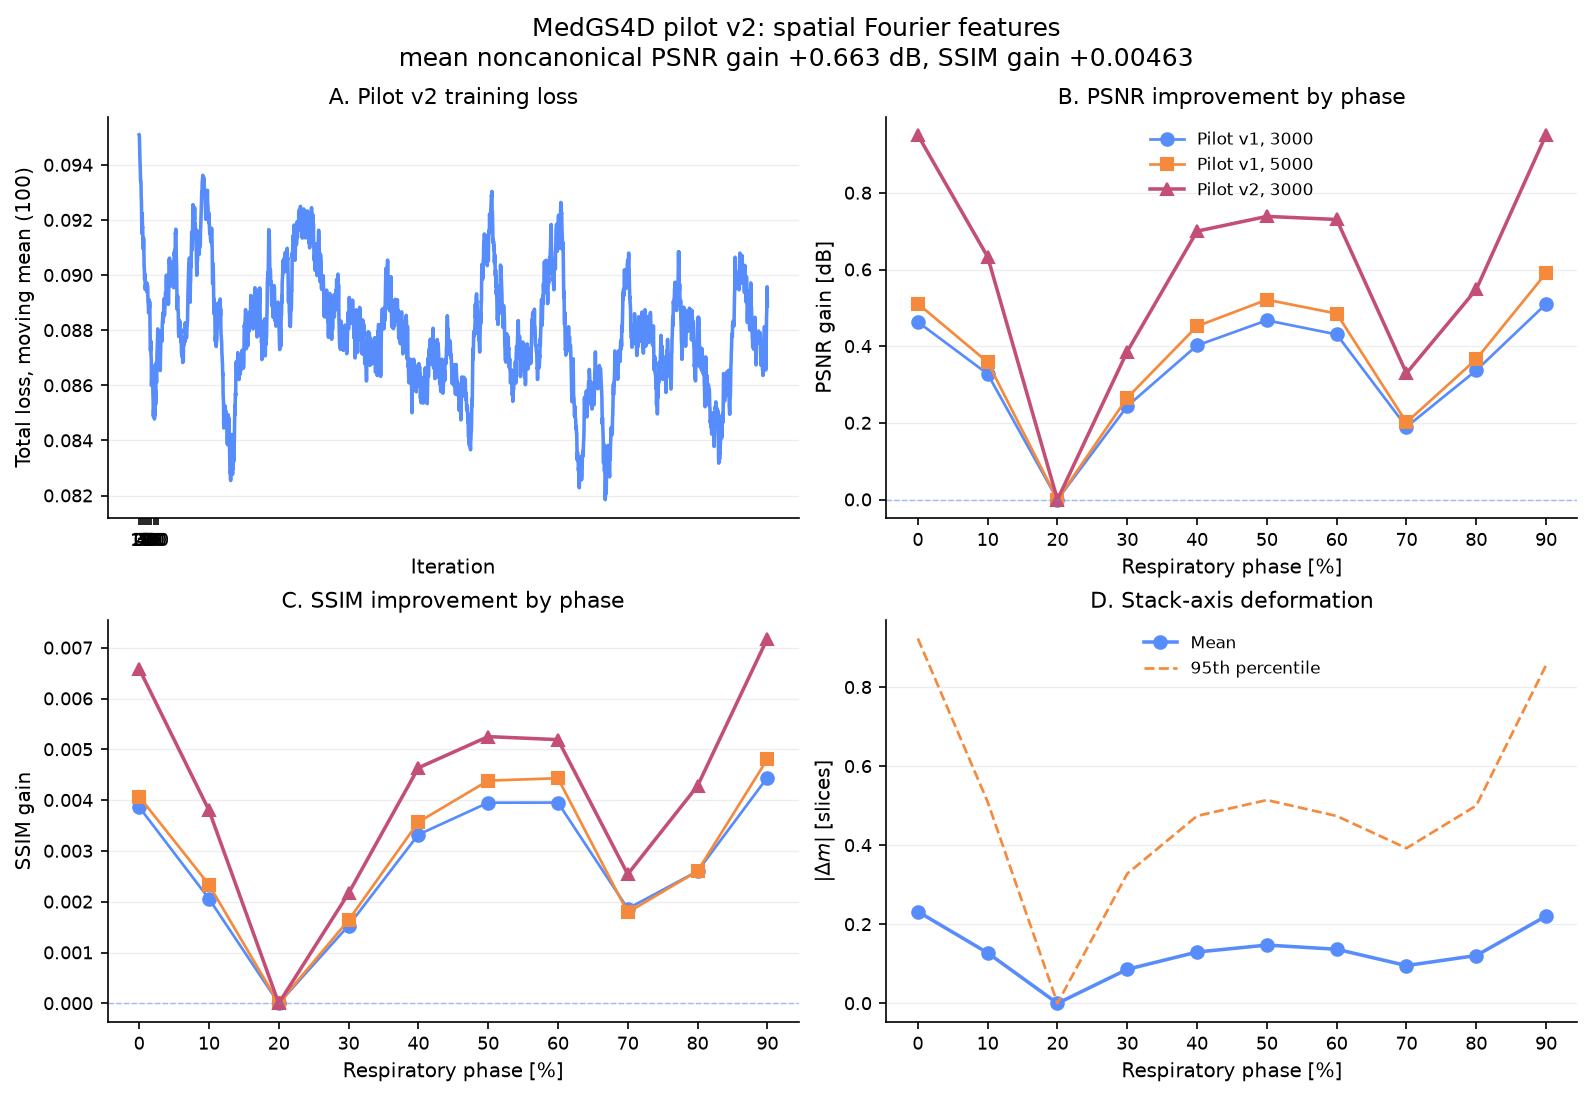

,Model,Iterations,MeanL1,L1Reduction,MeanPSNR,PSNRGain,MeanSSIM,SSIMGain
0,Pilot v1,3000,0.017681,0.000376,29.8162,0.3747,0.789609,0.003065
1,Pilot v1,5000,0.017636,0.000420,29.8584,0.4170,0.789836,0.003292
2,Pilot v2,3000,0.017309,0.000747,30.1047,0.6633,0.791170,0.004627


,PhasePercent,PSNRGain,SSIMGain,L1Reduction
0,0,0.9509,0.006588,0.001322
1,10,0.6332,0.003803,0.000628
2,20,0.0000,0.000000,0.000000
3,30,0.3863,0.002165,0.000349
4,40,0.7002,0.004636,0.000666
5,50,0.7387,0.005251,0.000780
6,60,0.7307,0.005191,0.000755
7,70,0.3297,0.002542,0.000357
8,80,0.5484,0.004281,0.000590
9,90,0.9517,0.007182,0.001276


Pilot v2 evaluation completed.
Noncanonical mean PSNR gain: +0.6633 dB
Noncanonical mean SSIM gain: +0.004627
Noncanonical mean L1 reduction: +0.000747
Evaluation time: 0.19 minutes
Per-slice metrics: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot_v2_spatial_pe4__iter3000/v2_evaluation_per_slice.csv
Per-phase metrics: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot_v2_spatial_pe4__iter3000/v2_evaluation_per_phase.csv
Deformation summary: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__pilot_v2_spatial_pe4__iter3000/v2_deformation_summary.csv
Model comparison: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM1

In [94]:
# Evaluate pilot v2 on the fixed full dataset and compare it with pilot v1.
# Save compact metrics, deformation diagnostics, and one publication-ready PDF.

V1_RUN_ROOT = Path(
    "/home/jovyan/shared/mtm_medgs_stack/results/"
    "phase_conditioned_medgs4d/"
    "patient_117_HM10395"
    "__study_831212264180"
    "__canonical_phase_20_raw"
    "__all_phases"
    "__deform_xz_m"
    "__pilot"
    "__iter5000"
)

V1_PER_SLICE_PATH = (
        V1_RUN_ROOT
        / "dynamic_evaluation_per_slice.csv"
)

V1_CHECKPOINT_OVERALL_PATH = (
        V1_RUN_ROOT
        / "checkpoint_evaluation_overall.csv"
)

V1_CHECKPOINT_PER_PHASE_PATH = (
        V1_RUN_ROOT
        / "checkpoint_evaluation_per_phase.csv"
)

V2_EVALUATION_PER_SLICE_PATH = (
        V2_RUN_ROOT
        / "v2_evaluation_per_slice.csv"
)

V2_EVALUATION_PER_PHASE_PATH = (
        V2_RUN_ROOT
        / "v2_evaluation_per_phase.csv"
)

V2_EVALUATION_OVERALL_PATH = (
        V2_RUN_ROOT
        / "v2_evaluation_overall.json"
)

V2_DEFORMATION_SUMMARY_PATH = (
        V2_RUN_ROOT
        / "v2_deformation_summary.csv"
)

V2_MODEL_COMPARISON_PATH = (
        V2_RUN_ROOT
        / "v2_model_comparison.csv"
)

V2_RESULTS_FIGURE_PATH = (
        V2_RUN_ROOT
        / "v2_compact_results.pdf"
)

required_v2_evaluation_files = [
    V1_PER_SLICE_PATH,
    V1_CHECKPOINT_OVERALL_PATH,
    V1_CHECKPOINT_PER_PHASE_PATH,
    V2_TRAINING_HISTORY_PATH,
    V2_LATEST_CHECKPOINT_PATH,
]

missing_v2_evaluation_files = [
    path
    for path in required_v2_evaluation_files
    if not path.is_file()
]

assert not missing_v2_evaluation_files, (
        "Missing evaluation inputs:\n"
        + "\n".join(
    str(path)
    for path in missing_v2_evaluation_files
)
)

v2_checkpoint_payload = torch.load(
    V2_LATEST_CHECKPOINT_PATH,
    map_location=v2_canonical_xyz.device,
    weights_only=False,
)

v2_deformation_mlp.load_state_dict(
    v2_checkpoint_payload[
        "deformation_mlp_state_dict"
    ],
    strict=True,
)

v2_deformation_mlp.eval()

v1_per_slice = pd.read_csv(
    V1_PER_SLICE_PATH
)

v1_checkpoint_overall = pd.read_csv(
    V1_CHECKPOINT_OVERALL_PATH
)

v1_checkpoint_per_phase = pd.read_csv(
    V1_CHECKPOINT_PER_PHASE_PATH
)

v2_training_history = pd.read_csv(
    V2_TRAINING_HISTORY_PATH
)

baseline_lookup = {
    (
        int(row.PhasePercent),
        int(row.SliceIndex),
    ): {
        "L1": float(
            row.BaselineL1
        ),
        "PSNR": float(
            row.BaselinePSNR
        ),
        "SSIM": float(
            row.BaselineSSIM
        ),
    }
    for row in v1_per_slice.itertuples(
        index=False
    )
}

v2_all_phases = sorted(
    {
        int(
            record[
                "phase_percent"
            ]
        )
        for record in dynamic_all_records
    }
)

v2_evaluation_records_by_phase = {
    phase_percent: sorted(
        [
            record
            for record in dynamic_all_records
            if int(
            record[
                "phase_percent"
            ]
        )
               == phase_percent
        ],
        key=lambda record: int(
            record[
                "slice_index"
            ]
        ),
    )
    for phase_percent in v2_all_phases
}

v2_per_slice_rows = []

v2_evaluation_start_time = (
    time.perf_counter()
)

for phase_percent in v2_all_phases:
    phase_start_time = (
        time.perf_counter()
    )

    if (
            phase_percent
            != V2_CANONICAL_PHASE_PERCENT
    ):
        with torch.no_grad():
            phase_gaussian_view, phase_state = (
                v2_build_phase_deformed_state(
                    respiratory_time=(
                            phase_percent
                            / 100.0
                    ),
                    use_checkpointing=False,
                )
            )

    for record in v2_evaluation_records_by_phase[
        phase_percent
    ]:
        slice_index = int(
            record[
                "slice_index"
            ]
        )

        baseline_metrics = baseline_lookup[
            (
                phase_percent,
                slice_index,
            )
        ]

        if (
                phase_percent
                == V2_CANONICAL_PHASE_PERCENT
        ):
            dynamic_metrics = (
                baseline_metrics
            )

        else:
            camera = canonical_cameras[
                int(
                    record[
                        "camera_index"
                    ]
                )
            ]

            target_image = (
                load_dynamic_target_image(
                    record
                )
            )

            with torch.no_grad():
                render_result = medgs_render(
                    camera,
                    phase_gaussian_view,
                    canonical_pipeline,
                    canonical_background,
                )

                rendered_image = (
                    render_result[
                        "render"
                    ]
                )

                dynamic_metrics = (
                    calculate_reconstruction_metrics(
                        rendered_image=(
                            rendered_image
                        ),
                        target_image=(
                            target_image
                        ),
                    )
                )

            del target_image
            del render_result
            del rendered_image

        v2_per_slice_rows.append(
            {
                "PhasePercent": (
                    phase_percent
                ),
                "SliceIndex": (
                    slice_index
                ),
                "BaselineL1": (
                    baseline_metrics[
                        "L1"
                    ]
                ),
                "DynamicL1": (
                    dynamic_metrics[
                        "L1"
                    ]
                ),
                "L1Reduction": (
                        baseline_metrics[
                            "L1"
                        ]
                        - dynamic_metrics[
                            "L1"
                        ]
                ),
                "BaselinePSNR": (
                    baseline_metrics[
                        "PSNR"
                    ]
                ),
                "DynamicPSNR": (
                    dynamic_metrics[
                        "PSNR"
                    ]
                ),
                "PSNRGain": (
                        dynamic_metrics[
                            "PSNR"
                        ]
                        - baseline_metrics[
                            "PSNR"
                        ]
                ),
                "BaselineSSIM": (
                    baseline_metrics[
                        "SSIM"
                    ]
                ),
                "DynamicSSIM": (
                    dynamic_metrics[
                        "SSIM"
                    ]
                ),
                "SSIMGain": (
                        dynamic_metrics[
                            "SSIM"
                        ]
                        - baseline_metrics[
                            "SSIM"
                        ]
                ),
            }
        )

    if (
            phase_percent
            != V2_CANONICAL_PHASE_PERCENT
    ):
        del phase_gaussian_view
        del phase_state

        torch.cuda.empty_cache()

    print(
        f"Phase {phase_percent:02d}% evaluated in "
        f"{time.perf_counter() - phase_start_time:.1f}s"
    )

v2_per_slice = pd.DataFrame(
    v2_per_slice_rows
)

v2_per_slice.to_csv(
    V2_EVALUATION_PER_SLICE_PATH,
    index=False,
)

v2_per_phase = (
    v2_per_slice
    .groupby(
        "PhasePercent",
        as_index=False,
    )
    .agg(
        SliceCount=(
            "SliceIndex",
            "count",
        ),
        BaselineL1=(
            "BaselineL1",
            "mean",
        ),
        DynamicL1=(
            "DynamicL1",
            "mean",
        ),
        L1Reduction=(
            "L1Reduction",
            "mean",
        ),
        BaselinePSNR=(
            "BaselinePSNR",
            "mean",
        ),
        DynamicPSNR=(
            "DynamicPSNR",
            "mean",
        ),
        PSNRGain=(
            "PSNRGain",
            "mean",
        ),
        BaselineSSIM=(
            "BaselineSSIM",
            "mean",
        ),
        DynamicSSIM=(
            "DynamicSSIM",
            "mean",
        ),
        SSIMGain=(
            "SSIMGain",
            "mean",
        ),
    )
)

v2_per_phase.to_csv(
    V2_EVALUATION_PER_PHASE_PATH,
    index=False,
)

v2_noncanonical = v2_per_slice[
    v2_per_slice[
        "PhasePercent"
    ]
    != V2_CANONICAL_PHASE_PERCENT
    ]

v2_overall = {
    "checkpoint_iteration": int(
        v2_checkpoint_payload[
            "iteration"
        ]
    ),
    "image_count_all_phases": int(
        len(
            v2_per_slice
        )
    ),
    "image_count_noncanonical": int(
        len(
            v2_noncanonical
        )
    ),
    "baseline_mean_l1": float(
        v2_noncanonical[
            "BaselineL1"
        ].mean()
    ),
    "dynamic_mean_l1": float(
        v2_noncanonical[
            "DynamicL1"
        ].mean()
    ),
    "mean_l1_reduction": float(
        v2_noncanonical[
            "L1Reduction"
        ].mean()
    ),
    "baseline_mean_psnr": float(
        v2_noncanonical[
            "BaselinePSNR"
        ].mean()
    ),
    "dynamic_mean_psnr": float(
        v2_noncanonical[
            "DynamicPSNR"
        ].mean()
    ),
    "mean_psnr_gain": float(
        v2_noncanonical[
            "PSNRGain"
        ].mean()
    ),
    "baseline_mean_ssim": float(
        v2_noncanonical[
            "BaselineSSIM"
        ].mean()
    ),
    "dynamic_mean_ssim": float(
        v2_noncanonical[
            "DynamicSSIM"
        ].mean()
    ),
    "mean_ssim_gain": float(
        v2_noncanonical[
            "SSIMGain"
        ].mean()
    ),
    "elapsed_minutes": float(
        (
                time.perf_counter()
                - v2_evaluation_start_time
        )
        / 60.0
    ),
}

V2_EVALUATION_OVERALL_PATH.write_text(
    json.dumps(
        v2_overall,
        indent=2,
    ),
    encoding="utf-8",
)

v2_deformation_rows = []

v2_slice_scale = float(
    len(
        canonical_cameras
    )
    - 1
)

with torch.no_grad():
    diagnostic_spatial_features = (
        v2_spatial_features[
            v2_smoothness_indices
        ]
    )

    diagnostic_canonical_m_logits = (
        v2_canonical_m_logits[
            v2_smoothness_indices
        ]
    )

    diagnostic_canonical_m = (
        v2_canonical_m[
            v2_smoothness_indices
        ]
    )

    for phase_percent in v2_all_phases:
        relative_deformation = (
            v2_predict_relative_deformation(
                respiratory_time=(
                        phase_percent
                        / 100.0
                ),
                spatial_features=(
                    diagnostic_spatial_features
                ),
                use_checkpointing=False,
            )
        )

        delta_x = (
            relative_deformation[
                :,
                0
            ]
        )

        delta_z = (
            relative_deformation[
                :,
                1
            ]
        )

        delta_m_logit = (
            relative_deformation[
                :,
                2:3
            ]
        )

        dynamic_m = torch.sigmoid(
            diagnostic_canonical_m_logits
            + delta_m_logit
        )

        delta_m = (
                dynamic_m
                - diagnostic_canonical_m
        )

        delta_m_slices = (
                delta_m.squeeze(
                    -1
                )
                * v2_slice_scale
        )

        normalized_deformation = (
            v2_normalize_deformation(
                delta_xz=(
                    relative_deformation[
                        :,
                        :2
                    ]
                ),
                delta_m=(
                    delta_m
                ),
            )
        )

        v2_deformation_rows.append(
            {
                "PhasePercent": (
                    phase_percent
                ),
                "DiagnosticGaussianCount": int(
                    relative_deformation.shape[0]
                ),
                "MeanAbsDeltaX": float(
                    delta_x.abs().mean()
                ),
                "P95AbsDeltaX": float(
                    torch.quantile(
                        delta_x.abs(),
                        0.95,
                    )
                ),
                "MeanAbsDeltaZ": float(
                    delta_z.abs().mean()
                ),
                "P95AbsDeltaZ": float(
                    torch.quantile(
                        delta_z.abs(),
                        0.95,
                    )
                ),
                "MeanAbsDeltaMSlices": float(
                    delta_m_slices.abs().mean()
                ),
                "P95AbsDeltaMSlices": float(
                    torch.quantile(
                        delta_m_slices.abs(),
                        0.95,
                    )
                ),
                "MaxAbsDeltaMSlices": float(
                    delta_m_slices.abs().max()
                ),
                "NormalizedDeformationRMS": float(
                    normalized_deformation
                    .square()
                    .mean()
                    .sqrt()
                ),
            }
        )

v2_deformation_summary = pd.DataFrame(
    v2_deformation_rows
)

v2_deformation_summary.to_csv(
    V2_DEFORMATION_SUMMARY_PATH,
    index=False,
)


def v2_select_v1_checkpoint_row(
        iteration: int,
) -> pd.Series:
    selected_rows = (
        v1_checkpoint_overall[
            v1_checkpoint_overall[
                "CheckpointIteration"
            ]
            == iteration
            ]
    )

    assert len(
        selected_rows
    ) == 1

    return selected_rows.iloc[
        0
    ]


v1_iteration_3000 = (
    v2_select_v1_checkpoint_row(
        3000
    )
)

v1_iteration_5000 = (
    v2_select_v1_checkpoint_row(
        5000
    )
)

v2_model_comparison = pd.DataFrame(
    [
        {
            "Model": (
                "Pilot v1"
            ),
            "Iterations": 3000,
            "MeanL1": float(
                v1_iteration_3000[
                    "DynamicL1"
                ]
            ),
            "L1Reduction": float(
                v1_iteration_3000[
                    "L1Reduction"
                ]
            ),
            "MeanPSNR": float(
                v1_iteration_3000[
                    "DynamicPSNR"
                ]
            ),
            "PSNRGain": float(
                v1_iteration_3000[
                    "PSNRGain"
                ]
            ),
            "MeanSSIM": float(
                v1_iteration_3000[
                    "DynamicSSIM"
                ]
            ),
            "SSIMGain": float(
                v1_iteration_3000[
                    "SSIMGain"
                ]
            ),
        },
        {
            "Model": (
                "Pilot v1"
            ),
            "Iterations": 5000,
            "MeanL1": float(
                v1_iteration_5000[
                    "DynamicL1"
                ]
            ),
            "L1Reduction": float(
                v1_iteration_5000[
                    "L1Reduction"
                ]
            ),
            "MeanPSNR": float(
                v1_iteration_5000[
                    "DynamicPSNR"
                ]
            ),
            "PSNRGain": float(
                v1_iteration_5000[
                    "PSNRGain"
                ]
            ),
            "MeanSSIM": float(
                v1_iteration_5000[
                    "DynamicSSIM"
                ]
            ),
            "SSIMGain": float(
                v1_iteration_5000[
                    "SSIMGain"
                ]
            ),
        },
        {
            "Model": (
                "Pilot v2"
            ),
            "Iterations": (
                V2_ITERATIONS
            ),
            "MeanL1": (
                v2_overall[
                    "dynamic_mean_l1"
                ]
            ),
            "L1Reduction": (
                v2_overall[
                    "mean_l1_reduction"
                ]
            ),
            "MeanPSNR": (
                v2_overall[
                    "dynamic_mean_psnr"
                ]
            ),
            "PSNRGain": (
                v2_overall[
                    "mean_psnr_gain"
                ]
            ),
            "MeanSSIM": (
                v2_overall[
                    "dynamic_mean_ssim"
                ]
            ),
            "SSIMGain": (
                v2_overall[
                    "mean_ssim_gain"
                ]
            ),
        },
    ]
)

v2_model_comparison.to_csv(
    V2_MODEL_COMPARISON_PATH,
    index=False,
)

plot_phases = v2_all_phases


def v2_phase_metric_series(
        frame: pd.DataFrame,
        metric_name: str,
) -> np.ndarray:
    values = (
        frame
        .set_index(
            "PhasePercent"
        )[
            metric_name
        ]
        .reindex(
            plot_phases
        )
        .fillna(
            0.0
        )
    )

    return values.to_numpy()


v1_phase_3000 = (
    v1_checkpoint_per_phase[
        v1_checkpoint_per_phase[
            "CheckpointIteration"
        ]
        == 3000
        ]
)

v1_phase_5000 = (
    v1_checkpoint_per_phase[
        v1_checkpoint_per_phase[
            "CheckpointIteration"
        ]
        == 5000
        ]
)

v2_loss_window = 100

v2_smoothed_total_loss = (
    v2_training_history[
        "TotalLoss"
    ]
    .rolling(
        window=v2_loss_window,
        min_periods=1,
        center=True,
    )
    .mean()
)

with plt.rc_context(
        {
            "font.size": 9.5,
            "axes.titlesize": 10.5,
            "axes.labelsize": 9.5,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
            "legend.fontsize": 8,
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
):
    figure, axes = plt.subplots(
        2,
        2,
        figsize=(10.5, 7.2),
        constrained_layout=True,
    )

    axes = axes.ravel()

    axes[0].plot(
        v2_training_history[
            "Iteration"
        ],
        v2_smoothed_total_loss,
        linewidth=1.7,
    )

    axes[0].set_title(
        "A. Pilot v2 training loss"
    )

    axes[0].set_xlabel(
        "Iteration"
    )

    axes[0].set_ylabel(
        f"Total loss, moving mean ({v2_loss_window})"
    )

    axes[1].plot(
        plot_phases,
        v2_phase_metric_series(
            v1_phase_3000,
            "PSNRGain",
        ),
        marker="o",
        linewidth=1.3,
        label="Pilot v1, 3000",
    )

    axes[1].plot(
        plot_phases,
        v2_phase_metric_series(
            v1_phase_5000,
            "PSNRGain",
        ),
        marker="s",
        linewidth=1.3,
        label="Pilot v1, 5000",
    )

    axes[1].plot(
        plot_phases,
        v2_phase_metric_series(
            v2_per_phase,
            "PSNRGain",
        ),
        marker="^",
        linewidth=1.7,
        label="Pilot v2, 3000",
    )

    axes[1].axhline(
        0.0,
        linewidth=0.7,
        linestyle="--",
        alpha=0.5,
    )

    axes[1].set_title(
        "B. PSNR improvement by phase"
    )

    axes[1].set_xlabel(
        "Respiratory phase [%]"
    )

    axes[1].set_ylabel(
        "PSNR gain [dB]"
    )

    axes[1].legend(
        frameon=False
    )

    axes[2].plot(
        plot_phases,
        v2_phase_metric_series(
            v1_phase_3000,
            "SSIMGain",
        ),
        marker="o",
        linewidth=1.3,
        label="Pilot v1, 3000",
    )

    axes[2].plot(
        plot_phases,
        v2_phase_metric_series(
            v1_phase_5000,
            "SSIMGain",
        ),
        marker="s",
        linewidth=1.3,
        label="Pilot v1, 5000",
    )

    axes[2].plot(
        plot_phases,
        v2_phase_metric_series(
            v2_per_phase,
            "SSIMGain",
        ),
        marker="^",
        linewidth=1.7,
        label="Pilot v2, 3000",
    )

    axes[2].axhline(
        0.0,
        linewidth=0.7,
        linestyle="--",
        alpha=0.5,
    )

    axes[2].set_title(
        "C. SSIM improvement by phase"
    )

    axes[2].set_xlabel(
        "Respiratory phase [%]"
    )

    axes[2].set_ylabel(
        "SSIM gain"
    )

    axes[3].plot(
        v2_deformation_summary[
            "PhasePercent"
        ],
        v2_deformation_summary[
            "MeanAbsDeltaMSlices"
        ],
        marker="o",
        linewidth=1.7,
        label="Mean",
    )

    axes[3].plot(
        v2_deformation_summary[
            "PhasePercent"
        ],
        v2_deformation_summary[
            "P95AbsDeltaMSlices"
        ],
        linestyle="--",
        linewidth=1.3,
        label="95th percentile",
    )

    axes[3].set_title(
        "D. Stack-axis deformation"
    )

    axes[3].set_xlabel(
        "Respiratory phase [%]"
    )

    axes[3].set_ylabel(
        r"$|\Delta m|$ [slices]"
    )

    axes[3].legend(
        frameon=False
    )

    for axis in axes:
        axis.grid(
            axis="y",
            linewidth=0.6,
            alpha=0.22,
        )

        axis.spines[
            "top"
        ].set_visible(False)

        axis.spines[
            "right"
        ].set_visible(False)

        axis.set_xticks(
            plot_phases
        )

    figure.suptitle(
        (
            "MedGS4D pilot v2: spatial Fourier features\n"
            f"mean noncanonical PSNR gain "
            f"{v2_overall['mean_psnr_gain']:+.3f} dB, "
            f"SSIM gain "
            f"{v2_overall['mean_ssim_gain']:+.5f}"
        ),
        fontsize=12,
    )

    figure.savefig(
        V2_RESULTS_FIGURE_PATH,
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()

    plt.close(
        figure
    )

display(
    v2_model_comparison.round(
        {
            "MeanL1": 6,
            "L1Reduction": 6,
            "MeanPSNR": 4,
            "PSNRGain": 4,
            "MeanSSIM": 6,
            "SSIMGain": 6,
        }
    )
)

display(
    v2_per_phase[
        [
            "PhasePercent",
            "PSNRGain",
            "SSIMGain",
            "L1Reduction",
        ]
    ].round(
        {
            "PSNRGain": 4,
            "SSIMGain": 6,
            "L1Reduction": 6,
        }
    )
)

print(
    "Pilot v2 evaluation completed."
)

print(
    f"Noncanonical mean PSNR gain: "
    f"{v2_overall['mean_psnr_gain']:+.4f} dB"
)

print(
    f"Noncanonical mean SSIM gain: "
    f"{v2_overall['mean_ssim_gain']:+.6f}"
)

print(
    f"Noncanonical mean L1 reduction: "
    f"{v2_overall['mean_l1_reduction']:+.6f}"
)

print(
    f"Evaluation time: "
    f"{v2_overall['elapsed_minutes']:.2f} minutes"
)

print(
    f"Per-slice metrics: "
    f"{V2_EVALUATION_PER_SLICE_PATH}"
)

print(
    f"Per-phase metrics: "
    f"{V2_EVALUATION_PER_PHASE_PATH}"
)

print(
    f"Deformation summary: "
    f"{V2_DEFORMATION_SUMMARY_PATH}"
)

print(
    f"Model comparison: "
    f"{V2_MODEL_COMPARISON_PATH}"
)

print(
    f"Figure: "
    f"{V2_RESULTS_FIGURE_PATH}"
)

In [97]:
# Show the selected ground-truth CT slice and its Pilot v2 reconstruction.
# Keep persistent image widgets and rebuild the Gaussian state only when
# the respiratory phase changes.
#
# Creates an interactive two-panel viewer and writes no files.


v2_deformation_mlp.eval()

v2_viewer_record_lookup = {
    (
        int(record["phase_percent"]),
        int(record["slice_index"]),
    ): record
    for record in dynamic_all_records
}

v2_viewer_phase_percents = sorted(
    {
        int(record["phase_percent"])
        for record in dynamic_all_records
    }
)

v2_viewer_phase_state = {
    "phase_percent": None,
    "gaussian_view": None,
}


def v2_tensor_image_to_png(
        image_tensor: torch.Tensor,
) -> bytes:
    """Convert the first image channel to PNG bytes."""

    image_array = (
        image_tensor[0]
        .detach()
        .clamp(0.0, 1.0)
        .mul(255.0)
        .round()
        .to(torch.uint8)
        .cpu()
        .numpy()
    )

    buffer = io.BytesIO()

    Image.fromarray(
        image_array
    ).save(
        buffer,
        format="PNG",
    )

    return buffer.getvalue()


def v2_get_phase_gaussian_view(
        phase_percent: int,
) -> V2PhaseDeformedGaussianView:
    """Build the Pilot v2 Gaussian state only when the phase changes."""

    phase_percent = int(
        phase_percent
    )

    if (
            v2_viewer_phase_state[
                "phase_percent"
            ]
            != phase_percent
    ):
        v2_viewer_phase_state[
            "gaussian_view"
        ] = None

        torch.cuda.empty_cache()

        with torch.no_grad():
            gaussian_view, _ = (
                v2_build_phase_deformed_state(
                    respiratory_time=(
                            phase_percent
                            / 100.0
                    ),
                    use_checkpointing=False,
                )
            )

        v2_viewer_phase_state[
            "phase_percent"
        ] = phase_percent

        v2_viewer_phase_state[
            "gaussian_view"
        ] = gaussian_view

    return v2_viewer_phase_state[
        "gaussian_view"
    ]


v2_ground_truth_title = widgets.HTML()

v2_reconstruction_title = widgets.HTML()

v2_viewer_status = widgets.HTML()

v2_ground_truth_image = widgets.Image(
    format="png",
    width=512,
    height=512,
)

v2_reconstruction_image = widgets.Image(
    format="png",
    width=512,
    height=512,
)

v2_phase_widget = widgets.SelectionSlider(
    options=[
        int(phase_percent)
        for phase_percent
        in v2_viewer_phase_percents
    ],
    value=50,
    description="Phase:",
    continuous_update=False,
)

v2_slice_widget = widgets.IntSlider(
    value=len(
        canonical_cameras
    ) // 2,
    min=0,
    max=len(
        canonical_cameras
    ) - 1,
    step=1,
    description="Slice:",
    continuous_update=False,
)

v2_viewer_request_state = {
    "request_id": 0,
}


def refresh_v2_two_panel_viewer(
        change=None,
) -> None:
    """Render the currently selected phase and slice."""

    v2_viewer_request_state[
        "request_id"
    ] += 1

    request_id = (
        v2_viewer_request_state[
            "request_id"
        ]
    )

    phase_percent = int(
        v2_phase_widget.value
    )

    slice_index = int(
        v2_slice_widget.value
    )

    v2_phase_widget.disabled = True
    v2_slice_widget.disabled = True

    v2_viewer_status.value = (
        "<i>Rendering selected phase...</i>"
    )

    try:
        record = (
            v2_viewer_record_lookup[
                (
                    phase_percent,
                    slice_index,
                )
            ]
        )

        camera = canonical_cameras[
            int(
                record[
                    "camera_index"
                ]
            )
        ]

        with torch.no_grad():
            target_image = (
                load_dynamic_target_image(
                    record
                )
            )

            phase_gaussian_view = (
                v2_get_phase_gaussian_view(
                    phase_percent
                )
            )

            render_result = medgs_render(
                camera,
                phase_gaussian_view,
                canonical_pipeline,
                canonical_background,
            )

            reconstructed_image = (
                render_result[
                    "render"
                ]
            )

            metrics = (
                calculate_reconstruction_metrics(
                    rendered_image=(
                        reconstructed_image
                    ),
                    target_image=(
                        target_image
                    ),
                )
            )

            target_png = (
                v2_tensor_image_to_png(
                    target_image
                )
            )

            reconstruction_png = (
                v2_tensor_image_to_png(
                    reconstructed_image
                )
            )

        if (
                request_id
                == v2_viewer_request_state[
            "request_id"
        ]
        ):
            v2_ground_truth_image.value = (
                target_png
            )

            v2_reconstruction_image.value = (
                reconstruction_png
            )

            canonical_label = (
                " — canonical"
                if phase_percent == 20
                else ""
            )

            v2_ground_truth_title.value = (
                "<div style='text-align:center'>"
                "<b>Ground truth CT</b><br>"
                f"Phase {phase_percent}%"
                f"{canonical_label}, "
                f"slice {slice_index}"
                "</div>"
            )

            v2_reconstruction_title.value = (
                "<div style='text-align:center'>"
                "<b>MedGS4D Pilot v2</b><br>"
                f"Conditioned on phase "
                f"{phase_percent}%<br>"
                f"PSNR {metrics['PSNR']:.2f} dB, "
                f"SSIM {metrics['SSIM']:.4f}"
                "</div>"
            )

            v2_viewer_status.value = (
                "<div style='text-align:center'>"
                f"Coordinate: "
                f"{record['slice_coordinate']:.1f} mm"
                "</div>"
            )

    finally:
        v2_phase_widget.disabled = False
        v2_slice_widget.disabled = False

    del target_image
    del render_result
    del reconstructed_image

    torch.cuda.empty_cache()


v2_phase_widget.observe(
    refresh_v2_two_panel_viewer,
    names="value",
)

v2_slice_widget.observe(
    refresh_v2_two_panel_viewer,
    names="value",
)

v2_viewer_controls = widgets.HBox(
    [
        v2_phase_widget,
        v2_slice_widget,
    ]
)

v2_viewer_images = widgets.HBox(
    [
        widgets.VBox(
            [
                v2_ground_truth_title,
                v2_ground_truth_image,
            ]
        ),
        widgets.VBox(
            [
                v2_reconstruction_title,
                v2_reconstruction_image,
            ]
        ),
    ],
    layout=widgets.Layout(
        justify_content="space-around",
        width="100%",
    ),
)

display(
    widgets.VBox(
        [
            v2_viewer_controls,
            v2_viewer_status,
            v2_viewer_images,
        ]
    )
)

refresh_v2_two_panel_viewer()

In [98]:
# Show one selected slice across all respiratory phases for Pilot v2.
# Top rows display ground-truth CT targets, bottom rows display
# spatially encoded MedGS4D Pilot v2 reconstructions.
#
# Creates an interactive all-phases viewer and writes no files.


assert (
        "v2_get_phase_gaussian_view"
        in globals()
), (
    "Run the Pilot v2 two-panel viewer first."
)

v2_all_phase_slice_slider = widgets.IntSlider(
    value=len(
        canonical_cameras
    ) // 2,
    min=0,
    max=len(
        canonical_cameras
    ) - 1,
    step=1,
    description="Slice:",
    continuous_update=False,
    layout=widgets.Layout(
        width="700px"
    ),
)

v2_all_phase_output = widgets.Output()


def draw_v2_all_phases_for_slice(
        change=None,
) -> None:
    """Render the selected slice for all phases with Pilot v2."""

    slice_index = int(
        v2_all_phase_slice_slider.value
    )

    phase_list = [
        int(
            phase_percent
        )
        for phase_percent
        in v2_viewer_phase_percents
    ]

    v2_all_phase_slice_slider.disabled = True

    try:
        with v2_all_phase_output:
            clear_output(
                wait=True
            )

            fig, axes = plt.subplots(
                4,
                5,
                figsize=(18, 14),
            )

            for axis in axes.ravel():
                axis.axis(
                    "off"
                )

            for (
                    phase_position,
                    phase_percent,
            ) in enumerate(
                phase_list
            ):
                row_block = (
                        phase_position
                        // 5
                )

                column_index = (
                        phase_position
                        % 5
                )

                gt_axis = axes[
                    row_block,
                    column_index,
                ]

                reconstruction_axis = axes[
                    row_block + 2,
                    column_index,
                ]

                record = (
                    v2_viewer_record_lookup[
                        (
                            phase_percent,
                            slice_index,
                        )
                    ]
                )

                camera = canonical_cameras[
                    int(
                        record[
                            "camera_index"
                        ]
                    )
                ]

                with torch.no_grad():
                    target_image = (
                        load_dynamic_target_image(
                            record
                        )
                    )

                    phase_gaussian_view = (
                        v2_get_phase_gaussian_view(
                            phase_percent
                        )
                    )

                    render_result = medgs_render(
                        camera,
                        phase_gaussian_view,
                        canonical_pipeline,
                        canonical_background,
                    )

                    reconstructed_image = (
                        render_result[
                            "render"
                        ]
                    )

                    metrics = (
                        calculate_reconstruction_metrics(
                            rendered_image=(
                                reconstructed_image
                            ),
                            target_image=(
                                target_image
                            ),
                        )
                    )

                    target_np = (
                        target_image[
                            0
                        ]
                        .detach()
                        .clamp(
                            0.0,
                            1.0,
                        )
                        .cpu()
                        .numpy()
                    )

                    reconstructed_np = (
                        reconstructed_image[
                            0
                        ]
                        .detach()
                        .clamp(
                            0.0,
                            1.0,
                        )
                        .cpu()
                        .numpy()
                    )

                gt_axis.imshow(
                    target_np,
                    cmap="gray",
                    vmin=0.0,
                    vmax=1.0,
                )

                canonical_label = (
                    " — canonical"
                    if phase_percent == 20
                    else ""
                )

                gt_axis.set_title(
                    (
                        f"GT {phase_percent}%"
                        f"{canonical_label}\n"
                        f"slice {slice_index} | "
                        f"{record['slice_coordinate']:.1f} mm"
                    ),
                    fontsize=10,
                )

                reconstruction_axis.imshow(
                    reconstructed_np,
                    cmap="gray",
                    vmin=0.0,
                    vmax=1.0,
                )

                reconstruction_axis.set_title(
                    (
                        f"Pilot v2 {phase_percent}%\n"
                        f"PSNR {metrics['PSNR']:.2f} | "
                        f"SSIM {metrics['SSIM']:.4f}"
                    ),
                    fontsize=10,
                )

                del target_image
                del render_result
                del reconstructed_image

            fig.suptitle(
                (
                    f"All respiratory phases for slice "
                    f"{slice_index}\n"
                    "Top: ground truth CT | "
                    "Bottom: MedGS4D Pilot v2"
                ),
                fontsize=16,
            )

            plt.tight_layout(
                rect=[
                    0,
                    0,
                    1,
                    0.95,
                ]
            )

            plt.show()

            plt.close(
                fig
            )

    finally:
        v2_all_phase_slice_slider.disabled = False

        torch.cuda.empty_cache()


v2_all_phase_slice_slider.observe(
    draw_v2_all_phases_for_slice,
    names="value",
)

display(
    widgets.VBox(
        [
            v2_all_phase_slice_slider,
            v2_all_phase_output,
        ]
    )
)

draw_v2_all_phases_for_slice()

# Extended MedGS4D Experiments

This section compares four longer training variants built on the frozen canonical MedGS representation at respiratory phase 20%.




## 1. Full-phase continuation

The Pilot v2 model is continued from iteration 3000 to iteration 7000.

**Training phases:** 0%, 10%, 30%, 40%, 50%, 60%, 70%, 80%, and 90%.

The architecture is unchanged: spatial Fourier features, a four-layer MLP with width 256, and exact zero deformation at phase 20%.

**Goal:** determine how much additional reconstruction quality can be obtained from the current best-performing model without changing its architecture.



In [99]:
# 1. Full-phase v2 long — continue Pilot v2 from 3,000 to 7,000 iterations on all noncanonical phases.

LONG_V2_RUN_LABEL = (
    "full_phase_v2_long"
)

LONG_V2_INITIAL_ITERATION = 3000
LONG_V2_TARGET_ITERATION = 7000

LONG_V2_ADDITIONAL_ITERATIONS = (
        LONG_V2_TARGET_ITERATION
        - LONG_V2_INITIAL_ITERATION
)

LONG_V2_LEARNING_RATE = 5e-4

LONG_V2_LOG_EVERY = 25
LONG_V2_CHECKPOINT_EVERY = 250

LONG_V2_MAX_GRADIENT_NORM = 10.0

LONG_V2_SEED = 1042

LONG_V2_RUN_ROOT = (
        V2_RESULTS_ROOT
        / "phase_conditioned_medgs4d"
        / (
            "patient_117_HM10395"
            "__study_831212264180"
            "__canonical_phase_20_raw"
            "__all_phases"
            "__deform_xz_m"
            "__full_phase_v2_long"
            "__iter7000"
        )
)

LONG_V2_CHECKPOINT_DIRECTORY = (
        LONG_V2_RUN_ROOT
        / "checkpoints"
)

LONG_V2_CONFIG_PATH = (
        LONG_V2_RUN_ROOT
        / "long_v2_config.json"
)

LONG_V2_SAMPLING_PLAN_PATH = (
        LONG_V2_RUN_ROOT
        / "long_v2_sampling_plan.csv"
)

LONG_V2_TRAINING_HISTORY_PATH = (
        LONG_V2_RUN_ROOT
        / "long_v2_training_history.csv"
)

LONG_V2_TRAINING_SUMMARY_PATH = (
        LONG_V2_RUN_ROOT
        / "long_v2_training_summary.csv"
)

LONG_V2_COMPLETION_PATH = (
        LONG_V2_RUN_ROOT
        / "long_v2_completion.json"
)

LONG_V2_LATEST_CHECKPOINT_PATH = (
        LONG_V2_CHECKPOINT_DIRECTORY
        / "deformation_latest.pth"
)

required_long_v2_objects = [
    "v2_deformation_mlp",
    "v2_build_phase_deformed_state",
    "v2_calculate_temporal_smoothness",
    "v2_normalize_deformation",
    "v2_training_phase_percents",
    "v2_records_by_phase",
    "v2_all_phase_percents",
    "V2_LATEST_CHECKPOINT_PATH",
    "V2_TRAINING_HISTORY_PATH",
    "canonical_cameras",
    "canonical_pipeline",
    "canonical_background",
    "load_dynamic_target_image",
    "medgs_render",
    "l1_loss",
    "ssim",
]

missing_long_v2_objects = [
    object_name
    for object_name
    in required_long_v2_objects
    if object_name not in globals()
]

assert not missing_long_v2_objects, (
        "Required notebook objects are missing: "
        + ", ".join(
    missing_long_v2_objects
)
)

assert V2_LATEST_CHECKPOINT_PATH.is_file(), (
    "Pilot v2 checkpoint not found: "
    f"{V2_LATEST_CHECKPOINT_PATH}"
)

assert V2_TRAINING_HISTORY_PATH.is_file(), (
    "Pilot v2 training history not found: "
    f"{V2_TRAINING_HISTORY_PATH}"
)

LONG_V2_RUN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

LONG_V2_CHECKPOINT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

if (
        LONG_V2_LATEST_CHECKPOINT_PATH.is_file()
        and not LONG_V2_SAMPLING_PLAN_PATH.is_file()
):
    raise RuntimeError(
        "A continuation checkpoint exists, but "
        "the corresponding sampling plan is missing."
    )

long_v2_record_lookup = {
    (
        int(record["phase_percent"]),
        int(record["slice_index"]),
    ): record
    for record in dynamic_all_records
}

if LONG_V2_SAMPLING_PLAN_PATH.is_file():
    long_v2_sampling_plan = pd.read_csv(
        LONG_V2_SAMPLING_PLAN_PATH
    )

else:
    long_v2_rng = np.random.default_rng(
        LONG_V2_SEED
    )

    long_v2_phase_sequence = []

    while len(
            long_v2_phase_sequence
    ) < LONG_V2_ADDITIONAL_ITERATIONS:
        phase_block = np.asarray(
            v2_training_phase_percents,
            dtype=np.int64,
        )

        long_v2_rng.shuffle(
            phase_block
        )

        long_v2_phase_sequence.extend(
            phase_block.tolist()
        )

    long_v2_phase_sequence = (
        long_v2_phase_sequence[
            :LONG_V2_ADDITIONAL_ITERATIONS
        ]
    )

    long_v2_slice_orders = {
        phase_percent: np.empty(
            0,
            dtype=np.int64,
        )
        for phase_percent
        in v2_training_phase_percents
    }

    long_v2_slice_cursors = {
        phase_percent: 0
        for phase_percent
        in v2_training_phase_percents
    }


    def long_v2_next_record(
            phase_percent: int,
    ):
        """Return the next slice from a shuffled per-phase cycle."""

        phase_records = (
            v2_records_by_phase[
                phase_percent
            ]
        )

        if (
                long_v2_slice_cursors[
                    phase_percent
                ]
                >= len(
            long_v2_slice_orders[
                phase_percent
            ]
        )
        ):
            long_v2_slice_orders[
                phase_percent
            ] = long_v2_rng.permutation(
                len(
                    phase_records
                )
            )

            long_v2_slice_cursors[
                phase_percent
            ] = 0

        selected_position = int(
            long_v2_slice_orders[
                phase_percent
            ][
                long_v2_slice_cursors[
                    phase_percent
                ]
            ]
        )

        long_v2_slice_cursors[
            phase_percent
        ] += 1

        return phase_records[
            selected_position
        ]


    long_v2_sampling_rows = []

    for (
            iteration,
            phase_percent,
    ) in enumerate(
        long_v2_phase_sequence,
        start=(
                LONG_V2_INITIAL_ITERATION
                + 1
        ),
    ):
        selected_record = (
            long_v2_next_record(
                int(
                    phase_percent
                )
            )
        )

        all_phase_position = (
            v2_all_phase_percents.index(
                int(
                    phase_percent
                )
            )
        )

        previous_phase = int(
            v2_all_phase_percents[
                (
                        all_phase_position
                        - 1
                )
                % len(
                    v2_all_phase_percents
                )
                ]
        )

        next_phase = int(
            v2_all_phase_percents[
                (
                        all_phase_position
                        + 1
                )
                % len(
                    v2_all_phase_percents
                )
                ]
        )

        neighbor_phase_percent = (
            previous_phase
            if iteration % 2 == 0
            else next_phase
        )

        long_v2_sampling_rows.append(
            {
                "Iteration": (
                    iteration
                ),
                "PhasePercent": int(
                    phase_percent
                ),
                "SliceIndex": int(
                    selected_record[
                        "slice_index"
                    ]
                ),
                "CameraIndex": int(
                    selected_record[
                        "camera_index"
                    ]
                ),
                "NeighborPhasePercent": (
                    neighbor_phase_percent
                ),
            }
        )

    long_v2_sampling_plan = (
        pd.DataFrame(
            long_v2_sampling_rows
        )
    )

    long_v2_sampling_plan.to_csv(
        LONG_V2_SAMPLING_PLAN_PATH,
        index=False,
    )

expected_long_v2_iterations = set(
    range(
        LONG_V2_INITIAL_ITERATION + 1,
        LONG_V2_TARGET_ITERATION + 1,
    )
)

actual_long_v2_iterations = set(
    long_v2_sampling_plan[
        "Iteration"
    ].astype(
        int
    )
)

assert (
        actual_long_v2_iterations
        == expected_long_v2_iterations
), (
    "The continuation sampling plan does "
    "not cover iterations 3001–7000 exactly."
)

long_v2_sampling_by_iteration = {}

for row in long_v2_sampling_plan.itertuples(
        index=False
):
    phase_percent = int(
        row.PhasePercent
    )

    slice_index = int(
        row.SliceIndex
    )

    record_key = (
        phase_percent,
        slice_index,
    )

    assert record_key in long_v2_record_lookup

    long_v2_sampling_by_iteration[
        int(
            row.Iteration
        )
    ] = {
        "record": (
            long_v2_record_lookup[
                record_key
            ]
        ),
        "neighbor_phase_percent": int(
            row.NeighborPhasePercent
        ),
    }

long_v2_optimizer = torch.optim.Adam(
    v2_deformation_mlp.parameters(),
    lr=LONG_V2_LEARNING_RATE,
)

if LONG_V2_LATEST_CHECKPOINT_PATH.is_file():
    long_v2_resume_checkpoint_path = (
        LONG_V2_LATEST_CHECKPOINT_PATH
    )

    long_v2_resume_source = (
        "existing long-run checkpoint"
    )

else:
    long_v2_resume_checkpoint_path = (
        V2_LATEST_CHECKPOINT_PATH
    )

    long_v2_resume_source = (
        "Pilot v2 checkpoint"
    )

long_v2_checkpoint_payload = torch.load(
    long_v2_resume_checkpoint_path,
    map_location=(
        v2_canonical_xyz.device
    ),
    weights_only=False,
)

LONG_V2_START_ITERATION = int(
    long_v2_checkpoint_payload[
        "iteration"
    ]
)

assert (
        LONG_V2_INITIAL_ITERATION
        <= LONG_V2_START_ITERATION
        <= LONG_V2_TARGET_ITERATION
), (
    "Unexpected continuation checkpoint "
    f"iteration: {LONG_V2_START_ITERATION}"
)

v2_deformation_mlp.load_state_dict(
    long_v2_checkpoint_payload[
        "deformation_mlp_state_dict"
    ],
    strict=True,
)

if (
        "optimizer_state_dict"
        in long_v2_checkpoint_payload
):
    long_v2_optimizer.load_state_dict(
        long_v2_checkpoint_payload[
            "optimizer_state_dict"
        ]
    )

for parameter_group in (
        long_v2_optimizer.param_groups
):
    parameter_group[
        "lr"
    ] = LONG_V2_LEARNING_RATE

if LONG_V2_TRAINING_HISTORY_PATH.is_file():
    long_v2_training_history = pd.read_csv(
        LONG_V2_TRAINING_HISTORY_PATH
    )

else:
    long_v2_training_history = pd.read_csv(
        V2_TRAINING_HISTORY_PATH
    )

long_v2_training_history[
    "Iteration"
] = pd.to_numeric(
    long_v2_training_history[
        "Iteration"
    ],
    errors="raise",
).astype(
    int
)

long_v2_training_history = (
    long_v2_training_history[
        long_v2_training_history[
            "Iteration"
        ]
        <= LONG_V2_START_ITERATION
        ]
    .sort_values(
        "Iteration"
    )
    .drop_duplicates(
        subset=[
            "Iteration"
        ],
        keep="last",
    )
    .reset_index(
        drop=True
    )
)

long_v2_training_history.to_csv(
    LONG_V2_TRAINING_HISTORY_PATH,
    index=False,
)

long_v2_training_history_rows = (
    long_v2_training_history.to_dict(
        orient="records"
    )
)

long_v2_config = {
    "run_label": (
        LONG_V2_RUN_LABEL
    ),
    "parent_run": str(
        V2_RUN_ROOT
    ),
    "initial_checkpoint": str(
        V2_LATEST_CHECKPOINT_PATH
    ),
    "resume_checkpoint": str(
        long_v2_resume_checkpoint_path
    ),
    "resume_source": (
        long_v2_resume_source
    ),
    "start_iteration": (
        LONG_V2_START_ITERATION
    ),
    "target_iteration": (
        LONG_V2_TARGET_ITERATION
    ),
    "additional_iterations": (
        LONG_V2_ADDITIONAL_ITERATIONS
    ),
    "training_phases": [
        int(
            phase_percent
        )
        for phase_percent
        in v2_training_phase_percents
    ],
    "canonical_phase_percent": (
        V2_CANONICAL_PHASE_PERCENT
    ),
    "learning_rate": (
        LONG_V2_LEARNING_RATE
    ),
    "hidden_dim": (
        V2_MLP_HIDDEN_DIM
    ),
    "hidden_layers": (
        V2_MLP_HIDDEN_LAYERS
    ),
    "spatial_encoding_frequencies": (
        V2_SPATIAL_ENCODING_FREQUENCIES
    ),
    "phase_encoding_frequencies": (
        V2_PHASE_ENCODING_FREQUENCIES
    ),
    "magnitude_weight": (
        V2_MAGNITUDE_WEIGHT
    ),
    "smoothness_weight": (
        V2_SMOOTHNESS_WEIGHT
    ),
    "checkpoint_every": (
        LONG_V2_CHECKPOINT_EVERY
    ),
    "log_every": (
        LONG_V2_LOG_EVERY
    ),
    "seed": (
        LONG_V2_SEED
    ),
    "output_directory": str(
        LONG_V2_RUN_ROOT
    ),
}

LONG_V2_CONFIG_PATH.write_text(
    json.dumps(
        long_v2_config,
        indent=2,
    ),
    encoding="utf-8",
)


def long_v2_save_checkpoint(
        iteration: int,
        checkpoint_path: Path,
) -> None:
    """Save the long-run model and optimizer state."""

    torch.save(
        {
            "iteration": (
                iteration
            ),
            "deformation_mlp_state_dict": (
                v2_deformation_mlp
                .state_dict()
            ),
            "optimizer_state_dict": (
                long_v2_optimizer
                .state_dict()
            ),
            "config": (
                long_v2_config
            ),
        },
        checkpoint_path,
    )


if not LONG_V2_LATEST_CHECKPOINT_PATH.is_file():
    long_v2_initial_checkpoint_path = (
            LONG_V2_CHECKPOINT_DIRECTORY
            / (
                "deformation_iter_"
                f"{LONG_V2_INITIAL_ITERATION:06d}"
                ".pth"
            )
    )

    long_v2_save_checkpoint(
        iteration=(
            LONG_V2_INITIAL_ITERATION
        ),
        checkpoint_path=(
            long_v2_initial_checkpoint_path
        ),
    )

    long_v2_save_checkpoint(
        iteration=(
            LONG_V2_INITIAL_ITERATION
        ),
        checkpoint_path=(
            LONG_V2_LATEST_CHECKPOINT_PATH
        ),
    )

v2_deformation_mlp.eval()

torch.cuda.empty_cache()

print(
    "Full-phase v2 long prepared."
)

print(
    f"Resume source: "
    f"{long_v2_resume_source}"
)

print(
    f"Starting iteration: "
    f"{LONG_V2_START_ITERATION:,}"
)

print(
    f"Target iteration: "
    f"{LONG_V2_TARGET_ITERATION:,}"
)

print(
    f"Remaining iterations: "
    f"{LONG_V2_TARGET_ITERATION - LONG_V2_START_ITERATION:,}"
)

print(
    f"Training phases: "
    f"{v2_training_phase_percents}"
)

print(
    f"Learning rate: "
    f"{LONG_V2_LEARNING_RATE:.1e}"
)

print(
    f"Run directory: "
    f"{LONG_V2_RUN_ROOT}"
)

Full-phase v2 long prepared.
Resume source: Pilot v2 checkpoint
Starting iteration: 3,000
Target iteration: 7,000
Remaining iterations: 4,000
Training phases: [0, 10, 30, 40, 50, 60, 70, 80, 90]
Learning rate: 5.0e-04
Run directory: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__full_phase_v2_long__iter7000


In [ ]:
# Train or resume the full-phase v2 long experiment and save restartable checkpoints.

def run_long_v2_training() -> pd.DataFrame:
    """Continue Pilot v2 training up to the target iteration."""

    if (
            LONG_V2_START_ITERATION
            >= LONG_V2_TARGET_ITERATION
    ):
        print(
            "Full-phase v2 long is already complete."
        )

        return pd.read_csv(
            LONG_V2_TRAINING_HISTORY_PATH
        )

    v2_deformation_mlp.train()

    torch.cuda.reset_peak_memory_stats()

    segment_start_time = (
        time.perf_counter()
    )

    previous_elapsed_seconds = 0.0

    if (
            long_v2_training_history_rows
            and "ElapsedSeconds"
            in long_v2_training_history_rows[
        -1
    ]
    ):
        previous_elapsed_seconds = float(
            long_v2_training_history_rows[
                -1
            ][
                "ElapsedSeconds"
            ]
        )

    for iteration in range(
            LONG_V2_START_ITERATION + 1,
            LONG_V2_TARGET_ITERATION + 1,
    ):
        sampling_entry = (
            long_v2_sampling_by_iteration[
                iteration
            ]
        )

        selected_record = (
            sampling_entry[
                "record"
            ]
        )

        phase_percent = int(
            selected_record[
                "phase_percent"
            ]
        )

        respiratory_time = (
                phase_percent
                / 100.0
        )

        neighbor_phase_percent = int(
            sampling_entry[
                "neighbor_phase_percent"
            ]
        )

        camera = canonical_cameras[
            int(
                selected_record[
                    "camera_index"
                ]
            )
        ]

        long_v2_optimizer.zero_grad(
            set_to_none=True
        )

        target_image = (
            load_dynamic_target_image(
                selected_record
            )
        )

        gaussian_view, deformation_state = (
            v2_build_phase_deformed_state(
                respiratory_time=(
                    respiratory_time
                ),
                use_checkpointing=True,
            )
        )

        render_result = medgs_render(
            camera,
            gaussian_view,
            canonical_pipeline,
            canonical_background,
            train=True,
            iter=iteration,
        )

        rendered_image = (
            render_result[
                "render"
            ]
        )

        l1_value = l1_loss(
            rendered_image.unsqueeze(
                0
            ),
            target_image.unsqueeze(
                0
            ),
        )

        ssim_value = ssim(
            rendered_image.unsqueeze(
                0
            ),
            target_image.unsqueeze(
                0
            ),
        )

        image_loss = (
                V2_L1_WEIGHT
                * l1_value
                + V2_SSIM_WEIGHT
                * (
                        1.0
                        - ssim_value
                )
        )

        normalized_deformation = (
            v2_normalize_deformation(
                delta_xz=(
                    deformation_state[
                        "delta_xz"
                    ]
                ),
                delta_m=(
                    deformation_state[
                        "delta_m"
                    ]
                ),
            )
        )

        magnitude_loss = (
            normalized_deformation
            .square()
            .mean()
        )

        smoothness_loss = (
            v2_calculate_temporal_smoothness(
                current_state=(
                    deformation_state
                ),
                neighbor_phase_percent=(
                    neighbor_phase_percent
                ),
            )
        )

        total_loss = (
                image_loss
                + V2_MAGNITUDE_WEIGHT
                * magnitude_loss
                + V2_SMOOTHNESS_WEIGHT
                * smoothness_loss
        )

        total_loss.backward()

        gradient_norm = float(
            torch.nn.utils.clip_grad_norm_(
                v2_deformation_mlp.parameters(),
                max_norm=(
                    LONG_V2_MAX_GRADIENT_NORM
                ),
            ).item()
        )

        long_v2_optimizer.step()

        elapsed_seconds = (
                previous_elapsed_seconds
                + time.perf_counter()
                - segment_start_time
        )

        history_row = {
            "Iteration": (
                iteration
            ),
            "PhasePercent": (
                phase_percent
            ),
            "SliceIndex": int(
                selected_record[
                    "slice_index"
                ]
            ),
            "NeighborPhasePercent": (
                neighbor_phase_percent
            ),
            "TotalLoss": float(
                total_loss
                .detach()
                .item()
            ),
            "ImageLoss": float(
                image_loss
                .detach()
                .item()
            ),
            "L1": float(
                l1_value
                .detach()
                .item()
            ),
            "SSIM": float(
                ssim_value
                .detach()
                .item()
            ),
            "DeformationMagnitudeLoss": float(
                magnitude_loss
                .detach()
                .item()
            ),
            "TemporalSmoothnessLoss": float(
                smoothness_loss
                .detach()
                .item()
            ),
            "GradientNorm": (
                gradient_norm
            ),
            "LearningRate": float(
                long_v2_optimizer
                .param_groups[
                    0
                ][
                    "lr"
                ]
            ),
            "ElapsedSeconds": (
                elapsed_seconds
            ),
            "PeakGpuMemoryGB": (
                    torch.cuda
                    .max_memory_allocated()
                    / 1024 ** 3
            ),
        }

        long_v2_training_history_rows.append(
            history_row
        )

        if (
                iteration
                % LONG_V2_LOG_EVERY
                == 0
        ):
            recent_frame = pd.DataFrame(
                long_v2_training_history_rows[
                    -LONG_V2_LOG_EVERY:
                ]
            )

            print(
                f"Iteration "
                f"{iteration:04d}/"
                f"{LONG_V2_TARGET_ITERATION:04d} | "
                f"loss="
                f"{recent_frame['TotalLoss'].mean():.6f} | "
                f"L1="
                f"{recent_frame['L1'].mean():.6f} | "
                f"SSIM="
                f"{recent_frame['SSIM'].mean():.6f} | "
                f"grad="
                f"{recent_frame['GradientNorm'].mean():.3e} | "
                f"GPU="
                f"{history_row['PeakGpuMemoryGB']:.2f} GB"
            )

            pd.DataFrame(
                long_v2_training_history_rows
            ).to_csv(
                LONG_V2_TRAINING_HISTORY_PATH,
                index=False,
            )

        if (
                iteration
                % LONG_V2_CHECKPOINT_EVERY
                == 0
                or iteration
                == LONG_V2_TARGET_ITERATION
        ):
            checkpoint_path = (
                    LONG_V2_CHECKPOINT_DIRECTORY
                    / (
                        "deformation_iter_"
                        f"{iteration:06d}.pth"
                    )
            )

            long_v2_save_checkpoint(
                iteration=(
                    iteration
                ),
                checkpoint_path=(
                    checkpoint_path
                ),
            )

            long_v2_save_checkpoint(
                iteration=(
                    iteration
                ),
                checkpoint_path=(
                    LONG_V2_LATEST_CHECKPOINT_PATH
                ),
            )

            print(
                f"Checkpoint saved: "
                f"{checkpoint_path}"
            )

        del target_image
        del gaussian_view
        del deformation_state
        del render_result
        del rendered_image
        del l1_value
        del ssim_value
        del image_loss
        del normalized_deformation
        del magnitude_loss
        del smoothness_loss
        del total_loss

    training_history = pd.DataFrame(
        long_v2_training_history_rows
    )

    training_history = (
        training_history
        .sort_values(
            "Iteration"
        )
        .drop_duplicates(
            subset=[
                "Iteration"
            ],
            keep="last",
        )
        .reset_index(
            drop=True
        )
    )

    training_history.to_csv(
        LONG_V2_TRAINING_HISTORY_PATH,
        index=False,
    )

    long_v2_save_checkpoint(
        iteration=(
            LONG_V2_TARGET_ITERATION
        ),
        checkpoint_path=(
            LONG_V2_LATEST_CHECKPOINT_PATH
        ),
    )

    final_window = training_history[
        training_history[
            "Iteration"
        ]
        > (
                LONG_V2_TARGET_ITERATION
                - LONG_V2_LOG_EVERY
        )
        ]

    initial_window = training_history[
        (
                training_history[
                    "Iteration"
                ]
                > (
                        LONG_V2_INITIAL_ITERATION
                        - LONG_V2_LOG_EVERY
                )
        )
        & (
                training_history[
                    "Iteration"
                ]
                <= LONG_V2_INITIAL_ITERATION
        )
        ]

    training_summary = pd.DataFrame(
        [
            {
                "Window": (
                    "Pilot v2 at iteration 3000"
                ),
                "IterationFrom": int(
                    initial_window[
                        "Iteration"
                    ].min()
                ),
                "IterationTo": int(
                    initial_window[
                        "Iteration"
                    ].max()
                ),
                "MeanTotalLoss": float(
                    initial_window[
                        "TotalLoss"
                    ].mean()
                ),
                "MeanL1": float(
                    initial_window[
                        "L1"
                    ].mean()
                ),
                "MeanSSIM": float(
                    initial_window[
                        "SSIM"
                    ].mean()
                ),
                "MeanGradientNorm": float(
                    initial_window[
                        "GradientNorm"
                    ].mean()
                ),
            },
            {
                "Window": (
                    "Full-phase v2 long at iteration 7000"
                ),
                "IterationFrom": int(
                    final_window[
                        "Iteration"
                    ].min()
                ),
                "IterationTo": int(
                    final_window[
                        "Iteration"
                    ].max()
                ),
                "MeanTotalLoss": float(
                    final_window[
                        "TotalLoss"
                    ].mean()
                ),
                "MeanL1": float(
                    final_window[
                        "L1"
                    ].mean()
                ),
                "MeanSSIM": float(
                    final_window[
                        "SSIM"
                    ].mean()
                ),
                "MeanGradientNorm": float(
                    final_window[
                        "GradientNorm"
                    ].mean()
                ),
            },
        ]
    )

    training_summary.to_csv(
        LONG_V2_TRAINING_SUMMARY_PATH,
        index=False,
    )

    completion = {
        "run_label": (
            LONG_V2_RUN_LABEL
        ),
        "completed": True,
        "initial_iteration": (
            LONG_V2_INITIAL_ITERATION
        ),
        "final_iteration": (
            LONG_V2_TARGET_ITERATION
        ),
        "additional_iterations": (
            LONG_V2_ADDITIONAL_ITERATIONS
        ),
        "segment_elapsed_minutes": float(
            (
                    time.perf_counter()
                    - segment_start_time
            )
            / 60.0
        ),
        "final_window_mean_total_loss": float(
            final_window[
                "TotalLoss"
            ].mean()
        ),
        "final_window_mean_l1": float(
            final_window[
                "L1"
            ].mean()
        ),
        "final_window_mean_ssim": float(
            final_window[
                "SSIM"
            ].mean()
        ),
        "peak_gpu_memory_gb": float(
            training_history[
                "PeakGpuMemoryGB"
            ].max()
        ),
        "latest_checkpoint": str(
            LONG_V2_LATEST_CHECKPOINT_PATH
        ),
        "training_history": str(
            LONG_V2_TRAINING_HISTORY_PATH
        ),
    }

    LONG_V2_COMPLETION_PATH.write_text(
        json.dumps(
            completion,
            indent=2,
        ),
        encoding="utf-8",
    )

    v2_deformation_mlp.eval()

    torch.cuda.empty_cache()

    print(
        "Full-phase v2 long training completed."
    )

    print(
        f"Final iteration: "
        f"{LONG_V2_TARGET_ITERATION:,}"
    )

    print(
        f"Additional training time: "
        f"{completion['segment_elapsed_minutes']:.2f} minutes"
    )

    print(
        f"Final-window mean loss: "
        f"{completion['final_window_mean_total_loss']:.8f}"
    )

    print(
        f"Final-window mean L1: "
        f"{completion['final_window_mean_l1']:.8f}"
    )

    print(
        f"Final-window mean SSIM: "
        f"{completion['final_window_mean_ssim']:.8f}"
    )

    print(
        f"Latest checkpoint: "
        f"{LONG_V2_LATEST_CHECKPOINT_PATH}"
    )

    print(
        f"Training history: "
        f"{LONG_V2_TRAINING_HISTORY_PATH}"
    )

    print(
        f"Completion marker: "
        f"{LONG_V2_COMPLETION_PATH}"
    )

    return training_history


long_v2_training_history = (
    run_long_v2_training()
)

In [ ]:
# 1. Full-phase v2 long — evaluate the final checkpoint on all respiratory phases and slices.
# Writes per-slice, per-phase, and overall final evaluation results.

REUSE_FINAL_EXPERIMENT_EVALUATION = True


def find_final_evaluation_baseline_path() -> Path:
    """Find the existing per-slice canonical baseline evaluation."""

    candidate_paths = []

    if "V2_EVALUATION_PER_SLICE_PATH" in globals():
        candidate_paths.append(
            Path(V2_EVALUATION_PER_SLICE_PATH)
        )

    if "V2_RUN_ROOT" in globals():
        candidate_paths.append(
            Path(V2_RUN_ROOT)
            / "v2_evaluation_per_slice.csv"
        )

    if "V1_PER_SLICE_PATH" in globals():
        candidate_paths.append(
            Path(V1_PER_SLICE_PATH)
        )

    existing_paths = [
        path
        for path in candidate_paths
        if path.is_file()
    ]

    if not existing_paths:
        raise FileNotFoundError(
            "No existing per-slice evaluation with "
            "canonical baseline metrics was found."
        )

    return existing_paths[0]


FINAL_EVALUATION_BASELINE_PATH = (
    find_final_evaluation_baseline_path()
)

FINAL_EVALUATION_BASELINE_FRAME = pd.read_csv(
    FINAL_EVALUATION_BASELINE_PATH
)

required_final_baseline_columns = {
    "PhasePercent",
    "SliceIndex",
    "BaselineL1",
    "BaselinePSNR",
    "BaselineSSIM",
}

assert required_final_baseline_columns.issubset(
    FINAL_EVALUATION_BASELINE_FRAME.columns
), (
    "The baseline evaluation does not contain "
    "the required metric columns."
)

FINAL_EVALUATION_BASELINE_LOOKUP = {
    (
        int(row.PhasePercent),
        int(row.SliceIndex),
    ): {
        "L1": float(row.BaselineL1),
        "PSNR": float(row.BaselinePSNR),
        "SSIM": float(row.BaselineSSIM),
    }
    for row
    in FINAL_EVALUATION_BASELINE_FRAME.itertuples(
        index=False
    )
}

FINAL_EVALUATION_PHASES = sorted(
    {
        int(record["phase_percent"])
        for record in dynamic_all_records
    }
)

FINAL_EVALUATION_CANONICAL_PHASE = int(
    V2_CANONICAL_PHASE_PERCENT
)

FINAL_EVALUATION_RECORDS_BY_PHASE = {
    phase_percent: sorted(
        [
            record
            for record in dynamic_all_records
            if int(record["phase_percent"])
               == phase_percent
        ],
        key=lambda record: int(
            record["slice_index"]
        ),
    )
    for phase_percent
    in FINAL_EVALUATION_PHASES
}

assert all(
    len(
        FINAL_EVALUATION_RECORDS_BY_PHASE[
            phase_percent
        ]
    )
    == len(canonical_cameras)
    for phase_percent
    in FINAL_EVALUATION_PHASES
)

assert len(
    FINAL_EVALUATION_BASELINE_LOOKUP
) == len(
    dynamic_all_records
)


def classify_final_evaluation_phase(
        phase_percent: int,
        directly_supervised_phases: list[int],
        held_out_phases: list[int],
) -> str:
    """Classify one phase as canonical, training, or held out."""

    phase_percent = int(
        phase_percent
    )

    if (
            phase_percent
            == FINAL_EVALUATION_CANONICAL_PHASE
    ):
        return "canonical"

    if phase_percent in held_out_phases:
        return "held_out"

    if phase_percent in directly_supervised_phases:
        if held_out_phases:
            return "train_support"

        return "train"

    return "unused"


def summarize_final_metric_subset(
        metric_frame: pd.DataFrame,
) -> dict | None:
    """Summarize one evaluation subset."""

    if metric_frame.empty:
        return None

    return {
        "image_count": int(
            len(metric_frame)
        ),
        "baseline_l1": float(
            metric_frame["BaselineL1"].mean()
        ),
        "dynamic_l1": float(
            metric_frame["DynamicL1"].mean()
        ),
        "l1_reduction": float(
            metric_frame["L1Reduction"].mean()
        ),
        "baseline_psnr": float(
            metric_frame["BaselinePSNR"].mean()
        ),
        "dynamic_psnr": float(
            metric_frame["DynamicPSNR"].mean()
        ),
        "psnr_gain": float(
            metric_frame["PSNRGain"].mean()
        ),
        "baseline_ssim": float(
            metric_frame["BaselineSSIM"].mean()
        ),
        "dynamic_ssim": float(
            metric_frame["DynamicSSIM"].mean()
        ),
        "ssim_gain": float(
            metric_frame["SSIMGain"].mean()
        ),
        "l1_improved_count": int(
            (
                    metric_frame["L1Reduction"]
                    > 0.0
            ).sum()
        ),
        "psnr_improved_count": int(
            (
                    metric_frame["PSNRGain"]
                    > 0.0
            ).sum()
        ),
        "ssim_improved_count": int(
            (
                    metric_frame["SSIMGain"]
                    > 0.0
            ).sum()
        ),
    }


def evaluate_final_medgs4d_experiment(
        *,
        experiment_key: str,
        display_name: str,
        model: torch.nn.Module,
        build_phase_state,
        checkpoint_path: Path,
        run_root: Path,
        target_iteration: int,
        directly_supervised_phases: list[int],
        held_out_phases: list[int],
) -> dict:
    """Evaluate one trained experiment on every phase and slice."""

    checkpoint_path = Path(
        checkpoint_path
    )

    run_root = Path(
        run_root
    )

    assert checkpoint_path.is_file(), (
        "Evaluation checkpoint not found: "
        f"{checkpoint_path}"
    )

    run_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    per_slice_path = (
            run_root
            / "final_evaluation_per_slice.csv"
    )

    per_phase_path = (
            run_root
            / "final_evaluation_per_phase.csv"
    )

    overall_path = (
            run_root
            / "final_evaluation_overall.json"
    )

    model_device = next(
        model.parameters()
    ).device

    checkpoint_payload = torch.load(
        checkpoint_path,
        map_location=model_device,
        weights_only=False,
    )

    checkpoint_iteration = int(
        checkpoint_payload["iteration"]
    )

    model.load_state_dict(
        checkpoint_payload[
            "deformation_mlp_state_dict"
        ],
        strict=True,
    )

    model.eval()

    if checkpoint_iteration < target_iteration:
        print(
            f"Warning: {display_name} reached "
            f"iteration {checkpoint_iteration:,}, "
            f"not the planned {target_iteration:,}."
        )

    if (
            REUSE_FINAL_EXPERIMENT_EVALUATION
            and per_slice_path.is_file()
            and per_phase_path.is_file()
            and overall_path.is_file()
    ):
        reused_per_slice = pd.read_csv(
            per_slice_path
        )

        reusable = (
                len(reused_per_slice)
                == len(dynamic_all_records)
                and "CheckpointIteration"
                in reused_per_slice.columns
                and set(
            reused_per_slice[
                "CheckpointIteration"
            ].astype(int)
        )
                == {
                    checkpoint_iteration
                }
                and "ExperimentKey"
                in reused_per_slice.columns
                and set(
            reused_per_slice[
                "ExperimentKey"
            ]
        )
                == {
                    experiment_key
                }
        )

        if reusable:
            reused_per_phase = pd.read_csv(
                per_phase_path
            )

            reused_overall = json.loads(
                overall_path.read_text(
                    encoding="utf-8"
                )
            )

            print(
                f"Reusing final evaluation for "
                f"{display_name} at iteration "
                f"{checkpoint_iteration:,}."
            )

            display(
                reused_per_phase.round(
                    {
                        "BaselineL1": 6,
                        "DynamicL1": 6,
                        "L1Reduction": 6,
                        "BaselinePSNR": 4,
                        "DynamicPSNR": 4,
                        "PSNRGain": 4,
                        "BaselineSSIM": 6,
                        "DynamicSSIM": 6,
                        "SSIMGain": 6,
                    }
                )
            )

            return {
                "per_slice": reused_per_slice,
                "per_phase": reused_per_phase,
                "overall": reused_overall,
                "per_slice_path": per_slice_path,
                "per_phase_path": per_phase_path,
                "overall_path": overall_path,
            }

    evaluation_start_time = time.perf_counter()

    per_slice_rows = []

    print(
        f"Evaluating {display_name} at "
        f"iteration {checkpoint_iteration:,}."
    )

    print(
        f"Images to render: "
        f"{len(dynamic_all_records):,}"
    )

    for phase_percent in FINAL_EVALUATION_PHASES:
        phase_start_time = time.perf_counter()

        phase_role = classify_final_evaluation_phase(
            phase_percent=phase_percent,
            directly_supervised_phases=(
                directly_supervised_phases
            ),
            held_out_phases=held_out_phases,
        )

        with torch.inference_mode():
            phase_gaussian_view, phase_state = (
                build_phase_state(
                    respiratory_time=(
                            phase_percent
                            / 100.0
                    ),
                    use_checkpointing=False,
                )
            )

        for record in (
                FINAL_EVALUATION_RECORDS_BY_PHASE[
                    phase_percent
                ]
        ):
            slice_index = int(
                record["slice_index"]
            )

            camera_index = int(
                record["camera_index"]
            )

            baseline_metrics = (
                FINAL_EVALUATION_BASELINE_LOOKUP[
                    (
                        phase_percent,
                        slice_index,
                    )
                ]
            )

            camera = canonical_cameras[
                camera_index
            ]

            with torch.inference_mode():
                target_image = (
                    load_dynamic_target_image(
                        record
                    )
                )

                render_result = medgs_render(
                    camera,
                    phase_gaussian_view,
                    canonical_pipeline,
                    canonical_background,
                )

                rendered_image = (
                    render_result["render"]
                )

                dynamic_metrics = (
                    calculate_reconstruction_metrics(
                        rendered_image=(
                            rendered_image
                        ),
                        target_image=(
                            target_image
                        ),
                    )
                )

            per_slice_rows.append(
                {
                    "ExperimentKey": (
                        experiment_key
                    ),
                    "Experiment": (
                        display_name
                    ),
                    "CheckpointIteration": (
                        checkpoint_iteration
                    ),
                    "PhasePercent": (
                        phase_percent
                    ),
                    "PhaseRole": (
                        phase_role
                    ),
                    "SliceIndex": (
                        slice_index
                    ),
                    "CameraIndex": (
                        camera_index
                    ),
                    "SliceCoordinate": float(
                        record.get(
                            "slice_coordinate",
                            np.nan,
                        )
                    ),
                    "BaselineL1": (
                        baseline_metrics["L1"]
                    ),
                    "DynamicL1": (
                        dynamic_metrics["L1"]
                    ),
                    "L1Reduction": (
                            baseline_metrics["L1"]
                            - dynamic_metrics["L1"]
                    ),
                    "BaselinePSNR": (
                        baseline_metrics["PSNR"]
                    ),
                    "DynamicPSNR": (
                        dynamic_metrics["PSNR"]
                    ),
                    "PSNRGain": (
                            dynamic_metrics["PSNR"]
                            - baseline_metrics["PSNR"]
                    ),
                    "BaselineSSIM": (
                        baseline_metrics["SSIM"]
                    ),
                    "DynamicSSIM": (
                        dynamic_metrics["SSIM"]
                    ),
                    "SSIMGain": (
                            dynamic_metrics["SSIM"]
                            - baseline_metrics["SSIM"]
                    ),
                }
            )

            del target_image
            del render_result
            del rendered_image

        del phase_gaussian_view
        del phase_state

        torch.cuda.empty_cache()

        phase_frame = pd.DataFrame(
            per_slice_rows
        )

        current_phase_frame = phase_frame[
            phase_frame["PhasePercent"]
            == phase_percent
            ]

        print(
            f"Phase {phase_percent:02d}% "
            f"[{phase_role}] | "
            f"PSNR gain "
            f"{current_phase_frame['PSNRGain'].mean():+.4f} dB | "
            f"SSIM gain "
            f"{current_phase_frame['SSIMGain'].mean():+.6f} | "
            f"{time.perf_counter() - phase_start_time:.1f}s"
        )

    per_slice_frame = pd.DataFrame(
        per_slice_rows
    )

    assert len(
        per_slice_frame
    ) == len(
        dynamic_all_records
    )

    assert not per_slice_frame.duplicated(
        subset=[
            "PhasePercent",
            "SliceIndex",
        ]
    ).any()

    per_slice_frame.to_csv(
        per_slice_path,
        index=False,
    )

    per_phase_frame = (
        per_slice_frame
        .groupby(
            [
                "ExperimentKey",
                "Experiment",
                "CheckpointIteration",
                "PhasePercent",
                "PhaseRole",
            ],
            as_index=False,
        )
        .agg(
            SliceCount=(
                "SliceIndex",
                "count",
            ),
            BaselineL1=(
                "BaselineL1",
                "mean",
            ),
            DynamicL1=(
                "DynamicL1",
                "mean",
            ),
            L1Reduction=(
                "L1Reduction",
                "mean",
            ),
            BaselinePSNR=(
                "BaselinePSNR",
                "mean",
            ),
            DynamicPSNR=(
                "DynamicPSNR",
                "mean",
            ),
            PSNRGain=(
                "PSNRGain",
                "mean",
            ),
            BaselineSSIM=(
                "BaselineSSIM",
                "mean",
            ),
            DynamicSSIM=(
                "DynamicSSIM",
                "mean",
            ),
            SSIMGain=(
                "SSIMGain",
                "mean",
            ),
            L1ImprovedCount=(
                "L1Reduction",
                lambda values: int(
                    (
                            values > 0.0
                    ).sum()
                ),
            ),
            PSNRImprovedCount=(
                "PSNRGain",
                lambda values: int(
                    (
                            values > 0.0
                    ).sum()
                ),
            ),
            SSIMImprovedCount=(
                "SSIMGain",
                lambda values: int(
                    (
                            values > 0.0
                    ).sum()
                ),
            ),
        )
    )

    per_phase_frame.to_csv(
        per_phase_path,
        index=False,
    )

    noncanonical_frame = per_slice_frame[
        per_slice_frame["PhasePercent"]
        != FINAL_EVALUATION_CANONICAL_PHASE
        ]

    train_frame = per_slice_frame[
        per_slice_frame["PhaseRole"].isin(
            [
                "train",
                "train_support",
            ]
        )
    ]

    held_out_frame = per_slice_frame[
        per_slice_frame["PhaseRole"]
        == "held_out"
        ]

    canonical_frame = per_slice_frame[
        per_slice_frame["PhaseRole"]
        == "canonical"
        ]

    evaluation_seconds = float(
        time.perf_counter()
        - evaluation_start_time
    )

    overall_results = {
        "experiment_key": (
            experiment_key
        ),
        "experiment": (
            display_name
        ),
        "checkpoint_iteration": (
            checkpoint_iteration
        ),
        "planned_target_iteration": (
            int(target_iteration)
        ),
        "reached_planned_target": (
                checkpoint_iteration
                >= target_iteration
        ),
        "canonical_phase_percent": (
            FINAL_EVALUATION_CANONICAL_PHASE
        ),
        "directly_supervised_phases": [
            int(phase)
            for phase
            in directly_supervised_phases
        ],
        "held_out_phases": [
            int(phase)
            for phase
            in held_out_phases
        ],
        "all_noncanonical": (
            summarize_final_metric_subset(
                noncanonical_frame
            )
        ),
        "train_or_support": (
            summarize_final_metric_subset(
                train_frame
            )
        ),
        "held_out": (
            summarize_final_metric_subset(
                held_out_frame
            )
        ),
        "canonical": (
            summarize_final_metric_subset(
                canonical_frame
            )
        ),
        "evaluation_image_count": int(
            len(per_slice_frame)
        ),
        "evaluation_seconds": (
            evaluation_seconds
        ),
        "baseline_source": str(
            FINAL_EVALUATION_BASELINE_PATH
        ),
        "checkpoint_path": str(
            checkpoint_path
        ),
        "per_slice_path": str(
            per_slice_path
        ),
        "per_phase_path": str(
            per_phase_path
        ),
    }

    overall_path.write_text(
        json.dumps(
            overall_results,
            indent=2,
        ),
        encoding="utf-8",
    )

    display(
        per_phase_frame.round(
            {
                "BaselineL1": 6,
                "DynamicL1": 6,
                "L1Reduction": 6,
                "BaselinePSNR": 4,
                "DynamicPSNR": 4,
                "PSNRGain": 4,
                "BaselineSSIM": 6,
                "DynamicSSIM": 6,
                "SSIMGain": 6,
            }
        )
    )

    all_summary = overall_results[
        "all_noncanonical"
    ]

    print(
        f"{display_name} evaluation completed."
    )

    print(
        f"Checkpoint iteration: "
        f"{checkpoint_iteration:,}"
    )

    print(
        f"Noncanonical mean PSNR: "
        f"{all_summary['dynamic_psnr']:.4f} dB"
    )

    print(
        f"Noncanonical mean PSNR gain: "
        f"{all_summary['psnr_gain']:+.4f} dB"
    )

    print(
        f"Noncanonical mean SSIM: "
        f"{all_summary['dynamic_ssim']:.6f}"
    )

    print(
        f"Noncanonical mean SSIM gain: "
        f"{all_summary['ssim_gain']:+.6f}"
    )

    print(
        f"Noncanonical mean L1 reduction: "
        f"{all_summary['l1_reduction']:+.6f}"
    )

    if overall_results["held_out"] is not None:
        held_out_summary = overall_results[
            "held_out"
        ]

        print(
            f"Held-out mean PSNR gain: "
            f"{held_out_summary['psnr_gain']:+.4f} dB"
        )

        print(
            f"Held-out mean SSIM gain: "
            f"{held_out_summary['ssim_gain']:+.6f}"
        )

    print(
        f"Evaluation time: "
        f"{evaluation_seconds / 60.0:.2f} minutes"
    )

    print(
        f"Per-slice metrics: "
        f"{per_slice_path}"
    )

    print(
        f"Per-phase metrics: "
        f"{per_phase_path}"
    )

    print(
        f"Overall metrics: "
        f"{overall_path}"
    )

    return {
        "per_slice": per_slice_frame,
        "per_phase": per_phase_frame,
        "overall": overall_results,
        "per_slice_path": per_slice_path,
        "per_phase_path": per_phase_path,
        "overall_path": overall_path,
    }


LONG_V2_FINAL_EVALUATION = (
    evaluate_final_medgs4d_experiment(
        experiment_key=(
            "full_phase_v2_long"
        ),
        display_name=(
            "Full-phase v2 long"
        ),
        model=(
            v2_deformation_mlp
        ),
        build_phase_state=(
            v2_build_phase_deformed_state
        ),
        checkpoint_path=(
            LONG_V2_LATEST_CHECKPOINT_PATH
        ),
        run_root=(
            LONG_V2_RUN_ROOT
        ),
        target_iteration=(
            LONG_V2_TARGET_ITERATION
        ),
        directly_supervised_phases=[
            0,
            10,
            30,
            40,
            50,
            60,
            70,
            80,
            90,
        ],
        held_out_phases=[],
    )
)

LONG_V2_FINAL_EVALUATION_PER_SLICE_PATH = (
    LONG_V2_FINAL_EVALUATION[
        "per_slice_path"
    ]
)

LONG_V2_FINAL_EVALUATION_PER_PHASE_PATH = (
    LONG_V2_FINAL_EVALUATION[
        "per_phase_path"
    ]
)

LONG_V2_FINAL_EVALUATION_OVERALL_PATH = (
    LONG_V2_FINAL_EVALUATION[
        "overall_path"
    ]
)

## 2. Temporal phase holdout

The model is trained only on alternating respiratory phases.

**Support phases:** 0%, 20%, 40%, 60%, and 80%.

**Held-out phases:** 10%, 30%, 50%, 70%, and 90%.

Phase 20% remains the canonical zero-deformation anchor, so the deformation MLP is directly supervised on phases 0%, 40%, 60%, and 80%.

**Goal:** test whether the continuous deformation field can interpolate motion at respiratory phases that were not used as reconstruction targets during training.



In [100]:
# 2. Temporal holdout v2 — train on alternating support phases and reserve intermediate phases for interpolation evaluation.
# Initialize a fresh Pilot v2 deformation model without loading any full-phase weights.
# Prepare deterministic support-only sampling and restartable checkpoints.

HOLDOUT_V2_RUN_LABEL = (
    "temporal_holdout_v2"
)

HOLDOUT_V2_TARGET_ITERATION = 7000

HOLDOUT_V2_SUPPORT_PHASES = [
    0,
    20,
    40,
    60,
    80,
]

HOLDOUT_V2_SUPERVISED_PHASES = [
    0,
    40,
    60,
    80,
]

HOLDOUT_V2_HELD_OUT_PHASES = [
    10,
    30,
    50,
    70,
    90,
]

HOLDOUT_V2_LEARNING_RATE = 5e-4

HOLDOUT_V2_LOG_EVERY = 25
HOLDOUT_V2_CHECKPOINT_EVERY = 250

HOLDOUT_V2_MAX_GRADIENT_NORM = 10.0

HOLDOUT_V2_MODEL_SEED = V2_SEED
HOLDOUT_V2_SAMPLING_SEED = 2042

HOLDOUT_V2_RUN_ROOT = (
        V2_RESULTS_ROOT
        / "phase_conditioned_medgs4d"
        / (
            "patient_117_HM10395"
            "__study_831212264180"
            "__canonical_phase_20_raw"
            "__temporal_holdout"
            "__support_00_20_40_60_80"
            "__heldout_10_30_50_70_90"
            "__deform_xz_m"
            "__pilot_v2_spatial_pe4"
            "__iter7000"
        )
)

HOLDOUT_V2_CHECKPOINT_DIRECTORY = (
        HOLDOUT_V2_RUN_ROOT
        / "checkpoints"
)

HOLDOUT_V2_CONFIG_PATH = (
        HOLDOUT_V2_RUN_ROOT
        / "holdout_v2_config.json"
)

HOLDOUT_V2_SAMPLING_PLAN_PATH = (
        HOLDOUT_V2_RUN_ROOT
        / "holdout_v2_sampling_plan.csv"
)

HOLDOUT_V2_TRAINING_HISTORY_PATH = (
        HOLDOUT_V2_RUN_ROOT
        / "holdout_v2_training_history.csv"
)

HOLDOUT_V2_TRAINING_SUMMARY_PATH = (
        HOLDOUT_V2_RUN_ROOT
        / "holdout_v2_training_summary.csv"
)

HOLDOUT_V2_COMPLETION_PATH = (
        HOLDOUT_V2_RUN_ROOT
        / "holdout_v2_completion.json"
)

HOLDOUT_V2_LATEST_CHECKPOINT_PATH = (
        HOLDOUT_V2_CHECKPOINT_DIRECTORY
        / "deformation_latest.pth"
)

required_holdout_v2_objects = [
    "V2DeformationMLP",
    "V2PhaseDeformedGaussianView",
    "v2_build_mlp_inputs",
    "v2_normalize_deformation",
    "v2_spatial_features",
    "v2_canonical_xyz",
    "v2_canonical_xz",
    "v2_canonical_m",
    "v2_canonical_m_logits",
    "v2_smoothness_indices",
    "V2_MLP_CHUNK_SIZE",
    "V2_CANONICAL_RESPIRATORY_TIME",
    "V2_CANONICAL_PHASE_PERCENT",
    "V2_L1_WEIGHT",
    "V2_SSIM_WEIGHT",
    "V2_MAGNITUDE_WEIGHT",
    "V2_SMOOTHNESS_WEIGHT",
    "dynamic_all_records",
    "canonical_cameras",
    "canonical_pipeline",
    "canonical_background",
    "load_dynamic_target_image",
    "medgs_render",
    "l1_loss",
    "ssim",
    "checkpoint",
]

missing_holdout_v2_objects = [
    object_name
    for object_name
    in required_holdout_v2_objects
    if object_name not in globals()
]

assert not missing_holdout_v2_objects, (
        "Required notebook objects are missing: "
        + ", ".join(
    missing_holdout_v2_objects
)
)

all_available_phases = sorted(
    {
        int(
            record[
                "phase_percent"
            ]
        )
        for record
        in dynamic_all_records
    }
)

assert (
        all_available_phases
        == [
            0,
            10,
            20,
            30,
            40,
            50,
            60,
            70,
            80,
            90,
        ]
)

assert (
        V2_CANONICAL_PHASE_PERCENT
        == 20
)

assert set(
    HOLDOUT_V2_SUPPORT_PHASES
).isdisjoint(
    HOLDOUT_V2_HELD_OUT_PHASES
)

assert set(
    HOLDOUT_V2_SUPPORT_PHASES
).union(
    HOLDOUT_V2_HELD_OUT_PHASES
) == set(
    all_available_phases
)

assert set(
    HOLDOUT_V2_SUPERVISED_PHASES
).issubset(
    HOLDOUT_V2_SUPPORT_PHASES
)

assert (
        V2_CANONICAL_PHASE_PERCENT
        not in HOLDOUT_V2_SUPERVISED_PHASES
)

HOLDOUT_V2_RUN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

HOLDOUT_V2_CHECKPOINT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

if (
        HOLDOUT_V2_LATEST_CHECKPOINT_PATH.is_file()
        and not HOLDOUT_V2_SAMPLING_PLAN_PATH.is_file()
):
    raise RuntimeError(
        "A holdout checkpoint exists, but "
        "the deterministic sampling plan is missing."
    )

holdout_v2_record_lookup = {
    (
        int(
            record[
                "phase_percent"
            ]
        ),
        int(
            record[
                "slice_index"
            ]
        ),
    ): record
    for record
    in dynamic_all_records
}

holdout_v2_records_by_phase = {
    phase_percent: sorted(
        [
            record
            for record
            in dynamic_all_records
            if int(
            record[
                "phase_percent"
            ]
        )
               == phase_percent
        ],
        key=lambda record: int(
            record[
                "slice_index"
            ]
        ),
    )
    for phase_percent
    in HOLDOUT_V2_SUPERVISED_PHASES
}

assert all(
    len(
        holdout_v2_records_by_phase[
            phase_percent
        ]
    )
    == len(
        canonical_cameras
    )
    for phase_percent
    in HOLDOUT_V2_SUPERVISED_PHASES
)

torch.manual_seed(
    HOLDOUT_V2_MODEL_SEED
)

torch.cuda.manual_seed_all(
    HOLDOUT_V2_MODEL_SEED
)

holdout_v2_deformation_mlp = (
    V2DeformationMLP()
    .to(
        device=v2_canonical_xyz.device,
        dtype=v2_canonical_xyz.dtype,
    )
)

holdout_v2_optimizer = (
    torch.optim.Adam(
        holdout_v2_deformation_mlp.parameters(),
        lr=HOLDOUT_V2_LEARNING_RATE,
    )
)


def holdout_v2_predict_relative_deformation(
        respiratory_time: float,
        spatial_features: torch.Tensor | None = None,
        use_checkpointing: bool = True,
) -> torch.Tensor:
    """Predict deformation relative to the canonical 20% phase."""

    if spatial_features is None:
        spatial_features = (
            v2_spatial_features
        )

    deformation_chunks = []

    for chunk_start in range(
            0,
            spatial_features.shape[0],
            V2_MLP_CHUNK_SIZE,
    ):
        chunk_end = min(
            chunk_start
            + V2_MLP_CHUNK_SIZE,
            spatial_features.shape[0],
        )

        spatial_chunk = spatial_features[
            chunk_start:chunk_end
        ]

        selected_inputs = (
            v2_build_mlp_inputs(
                spatial_chunk,
                respiratory_time,
            )
        )

        canonical_inputs = (
            v2_build_mlp_inputs(
                spatial_chunk,
                V2_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_inputs = torch.cat(
            [
                selected_inputs,
                canonical_inputs,
            ],
            dim=0,
        )

        if use_checkpointing:
            joint_outputs = checkpoint(
                holdout_v2_deformation_mlp,
                joint_inputs,
                use_reentrant=False,
            )

        else:
            joint_outputs = (
                holdout_v2_deformation_mlp(
                    joint_inputs
                )
            )

        chunk_size = int(
            spatial_chunk.shape[0]
        )

        relative_outputs = (
                joint_outputs[
                    :chunk_size
                ]
                - joint_outputs[
                    chunk_size:
                ]
        )

        deformation_chunks.append(
            relative_outputs
        )

    return torch.cat(
        deformation_chunks,
        dim=0,
    )


def holdout_v2_build_phase_deformed_state(
        respiratory_time: float,
        use_checkpointing: bool = True,
) -> tuple[
    V2PhaseDeformedGaussianView,
    dict[str, torch.Tensor],
]:
    """Build a phase-conditioned Gaussian state for the holdout model."""

    relative_deformation = (
        holdout_v2_predict_relative_deformation(
            respiratory_time=(
                respiratory_time
            ),
            use_checkpointing=(
                use_checkpointing
            ),
        )
    )

    delta_xz = (
        relative_deformation[
            :,
            :2,
        ]
    )

    delta_m_logit = (
        relative_deformation[
            :,
            2:3,
        ]
    )

    dynamic_xz = (
            v2_canonical_xz
            + delta_xz
    )

    dynamic_m = torch.sigmoid(
        v2_canonical_m_logits
        + delta_m_logit
    )

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[
                :,
                0,
            ],
            v2_canonical_xyz[
                :,
                1,
            ],
            dynamic_xz[
                :,
                1,
            ],
        ],
        dim=-1,
    )

    state = {
        "relative_deformation": (
            relative_deformation
        ),
        "delta_xz": (
            delta_xz
        ),
        "delta_m_logit": (
            delta_m_logit
        ),
        "delta_m": (
                dynamic_m
                - v2_canonical_m
        ),
        "dynamic_xyz": (
            dynamic_xyz
        ),
        "dynamic_m": (
            dynamic_m
        ),
    }

    gaussian_view = (
        V2PhaseDeformedGaussianView(
            dynamic_xyz=dynamic_xyz,
            dynamic_m=dynamic_m,
        )
    )

    return (
        gaussian_view,
        state,
    )


def holdout_v2_calculate_temporal_smoothness(
        current_state: dict[
            str,
            torch.Tensor,
        ],
        neighbor_phase_percent: int,
) -> torch.Tensor:
    """Compare deformation only with another temporal support phase."""

    assert (
            neighbor_phase_percent
            in HOLDOUT_V2_SUPPORT_PHASES
    )

    current_normalized = (
        v2_normalize_deformation(
            delta_xz=(
                current_state[
                    "delta_xz"
                ][
                    v2_smoothness_indices
                ]
            ),
            delta_m=(
                current_state[
                    "delta_m"
                ][
                    v2_smoothness_indices
                ]
            ),
        )
    )

    neighbor_relative = (
        holdout_v2_predict_relative_deformation(
            respiratory_time=(
                    neighbor_phase_percent
                    / 100.0
            ),
            spatial_features=(
                v2_spatial_features[
                    v2_smoothness_indices
                ]
            ),
            use_checkpointing=False,
        )
    )

    neighbor_delta_xz = (
        neighbor_relative[
            :,
            :2,
        ]
    )

    neighbor_delta_m_logit = (
        neighbor_relative[
            :,
            2:3,
        ]
    )

    neighbor_dynamic_m = torch.sigmoid(
        v2_canonical_m_logits[
            v2_smoothness_indices
        ]
        + neighbor_delta_m_logit
    )

    neighbor_delta_m = (
            neighbor_dynamic_m
            - v2_canonical_m[
                v2_smoothness_indices
            ]
    )

    neighbor_normalized = (
        v2_normalize_deformation(
            delta_xz=(
                neighbor_delta_xz
            ),
            delta_m=(
                neighbor_delta_m
            ),
        )
    )

    return (
            current_normalized
            - neighbor_normalized
    ).square().mean()


if HOLDOUT_V2_SAMPLING_PLAN_PATH.is_file():
    holdout_v2_sampling_plan = pd.read_csv(
        HOLDOUT_V2_SAMPLING_PLAN_PATH
    )

else:
    holdout_v2_rng = np.random.default_rng(
        HOLDOUT_V2_SAMPLING_SEED
    )

    holdout_v2_phase_sequence = []

    while len(
            holdout_v2_phase_sequence
    ) < HOLDOUT_V2_TARGET_ITERATION:
        phase_block = np.asarray(
            HOLDOUT_V2_SUPERVISED_PHASES,
            dtype=np.int64,
        )

        holdout_v2_rng.shuffle(
            phase_block
        )

        holdout_v2_phase_sequence.extend(
            phase_block.tolist()
        )

    holdout_v2_phase_sequence = (
        holdout_v2_phase_sequence[
            :HOLDOUT_V2_TARGET_ITERATION
        ]
    )

    holdout_v2_slice_orders = {
        phase_percent: np.empty(
            0,
            dtype=np.int64,
        )
        for phase_percent
        in HOLDOUT_V2_SUPERVISED_PHASES
    }

    holdout_v2_slice_cursors = {
        phase_percent: 0
        for phase_percent
        in HOLDOUT_V2_SUPERVISED_PHASES
    }


    def holdout_v2_next_record(
            phase_percent: int,
    ):
        """Return the next slice from a shuffled per-phase cycle."""

        phase_records = (
            holdout_v2_records_by_phase[
                phase_percent
            ]
        )

        if (
                holdout_v2_slice_cursors[
                    phase_percent
                ]
                >= len(
            holdout_v2_slice_orders[
                phase_percent
            ]
        )
        ):
            holdout_v2_slice_orders[
                phase_percent
            ] = holdout_v2_rng.permutation(
                len(
                    phase_records
                )
            )

            holdout_v2_slice_cursors[
                phase_percent
            ] = 0

        selected_position = int(
            holdout_v2_slice_orders[
                phase_percent
            ][
                holdout_v2_slice_cursors[
                    phase_percent
                ]
            ]
        )

        holdout_v2_slice_cursors[
            phase_percent
        ] += 1

        return phase_records[
            selected_position
        ]


    holdout_v2_sampling_rows = []

    for iteration, phase_percent in enumerate(
            holdout_v2_phase_sequence,
            start=1,
    ):
        phase_percent = int(
            phase_percent
        )

        selected_record = (
            holdout_v2_next_record(
                phase_percent
            )
        )

        support_position = (
            HOLDOUT_V2_SUPPORT_PHASES.index(
                phase_percent
            )
        )

        previous_support_phase = int(
            HOLDOUT_V2_SUPPORT_PHASES[
                (
                        support_position
                        - 1
                )
                % len(
                    HOLDOUT_V2_SUPPORT_PHASES
                )
                ]
        )

        next_support_phase = int(
            HOLDOUT_V2_SUPPORT_PHASES[
                (
                        support_position
                        + 1
                )
                % len(
                    HOLDOUT_V2_SUPPORT_PHASES
                )
                ]
        )

        neighbor_phase_percent = (
            previous_support_phase
            if iteration % 2 == 0
            else next_support_phase
        )

        holdout_v2_sampling_rows.append(
            {
                "Iteration": (
                    iteration
                ),
                "PhasePercent": (
                    phase_percent
                ),
                "SliceIndex": int(
                    selected_record[
                        "slice_index"
                    ]
                ),
                "CameraIndex": int(
                    selected_record[
                        "camera_index"
                    ]
                ),
                "NeighborPhasePercent": (
                    neighbor_phase_percent
                ),
                "PhaseRole": (
                    "train_support"
                ),
            }
        )

    holdout_v2_sampling_plan = (
        pd.DataFrame(
            holdout_v2_sampling_rows
        )
    )

    holdout_v2_sampling_plan.to_csv(
        HOLDOUT_V2_SAMPLING_PLAN_PATH,
        index=False,
    )

expected_holdout_iterations = set(
    range(
        1,
        HOLDOUT_V2_TARGET_ITERATION + 1,
    )
)

actual_holdout_iterations = set(
    holdout_v2_sampling_plan[
        "Iteration"
    ].astype(
        int
    )
)

assert (
        actual_holdout_iterations
        == expected_holdout_iterations
)

assert set(
    holdout_v2_sampling_plan[
        "PhasePercent"
    ].astype(
        int
    )
) == set(
    HOLDOUT_V2_SUPERVISED_PHASES
)

assert not set(
    holdout_v2_sampling_plan[
        "PhasePercent"
    ].astype(
        int
    )
).intersection(
    HOLDOUT_V2_HELD_OUT_PHASES
)

assert not set(
    holdout_v2_sampling_plan[
        "NeighborPhasePercent"
    ].astype(
        int
    )
).intersection(
    HOLDOUT_V2_HELD_OUT_PHASES
)

holdout_v2_sampling_by_iteration = {}

for row in holdout_v2_sampling_plan.itertuples(
        index=False
):
    record_key = (
        int(
            row.PhasePercent
        ),
        int(
            row.SliceIndex
        ),
    )

    assert (
            record_key
            in holdout_v2_record_lookup
    )

    holdout_v2_sampling_by_iteration[
        int(
            row.Iteration
        )
    ] = {
        "record": (
            holdout_v2_record_lookup[
                record_key
            ]
        ),
        "neighbor_phase_percent": int(
            row.NeighborPhasePercent
        ),
    }

holdout_v2_config = {
    "run_label": (
        HOLDOUT_V2_RUN_LABEL
    ),
    "initialization": (
        "fresh_v2_architecture_no_full_phase_weights"
    ),
    "target_iteration": (
        HOLDOUT_V2_TARGET_ITERATION
    ),
    "support_phases": (
        HOLDOUT_V2_SUPPORT_PHASES
    ),
    "directly_supervised_phases": (
        HOLDOUT_V2_SUPERVISED_PHASES
    ),
    "held_out_phases": (
        HOLDOUT_V2_HELD_OUT_PHASES
    ),
    "canonical_phase_percent": (
        V2_CANONICAL_PHASE_PERCENT
    ),
    "held_out_targets_used_in_training": (
        False
    ),
    "held_out_times_used_in_smoothness": (
        False
    ),
    "learning_rate": (
        HOLDOUT_V2_LEARNING_RATE
    ),
    "hidden_dim": (
        V2_MLP_HIDDEN_DIM
    ),
    "hidden_layers": (
        V2_MLP_HIDDEN_LAYERS
    ),
    "spatial_encoding_frequencies": (
        V2_SPATIAL_ENCODING_FREQUENCIES
    ),
    "phase_encoding_frequencies": (
        V2_PHASE_ENCODING_FREQUENCIES
    ),
    "magnitude_weight": (
        V2_MAGNITUDE_WEIGHT
    ),
    "smoothness_weight": (
        V2_SMOOTHNESS_WEIGHT
    ),
    "checkpoint_every": (
        HOLDOUT_V2_CHECKPOINT_EVERY
    ),
    "log_every": (
        HOLDOUT_V2_LOG_EVERY
    ),
    "model_seed": (
        HOLDOUT_V2_MODEL_SEED
    ),
    "sampling_seed": (
        HOLDOUT_V2_SAMPLING_SEED
    ),
    "output_directory": str(
        HOLDOUT_V2_RUN_ROOT
    ),
}

HOLDOUT_V2_CONFIG_PATH.write_text(
    json.dumps(
        holdout_v2_config,
        indent=2,
    ),
    encoding="utf-8",
)


def holdout_v2_save_checkpoint(
        iteration: int,
        checkpoint_path: Path,
) -> None:
    """Save the holdout model and optimizer state."""

    torch.save(
        {
            "iteration": (
                iteration
            ),
            "deformation_mlp_state_dict": (
                holdout_v2_deformation_mlp
                .state_dict()
            ),
            "optimizer_state_dict": (
                holdout_v2_optimizer
                .state_dict()
            ),
            "config": (
                holdout_v2_config
            ),
        },
        checkpoint_path,
    )


if not HOLDOUT_V2_LATEST_CHECKPOINT_PATH.is_file():
    holdout_v2_save_checkpoint(
        iteration=0,
        checkpoint_path=(
                HOLDOUT_V2_CHECKPOINT_DIRECTORY
                / "deformation_iter_000000.pth"
        ),
    )

    holdout_v2_save_checkpoint(
        iteration=0,
        checkpoint_path=(
            HOLDOUT_V2_LATEST_CHECKPOINT_PATH
        ),
    )


def holdout_v2_restore_latest_state():
    """Restore the latest checkpoint and matching training history."""

    checkpoint_payload = torch.load(
        HOLDOUT_V2_LATEST_CHECKPOINT_PATH,
        map_location=(
            v2_canonical_xyz.device
        ),
        weights_only=False,
    )

    start_iteration = int(
        checkpoint_payload[
            "iteration"
        ]
    )

    assert (
            0
            <= start_iteration
            <= HOLDOUT_V2_TARGET_ITERATION
    )

    holdout_v2_deformation_mlp.load_state_dict(
        checkpoint_payload[
            "deformation_mlp_state_dict"
        ],
        strict=True,
    )

    if (
            "optimizer_state_dict"
            in checkpoint_payload
    ):
        holdout_v2_optimizer.load_state_dict(
            checkpoint_payload[
                "optimizer_state_dict"
            ]
        )

    for parameter_group in (
            holdout_v2_optimizer.param_groups
    ):
        parameter_group[
            "lr"
        ] = HOLDOUT_V2_LEARNING_RATE

    if HOLDOUT_V2_TRAINING_HISTORY_PATH.is_file():
        history = pd.read_csv(
            HOLDOUT_V2_TRAINING_HISTORY_PATH
        )

        history[
            "Iteration"
        ] = pd.to_numeric(
            history[
                "Iteration"
            ],
            errors="raise",
        ).astype(
            int
        )

        history = (
            history[
                history[
                    "Iteration"
                ]
                <= start_iteration
                ]
            .sort_values(
                "Iteration"
            )
            .drop_duplicates(
                subset=[
                    "Iteration"
                ],
                keep="last",
            )
            .reset_index(
                drop=True
            )
        )

    else:
        history = pd.DataFrame()

    history.to_csv(
        HOLDOUT_V2_TRAINING_HISTORY_PATH,
        index=False,
    )

    return (
        start_iteration,
        history,
        checkpoint_payload,
    )


(
    HOLDOUT_V2_START_ITERATION,
    holdout_v2_training_history,
    holdout_v2_checkpoint_payload,
) = holdout_v2_restore_latest_state()

holdout_v2_training_history_rows = (
    holdout_v2_training_history.to_dict(
        orient="records"
    )
    if not holdout_v2_training_history.empty
    else []
)

with torch.no_grad():
    holdout_anchor_error = float(
        holdout_v2_predict_relative_deformation(
            respiratory_time=(
                V2_CANONICAL_RESPIRATORY_TIME
            ),
            use_checkpointing=False,
        )
        .abs()
        .max()
        .item()
    )

assert (
        holdout_anchor_error
        == 0.0
)

holdout_v2_deformation_mlp.eval()

torch.cuda.empty_cache()

print(
    "Temporal holdout v2 prepared."
)

print(
    "Initialization: fresh Pilot v2 architecture; "
    "no full-phase deformation checkpoint loaded."
)

print(
    f"Starting iteration: "
    f"{HOLDOUT_V2_START_ITERATION:,}"
)

print(
    f"Target iteration: "
    f"{HOLDOUT_V2_TARGET_ITERATION:,}"
)

print(
    f"Remaining iterations: "
    f"{HOLDOUT_V2_TARGET_ITERATION - HOLDOUT_V2_START_ITERATION:,}"
)

print(
    f"Support phases: "
    f"{HOLDOUT_V2_SUPPORT_PHASES}"
)

print(
    f"Directly supervised phases: "
    f"{HOLDOUT_V2_SUPERVISED_PHASES}"
)

print(
    f"Held-out phases: "
    f"{HOLDOUT_V2_HELD_OUT_PHASES}"
)

print(
    f"Canonical anchor error: "
    f"{holdout_anchor_error:.1e}"
)

print(
    f"Run directory: "
    f"{HOLDOUT_V2_RUN_ROOT}"
)

Temporal holdout v2 prepared.
Initialization: fresh Pilot v2 architecture; no full-phase deformation checkpoint loaded.
Starting iteration: 0
Target iteration: 7,000
Remaining iterations: 7,000
Support phases: [0, 20, 40, 60, 80]
Directly supervised phases: [0, 40, 60, 80]
Held-out phases: [10, 30, 50, 70, 90]
Canonical anchor error: 0.0e+00
Run directory: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__temporal_holdout__support_00_20_40_60_80__heldout_10_30_50_70_90__deform_xz_m__pilot_v2_spatial_pe4__iter7000


In [ ]:
# Train or resume Temporal holdout v2 using only the directly supervised support phases.
# Save restartable checkpoints, history, and a compact completion summary.

def run_holdout_v2_training() -> pd.DataFrame:
    """Train the support-only temporal interpolation experiment."""

    (
        start_iteration,
        restored_history,
        _,
    ) = holdout_v2_restore_latest_state()

    training_history_rows = (
        restored_history.to_dict(
            orient="records"
        )
        if not restored_history.empty
        else []
    )

    if (
            start_iteration
            >= HOLDOUT_V2_TARGET_ITERATION
    ):
        print(
            "Temporal holdout v2 is already complete."
        )

        holdout_v2_deformation_mlp.eval()

        return restored_history

    holdout_v2_deformation_mlp.train()

    torch.cuda.reset_peak_memory_stats()

    segment_start_time = (
        time.perf_counter()
    )

    previous_elapsed_seconds = 0.0

    if (
            training_history_rows
            and "ElapsedSeconds"
            in training_history_rows[
        -1
    ]
    ):
        previous_elapsed_seconds = float(
            training_history_rows[
                -1
            ][
                "ElapsedSeconds"
            ]
        )

    for iteration in range(
            start_iteration + 1,
            HOLDOUT_V2_TARGET_ITERATION + 1,
    ):
        sampling_entry = (
            holdout_v2_sampling_by_iteration[
                iteration
            ]
        )

        selected_record = (
            sampling_entry[
                "record"
            ]
        )

        phase_percent = int(
            selected_record[
                "phase_percent"
            ]
        )

        assert (
                phase_percent
                in HOLDOUT_V2_SUPERVISED_PHASES
        )

        assert (
                phase_percent
                not in HOLDOUT_V2_HELD_OUT_PHASES
        )

        respiratory_time = (
                phase_percent
                / 100.0
        )

        neighbor_phase_percent = int(
            sampling_entry[
                "neighbor_phase_percent"
            ]
        )

        assert (
                neighbor_phase_percent
                in HOLDOUT_V2_SUPPORT_PHASES
        )

        assert (
                neighbor_phase_percent
                not in HOLDOUT_V2_HELD_OUT_PHASES
        )

        camera = canonical_cameras[
            int(
                selected_record[
                    "camera_index"
                ]
            )
        ]

        holdout_v2_optimizer.zero_grad(
            set_to_none=True
        )

        target_image = (
            load_dynamic_target_image(
                selected_record
            )
        )

        gaussian_view, deformation_state = (
            holdout_v2_build_phase_deformed_state(
                respiratory_time=(
                    respiratory_time
                ),
                use_checkpointing=True,
            )
        )

        render_result = medgs_render(
            camera,
            gaussian_view,
            canonical_pipeline,
            canonical_background,
            train=True,
            iter=iteration,
        )

        rendered_image = (
            render_result[
                "render"
            ]
        )

        l1_value = l1_loss(
            rendered_image.unsqueeze(
                0
            ),
            target_image.unsqueeze(
                0
            ),
        )

        ssim_value = ssim(
            rendered_image.unsqueeze(
                0
            ),
            target_image.unsqueeze(
                0
            ),
        )

        image_loss = (
                V2_L1_WEIGHT
                * l1_value
                + V2_SSIM_WEIGHT
                * (
                        1.0
                        - ssim_value
                )
        )

        normalized_deformation = (
            v2_normalize_deformation(
                delta_xz=(
                    deformation_state[
                        "delta_xz"
                    ]
                ),
                delta_m=(
                    deformation_state[
                        "delta_m"
                    ]
                ),
            )
        )

        magnitude_loss = (
            normalized_deformation
            .square()
            .mean()
        )

        smoothness_loss = (
            holdout_v2_calculate_temporal_smoothness(
                current_state=(
                    deformation_state
                ),
                neighbor_phase_percent=(
                    neighbor_phase_percent
                ),
            )
        )

        total_loss = (
                image_loss
                + V2_MAGNITUDE_WEIGHT
                * magnitude_loss
                + V2_SMOOTHNESS_WEIGHT
                * smoothness_loss
        )

        total_loss.backward()

        gradient_norm = float(
            torch.nn.utils.clip_grad_norm_(
                holdout_v2_deformation_mlp.parameters(),
                max_norm=(
                    HOLDOUT_V2_MAX_GRADIENT_NORM
                ),
            ).item()
        )

        holdout_v2_optimizer.step()

        elapsed_seconds = (
                previous_elapsed_seconds
                + time.perf_counter()
                - segment_start_time
        )

        history_row = {
            "Iteration": (
                iteration
            ),
            "PhasePercent": (
                phase_percent
            ),
            "PhaseRole": (
                "train_support"
            ),
            "SliceIndex": int(
                selected_record[
                    "slice_index"
                ]
            ),
            "NeighborPhasePercent": (
                neighbor_phase_percent
            ),
            "TotalLoss": float(
                total_loss
                .detach()
                .item()
            ),
            "ImageLoss": float(
                image_loss
                .detach()
                .item()
            ),
            "L1": float(
                l1_value
                .detach()
                .item()
            ),
            "SSIM": float(
                ssim_value
                .detach()
                .item()
            ),
            "DeformationMagnitudeLoss": float(
                magnitude_loss
                .detach()
                .item()
            ),
            "TemporalSmoothnessLoss": float(
                smoothness_loss
                .detach()
                .item()
            ),
            "GradientNorm": (
                gradient_norm
            ),
            "LearningRate": float(
                holdout_v2_optimizer
                .param_groups[
                    0
                ][
                    "lr"
                ]
            ),
            "ElapsedSeconds": (
                elapsed_seconds
            ),
            "PeakGpuMemoryGB": (
                    torch.cuda
                    .max_memory_allocated()
                    / 1024 ** 3
            ),
        }

        training_history_rows.append(
            history_row
        )

        if (
                iteration
                % HOLDOUT_V2_LOG_EVERY
                == 0
                or iteration == 1
        ):
            recent_frame = pd.DataFrame(
                training_history_rows[
                    -HOLDOUT_V2_LOG_EVERY:
                ]
            )

            print(
                f"Iteration "
                f"{iteration:04d}/"
                f"{HOLDOUT_V2_TARGET_ITERATION:04d} | "
                f"loss="
                f"{recent_frame['TotalLoss'].mean():.6f} | "
                f"L1="
                f"{recent_frame['L1'].mean():.6f} | "
                f"SSIM="
                f"{recent_frame['SSIM'].mean():.6f} | "
                f"grad="
                f"{recent_frame['GradientNorm'].mean():.3e} | "
                f"GPU="
                f"{history_row['PeakGpuMemoryGB']:.2f} GB"
            )

            pd.DataFrame(
                training_history_rows
            ).to_csv(
                HOLDOUT_V2_TRAINING_HISTORY_PATH,
                index=False,
            )

        if (
                iteration
                % HOLDOUT_V2_CHECKPOINT_EVERY
                == 0
                or iteration
                == HOLDOUT_V2_TARGET_ITERATION
        ):
            checkpoint_path = (
                    HOLDOUT_V2_CHECKPOINT_DIRECTORY
                    / (
                        "deformation_iter_"
                        f"{iteration:06d}.pth"
                    )
            )

            holdout_v2_save_checkpoint(
                iteration=(
                    iteration
                ),
                checkpoint_path=(
                    checkpoint_path
                ),
            )

            holdout_v2_save_checkpoint(
                iteration=(
                    iteration
                ),
                checkpoint_path=(
                    HOLDOUT_V2_LATEST_CHECKPOINT_PATH
                ),
            )

            print(
                f"Checkpoint saved: "
                f"{checkpoint_path}"
            )

        del target_image
        del gaussian_view
        del deformation_state
        del render_result
        del rendered_image
        del l1_value
        del ssim_value
        del image_loss
        del normalized_deformation
        del magnitude_loss
        del smoothness_loss
        del total_loss

    training_history = pd.DataFrame(
        training_history_rows
    )

    training_history = (
        training_history
        .sort_values(
            "Iteration"
        )
        .drop_duplicates(
            subset=[
                "Iteration"
            ],
            keep="last",
        )
        .reset_index(
            drop=True
        )
    )

    training_history.to_csv(
        HOLDOUT_V2_TRAINING_HISTORY_PATH,
        index=False,
    )

    holdout_v2_save_checkpoint(
        iteration=(
            HOLDOUT_V2_TARGET_ITERATION
        ),
        checkpoint_path=(
            HOLDOUT_V2_LATEST_CHECKPOINT_PATH
        ),
    )

    first_window = training_history.head(
        HOLDOUT_V2_LOG_EVERY
    )

    final_window = training_history.tail(
        HOLDOUT_V2_LOG_EVERY
    )

    phase_training_summary = (
        training_history
        .groupby(
            "PhasePercent",
            as_index=False,
        )
        .agg(
            TrainingIterations=(
                "Iteration",
                "count",
            ),
            MeanTotalLoss=(
                "TotalLoss",
                "mean",
            ),
            MeanL1=(
                "L1",
                "mean",
            ),
            MeanSSIM=(
                "SSIM",
                "mean",
            ),
            MeanGradientNorm=(
                "GradientNorm",
                "mean",
            ),
        )
    )

    window_summary = pd.DataFrame(
        [
            {
                "SummaryType": (
                    "training_window"
                ),
                "Label": (
                    "first"
                ),
                "PhasePercent": np.nan,
                "TrainingIterations": int(
                    len(
                        first_window
                    )
                ),
                "MeanTotalLoss": float(
                    first_window[
                        "TotalLoss"
                    ].mean()
                ),
                "MeanL1": float(
                    first_window[
                        "L1"
                    ].mean()
                ),
                "MeanSSIM": float(
                    first_window[
                        "SSIM"
                    ].mean()
                ),
                "MeanGradientNorm": float(
                    first_window[
                        "GradientNorm"
                    ].mean()
                ),
            },
            {
                "SummaryType": (
                    "training_window"
                ),
                "Label": (
                    "last"
                ),
                "PhasePercent": np.nan,
                "TrainingIterations": int(
                    len(
                        final_window
                    )
                ),
                "MeanTotalLoss": float(
                    final_window[
                        "TotalLoss"
                    ].mean()
                ),
                "MeanL1": float(
                    final_window[
                        "L1"
                    ].mean()
                ),
                "MeanSSIM": float(
                    final_window[
                        "SSIM"
                    ].mean()
                ),
                "MeanGradientNorm": float(
                    final_window[
                        "GradientNorm"
                    ].mean()
                ),
            },
        ]
    )

    phase_training_summary[
        "SummaryType"
    ] = "phase"

    phase_training_summary[
        "Label"
    ] = (
        phase_training_summary[
            "PhasePercent"
        ]
        .astype(
            int
        )
        .map(
            lambda phase: (
                f"support_{phase:02d}"
            )
        )
    )

    training_summary = pd.concat(
        [
            window_summary,
            phase_training_summary[
                [
                    "SummaryType",
                    "Label",
                    "PhasePercent",
                    "TrainingIterations",
                    "MeanTotalLoss",
                    "MeanL1",
                    "MeanSSIM",
                    "MeanGradientNorm",
                ]
            ],
        ],
        ignore_index=True,
    )

    training_summary.to_csv(
        HOLDOUT_V2_TRAINING_SUMMARY_PATH,
        index=False,
    )

    completion = {
        "run_label": (
            HOLDOUT_V2_RUN_LABEL
        ),
        "completed": True,
        "final_iteration": (
            HOLDOUT_V2_TARGET_ITERATION
        ),
        "support_phases": (
            HOLDOUT_V2_SUPPORT_PHASES
        ),
        "directly_supervised_phases": (
            HOLDOUT_V2_SUPERVISED_PHASES
        ),
        "held_out_phases": (
            HOLDOUT_V2_HELD_OUT_PHASES
        ),
        "held_out_targets_used_in_training": (
            False
        ),
        "segment_elapsed_minutes": float(
            (
                    time.perf_counter()
                    - segment_start_time
            )
            / 60.0
        ),
        "final_window_mean_total_loss": float(
            final_window[
                "TotalLoss"
            ].mean()
        ),
        "final_window_mean_l1": float(
            final_window[
                "L1"
            ].mean()
        ),
        "final_window_mean_ssim": float(
            final_window[
                "SSIM"
            ].mean()
        ),
        "peak_gpu_memory_gb": float(
            training_history[
                "PeakGpuMemoryGB"
            ].max()
        ),
        "latest_checkpoint": str(
            HOLDOUT_V2_LATEST_CHECKPOINT_PATH
        ),
        "training_history": str(
            HOLDOUT_V2_TRAINING_HISTORY_PATH
        ),
    }

    HOLDOUT_V2_COMPLETION_PATH.write_text(
        json.dumps(
            completion,
            indent=2,
        ),
        encoding="utf-8",
    )

    holdout_v2_deformation_mlp.eval()

    torch.cuda.empty_cache()

    print(
        "Temporal holdout v2 training completed."
    )

    print(
        f"Final iteration: "
        f"{HOLDOUT_V2_TARGET_ITERATION:,}"
    )

    print(
        f"Training time: "
        f"{completion['segment_elapsed_minutes']:.2f} minutes"
    )

    print(
        f"Final-window mean loss: "
        f"{completion['final_window_mean_total_loss']:.8f}"
    )

    print(
        f"Final-window mean L1: "
        f"{completion['final_window_mean_l1']:.8f}"
    )

    print(
        f"Final-window mean SSIM: "
        f"{completion['final_window_mean_ssim']:.8f}"
    )

    print(
        "No held-out image target was used "
        "during optimization."
    )

    print(
        f"Latest checkpoint: "
        f"{HOLDOUT_V2_LATEST_CHECKPOINT_PATH}"
    )

    print(
        f"Training history: "
        f"{HOLDOUT_V2_TRAINING_HISTORY_PATH}"
    )

    print(
        f"Completion marker: "
        f"{HOLDOUT_V2_COMPLETION_PATH}"
    )

    return training_history


holdout_v2_training_history = (
    run_holdout_v2_training()
)

In [ ]:
# 2. Temporal holdout v2 — evaluate training-support and held-out respiratory phases separately.
# Writes per-slice, per-phase, and overall final evaluation results.

assert (
        "evaluate_final_medgs4d_experiment"
        in globals()
), (
    "Run the Full-phase v2 long evaluation "
    "cell first to define the shared evaluator."
)

HOLDOUT_V2_FINAL_EVALUATION = (
    evaluate_final_medgs4d_experiment(
        experiment_key=(
            "temporal_holdout_v2"
        ),
        display_name=(
            "Temporal holdout v2"
        ),
        model=(
            holdout_v2_deformation_mlp
        ),
        build_phase_state=(
            holdout_v2_build_phase_deformed_state
        ),
        checkpoint_path=(
            HOLDOUT_V2_LATEST_CHECKPOINT_PATH
        ),
        run_root=(
            HOLDOUT_V2_RUN_ROOT
        ),
        target_iteration=(
            HOLDOUT_V2_TARGET_ITERATION
        ),
        directly_supervised_phases=[
            0,
            40,
            60,
            80,
        ],
        held_out_phases=[
            10,
            30,
            50,
            70,
            90,
        ],
    )
)

HOLDOUT_V2_FINAL_EVALUATION_PER_SLICE_PATH = (
    HOLDOUT_V2_FINAL_EVALUATION[
        "per_slice_path"
    ]
)

HOLDOUT_V2_FINAL_EVALUATION_PER_PHASE_PATH = (
    HOLDOUT_V2_FINAL_EVALUATION[
        "per_phase_path"
    ]
)

HOLDOUT_V2_FINAL_EVALUATION_OVERALL_PATH = (
    HOLDOUT_V2_FINAL_EVALUATION[
        "overall_path"
    ]
)

## 3. Temporal phase holdout with phase jitter

This experiment uses the same support and held-out phases as Experiment 2, but perturbs the phase input during training:

`t_aug = (t + epsilon_i) mod 1`

where:

`epsilon_i ~ N(0, sigma_i^2)`

and the noise level decreases linearly:

`sigma_i = sigma_0 * (1 - i / N)`

with `sigma_0 = 0.02`.

**Goal:** encourage a smoother temporal deformation field and improve interpolation between the observed support phases.



In [101]:
# 3. Temporal holdout v2 + phase jitter — add annealed cyclic phase noise to improve temporal interpolation.

JITTER_V2_RUN_LABEL = (
    "temporal_holdout_v2_phase_jitter"
)

JITTER_V2_TARGET_ITERATION = (
    HOLDOUT_V2_TARGET_ITERATION
)

JITTER_V2_SUPPORT_PHASES = list(
    HOLDOUT_V2_SUPPORT_PHASES
)

JITTER_V2_SUPERVISED_PHASES = list(
    HOLDOUT_V2_SUPERVISED_PHASES
)

JITTER_V2_HELD_OUT_PHASES = list(
    HOLDOUT_V2_HELD_OUT_PHASES
)

JITTER_V2_INITIAL_STD = 0.02

JITTER_V2_LEARNING_RATE = (
    HOLDOUT_V2_LEARNING_RATE
)

JITTER_V2_LOG_EVERY = 25
JITTER_V2_CHECKPOINT_EVERY = 250

JITTER_V2_MAX_GRADIENT_NORM = 10.0

JITTER_V2_MODEL_SEED = (
    HOLDOUT_V2_MODEL_SEED
)

JITTER_V2_NOISE_SEED = 3042

JITTER_V2_RUN_ROOT = (
        V2_RESULTS_ROOT
        / "phase_conditioned_medgs4d"
        / (
            "patient_117_HM10395"
            "__study_831212264180"
            "__canonical_phase_20_raw"
            "__temporal_holdout_phase_jitter"
            "__support_00_20_40_60_80"
            "__heldout_10_30_50_70_90"
            "__deform_xz_m"
            "__pilot_v2_spatial_pe4"
            "__sigma002_annealed"
            "__iter7000"
        )
)

JITTER_V2_CHECKPOINT_DIRECTORY = (
        JITTER_V2_RUN_ROOT
        / "checkpoints"
)

JITTER_V2_CONFIG_PATH = (
        JITTER_V2_RUN_ROOT
        / "jitter_v2_config.json"
)

JITTER_V2_SAMPLING_PLAN_PATH = (
        JITTER_V2_RUN_ROOT
        / "jitter_v2_sampling_plan.csv"
)

JITTER_V2_TRAINING_HISTORY_PATH = (
        JITTER_V2_RUN_ROOT
        / "jitter_v2_training_history.csv"
)

JITTER_V2_TRAINING_SUMMARY_PATH = (
        JITTER_V2_RUN_ROOT
        / "jitter_v2_training_summary.csv"
)

JITTER_V2_COMPLETION_PATH = (
        JITTER_V2_RUN_ROOT
        / "jitter_v2_completion.json"
)

JITTER_V2_LATEST_CHECKPOINT_PATH = (
        JITTER_V2_CHECKPOINT_DIRECTORY
        / "deformation_latest.pth"
)

required_jitter_v2_objects = [
    "V2DeformationMLP",
    "V2PhaseDeformedGaussianView",
    "v2_build_mlp_inputs",
    "v2_normalize_deformation",
    "v2_spatial_features",
    "v2_canonical_xyz",
    "v2_canonical_xz",
    "v2_canonical_m",
    "v2_canonical_m_logits",
    "v2_smoothness_indices",
    "V2_MLP_CHUNK_SIZE",
    "V2_CANONICAL_RESPIRATORY_TIME",
    "V2_CANONICAL_PHASE_PERCENT",
    "V2_L1_WEIGHT",
    "V2_SSIM_WEIGHT",
    "V2_MAGNITUDE_WEIGHT",
    "V2_SMOOTHNESS_WEIGHT",
    "HOLDOUT_V2_SAMPLING_PLAN_PATH",
    "dynamic_all_records",
    "canonical_cameras",
    "canonical_pipeline",
    "canonical_background",
    "load_dynamic_target_image",
    "medgs_render",
    "l1_loss",
    "ssim",
    "checkpoint",
]

missing_jitter_v2_objects = [
    object_name
    for object_name
    in required_jitter_v2_objects
    if object_name not in globals()
]

assert not missing_jitter_v2_objects, (
        "Required notebook objects are missing: "
        + ", ".join(
    missing_jitter_v2_objects
)
)

assert (
    HOLDOUT_V2_SAMPLING_PLAN_PATH.is_file()
), (
    "The deterministic Temporal holdout v2 "
    "sampling plan is missing."
)

assert (
        JITTER_V2_SUPPORT_PHASES
        == [
            0,
            20,
            40,
            60,
            80,
        ]
)

assert (
        JITTER_V2_SUPERVISED_PHASES
        == [
            0,
            40,
            60,
            80,
        ]
)

assert (
        JITTER_V2_HELD_OUT_PHASES
        == [
            10,
            30,
            50,
            70,
            90,
        ]
)

JITTER_V2_RUN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

JITTER_V2_CHECKPOINT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

if (
        JITTER_V2_LATEST_CHECKPOINT_PATH.is_file()
        and not JITTER_V2_SAMPLING_PLAN_PATH.is_file()
):
    raise RuntimeError(
        "A phase-jitter checkpoint exists, but "
        "its deterministic sampling plan is missing."
    )

jitter_v2_record_lookup = {
    (
        int(
            record[
                "phase_percent"
            ]
        ),
        int(
            record[
                "slice_index"
            ]
        ),
    ): record
    for record
    in dynamic_all_records
}

torch.manual_seed(
    JITTER_V2_MODEL_SEED
)

torch.cuda.manual_seed_all(
    JITTER_V2_MODEL_SEED
)

jitter_v2_deformation_mlp = (
    V2DeformationMLP()
    .to(
        device=v2_canonical_xyz.device,
        dtype=v2_canonical_xyz.dtype,
    )
)

jitter_v2_optimizer = (
    torch.optim.Adam(
        jitter_v2_deformation_mlp.parameters(),
        lr=JITTER_V2_LEARNING_RATE,
    )
)


def jitter_v2_predict_relative_deformation(
        respiratory_time: float,
        spatial_features: torch.Tensor | None = None,
        use_checkpointing: bool = True,
) -> torch.Tensor:
    """Predict deformation relative to the exact canonical phase."""

    if spatial_features is None:
        spatial_features = (
            v2_spatial_features
        )

    deformation_chunks = []

    for chunk_start in range(
            0,
            spatial_features.shape[0],
            V2_MLP_CHUNK_SIZE,
    ):
        chunk_end = min(
            chunk_start
            + V2_MLP_CHUNK_SIZE,
            spatial_features.shape[0],
        )

        spatial_chunk = spatial_features[
            chunk_start:chunk_end
        ]

        selected_inputs = (
            v2_build_mlp_inputs(
                spatial_chunk,
                respiratory_time,
            )
        )

        canonical_inputs = (
            v2_build_mlp_inputs(
                spatial_chunk,
                V2_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_inputs = torch.cat(
            [
                selected_inputs,
                canonical_inputs,
            ],
            dim=0,
        )

        if use_checkpointing:
            joint_outputs = checkpoint(
                jitter_v2_deformation_mlp,
                joint_inputs,
                use_reentrant=False,
            )

        else:
            joint_outputs = (
                jitter_v2_deformation_mlp(
                    joint_inputs
                )
            )

        chunk_size = int(
            spatial_chunk.shape[0]
        )

        relative_outputs = (
                joint_outputs[
                    :chunk_size
                ]
                - joint_outputs[
                    chunk_size:
                ]
        )

        deformation_chunks.append(
            relative_outputs
        )

    return torch.cat(
        deformation_chunks,
        dim=0,
    )


def jitter_v2_build_phase_deformed_state(
        respiratory_time: float,
        use_checkpointing: bool = True,
) -> tuple[
    V2PhaseDeformedGaussianView,
    dict[str, torch.Tensor],
]:
    """Build the phase-jittered dynamic Gaussian state."""

    relative_deformation = (
        jitter_v2_predict_relative_deformation(
            respiratory_time=(
                respiratory_time
            ),
            use_checkpointing=(
                use_checkpointing
            ),
        )
    )

    delta_xz = (
        relative_deformation[
            :,
            :2,
        ]
    )

    delta_m_logit = (
        relative_deformation[
            :,
            2:3,
        ]
    )

    dynamic_xz = (
            v2_canonical_xz
            + delta_xz
    )

    dynamic_m = torch.sigmoid(
        v2_canonical_m_logits
        + delta_m_logit
    )

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[
                :,
                0,
            ],
            v2_canonical_xyz[
                :,
                1,
            ],
            dynamic_xz[
                :,
                1,
            ],
        ],
        dim=-1,
    )

    state = {
        "relative_deformation": (
            relative_deformation
        ),
        "delta_xz": (
            delta_xz
        ),
        "delta_m_logit": (
            delta_m_logit
        ),
        "delta_m": (
                dynamic_m
                - v2_canonical_m
        ),
        "dynamic_xyz": (
            dynamic_xyz
        ),
        "dynamic_m": (
            dynamic_m
        ),
    }

    gaussian_view = (
        V2PhaseDeformedGaussianView(
            dynamic_xyz=dynamic_xyz,
            dynamic_m=dynamic_m,
        )
    )

    return (
        gaussian_view,
        state,
    )


def jitter_v2_calculate_temporal_smoothness(
        current_state: dict[
            str,
            torch.Tensor,
        ],
        neighbor_phase_percent: int,
) -> torch.Tensor:
    """Compare the augmented state with an unjittered support neighbor."""

    assert (
            neighbor_phase_percent
            in JITTER_V2_SUPPORT_PHASES
    )

    assert (
            neighbor_phase_percent
            not in JITTER_V2_HELD_OUT_PHASES
    )

    current_normalized = (
        v2_normalize_deformation(
            delta_xz=(
                current_state[
                    "delta_xz"
                ][
                    v2_smoothness_indices
                ]
            ),
            delta_m=(
                current_state[
                    "delta_m"
                ][
                    v2_smoothness_indices
                ]
            ),
        )
    )

    neighbor_relative = (
        jitter_v2_predict_relative_deformation(
            respiratory_time=(
                    neighbor_phase_percent
                    / 100.0
            ),
            spatial_features=(
                v2_spatial_features[
                    v2_smoothness_indices
                ]
            ),
            use_checkpointing=False,
        )
    )

    neighbor_delta_xz = (
        neighbor_relative[
            :,
            :2,
        ]
    )

    neighbor_delta_m_logit = (
        neighbor_relative[
            :,
            2:3,
        ]
    )

    neighbor_dynamic_m = torch.sigmoid(
        v2_canonical_m_logits[
            v2_smoothness_indices
        ]
        + neighbor_delta_m_logit
    )

    neighbor_delta_m = (
            neighbor_dynamic_m
            - v2_canonical_m[
                v2_smoothness_indices
            ]
    )

    neighbor_normalized = (
        v2_normalize_deformation(
            delta_xz=(
                neighbor_delta_xz
            ),
            delta_m=(
                neighbor_delta_m
            ),
        )
    )

    return (
            current_normalized
            - neighbor_normalized
    ).square().mean()


if JITTER_V2_SAMPLING_PLAN_PATH.is_file():
    jitter_v2_sampling_plan = pd.read_csv(
        JITTER_V2_SAMPLING_PLAN_PATH
    )

else:
    base_holdout_sampling_plan = pd.read_csv(
        HOLDOUT_V2_SAMPLING_PLAN_PATH
    )

    base_holdout_sampling_plan = (
        base_holdout_sampling_plan
        .sort_values(
            "Iteration"
        )
        .reset_index(
            drop=True
        )
    )

    assert len(
        base_holdout_sampling_plan
    ) == JITTER_V2_TARGET_ITERATION

    assert set(
        base_holdout_sampling_plan[
            "PhasePercent"
        ].astype(
            int
        )
    ) == set(
        JITTER_V2_SUPERVISED_PHASES
    )

    assert not set(
        base_holdout_sampling_plan[
            "PhasePercent"
        ].astype(
            int
        )
    ).intersection(
        JITTER_V2_HELD_OUT_PHASES
    )

    jitter_v2_rng = np.random.default_rng(
        JITTER_V2_NOISE_SEED
    )

    iteration_values = (
        base_holdout_sampling_plan[
            "Iteration"
        ]
        .astype(
            int
        )
        .to_numpy()
    )

    if JITTER_V2_TARGET_ITERATION > 1:
        jitter_progress = (
                                  iteration_values
                                  - 1
                          ) / (
                                  JITTER_V2_TARGET_ITERATION
                                  - 1
                          )

    else:
        jitter_progress = np.zeros_like(
            iteration_values,
            dtype=np.float64,
        )

    jitter_standard_deviations = (
            JITTER_V2_INITIAL_STD
            * (
                    1.0
                    - jitter_progress
            )
    )

    jitter_standard_normal = (
        jitter_v2_rng.normal(
            loc=0.0,
            scale=1.0,
            size=(
                JITTER_V2_TARGET_ITERATION
            ),
        )
    )

    jitter_offsets = (
            jitter_standard_deviations
            * jitter_standard_normal
    )

    target_times = (
            base_holdout_sampling_plan[
                "PhasePercent"
            ]
            .astype(
                float
            )
            .to_numpy()
            / 100.0
    )

    augmented_times = np.mod(
        target_times
        + jitter_offsets,
        1.0,
    )

    jitter_v2_sampling_plan = (
        base_holdout_sampling_plan.copy()
    )

    jitter_v2_sampling_plan[
        "TargetRespiratoryTime"
    ] = target_times

    jitter_v2_sampling_plan[
        "PhaseJitterStd"
    ] = jitter_standard_deviations

    jitter_v2_sampling_plan[
        "PhaseJitter"
    ] = jitter_offsets

    jitter_v2_sampling_plan[
        "AugmentedRespiratoryTime"
    ] = augmented_times

    jitter_v2_sampling_plan[
        "PhaseRole"
    ] = "train_support_jittered"

    jitter_v2_sampling_plan.to_csv(
        JITTER_V2_SAMPLING_PLAN_PATH,
        index=False,
    )

required_jitter_plan_columns = {
    "Iteration",
    "PhasePercent",
    "SliceIndex",
    "CameraIndex",
    "NeighborPhasePercent",
    "TargetRespiratoryTime",
    "PhaseJitterStd",
    "PhaseJitter",
    "AugmentedRespiratoryTime",
}

assert required_jitter_plan_columns.issubset(
    jitter_v2_sampling_plan.columns
)

expected_jitter_iterations = set(
    range(
        1,
        JITTER_V2_TARGET_ITERATION + 1,
    )
)

actual_jitter_iterations = set(
    jitter_v2_sampling_plan[
        "Iteration"
    ].astype(
        int
    )
)

assert (
        actual_jitter_iterations
        == expected_jitter_iterations
)

assert set(
    jitter_v2_sampling_plan[
        "PhasePercent"
    ].astype(
        int
    )
) == set(
    JITTER_V2_SUPERVISED_PHASES
)

assert not set(
    jitter_v2_sampling_plan[
        "PhasePercent"
    ].astype(
        int
    )
).intersection(
    JITTER_V2_HELD_OUT_PHASES
)

assert not set(
    jitter_v2_sampling_plan[
        "NeighborPhasePercent"
    ].astype(
        int
    )
).intersection(
    JITTER_V2_HELD_OUT_PHASES
)

assert np.all(
    (
            jitter_v2_sampling_plan[
                "AugmentedRespiratoryTime"
            ]
            >= 0.0
    )
    & (
            jitter_v2_sampling_plan[
                "AugmentedRespiratoryTime"
            ]
            < 1.0
    )
)

assert np.isclose(
    float(
        jitter_v2_sampling_plan.iloc[
            0
        ][
            "PhaseJitterStd"
        ]
    ),
    JITTER_V2_INITIAL_STD,
)

assert np.isclose(
    float(
        jitter_v2_sampling_plan.iloc[
            -1
        ][
            "PhaseJitterStd"
        ]
    ),
    0.0,
)

jitter_v2_sampling_by_iteration = {}

for row in jitter_v2_sampling_plan.itertuples(
        index=False
):
    record_key = (
        int(
            row.PhasePercent
        ),
        int(
            row.SliceIndex
        ),
    )

    assert (
            record_key
            in jitter_v2_record_lookup
    )

    jitter_v2_sampling_by_iteration[
        int(
            row.Iteration
        )
    ] = {
        "record": (
            jitter_v2_record_lookup[
                record_key
            ]
        ),
        "neighbor_phase_percent": int(
            row.NeighborPhasePercent
        ),
        "target_respiratory_time": float(
            row.TargetRespiratoryTime
        ),
        "phase_jitter_std": float(
            row.PhaseJitterStd
        ),
        "phase_jitter": float(
            row.PhaseJitter
        ),
        "augmented_respiratory_time": float(
            row.AugmentedRespiratoryTime
        ),
    }

jitter_v2_config = {
    "run_label": (
        JITTER_V2_RUN_LABEL
    ),
    "initialization": (
        "fresh_v2_architecture_no_full_phase_weights"
    ),
    "paired_sampling_plan": str(
        HOLDOUT_V2_SAMPLING_PLAN_PATH
    ),
    "target_iteration": (
        JITTER_V2_TARGET_ITERATION
    ),
    "support_phases": (
        JITTER_V2_SUPPORT_PHASES
    ),
    "directly_supervised_phases": (
        JITTER_V2_SUPERVISED_PHASES
    ),
    "held_out_phases": (
        JITTER_V2_HELD_OUT_PHASES
    ),
    "canonical_phase_percent": (
        V2_CANONICAL_PHASE_PERCENT
    ),
    "held_out_targets_used_in_training": (
        False
    ),
    "phase_jitter_enabled": (
        True
    ),
    "phase_jitter_distribution": (
        "normal"
    ),
    "phase_jitter_initial_std": (
        JITTER_V2_INITIAL_STD
    ),
    "phase_jitter_final_std": (
        0.0
    ),
    "phase_jitter_schedule": (
        "linear"
    ),
    "phase_wrapping": (
        "modulo_1"
    ),
    "learning_rate": (
        JITTER_V2_LEARNING_RATE
    ),
    "hidden_dim": (
        V2_MLP_HIDDEN_DIM
    ),
    "hidden_layers": (
        V2_MLP_HIDDEN_LAYERS
    ),
    "spatial_encoding_frequencies": (
        V2_SPATIAL_ENCODING_FREQUENCIES
    ),
    "phase_encoding_frequencies": (
        V2_PHASE_ENCODING_FREQUENCIES
    ),
    "magnitude_weight": (
        V2_MAGNITUDE_WEIGHT
    ),
    "smoothness_weight": (
        V2_SMOOTHNESS_WEIGHT
    ),
    "checkpoint_every": (
        JITTER_V2_CHECKPOINT_EVERY
    ),
    "log_every": (
        JITTER_V2_LOG_EVERY
    ),
    "model_seed": (
        JITTER_V2_MODEL_SEED
    ),
    "noise_seed": (
        JITTER_V2_NOISE_SEED
    ),
    "output_directory": str(
        JITTER_V2_RUN_ROOT
    ),
}

JITTER_V2_CONFIG_PATH.write_text(
    json.dumps(
        jitter_v2_config,
        indent=2,
    ),
    encoding="utf-8",
)


def jitter_v2_save_checkpoint(
        iteration: int,
        checkpoint_path: Path,
) -> None:
    """Save the phase-jitter model and optimizer state."""

    torch.save(
        {
            "iteration": (
                iteration
            ),
            "deformation_mlp_state_dict": (
                jitter_v2_deformation_mlp
                .state_dict()
            ),
            "optimizer_state_dict": (
                jitter_v2_optimizer
                .state_dict()
            ),
            "config": (
                jitter_v2_config
            ),
        },
        checkpoint_path,
    )


if not JITTER_V2_LATEST_CHECKPOINT_PATH.is_file():
    jitter_v2_save_checkpoint(
        iteration=0,
        checkpoint_path=(
                JITTER_V2_CHECKPOINT_DIRECTORY
                / "deformation_iter_000000.pth"
        ),
    )

    jitter_v2_save_checkpoint(
        iteration=0,
        checkpoint_path=(
            JITTER_V2_LATEST_CHECKPOINT_PATH
        ),
    )


def jitter_v2_restore_latest_state():
    """Restore the latest jitter checkpoint and matching history."""

    checkpoint_payload = torch.load(
        JITTER_V2_LATEST_CHECKPOINT_PATH,
        map_location=(
            v2_canonical_xyz.device
        ),
        weights_only=False,
    )

    start_iteration = int(
        checkpoint_payload[
            "iteration"
        ]
    )

    assert (
            0
            <= start_iteration
            <= JITTER_V2_TARGET_ITERATION
    )

    jitter_v2_deformation_mlp.load_state_dict(
        checkpoint_payload[
            "deformation_mlp_state_dict"
        ],
        strict=True,
    )

    if (
            "optimizer_state_dict"
            in checkpoint_payload
    ):
        jitter_v2_optimizer.load_state_dict(
            checkpoint_payload[
                "optimizer_state_dict"
            ]
        )

    for parameter_group in (
            jitter_v2_optimizer.param_groups
    ):
        parameter_group[
            "lr"
        ] = JITTER_V2_LEARNING_RATE

    if JITTER_V2_TRAINING_HISTORY_PATH.is_file():
        history = pd.read_csv(
            JITTER_V2_TRAINING_HISTORY_PATH
        )

        history[
            "Iteration"
        ] = pd.to_numeric(
            history[
                "Iteration"
            ],
            errors="raise",
        ).astype(
            int
        )

        history = (
            history[
                history[
                    "Iteration"
                ]
                <= start_iteration
                ]
            .sort_values(
                "Iteration"
            )
            .drop_duplicates(
                subset=[
                    "Iteration"
                ],
                keep="last",
            )
            .reset_index(
                drop=True
            )
        )

    else:
        history = pd.DataFrame()

    history.to_csv(
        JITTER_V2_TRAINING_HISTORY_PATH,
        index=False,
    )

    return (
        start_iteration,
        history,
        checkpoint_payload,
    )


(
    JITTER_V2_START_ITERATION,
    jitter_v2_training_history,
    jitter_v2_checkpoint_payload,
) = jitter_v2_restore_latest_state()

jitter_v2_training_history_rows = (
    jitter_v2_training_history.to_dict(
        orient="records"
    )
    if not jitter_v2_training_history.empty
    else []
)

with torch.no_grad():
    jitter_anchor_error = float(
        jitter_v2_predict_relative_deformation(
            respiratory_time=(
                V2_CANONICAL_RESPIRATORY_TIME
            ),
            use_checkpointing=False,
        )
        .abs()
        .max()
        .item()
    )

assert (
        jitter_anchor_error
        == 0.0
)

jitter_v2_deformation_mlp.eval()

torch.cuda.empty_cache()

print(
    "Temporal holdout v2 with phase jitter prepared."
)

print(
    "Initialization: fresh Pilot v2 architecture; "
    "no full-phase or holdout weights loaded."
)

print(
    "Sampling: identical phase/slice sequence "
    "to Temporal holdout v2."
)

print(
    f"Starting iteration: "
    f"{JITTER_V2_START_ITERATION:,}"
)

print(
    f"Target iteration: "
    f"{JITTER_V2_TARGET_ITERATION:,}"
)

print(
    f"Remaining iterations: "
    f"{JITTER_V2_TARGET_ITERATION - JITTER_V2_START_ITERATION:,}"
)

print(
    f"Directly supervised phases: "
    f"{JITTER_V2_SUPERVISED_PHASES}"
)

print(
    f"Held-out phases: "
    f"{JITTER_V2_HELD_OUT_PHASES}"
)

print(
    f"Initial phase-jitter std: "
    f"{JITTER_V2_INITIAL_STD:.3f}"
)

print(
    "Final phase-jitter std: 0.000"
)

print(
    f"Canonical anchor error: "
    f"{jitter_anchor_error:.1e}"
)

print(
    f"Run directory: "
    f"{JITTER_V2_RUN_ROOT}"
)

Temporal holdout v2 with phase jitter prepared.
Initialization: fresh Pilot v2 architecture; no full-phase or holdout weights loaded.
Sampling: identical phase/slice sequence to Temporal holdout v2.
Starting iteration: 0
Target iteration: 7,000
Remaining iterations: 7,000
Directly supervised phases: [0, 40, 60, 80]
Held-out phases: [10, 30, 50, 70, 90]
Initial phase-jitter std: 0.020
Final phase-jitter std: 0.000
Canonical anchor error: 0.0e+00
Run directory: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__temporal_holdout_phase_jitter__support_00_20_40_60_80__heldout_10_30_50_70_90__deform_xz_m__pilot_v2_spatial_pe4__sigma002_annealed__iter7000


In [ ]:
# Train or resume Temporal holdout v2 with annealed phase jitter and support-only image targets.

def run_jitter_v2_training() -> pd.DataFrame:
    """Train the temporal holdout experiment with annealed phase noise."""

    (
        start_iteration,
        restored_history,
        _,
    ) = jitter_v2_restore_latest_state()

    training_history_rows = (
        restored_history.to_dict(
            orient="records"
        )
        if not restored_history.empty
        else []
    )

    if (
            start_iteration
            >= JITTER_V2_TARGET_ITERATION
    ):
        print(
            "Temporal holdout v2 with phase "
            "jitter is already complete."
        )

        jitter_v2_deformation_mlp.eval()

        return restored_history

    jitter_v2_deformation_mlp.train()

    torch.cuda.reset_peak_memory_stats()

    segment_start_time = (
        time.perf_counter()
    )

    previous_elapsed_seconds = 0.0

    if (
            training_history_rows
            and "ElapsedSeconds"
            in training_history_rows[
        -1
    ]
    ):
        previous_elapsed_seconds = float(
            training_history_rows[
                -1
            ][
                "ElapsedSeconds"
            ]
        )

    for iteration in range(
            start_iteration + 1,
            JITTER_V2_TARGET_ITERATION + 1,
    ):
        sampling_entry = (
            jitter_v2_sampling_by_iteration[
                iteration
            ]
        )

        selected_record = (
            sampling_entry[
                "record"
            ]
        )

        phase_percent = int(
            selected_record[
                "phase_percent"
            ]
        )

        assert (
                phase_percent
                in JITTER_V2_SUPERVISED_PHASES
        )

        assert (
                phase_percent
                not in JITTER_V2_HELD_OUT_PHASES
        )

        target_respiratory_time = float(
            sampling_entry[
                "target_respiratory_time"
            ]
        )

        phase_jitter_std = float(
            sampling_entry[
                "phase_jitter_std"
            ]
        )

        phase_jitter = float(
            sampling_entry[
                "phase_jitter"
            ]
        )

        augmented_respiratory_time = float(
            sampling_entry[
                "augmented_respiratory_time"
            ]
        )

        neighbor_phase_percent = int(
            sampling_entry[
                "neighbor_phase_percent"
            ]
        )

        assert (
                neighbor_phase_percent
                in JITTER_V2_SUPPORT_PHASES
        )

        assert (
                neighbor_phase_percent
                not in JITTER_V2_HELD_OUT_PHASES
        )

        camera = canonical_cameras[
            int(
                selected_record[
                    "camera_index"
                ]
            )
        ]

        jitter_v2_optimizer.zero_grad(
            set_to_none=True
        )

        target_image = (
            load_dynamic_target_image(
                selected_record
            )
        )

        gaussian_view, deformation_state = (
            jitter_v2_build_phase_deformed_state(
                respiratory_time=(
                    augmented_respiratory_time
                ),
                use_checkpointing=True,
            )
        )

        render_result = medgs_render(
            camera,
            gaussian_view,
            canonical_pipeline,
            canonical_background,
            train=True,
            iter=iteration,
        )

        rendered_image = (
            render_result[
                "render"
            ]
        )

        l1_value = l1_loss(
            rendered_image.unsqueeze(
                0
            ),
            target_image.unsqueeze(
                0
            ),
        )

        ssim_value = ssim(
            rendered_image.unsqueeze(
                0
            ),
            target_image.unsqueeze(
                0
            ),
        )

        image_loss = (
                V2_L1_WEIGHT
                * l1_value
                + V2_SSIM_WEIGHT
                * (
                        1.0
                        - ssim_value
                )
        )

        normalized_deformation = (
            v2_normalize_deformation(
                delta_xz=(
                    deformation_state[
                        "delta_xz"
                    ]
                ),
                delta_m=(
                    deformation_state[
                        "delta_m"
                    ]
                ),
            )
        )

        magnitude_loss = (
            normalized_deformation
            .square()
            .mean()
        )

        smoothness_loss = (
            jitter_v2_calculate_temporal_smoothness(
                current_state=(
                    deformation_state
                ),
                neighbor_phase_percent=(
                    neighbor_phase_percent
                ),
            )
        )

        total_loss = (
                image_loss
                + V2_MAGNITUDE_WEIGHT
                * magnitude_loss
                + V2_SMOOTHNESS_WEIGHT
                * smoothness_loss
        )

        total_loss.backward()

        gradient_norm = float(
            torch.nn.utils.clip_grad_norm_(
                jitter_v2_deformation_mlp.parameters(),
                max_norm=(
                    JITTER_V2_MAX_GRADIENT_NORM
                ),
            ).item()
        )

        jitter_v2_optimizer.step()

        elapsed_seconds = (
                previous_elapsed_seconds
                + time.perf_counter()
                - segment_start_time
        )

        history_row = {
            "Iteration": (
                iteration
            ),
            "PhasePercent": (
                phase_percent
            ),
            "PhaseRole": (
                "train_support_jittered"
            ),
            "SliceIndex": int(
                selected_record[
                    "slice_index"
                ]
            ),
            "NeighborPhasePercent": (
                neighbor_phase_percent
            ),
            "TargetRespiratoryTime": (
                target_respiratory_time
            ),
            "PhaseJitterStd": (
                phase_jitter_std
            ),
            "PhaseJitter": (
                phase_jitter
            ),
            "AugmentedRespiratoryTime": (
                augmented_respiratory_time
            ),
            "TotalLoss": float(
                total_loss
                .detach()
                .item()
            ),
            "ImageLoss": float(
                image_loss
                .detach()
                .item()
            ),
            "L1": float(
                l1_value
                .detach()
                .item()
            ),
            "SSIM": float(
                ssim_value
                .detach()
                .item()
            ),
            "DeformationMagnitudeLoss": float(
                magnitude_loss
                .detach()
                .item()
            ),
            "TemporalSmoothnessLoss": float(
                smoothness_loss
                .detach()
                .item()
            ),
            "GradientNorm": (
                gradient_norm
            ),
            "LearningRate": float(
                jitter_v2_optimizer
                .param_groups[
                    0
                ][
                    "lr"
                ]
            ),
            "ElapsedSeconds": (
                elapsed_seconds
            ),
            "PeakGpuMemoryGB": (
                    torch.cuda
                    .max_memory_allocated()
                    / 1024 ** 3
            ),
        }

        training_history_rows.append(
            history_row
        )

        if (
                iteration
                % JITTER_V2_LOG_EVERY
                == 0
                or iteration == 1
        ):
            recent_frame = pd.DataFrame(
                training_history_rows[
                    -JITTER_V2_LOG_EVERY:
                ]
            )

            print(
                f"Iteration "
                f"{iteration:04d}/"
                f"{JITTER_V2_TARGET_ITERATION:04d} | "
                f"loss="
                f"{recent_frame['TotalLoss'].mean():.6f} | "
                f"L1="
                f"{recent_frame['L1'].mean():.6f} | "
                f"SSIM="
                f"{recent_frame['SSIM'].mean():.6f} | "
                f"jitter_std="
                f"{phase_jitter_std:.4f} | "
                f"grad="
                f"{recent_frame['GradientNorm'].mean():.3e} | "
                f"GPU="
                f"{history_row['PeakGpuMemoryGB']:.2f} GB"
            )

            pd.DataFrame(
                training_history_rows
            ).to_csv(
                JITTER_V2_TRAINING_HISTORY_PATH,
                index=False,
            )

        if (
                iteration
                % JITTER_V2_CHECKPOINT_EVERY
                == 0
                or iteration
                == JITTER_V2_TARGET_ITERATION
        ):
            checkpoint_path = (
                    JITTER_V2_CHECKPOINT_DIRECTORY
                    / (
                        "deformation_iter_"
                        f"{iteration:06d}.pth"
                    )
            )

            jitter_v2_save_checkpoint(
                iteration=(
                    iteration
                ),
                checkpoint_path=(
                    checkpoint_path
                ),
            )

            jitter_v2_save_checkpoint(
                iteration=(
                    iteration
                ),
                checkpoint_path=(
                    JITTER_V2_LATEST_CHECKPOINT_PATH
                ),
            )

            print(
                f"Checkpoint saved: "
                f"{checkpoint_path}"
            )

        del target_image
        del gaussian_view
        del deformation_state
        del render_result
        del rendered_image
        del l1_value
        del ssim_value
        del image_loss
        del normalized_deformation
        del magnitude_loss
        del smoothness_loss
        del total_loss

    training_history = pd.DataFrame(
        training_history_rows
    )

    training_history = (
        training_history
        .sort_values(
            "Iteration"
        )
        .drop_duplicates(
            subset=[
                "Iteration"
            ],
            keep="last",
        )
        .reset_index(
            drop=True
        )
    )

    training_history.to_csv(
        JITTER_V2_TRAINING_HISTORY_PATH,
        index=False,
    )

    jitter_v2_save_checkpoint(
        iteration=(
            JITTER_V2_TARGET_ITERATION
        ),
        checkpoint_path=(
            JITTER_V2_LATEST_CHECKPOINT_PATH
        ),
    )

    first_window = training_history.head(
        JITTER_V2_LOG_EVERY
    )

    final_window = training_history.tail(
        JITTER_V2_LOG_EVERY
    )

    phase_training_summary = (
        training_history
        .groupby(
            "PhasePercent",
            as_index=False,
        )
        .agg(
            TrainingIterations=(
                "Iteration",
                "count",
            ),
            MeanTotalLoss=(
                "TotalLoss",
                "mean",
            ),
            MeanL1=(
                "L1",
                "mean",
            ),
            MeanSSIM=(
                "SSIM",
                "mean",
            ),
            MeanAbsoluteJitter=(
                "PhaseJitter",
                lambda values: float(
                    np.abs(
                        values
                    ).mean()
                ),
            ),
            MeanGradientNorm=(
                "GradientNorm",
                "mean",
            ),
        )
    )

    window_summary = pd.DataFrame(
        [
            {
                "SummaryType": (
                    "training_window"
                ),
                "Label": (
                    "first"
                ),
                "PhasePercent": np.nan,
                "TrainingIterations": int(
                    len(
                        first_window
                    )
                ),
                "MeanTotalLoss": float(
                    first_window[
                        "TotalLoss"
                    ].mean()
                ),
                "MeanL1": float(
                    first_window[
                        "L1"
                    ].mean()
                ),
                "MeanSSIM": float(
                    first_window[
                        "SSIM"
                    ].mean()
                ),
                "MeanAbsoluteJitter": float(
                    first_window[
                        "PhaseJitter"
                    ].abs().mean()
                ),
                "MeanGradientNorm": float(
                    first_window[
                        "GradientNorm"
                    ].mean()
                ),
            },
            {
                "SummaryType": (
                    "training_window"
                ),
                "Label": (
                    "last"
                ),
                "PhasePercent": np.nan,
                "TrainingIterations": int(
                    len(
                        final_window
                    )
                ),
                "MeanTotalLoss": float(
                    final_window[
                        "TotalLoss"
                    ].mean()
                ),
                "MeanL1": float(
                    final_window[
                        "L1"
                    ].mean()
                ),
                "MeanSSIM": float(
                    final_window[
                        "SSIM"
                    ].mean()
                ),
                "MeanAbsoluteJitter": float(
                    final_window[
                        "PhaseJitter"
                    ].abs().mean()
                ),
                "MeanGradientNorm": float(
                    final_window[
                        "GradientNorm"
                    ].mean()
                ),
            },
        ]
    )

    phase_training_summary[
        "SummaryType"
    ] = "phase"

    phase_training_summary[
        "Label"
    ] = (
        phase_training_summary[
            "PhasePercent"
        ]
        .astype(
            int
        )
        .map(
            lambda phase: (
                f"support_{phase:02d}"
            )
        )
    )

    training_summary = pd.concat(
        [
            window_summary,
            phase_training_summary[
                [
                    "SummaryType",
                    "Label",
                    "PhasePercent",
                    "TrainingIterations",
                    "MeanTotalLoss",
                    "MeanL1",
                    "MeanSSIM",
                    "MeanAbsoluteJitter",
                    "MeanGradientNorm",
                ]
            ],
        ],
        ignore_index=True,
    )

    training_summary.to_csv(
        JITTER_V2_TRAINING_SUMMARY_PATH,
        index=False,
    )

    completion = {
        "run_label": (
            JITTER_V2_RUN_LABEL
        ),
        "completed": True,
        "final_iteration": (
            JITTER_V2_TARGET_ITERATION
        ),
        "support_phases": (
            JITTER_V2_SUPPORT_PHASES
        ),
        "directly_supervised_phases": (
            JITTER_V2_SUPERVISED_PHASES
        ),
        "held_out_phases": (
            JITTER_V2_HELD_OUT_PHASES
        ),
        "held_out_targets_used_in_training": (
            False
        ),
        "phase_jitter_initial_std": (
            JITTER_V2_INITIAL_STD
        ),
        "phase_jitter_final_std": (
            0.0
        ),
        "segment_elapsed_minutes": float(
            (
                    time.perf_counter()
                    - segment_start_time
            )
            / 60.0
        ),
        "final_window_mean_total_loss": float(
            final_window[
                "TotalLoss"
            ].mean()
        ),
        "final_window_mean_l1": float(
            final_window[
                "L1"
            ].mean()
        ),
        "final_window_mean_ssim": float(
            final_window[
                "SSIM"
            ].mean()
        ),
        "peak_gpu_memory_gb": float(
            training_history[
                "PeakGpuMemoryGB"
            ].max()
        ),
        "latest_checkpoint": str(
            JITTER_V2_LATEST_CHECKPOINT_PATH
        ),
        "training_history": str(
            JITTER_V2_TRAINING_HISTORY_PATH
        ),
    }

    JITTER_V2_COMPLETION_PATH.write_text(
        json.dumps(
            completion,
            indent=2,
        ),
        encoding="utf-8",
    )

    jitter_v2_deformation_mlp.eval()

    torch.cuda.empty_cache()

    print(
        "Temporal holdout v2 with phase "
        "jitter training completed."
    )

    print(
        f"Final iteration: "
        f"{JITTER_V2_TARGET_ITERATION:,}"
    )

    print(
        f"Training time: "
        f"{completion['segment_elapsed_minutes']:.2f} minutes"
    )

    print(
        f"Final-window mean loss: "
        f"{completion['final_window_mean_total_loss']:.8f}"
    )

    print(
        f"Final-window mean L1: "
        f"{completion['final_window_mean_l1']:.8f}"
    )

    print(
        f"Final-window mean SSIM: "
        f"{completion['final_window_mean_ssim']:.8f}"
    )

    print(
        "No held-out image target was used "
        "during optimization."
    )

    print(
        f"Latest checkpoint: "
        f"{JITTER_V2_LATEST_CHECKPOINT_PATH}"
    )

    print(
        f"Training history: "
        f"{JITTER_V2_TRAINING_HISTORY_PATH}"
    )

    print(
        f"Completion marker: "
        f"{JITTER_V2_COMPLETION_PATH}"
    )

    return training_history


jitter_v2_training_history = (
    run_jitter_v2_training()
)

In [ ]:
# 3. Temporal holdout v2 + phase jitter — evaluate exact non-jittered support and held-out phases.
# Writes per-slice, per-phase, and overall final evaluation results.

assert (
        "evaluate_final_medgs4d_experiment"
        in globals()
), (
    "Run the Full-phase v2 long evaluation "
    "cell first to define the shared evaluator."
)

JITTER_V2_FINAL_EVALUATION = (
    evaluate_final_medgs4d_experiment(
        experiment_key=(
            "temporal_holdout_v2_jitter"
        ),
        display_name=(
            "Temporal holdout v2 + phase jitter"
        ),
        model=(
            jitter_v2_deformation_mlp
        ),
        build_phase_state=(
            jitter_v2_build_phase_deformed_state
        ),
        checkpoint_path=(
            JITTER_V2_LATEST_CHECKPOINT_PATH
        ),
        run_root=(
            JITTER_V2_RUN_ROOT
        ),
        target_iteration=(
            JITTER_V2_TARGET_ITERATION
        ),
        directly_supervised_phases=[
            0,
            40,
            60,
            80,
        ],
        held_out_phases=[
            10,
            30,
            50,
            70,
            90,
        ],
    )
)

JITTER_V2_FINAL_EVALUATION_PER_SLICE_PATH = (
    JITTER_V2_FINAL_EVALUATION[
        "per_slice_path"
    ]
)

JITTER_V2_FINAL_EVALUATION_PER_PHASE_PATH = (
    JITTER_V2_FINAL_EVALUATION[
        "per_phase_path"
    ]
)

JITTER_V2_FINAL_EVALUATION_OVERALL_PATH = (
    JITTER_V2_FINAL_EVALUATION[
        "overall_path"
    ]
)

## 4. Higher-capacity full-phase model

A larger deformation model is trained on all noncanonical phases for 7000 iterations.

**Configuration:**

- spatial Fourier frequencies: 6
- hidden width: 256
- hidden layers: 6
- learning rate: `3e-4`

**Goal:** test whether reconstruction quality is limited by the capacity of the current deformation network and by the resolution of its spatial encoding.



In [102]:
# 4. Full-phase v3 deeper — train a higher-capacity deformation field with richer spatial Fourier encoding.

V3_RUN_LABEL = "full_v3_deeper"

V3_TARGET_ITERATION = 7000

V3_TRAINING_PHASES = [
    0,
    10,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
]

V3_SPATIAL_ENCODING_FREQUENCIES = 6
V3_PHASE_ENCODING_FREQUENCIES = 2

V3_MLP_HIDDEN_DIM = 256
V3_MLP_HIDDEN_LAYERS = 6

V3_LEARNING_RATE = 3e-4

V3_LOG_EVERY = 25
V3_CHECKPOINT_EVERY = 250

V3_MAX_GRADIENT_NORM = 10.0

V3_MODEL_SEED = V2_SEED

V3_RUN_ROOT = (
        V2_RESULTS_ROOT
        / "phase_conditioned_medgs4d"
        / (
            "patient_117_HM10395"
            "__study_831212264180"
            "__canonical_phase_20_raw"
            "__all_phases"
            "__deform_xz_m"
            "__full_v3_deeper"
            "__spatial_pe6"
            "__mlp_256x6"
            "__iter7000"
        )
)

V3_CHECKPOINT_DIRECTORY = (
        V3_RUN_ROOT
        / "checkpoints"
)

V3_CONFIG_PATH = (
        V3_RUN_ROOT
        / "v3_config.json"
)

V3_SAMPLING_PLAN_PATH = (
        V3_RUN_ROOT
        / "v3_sampling_plan.csv"
)

V3_TRAINING_HISTORY_PATH = (
        V3_RUN_ROOT
        / "v3_training_history.csv"
)

V3_TRAINING_SUMMARY_PATH = (
        V3_RUN_ROOT
        / "v3_training_summary.csv"
)

V3_COMPLETION_PATH = (
        V3_RUN_ROOT
        / "v3_completion.json"
)

V3_LATEST_CHECKPOINT_PATH = (
        V3_CHECKPOINT_DIRECTORY
        / "deformation_latest.pth"
)

required_v3_objects = [
    "V2PhaseDeformedGaussianView",
    "v2_normalized_coordinates",
    "v2_encode_respiratory_phase",
    "v2_normalize_deformation",
    "v2_canonical_xyz",
    "v2_canonical_xz",
    "v2_canonical_m",
    "v2_canonical_m_logits",
    "v2_smoothness_indices",
    "V2_MLP_CHUNK_SIZE",
    "V2_CANONICAL_RESPIRATORY_TIME",
    "V2_CANONICAL_PHASE_PERCENT",
    "V2_L1_WEIGHT",
    "V2_SSIM_WEIGHT",
    "V2_MAGNITUDE_WEIGHT",
    "V2_SMOOTHNESS_WEIGHT",
    "V2_SAMPLING_PLAN_PATH",
    "LONG_V2_SAMPLING_PLAN_PATH",
    "dynamic_all_records",
    "canonical_cameras",
    "canonical_pipeline",
    "canonical_background",
    "load_dynamic_target_image",
    "medgs_render",
    "l1_loss",
    "ssim",
    "checkpoint",
]

missing_v3_objects = [
    object_name
    for object_name in required_v3_objects
    if object_name not in globals()
]

assert not missing_v3_objects, (
        "Required notebook objects are missing: "
        + ", ".join(
    missing_v3_objects
)
)

assert V2_SAMPLING_PLAN_PATH.is_file(), (
    f"Pilot v2 sampling plan not found: "
    f"{V2_SAMPLING_PLAN_PATH}"
)

assert LONG_V2_SAMPLING_PLAN_PATH.is_file(), (
    f"Full-phase v2 continuation plan not found: "
    f"{LONG_V2_SAMPLING_PLAN_PATH}"
)

V3_RUN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

V3_CHECKPOINT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

if (
        V3_LATEST_CHECKPOINT_PATH.is_file()
        and not V3_SAMPLING_PLAN_PATH.is_file()
):
    raise RuntimeError(
        "A v3 checkpoint exists, but its "
        "deterministic sampling plan is missing."
    )


def v3_encode_spatial_coordinates(
        normalized_coordinates: torch.Tensor,
) -> torch.Tensor:
    """Encode normalized x, z, and m with six Fourier frequencies."""

    frequencies = (
            2.0
            ** torch.arange(
        V3_SPATIAL_ENCODING_FREQUENCIES,
        device=(
            normalized_coordinates.device
        ),
        dtype=(
            normalized_coordinates.dtype
        ),
    )
    )

    angles = (
            torch.pi
            * normalized_coordinates.unsqueeze(
        -1
    )
            * frequencies.view(
        1,
        1,
        -1,
    )
    )

    return torch.cat(
        [
            normalized_coordinates,
            torch.sin(
                angles
            ).flatten(
                start_dim=1
            ),
            torch.cos(
                angles
            ).flatten(
                start_dim=1
            ),
        ],
        dim=-1,
    )


v3_spatial_features = (
    v3_encode_spatial_coordinates(
        v2_normalized_coordinates
    )
    .detach()
)

V3_SPATIAL_INPUT_DIM = int(
    v3_spatial_features.shape[1]
)

V3_PHASE_INPUT_DIM = int(
    v2_encode_respiratory_phase(
        V2_CANONICAL_RESPIRATORY_TIME
    ).numel()
)

V3_MLP_INPUT_DIM = (
        V3_SPATIAL_INPUT_DIM
        + V3_PHASE_INPUT_DIM
)


def v3_build_mlp_inputs(
        spatial_features: torch.Tensor,
        respiratory_time: float,
) -> torch.Tensor:
    """Append cyclic respiratory-phase features to spatial features."""

    phase_encoding = (
        v2_encode_respiratory_phase(
            respiratory_time
        )
    )

    phase_features = (
        phase_encoding
        .unsqueeze(
            0
        )
        .expand(
            spatial_features.shape[0],
            -1,
        )
    )

    return torch.cat(
        [
            spatial_features,
            phase_features,
        ],
        dim=-1,
    )


class V3DeformationMLP(
    torch.nn.Module
):
    """Predict phase-relative x, z, and m-logit residuals."""

    def __init__(self) -> None:
        super().__init__()

        layers = []

        current_dimension = (
            V3_MLP_INPUT_DIM
        )

        for _ in range(
                V3_MLP_HIDDEN_LAYERS
        ):
            layers.extend(
                [
                    torch.nn.Linear(
                        current_dimension,
                        V3_MLP_HIDDEN_DIM,
                    ),
                    torch.nn.SiLU(),
                ]
            )

            current_dimension = (
                V3_MLP_HIDDEN_DIM
            )

        self.backbone = (
            torch.nn.Sequential(
                *layers
            )
        )

        self.output_layer = (
            torch.nn.Linear(
                current_dimension,
                3,
            )
        )

        torch.nn.init.zeros_(
            self.output_layer.weight
        )

        torch.nn.init.zeros_(
            self.output_layer.bias
        )

    def forward(
            self,
            inputs: torch.Tensor,
    ) -> torch.Tensor:
        return self.output_layer(
            self.backbone(
                inputs
            )
        )


torch.manual_seed(
    V3_MODEL_SEED
)

torch.cuda.manual_seed_all(
    V3_MODEL_SEED
)

v3_deformation_mlp = (
    V3DeformationMLP()
    .to(
        device=v2_canonical_xyz.device,
        dtype=v2_canonical_xyz.dtype,
    )
)

v3_optimizer = (
    torch.optim.Adam(
        v3_deformation_mlp.parameters(),
        lr=V3_LEARNING_RATE,
    )
)


def v3_predict_relative_deformation(
        respiratory_time: float,
        spatial_features: torch.Tensor | None = None,
        use_checkpointing: bool = True,
) -> torch.Tensor:
    """Predict deformation relative to the canonical 20% phase."""

    if spatial_features is None:
        spatial_features = (
            v3_spatial_features
        )

    deformation_chunks = []

    for chunk_start in range(
            0,
            spatial_features.shape[0],
            V2_MLP_CHUNK_SIZE,
    ):
        chunk_end = min(
            chunk_start
            + V2_MLP_CHUNK_SIZE,
            spatial_features.shape[0],
        )

        spatial_chunk = spatial_features[
            chunk_start:chunk_end
        ]

        selected_inputs = (
            v3_build_mlp_inputs(
                spatial_chunk,
                respiratory_time,
            )
        )

        canonical_inputs = (
            v3_build_mlp_inputs(
                spatial_chunk,
                V2_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_inputs = torch.cat(
            [
                selected_inputs,
                canonical_inputs,
            ],
            dim=0,
        )

        if use_checkpointing:
            joint_outputs = checkpoint(
                v3_deformation_mlp,
                joint_inputs,
                use_reentrant=False,
            )

        else:
            joint_outputs = (
                v3_deformation_mlp(
                    joint_inputs
                )
            )

        chunk_size = int(
            spatial_chunk.shape[0]
        )

        relative_outputs = (
                joint_outputs[
                    :chunk_size
                ]
                - joint_outputs[
                    chunk_size:
                ]
        )

        deformation_chunks.append(
            relative_outputs
        )

    return torch.cat(
        deformation_chunks,
        dim=0,
    )


def v3_build_phase_deformed_state(
        respiratory_time: float,
        use_checkpointing: bool = True,
) -> tuple[
    V2PhaseDeformedGaussianView,
    dict[str, torch.Tensor],
]:
    """Build the complete higher-capacity dynamic Gaussian state."""

    relative_deformation = (
        v3_predict_relative_deformation(
            respiratory_time=(
                respiratory_time
            ),
            use_checkpointing=(
                use_checkpointing
            ),
        )
    )

    delta_xz = (
        relative_deformation[
            :,
            :2,
        ]
    )

    delta_m_logit = (
        relative_deformation[
            :,
            2:3,
        ]
    )

    dynamic_xz = (
            v2_canonical_xz
            + delta_xz
    )

    dynamic_m = torch.sigmoid(
        v2_canonical_m_logits
        + delta_m_logit
    )

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[
                :,
                0,
            ],
            v2_canonical_xyz[
                :,
                1,
            ],
            dynamic_xz[
                :,
                1,
            ],
        ],
        dim=-1,
    )

    state = {
        "relative_deformation": (
            relative_deformation
        ),
        "delta_xz": (
            delta_xz
        ),
        "delta_m_logit": (
            delta_m_logit
        ),
        "delta_m": (
                dynamic_m
                - v2_canonical_m
        ),
        "dynamic_xyz": (
            dynamic_xyz
        ),
        "dynamic_m": (
            dynamic_m
        ),
    }

    gaussian_view = (
        V2PhaseDeformedGaussianView(
            dynamic_xyz=dynamic_xyz,
            dynamic_m=dynamic_m,
        )
    )

    return (
        gaussian_view,
        state,
    )


def v3_calculate_temporal_smoothness(
        current_state: dict[
            str,
            torch.Tensor,
        ],
        neighbor_phase_percent: int,
) -> torch.Tensor:
    """Compare the current deformation with one neighboring phase."""

    current_normalized = (
        v2_normalize_deformation(
            delta_xz=(
                current_state[
                    "delta_xz"
                ][
                    v2_smoothness_indices
                ]
            ),
            delta_m=(
                current_state[
                    "delta_m"
                ][
                    v2_smoothness_indices
                ]
            ),
        )
    )

    neighbor_relative = (
        v3_predict_relative_deformation(
            respiratory_time=(
                    neighbor_phase_percent
                    / 100.0
            ),
            spatial_features=(
                v3_spatial_features[
                    v2_smoothness_indices
                ]
            ),
            use_checkpointing=False,
        )
    )

    neighbor_delta_xz = (
        neighbor_relative[
            :,
            :2,
        ]
    )

    neighbor_delta_m_logit = (
        neighbor_relative[
            :,
            2:3,
        ]
    )

    neighbor_dynamic_m = torch.sigmoid(
        v2_canonical_m_logits[
            v2_smoothness_indices
        ]
        + neighbor_delta_m_logit
    )

    neighbor_delta_m = (
            neighbor_dynamic_m
            - v2_canonical_m[
                v2_smoothness_indices
            ]
    )

    neighbor_normalized = (
        v2_normalize_deformation(
            delta_xz=(
                neighbor_delta_xz
            ),
            delta_m=(
                neighbor_delta_m
            ),
        )
    )

    return (
            current_normalized
            - neighbor_normalized
    ).square().mean()


v3_record_lookup = {
    (
        int(
            record[
                "phase_percent"
            ]
        ),
        int(
            record[
                "slice_index"
            ]
        ),
    ): record
    for record in dynamic_all_records
}

if V3_SAMPLING_PLAN_PATH.is_file():
    v3_sampling_plan = pd.read_csv(
        V3_SAMPLING_PLAN_PATH
    )

else:
    v2_initial_sampling_plan = pd.read_csv(
        V2_SAMPLING_PLAN_PATH
    )

    v2_continuation_sampling_plan = pd.read_csv(
        LONG_V2_SAMPLING_PLAN_PATH
    )

    v3_sampling_plan = (
        pd.concat(
            [
                v2_initial_sampling_plan,
                v2_continuation_sampling_plan,
            ],
            ignore_index=True,
        )
        .sort_values(
            "Iteration"
        )
        .reset_index(
            drop=True
        )
    )

    v3_sampling_plan[
        "PhaseRole"
    ] = "train_full_phase"

    v3_sampling_plan.to_csv(
        V3_SAMPLING_PLAN_PATH,
        index=False,
    )

required_v3_sampling_columns = {
    "Iteration",
    "PhasePercent",
    "SliceIndex",
    "CameraIndex",
    "NeighborPhasePercent",
}

assert required_v3_sampling_columns.issubset(
    v3_sampling_plan.columns
)

assert len(
    v3_sampling_plan
) == V3_TARGET_ITERATION

assert set(
    v3_sampling_plan[
        "Iteration"
    ].astype(
        int
    )
) == set(
    range(
        1,
        V3_TARGET_ITERATION + 1,
    )
)

assert set(
    v3_sampling_plan[
        "PhasePercent"
    ].astype(
        int
    )
) == set(
    V3_TRAINING_PHASES
)

v3_sampling_by_iteration = {}

for row in v3_sampling_plan.itertuples(
        index=False
):
    record_key = (
        int(
            row.PhasePercent
        ),
        int(
            row.SliceIndex
        ),
    )

    assert record_key in v3_record_lookup

    v3_sampling_by_iteration[
        int(
            row.Iteration
        )
    ] = {
        "record": (
            v3_record_lookup[
                record_key
            ]
        ),
        "neighbor_phase_percent": int(
            row.NeighborPhasePercent
        ),
    }

v3_parameter_count = sum(
    parameter.numel()
    for parameter in v3_deformation_mlp.parameters()
)

v3_config = {
    "run_label": (
        V3_RUN_LABEL
    ),
    "initialization": (
        "fresh_v3_architecture_no_v2_weights"
    ),
    "target_iteration": (
        V3_TARGET_ITERATION
    ),
    "training_phases": (
        V3_TRAINING_PHASES
    ),
    "canonical_phase_percent": (
        V2_CANONICAL_PHASE_PERCENT
    ),
    "learning_rate": (
        V3_LEARNING_RATE
    ),
    "hidden_dim": (
        V3_MLP_HIDDEN_DIM
    ),
    "hidden_layers": (
        V3_MLP_HIDDEN_LAYERS
    ),
    "spatial_encoding_frequencies": (
        V3_SPATIAL_ENCODING_FREQUENCIES
    ),
    "phase_encoding_frequencies": (
        V3_PHASE_ENCODING_FREQUENCIES
    ),
    "spatial_input_dim": (
        V3_SPATIAL_INPUT_DIM
    ),
    "phase_input_dim": (
        V3_PHASE_INPUT_DIM
    ),
    "mlp_input_dim": (
        V3_MLP_INPUT_DIM
    ),
    "parameter_count": (
        v3_parameter_count
    ),
    "magnitude_weight": (
        V2_MAGNITUDE_WEIGHT
    ),
    "smoothness_weight": (
        V2_SMOOTHNESS_WEIGHT
    ),
    "sampling_plan_source": [
        str(
            V2_SAMPLING_PLAN_PATH
        ),
        str(
            LONG_V2_SAMPLING_PLAN_PATH
        ),
    ],
    "checkpoint_every": (
        V3_CHECKPOINT_EVERY
    ),
    "log_every": (
        V3_LOG_EVERY
    ),
    "model_seed": (
        V3_MODEL_SEED
    ),
    "output_directory": str(
        V3_RUN_ROOT
    ),
}

V3_CONFIG_PATH.write_text(
    json.dumps(
        v3_config,
        indent=2,
    ),
    encoding="utf-8",
)


def v3_save_checkpoint(
        iteration: int,
        checkpoint_path: Path,
) -> None:
    """Save the v3 model and optimizer state."""

    torch.save(
        {
            "iteration": (
                iteration
            ),
            "deformation_mlp_state_dict": (
                v3_deformation_mlp
                .state_dict()
            ),
            "optimizer_state_dict": (
                v3_optimizer
                .state_dict()
            ),
            "config": (
                v3_config
            ),
        },
        checkpoint_path,
    )


if not V3_LATEST_CHECKPOINT_PATH.is_file():
    v3_save_checkpoint(
        iteration=0,
        checkpoint_path=(
                V3_CHECKPOINT_DIRECTORY
                / "deformation_iter_000000.pth"
        ),
    )

    v3_save_checkpoint(
        iteration=0,
        checkpoint_path=(
            V3_LATEST_CHECKPOINT_PATH
        ),
    )


def v3_restore_latest_state():
    """Restore the latest v3 checkpoint and matching training history."""

    checkpoint_payload = torch.load(
        V3_LATEST_CHECKPOINT_PATH,
        map_location=(
            v2_canonical_xyz.device
        ),
        weights_only=False,
    )

    start_iteration = int(
        checkpoint_payload[
            "iteration"
        ]
    )

    assert (
            0
            <= start_iteration
            <= V3_TARGET_ITERATION
    )

    v3_deformation_mlp.load_state_dict(
        checkpoint_payload[
            "deformation_mlp_state_dict"
        ],
        strict=True,
    )

    if (
            "optimizer_state_dict"
            in checkpoint_payload
    ):
        v3_optimizer.load_state_dict(
            checkpoint_payload[
                "optimizer_state_dict"
            ]
        )

    for parameter_group in (
            v3_optimizer.param_groups
    ):
        parameter_group[
            "lr"
        ] = V3_LEARNING_RATE

    if (
            V3_TRAINING_HISTORY_PATH.is_file()
            and V3_TRAINING_HISTORY_PATH.stat().st_size
            > 0
    ):
        history = pd.read_csv(
            V3_TRAINING_HISTORY_PATH
        )

        history[
            "Iteration"
        ] = pd.to_numeric(
            history[
                "Iteration"
            ],
            errors="raise",
        ).astype(
            int
        )

        history = (
            history[
                history[
                    "Iteration"
                ]
                <= start_iteration
                ]
            .sort_values(
                "Iteration"
            )
            .drop_duplicates(
                subset=[
                    "Iteration"
                ],
                keep="last",
            )
            .reset_index(
                drop=True
            )
        )

    else:
        history = pd.DataFrame()

    if not history.empty:
        history.to_csv(
            V3_TRAINING_HISTORY_PATH,
            index=False,
        )

    return (
        start_iteration,
        history,
        checkpoint_payload,
    )


(
    V3_START_ITERATION,
    v3_training_history,
    v3_checkpoint_payload,
) = v3_restore_latest_state()

v3_training_history_rows = (
    v3_training_history.to_dict(
        orient="records"
    )
    if not v3_training_history.empty
    else []
)

with torch.no_grad():
    v3_anchor_error = float(
        v3_predict_relative_deformation(
            respiratory_time=(
                V2_CANONICAL_RESPIRATORY_TIME
            ),
            use_checkpointing=False,
        )
        .abs()
        .max()
        .item()
    )

assert v3_anchor_error == 0.0

v3_deformation_mlp.eval()

torch.cuda.empty_cache()

print(
    "Full-phase v3 deeper prepared."
)

print(
    "Initialization: fresh v3 model; "
    "no Pilot v2 weights loaded."
)

print(
    "Sampling: identical phase/slice sequence "
    "to full-phase v2 through iteration 7000."
)

print(
    f"Starting iteration: "
    f"{V3_START_ITERATION:,}"
)

print(
    f"Target iteration: "
    f"{V3_TARGET_ITERATION:,}"
)

print(
    f"Remaining iterations: "
    f"{V3_TARGET_ITERATION - V3_START_ITERATION:,}"
)

print(
    f"Spatial features: "
    f"{v2_normalized_coordinates.shape[1]} "
    f"-> {V3_SPATIAL_INPUT_DIM}"
)

print(
    f"Complete MLP input: "
    f"{V3_MLP_INPUT_DIM}"
)

print(
    f"MLP architecture: "
    f"{V3_MLP_HIDDEN_DIM} x "
    f"{V3_MLP_HIDDEN_LAYERS}"
)

print(
    f"Trainable parameters: "
    f"{v3_parameter_count:,}"
)

print(
    f"Learning rate: "
    f"{V3_LEARNING_RATE:.1e}"
)

print(
    f"Canonical anchor error: "
    f"{v3_anchor_error:.1e}"
)

print(
    f"Run directory: "
    f"{V3_RUN_ROOT}"
)

Full-phase v3 deeper prepared.
Initialization: fresh v3 model; no Pilot v2 weights loaded.
Sampling: identical phase/slice sequence to full-phase v2 through iteration 7000.
Starting iteration: 0
Target iteration: 7,000
Remaining iterations: 7,000
Spatial features: 3 -> 39
Complete MLP input: 43
MLP architecture: 256 x 6
Trainable parameters: 340,995
Learning rate: 3.0e-04
Canonical anchor error: 0.0e+00
Run directory: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__full_v3_deeper__spatial_pe6__mlp_256x6__iter7000


In [ ]:
# Train or resume Full-phase v3 deeper on all noncanonical respiratory phases.

def run_v3_training() -> pd.DataFrame:
    """Train the higher-capacity full-phase deformation model."""

    (
        start_iteration,
        restored_history,
        _,
    ) = v3_restore_latest_state()

    training_history_rows = (
        restored_history.to_dict(
            orient="records"
        )
        if not restored_history.empty
        else []
    )

    if start_iteration >= V3_TARGET_ITERATION:
        print(
            "Full-phase v3 deeper is already complete."
        )

        v3_deformation_mlp.eval()

        return restored_history

    v3_deformation_mlp.train()

    torch.cuda.reset_peak_memory_stats()

    segment_start_time = (
        time.perf_counter()
    )

    previous_elapsed_seconds = 0.0

    if (
            training_history_rows
            and "ElapsedSeconds"
            in training_history_rows[
        -1
    ]
    ):
        previous_elapsed_seconds = float(
            training_history_rows[
                -1
            ][
                "ElapsedSeconds"
            ]
        )

    for iteration in range(
            start_iteration + 1,
            V3_TARGET_ITERATION + 1,
    ):
        sampling_entry = (
            v3_sampling_by_iteration[
                iteration
            ]
        )

        selected_record = (
            sampling_entry[
                "record"
            ]
        )

        phase_percent = int(
            selected_record[
                "phase_percent"
            ]
        )

        assert phase_percent in V3_TRAINING_PHASES

        respiratory_time = (
                phase_percent
                / 100.0
        )

        neighbor_phase_percent = int(
            sampling_entry[
                "neighbor_phase_percent"
            ]
        )

        camera = canonical_cameras[
            int(
                selected_record[
                    "camera_index"
                ]
            )
        ]

        v3_optimizer.zero_grad(
            set_to_none=True
        )

        target_image = (
            load_dynamic_target_image(
                selected_record
            )
        )

        gaussian_view, deformation_state = (
            v3_build_phase_deformed_state(
                respiratory_time=(
                    respiratory_time
                ),
                use_checkpointing=True,
            )
        )

        render_result = medgs_render(
            camera,
            gaussian_view,
            canonical_pipeline,
            canonical_background,
            train=True,
            iter=iteration,
        )

        rendered_image = (
            render_result[
                "render"
            ]
        )

        l1_value = l1_loss(
            rendered_image.unsqueeze(
                0
            ),
            target_image.unsqueeze(
                0
            ),
        )

        ssim_value = ssim(
            rendered_image.unsqueeze(
                0
            ),
            target_image.unsqueeze(
                0
            ),
        )

        image_loss = (
                V2_L1_WEIGHT
                * l1_value
                + V2_SSIM_WEIGHT
                * (
                        1.0
                        - ssim_value
                )
        )

        normalized_deformation = (
            v2_normalize_deformation(
                delta_xz=(
                    deformation_state[
                        "delta_xz"
                    ]
                ),
                delta_m=(
                    deformation_state[
                        "delta_m"
                    ]
                ),
            )
        )

        magnitude_loss = (
            normalized_deformation
            .square()
            .mean()
        )

        smoothness_loss = (
            v3_calculate_temporal_smoothness(
                current_state=(
                    deformation_state
                ),
                neighbor_phase_percent=(
                    neighbor_phase_percent
                ),
            )
        )

        total_loss = (
                image_loss
                + V2_MAGNITUDE_WEIGHT
                * magnitude_loss
                + V2_SMOOTHNESS_WEIGHT
                * smoothness_loss
        )

        total_loss.backward()

        gradient_norm = float(
            torch.nn.utils.clip_grad_norm_(
                v3_deformation_mlp.parameters(),
                max_norm=(
                    V3_MAX_GRADIENT_NORM
                ),
            ).item()
        )

        v3_optimizer.step()

        elapsed_seconds = (
                previous_elapsed_seconds
                + time.perf_counter()
                - segment_start_time
        )

        history_row = {
            "Iteration": (
                iteration
            ),
            "PhasePercent": (
                phase_percent
            ),
            "PhaseRole": (
                "train_full_phase"
            ),
            "SliceIndex": int(
                selected_record[
                    "slice_index"
                ]
            ),
            "NeighborPhasePercent": (
                neighbor_phase_percent
            ),
            "TotalLoss": float(
                total_loss
                .detach()
                .item()
            ),
            "ImageLoss": float(
                image_loss
                .detach()
                .item()
            ),
            "L1": float(
                l1_value
                .detach()
                .item()
            ),
            "SSIM": float(
                ssim_value
                .detach()
                .item()
            ),
            "DeformationMagnitudeLoss": float(
                magnitude_loss
                .detach()
                .item()
            ),
            "TemporalSmoothnessLoss": float(
                smoothness_loss
                .detach()
                .item()
            ),
            "GradientNorm": (
                gradient_norm
            ),
            "LearningRate": float(
                v3_optimizer
                .param_groups[
                    0
                ][
                    "lr"
                ]
            ),
            "ElapsedSeconds": (
                elapsed_seconds
            ),
            "PeakGpuMemoryGB": (
                    torch.cuda
                    .max_memory_allocated()
                    / 1024 ** 3
            ),
        }

        training_history_rows.append(
            history_row
        )

        if (
                iteration % V3_LOG_EVERY == 0
                or iteration == 1
        ):
            recent_frame = pd.DataFrame(
                training_history_rows[
                    -V3_LOG_EVERY:
                ]
            )

            print(
                f"Iteration "
                f"{iteration:04d}/"
                f"{V3_TARGET_ITERATION:04d} | "
                f"loss="
                f"{recent_frame['TotalLoss'].mean():.6f} | "
                f"L1="
                f"{recent_frame['L1'].mean():.6f} | "
                f"SSIM="
                f"{recent_frame['SSIM'].mean():.6f} | "
                f"grad="
                f"{recent_frame['GradientNorm'].mean():.3e} | "
                f"GPU="
                f"{history_row['PeakGpuMemoryGB']:.2f} GB"
            )

            pd.DataFrame(
                training_history_rows
            ).to_csv(
                V3_TRAINING_HISTORY_PATH,
                index=False,
            )

        if (
                iteration
                % V3_CHECKPOINT_EVERY
                == 0
                or iteration
                == V3_TARGET_ITERATION
        ):
            checkpoint_path = (
                    V3_CHECKPOINT_DIRECTORY
                    / (
                        "deformation_iter_"
                        f"{iteration:06d}.pth"
                    )
            )

            v3_save_checkpoint(
                iteration=(
                    iteration
                ),
                checkpoint_path=(
                    checkpoint_path
                ),
            )

            v3_save_checkpoint(
                iteration=(
                    iteration
                ),
                checkpoint_path=(
                    V3_LATEST_CHECKPOINT_PATH
                ),
            )

            print(
                f"Checkpoint saved: "
                f"{checkpoint_path}"
            )

        del target_image
        del gaussian_view
        del deformation_state
        del render_result
        del rendered_image
        del l1_value
        del ssim_value
        del image_loss
        del normalized_deformation
        del magnitude_loss
        del smoothness_loss
        del total_loss

    training_history = pd.DataFrame(
        training_history_rows
    )

    training_history = (
        training_history
        .sort_values(
            "Iteration"
        )
        .drop_duplicates(
            subset=[
                "Iteration"
            ],
            keep="last",
        )
        .reset_index(
            drop=True
        )
    )

    training_history.to_csv(
        V3_TRAINING_HISTORY_PATH,
        index=False,
    )

    v3_save_checkpoint(
        iteration=(
            V3_TARGET_ITERATION
        ),
        checkpoint_path=(
            V3_LATEST_CHECKPOINT_PATH
        ),
    )

    first_window = training_history.head(
        V3_LOG_EVERY
    )

    final_window = training_history.tail(
        V3_LOG_EVERY
    )

    phase_training_summary = (
        training_history
        .groupby(
            "PhasePercent",
            as_index=False,
        )
        .agg(
            TrainingIterations=(
                "Iteration",
                "count",
            ),
            MeanTotalLoss=(
                "TotalLoss",
                "mean",
            ),
            MeanL1=(
                "L1",
                "mean",
            ),
            MeanSSIM=(
                "SSIM",
                "mean",
            ),
            MeanGradientNorm=(
                "GradientNorm",
                "mean",
            ),
        )
    )

    window_summary = pd.DataFrame(
        [
            {
                "SummaryType": (
                    "training_window"
                ),
                "Label": (
                    "first"
                ),
                "PhasePercent": np.nan,
                "TrainingIterations": int(
                    len(
                        first_window
                    )
                ),
                "MeanTotalLoss": float(
                    first_window[
                        "TotalLoss"
                    ].mean()
                ),
                "MeanL1": float(
                    first_window[
                        "L1"
                    ].mean()
                ),
                "MeanSSIM": float(
                    first_window[
                        "SSIM"
                    ].mean()
                ),
                "MeanGradientNorm": float(
                    first_window[
                        "GradientNorm"
                    ].mean()
                ),
            },
            {
                "SummaryType": (
                    "training_window"
                ),
                "Label": (
                    "last"
                ),
                "PhasePercent": np.nan,
                "TrainingIterations": int(
                    len(
                        final_window
                    )
                ),
                "MeanTotalLoss": float(
                    final_window[
                        "TotalLoss"
                    ].mean()
                ),
                "MeanL1": float(
                    final_window[
                        "L1"
                    ].mean()
                ),
                "MeanSSIM": float(
                    final_window[
                        "SSIM"
                    ].mean()
                ),
                "MeanGradientNorm": float(
                    final_window[
                        "GradientNorm"
                    ].mean()
                ),
            },
        ]
    )

    phase_training_summary[
        "SummaryType"
    ] = "phase"

    phase_training_summary[
        "Label"
    ] = (
        phase_training_summary[
            "PhasePercent"
        ]
        .astype(
            int
        )
        .map(
            lambda phase: (
                f"phase_{phase:02d}"
            )
        )
    )

    training_summary = pd.concat(
        [
            window_summary,
            phase_training_summary[
                [
                    "SummaryType",
                    "Label",
                    "PhasePercent",
                    "TrainingIterations",
                    "MeanTotalLoss",
                    "MeanL1",
                    "MeanSSIM",
                    "MeanGradientNorm",
                ]
            ],
        ],
        ignore_index=True,
    )

    training_summary.to_csv(
        V3_TRAINING_SUMMARY_PATH,
        index=False,
    )

    completion = {
        "run_label": (
            V3_RUN_LABEL
        ),
        "completed": True,
        "final_iteration": (
            V3_TARGET_ITERATION
        ),
        "training_phases": (
            V3_TRAINING_PHASES
        ),
        "spatial_encoding_frequencies": (
            V3_SPATIAL_ENCODING_FREQUENCIES
        ),
        "hidden_dim": (
            V3_MLP_HIDDEN_DIM
        ),
        "hidden_layers": (
            V3_MLP_HIDDEN_LAYERS
        ),
        "parameter_count": (
            v3_parameter_count
        ),
        "segment_elapsed_minutes": float(
            (
                    time.perf_counter()
                    - segment_start_time
            )
            / 60.0
        ),
        "final_window_mean_total_loss": float(
            final_window[
                "TotalLoss"
            ].mean()
        ),
        "final_window_mean_l1": float(
            final_window[
                "L1"
            ].mean()
        ),
        "final_window_mean_ssim": float(
            final_window[
                "SSIM"
            ].mean()
        ),
        "peak_gpu_memory_gb": float(
            training_history[
                "PeakGpuMemoryGB"
            ].max()
        ),
        "latest_checkpoint": str(
            V3_LATEST_CHECKPOINT_PATH
        ),
        "training_history": str(
            V3_TRAINING_HISTORY_PATH
        ),
    }

    V3_COMPLETION_PATH.write_text(
        json.dumps(
            completion,
            indent=2,
        ),
        encoding="utf-8",
    )

    v3_deformation_mlp.eval()

    torch.cuda.empty_cache()

    print(
        "Full-phase v3 deeper training completed."
    )

    print(
        f"Final iteration: "
        f"{V3_TARGET_ITERATION:,}"
    )

    print(
        f"Training time: "
        f"{completion['segment_elapsed_minutes']:.2f} minutes"
    )

    print(
        f"Final-window mean loss: "
        f"{completion['final_window_mean_total_loss']:.8f}"
    )

    print(
        f"Final-window mean L1: "
        f"{completion['final_window_mean_l1']:.8f}"
    )

    print(
        f"Final-window mean SSIM: "
        f"{completion['final_window_mean_ssim']:.8f}"
    )

    print(
        f"Peak GPU memory: "
        f"{completion['peak_gpu_memory_gb']:.2f} GB"
    )

    print(
        f"Latest checkpoint: "
        f"{V3_LATEST_CHECKPOINT_PATH}"
    )

    print(
        f"Training history: "
        f"{V3_TRAINING_HISTORY_PATH}"
    )

    print(
        f"Completion marker: "
        f"{V3_COMPLETION_PATH}"
    )

    return training_history


v3_training_history = (
    run_v3_training()
)

In [ ]:
# 4. Full-phase v3 deeper — evaluate the higher-capacity model on all respiratory phases and slices.
# Writes per-slice, per-phase, and overall final evaluation results.

assert (
        "evaluate_final_medgs4d_experiment"
        in globals()
), (
    "Run the Full-phase v2 long evaluation "
    "cell first to define the shared evaluator."
)

V3_FINAL_EVALUATION = (
    evaluate_final_medgs4d_experiment(
        experiment_key=(
            "full_v3_deeper"
        ),
        display_name=(
            "Full-phase v3 deeper"
        ),
        model=(
            v3_deformation_mlp
        ),
        build_phase_state=(
            v3_build_phase_deformed_state
        ),
        checkpoint_path=(
            V3_LATEST_CHECKPOINT_PATH
        ),
        run_root=(
            V3_RUN_ROOT
        ),
        target_iteration=(
            V3_TARGET_ITERATION
        ),
        directly_supervised_phases=[
            0,
            10,
            30,
            40,
            50,
            60,
            70,
            80,
            90,
        ],
        held_out_phases=[],
    )
)

V3_FINAL_EVALUATION_PER_SLICE_PATH = (
    V3_FINAL_EVALUATION[
        "per_slice_path"
    ]
)

V3_FINAL_EVALUATION_PER_PHASE_PATH = (
    V3_FINAL_EVALUATION[
        "per_phase_path"
    ]
)

V3_FINAL_EVALUATION_OVERALL_PATH = (
    V3_FINAL_EVALUATION[
        "overall_path"
    ]
)

## Evaluation and interactive comparison

Each experiment is evaluated on all respiratory phases and all slices using PSNR, SSIM, and L1. Holdout experiments report support and held-out phases separately.

The section ends with two shared interactive viewers with an experiment selector:

1. a two-panel view showing ground-truth CT and reconstruction for the selected experiment, phase, and slice;
2. an all-phase view showing the complete respiratory sequence for one selected slice, with phases labeled as support, held out, or canonical.

In [ ]:
# Evaluate enabled extended MedGS4D experiments and build one comparison table.

RUN_1_FULL_PHASE_V2_LONG = True
RUN_2_TEMPORAL_HOLDOUT_V2 = True
RUN_3_TEMPORAL_HOLDOUT_V2_JITTER = True
RUN_4_FULL_V3_DEEPER = True

REUSE_EXTENDED_EVALUATION = True

EXTENDED_COMPARISON_ROOT = (
        V2_RESULTS_ROOT
        / "phase_conditioned_medgs4d"
        / (
            "patient_117_HM10395"
            "__study_831212264180"
            "__extended_experiment_comparison"
        )
)

EXTENDED_COMPARISON_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

EXTENDED_COMPARISON_SUMMARY_PATH = (
        EXTENDED_COMPARISON_ROOT
        / "experiment_comparison_summary.csv"
)

EXTENDED_COMPARISON_PER_PHASE_PATH = (
        EXTENDED_COMPARISON_ROOT
        / "experiment_comparison_per_phase.csv"
)

EXTENDED_COMPARISON_PER_SLICE_PATH = (
        EXTENDED_COMPARISON_ROOT
        / "experiment_comparison_per_slice.csv"
)

baseline_path_candidates = []

if "V2_EVALUATION_PER_SLICE_PATH" in globals():
    baseline_path_candidates.append(
        Path(
            V2_EVALUATION_PER_SLICE_PATH
        )
    )

if "V2_RUN_ROOT" in globals():
    baseline_path_candidates.append(
        Path(
            V2_RUN_ROOT
        )
        / "v2_evaluation_per_slice.csv"
    )

if "V1_RUN_ROOT" in globals():
    baseline_path_candidates.append(
        Path(
            V1_RUN_ROOT
        )
        / "dynamic_evaluation_per_slice.csv"
    )

comparison_baseline_path = next(
    (
        path
        for path in baseline_path_candidates
        if path.is_file()
    ),
    None,
)

assert comparison_baseline_path is not None, (
    "No previous per-slice evaluation containing "
    "canonical baseline metrics was found."
)

comparison_baseline_frame = pd.read_csv(
    comparison_baseline_path
)

required_baseline_columns = {
    "PhasePercent",
    "SliceIndex",
    "BaselineL1",
    "BaselinePSNR",
    "BaselineSSIM",
}

assert required_baseline_columns.issubset(
    comparison_baseline_frame.columns
)

comparison_baseline_lookup = {
    (
        int(row.PhasePercent),
        int(row.SliceIndex),
    ): {
        "L1": float(
            row.BaselineL1
        ),
        "PSNR": float(
            row.BaselinePSNR
        ),
        "SSIM": float(
            row.BaselineSSIM
        ),
    }
    for row
    in comparison_baseline_frame.itertuples(
        index=False
    )
}

COMPARISON_PHASES = sorted(
    {
        int(
            record[
                "phase_percent"
            ]
        )
        for record
        in dynamic_all_records
    }
)

COMPARISON_CANONICAL_PHASE = 20

comparison_record_lookup = {
    (
        int(
            record[
                "phase_percent"
            ]
        ),
        int(
            record[
                "slice_index"
            ]
        ),
    ): record
    for record
    in dynamic_all_records
}

comparison_records_by_phase = {
    phase_percent: sorted(
        [
            record
            for record
            in dynamic_all_records
            if int(
            record[
                "phase_percent"
            ]
        )
               == phase_percent
        ],
        key=lambda record: int(
            record[
                "slice_index"
            ]
        ),
    )
    for phase_percent
    in COMPARISON_PHASES
}

experiment_candidates = [
    {
        "enabled": (
            RUN_1_FULL_PHASE_V2_LONG
        ),
        "key": (
            "full_phase_v2_long"
        ),
        "display_name": (
            "Full-phase v2 long"
        ),
        "scheme": (
            "All phases"
        ),
        "architecture": (
            "PE4, MLP 256x4"
        ),
        "model_name": (
            "v2_deformation_mlp"
        ),
        "build_state_name": (
            "v2_build_phase_deformed_state"
        ),
        "checkpoint_path_name": (
            "LONG_V2_LATEST_CHECKPOINT_PATH"
        ),
        "run_root_name": (
            "LONG_V2_RUN_ROOT"
        ),
        "train_phases": [
            0,
            10,
            30,
            40,
            50,
            60,
            70,
            80,
            90,
        ],
        "held_out_phases": [],
    },
    {
        "enabled": (
            RUN_2_TEMPORAL_HOLDOUT_V2
        ),
        "key": (
            "temporal_holdout_v2"
        ),
        "display_name": (
            "Temporal holdout v2"
        ),
        "scheme": (
            "Alternating-phase holdout"
        ),
        "architecture": (
            "PE4, MLP 256x4"
        ),
        "model_name": (
            "holdout_v2_deformation_mlp"
        ),
        "build_state_name": (
            "holdout_v2_build_phase_deformed_state"
        ),
        "checkpoint_path_name": (
            "HOLDOUT_V2_LATEST_CHECKPOINT_PATH"
        ),
        "run_root_name": (
            "HOLDOUT_V2_RUN_ROOT"
        ),
        "train_phases": [
            0,
            40,
            60,
            80,
        ],
        "held_out_phases": [
            10,
            30,
            50,
            70,
            90,
        ],
    },
    {
        "enabled": (
            RUN_3_TEMPORAL_HOLDOUT_V2_JITTER
        ),
        "key": (
            "temporal_holdout_v2_jitter"
        ),
        "display_name": (
            "Temporal holdout v2 + jitter"
        ),
        "scheme": (
            "Alternating holdout + phase jitter"
        ),
        "architecture": (
            "PE4, MLP 256x4"
        ),
        "model_name": (
            "jitter_v2_deformation_mlp"
        ),
        "build_state_name": (
            "jitter_v2_build_phase_deformed_state"
        ),
        "checkpoint_path_name": (
            "JITTER_V2_LATEST_CHECKPOINT_PATH"
        ),
        "run_root_name": (
            "JITTER_V2_RUN_ROOT"
        ),
        "train_phases": [
            0,
            40,
            60,
            80,
        ],
        "held_out_phases": [
            10,
            30,
            50,
            70,
            90,
        ],
    },
    {
        "enabled": (
            RUN_4_FULL_V3_DEEPER
        ),
        "key": (
            "full_v3_deeper"
        ),
        "display_name": (
            "Full-phase v3 deeper"
        ),
        "scheme": (
            "All phases"
        ),
        "architecture": (
            "PE6, MLP 256x6"
        ),
        "model_name": (
            "v3_deformation_mlp"
        ),
        "build_state_name": (
            "v3_build_phase_deformed_state"
        ),
        "checkpoint_path_name": (
            "V3_LATEST_CHECKPOINT_PATH"
        ),
        "run_root_name": (
            "V3_RUN_ROOT"
        ),
        "train_phases": [
            0,
            10,
            30,
            40,
            50,
            60,
            70,
            80,
            90,
        ],
        "held_out_phases": [],
    },
]


def comparison_phase_role(
        experiment_specification: dict,
        phase_percent: int,
) -> str:
    """Classify one phase for the selected experiment."""

    phase_percent = int(
        phase_percent
    )

    if (
            phase_percent
            == COMPARISON_CANONICAL_PHASE
    ):
        return "canonical"

    if (
            phase_percent
            in experiment_specification[
        "held_out_phases"
    ]
    ):
        return "held_out"

    if (
            phase_percent
            in experiment_specification[
        "train_phases"
    ]
    ):
        if experiment_specification[
            "held_out_phases"
        ]:
            return "train_support"

        return "train"

    return "unused"


EXPERIMENT_REGISTRY = {}

for candidate in experiment_candidates:
    if not candidate[
        "enabled"
    ]:
        print(
            f"Disabled: "
            f"{candidate['display_name']}"
        )

        continue

    required_object_names = [
        candidate[
            "model_name"
        ],
        candidate[
            "build_state_name"
        ],
        candidate[
            "checkpoint_path_name"
        ],
        candidate[
            "run_root_name"
        ],
    ]

    missing_object_names = [
        object_name
        for object_name
        in required_object_names
        if object_name not in globals()
    ]

    if missing_object_names:
        print(
            f"Skipped {candidate['display_name']}: "
            "missing notebook objects: "
            + ", ".join(
                missing_object_names
            )
        )

        continue

    checkpoint_path = Path(
        globals()[
            candidate[
                "checkpoint_path_name"
            ]
        ]
    )

    if not checkpoint_path.is_file():
        print(
            f"Skipped {candidate['display_name']}: "
            f"checkpoint not found: "
            f"{checkpoint_path}"
        )

        continue

    checkpoint_metadata = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    checkpoint_iteration = int(
        checkpoint_metadata[
            "iteration"
        ]
    )

    if checkpoint_iteration <= 0:
        print(
            f"Skipped {candidate['display_name']}: "
            "checkpoint contains no completed "
            "training iteration."
        )

        continue

    specification = dict(
        candidate
    )

    specification.update(
        {
            "model": globals()[
                candidate[
                    "model_name"
                ]
            ],
            "build_state": globals()[
                candidate[
                    "build_state_name"
                ]
            ],
            "checkpoint_path": (
                checkpoint_path
            ),
            "run_root": Path(
                globals()[
                    candidate[
                        "run_root_name"
                    ]
                ]
            ),
            "checkpoint_iteration": (
                checkpoint_iteration
            ),
        }
    )

    EXPERIMENT_REGISTRY[
        specification[
            "key"
        ]
    ] = specification

assert EXPERIMENT_REGISTRY, (
    "No enabled experiment with a usable "
    "checkpoint was found."
)


def evaluate_extended_experiment(
        experiment_specification: dict,
) -> pd.DataFrame:
    """Evaluate one experiment on every phase and slice."""

    evaluation_path = (
            experiment_specification[
                "run_root"
            ]
            / "final_evaluation_per_slice.csv"
    )

    expected_iteration = int(
        experiment_specification[
            "checkpoint_iteration"
        ]
    )

    if (
            REUSE_EXTENDED_EVALUATION
            and evaluation_path.is_file()
    ):
        reused_frame = pd.read_csv(
            evaluation_path
        )

        if (
                len(
                    reused_frame
                )
                == len(
            dynamic_all_records
        )
                and "CheckpointIteration"
                in reused_frame.columns
                and set(
            reused_frame[
                "CheckpointIteration"
            ].astype(
                int
            )
        )
                == {
            expected_iteration
        }
        ):
            print(
                f"Reusing evaluation: "
                f"{experiment_specification['display_name']} "
                f"at iteration {expected_iteration:,}"
            )

            return reused_frame

    model = experiment_specification[
        "model"
    ]

    model_device = next(
        model.parameters()
    ).device

    checkpoint_payload = torch.load(
        experiment_specification[
            "checkpoint_path"
        ],
        map_location=model_device,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint_payload[
            "deformation_mlp_state_dict"
        ],
        strict=True,
    )

    model.eval()

    evaluation_rows = []

    for phase_percent in COMPARISON_PHASES:
        phase_start_time = (
            time.perf_counter()
        )

        phase_role = comparison_phase_role(
            experiment_specification,
            phase_percent,
        )

        if (
                phase_percent
                != COMPARISON_CANONICAL_PHASE
        ):
            with torch.no_grad():
                gaussian_view, phase_state = (
                    experiment_specification[
                        "build_state"
                    ](
                        respiratory_time=(
                                phase_percent
                                / 100.0
                        ),
                        use_checkpointing=False,
                    )
                )

        for record in comparison_records_by_phase[
            phase_percent
        ]:
            slice_index = int(
                record[
                    "slice_index"
                ]
            )

            baseline_metrics = (
                comparison_baseline_lookup[
                    (
                        phase_percent,
                        slice_index,
                    )
                ]
            )

            if (
                    phase_percent
                    == COMPARISON_CANONICAL_PHASE
            ):
                dynamic_metrics = (
                    baseline_metrics
                )

            else:
                camera = canonical_cameras[
                    int(
                        record[
                            "camera_index"
                        ]
                    )
                ]

                target_image = (
                    load_dynamic_target_image(
                        record
                    )
                )

                with torch.no_grad():
                    render_result = medgs_render(
                        camera,
                        gaussian_view,
                        canonical_pipeline,
                        canonical_background,
                    )

                    rendered_image = (
                        render_result[
                            "render"
                        ]
                    )

                    dynamic_metrics = (
                        calculate_reconstruction_metrics(
                            rendered_image=(
                                rendered_image
                            ),
                            target_image=(
                                target_image
                            ),
                        )
                    )

                del target_image
                del render_result
                del rendered_image

            evaluation_rows.append(
                {
                    "ExperimentKey": (
                        experiment_specification[
                            "key"
                        ]
                    ),
                    "Experiment": (
                        experiment_specification[
                            "display_name"
                        ]
                    ),
                    "TrainingScheme": (
                        experiment_specification[
                            "scheme"
                        ]
                    ),
                    "Architecture": (
                        experiment_specification[
                            "architecture"
                        ]
                    ),
                    "CheckpointIteration": (
                        expected_iteration
                    ),
                    "PhasePercent": (
                        phase_percent
                    ),
                    "PhaseRole": (
                        phase_role
                    ),
                    "SliceIndex": (
                        slice_index
                    ),
                    "BaselineL1": (
                        baseline_metrics[
                            "L1"
                        ]
                    ),
                    "DynamicL1": (
                        dynamic_metrics[
                            "L1"
                        ]
                    ),
                    "L1Reduction": (
                            baseline_metrics[
                                "L1"
                            ]
                            - dynamic_metrics[
                                "L1"
                            ]
                    ),
                    "BaselinePSNR": (
                        baseline_metrics[
                            "PSNR"
                        ]
                    ),
                    "DynamicPSNR": (
                        dynamic_metrics[
                            "PSNR"
                        ]
                    ),
                    "PSNRGain": (
                            dynamic_metrics[
                                "PSNR"
                            ]
                            - baseline_metrics[
                                "PSNR"
                            ]
                    ),
                    "BaselineSSIM": (
                        baseline_metrics[
                            "SSIM"
                        ]
                    ),
                    "DynamicSSIM": (
                        dynamic_metrics[
                            "SSIM"
                        ]
                    ),
                    "SSIMGain": (
                            dynamic_metrics[
                                "SSIM"
                            ]
                            - baseline_metrics[
                                "SSIM"
                            ]
                    ),
                }
            )

        if (
                phase_percent
                != COMPARISON_CANONICAL_PHASE
        ):
            del gaussian_view
            del phase_state

            torch.cuda.empty_cache()

        print(
            f"{experiment_specification['display_name']} | "
            f"phase {phase_percent:02d}% | "
            f"{time.perf_counter() - phase_start_time:.1f}s"
        )

    evaluation_frame = pd.DataFrame(
        evaluation_rows
    )

    evaluation_frame.to_csv(
        evaluation_path,
        index=False,
    )

    return evaluation_frame


EXPERIMENT_EVALUATION_PER_SLICE = {}

for experiment_key, specification in (
        EXPERIMENT_REGISTRY.items()
):
    EXPERIMENT_EVALUATION_PER_SLICE[
        experiment_key
    ] = evaluate_extended_experiment(
        specification
    )

combined_per_slice = pd.concat(
    list(
        EXPERIMENT_EVALUATION_PER_SLICE.values()
    ),
    ignore_index=True,
)

combined_per_slice.to_csv(
    EXTENDED_COMPARISON_PER_SLICE_PATH,
    index=False,
)

combined_per_phase = (
    combined_per_slice
    .groupby(
        [
            "ExperimentKey",
            "Experiment",
            "TrainingScheme",
            "Architecture",
            "CheckpointIteration",
            "PhasePercent",
            "PhaseRole",
        ],
        as_index=False,
    )
    .agg(
        SliceCount=(
            "SliceIndex",
            "count",
        ),
        BaselineL1=(
            "BaselineL1",
            "mean",
        ),
        DynamicL1=(
            "DynamicL1",
            "mean",
        ),
        L1Reduction=(
            "L1Reduction",
            "mean",
        ),
        BaselinePSNR=(
            "BaselinePSNR",
            "mean",
        ),
        DynamicPSNR=(
            "DynamicPSNR",
            "mean",
        ),
        PSNRGain=(
            "PSNRGain",
            "mean",
        ),
        BaselineSSIM=(
            "BaselineSSIM",
            "mean",
        ),
        DynamicSSIM=(
            "DynamicSSIM",
            "mean",
        ),
        SSIMGain=(
            "SSIMGain",
            "mean",
        ),
    )
)

combined_per_phase.to_csv(
    EXTENDED_COMPARISON_PER_PHASE_PATH,
    index=False,
)


def summarize_metric_subset(
        metric_frame: pd.DataFrame,
) -> dict:
    """Return mean baseline and dynamic metrics for one subset."""

    if metric_frame.empty:
        return {
            "ImageCount": 0,
            "L1": np.nan,
            "L1Reduction": np.nan,
            "PSNR": np.nan,
            "PSNRGain": np.nan,
            "SSIM": np.nan,
            "SSIMGain": np.nan,
        }

    return {
        "ImageCount": int(
            len(
                metric_frame
            )
        ),
        "L1": float(
            metric_frame[
                "DynamicL1"
            ].mean()
        ),
        "L1Reduction": float(
            metric_frame[
                "L1Reduction"
            ].mean()
        ),
        "PSNR": float(
            metric_frame[
                "DynamicPSNR"
            ].mean()
        ),
        "PSNRGain": float(
            metric_frame[
                "PSNRGain"
            ].mean()
        ),
        "SSIM": float(
            metric_frame[
                "DynamicSSIM"
            ].mean()
        ),
        "SSIMGain": float(
            metric_frame[
                "SSIMGain"
            ].mean()
        ),
    }


comparison_summary_rows = []

baseline_noncanonical = (
    comparison_baseline_frame[
        comparison_baseline_frame[
            "PhasePercent"
        ]
        != COMPARISON_CANONICAL_PHASE
        ]
)

comparison_summary_rows.append(
    {
        "ExperimentKey": (
            "canonical_baseline"
        ),
        "Experiment": (
            "Frozen canonical baseline"
        ),
        "TrainingScheme": (
            "No deformation"
        ),
        "Architecture": (
            "Canonical phase 20%"
        ),
        "Iteration": 0,
        "AllImageCount": int(
            len(
                baseline_noncanonical
            )
        ),
        "AllL1": float(
            baseline_noncanonical[
                "BaselineL1"
            ].mean()
        ),
        "AllL1Reduction": 0.0,
        "AllPSNR": float(
            baseline_noncanonical[
                "BaselinePSNR"
            ].mean()
        ),
        "AllPSNRGain": 0.0,
        "AllSSIM": float(
            baseline_noncanonical[
                "BaselineSSIM"
            ].mean()
        ),
        "AllSSIMGain": 0.0,
        "TrainSupportPSNRGain": np.nan,
        "TrainSupportSSIMGain": np.nan,
        "HeldOutImageCount": 0,
        "HeldOutL1": np.nan,
        "HeldOutPSNR": np.nan,
        "HeldOutPSNRGain": np.nan,
        "HeldOutSSIM": np.nan,
        "HeldOutSSIMGain": np.nan,
    }
)

for experiment_key, metric_frame in (
        EXPERIMENT_EVALUATION_PER_SLICE.items()
):
    specification = (
        EXPERIMENT_REGISTRY[
            experiment_key
        ]
    )

    noncanonical_frame = metric_frame[
        metric_frame[
            "PhasePercent"
        ]
        != COMPARISON_CANONICAL_PHASE
        ]

    train_support_frame = metric_frame[
        metric_frame[
            "PhaseRole"
        ].isin(
            [
                "train",
                "train_support",
            ]
        )
    ]

    held_out_frame = metric_frame[
        metric_frame[
            "PhaseRole"
        ]
        == "held_out"
        ]

    all_summary = summarize_metric_subset(
        noncanonical_frame
    )

    train_summary = summarize_metric_subset(
        train_support_frame
    )

    held_out_summary = summarize_metric_subset(
        held_out_frame
    )

    comparison_summary_rows.append(
        {
            "ExperimentKey": (
                experiment_key
            ),
            "Experiment": (
                specification[
                    "display_name"
                ]
            ),
            "TrainingScheme": (
                specification[
                    "scheme"
                ]
            ),
            "Architecture": (
                specification[
                    "architecture"
                ]
            ),
            "Iteration": int(
                specification[
                    "checkpoint_iteration"
                ]
            ),
            "AllImageCount": (
                all_summary[
                    "ImageCount"
                ]
            ),
            "AllL1": (
                all_summary[
                    "L1"
                ]
            ),
            "AllL1Reduction": (
                all_summary[
                    "L1Reduction"
                ]
            ),
            "AllPSNR": (
                all_summary[
                    "PSNR"
                ]
            ),
            "AllPSNRGain": (
                all_summary[
                    "PSNRGain"
                ]
            ),
            "AllSSIM": (
                all_summary[
                    "SSIM"
                ]
            ),
            "AllSSIMGain": (
                all_summary[
                    "SSIMGain"
                ]
            ),
            "TrainSupportPSNRGain": (
                train_summary[
                    "PSNRGain"
                ]
            ),
            "TrainSupportSSIMGain": (
                train_summary[
                    "SSIMGain"
                ]
            ),
            "HeldOutImageCount": (
                held_out_summary[
                    "ImageCount"
                ]
            ),
            "HeldOutL1": (
                held_out_summary[
                    "L1"
                ]
            ),
            "HeldOutPSNR": (
                held_out_summary[
                    "PSNR"
                ]
            ),
            "HeldOutPSNRGain": (
                held_out_summary[
                    "PSNRGain"
                ]
            ),
            "HeldOutSSIM": (
                held_out_summary[
                    "SSIM"
                ]
            ),
            "HeldOutSSIMGain": (
                held_out_summary[
                    "SSIMGain"
                ]
            ),
        }
    )

EXTENDED_EXPERIMENT_COMPARISON = pd.DataFrame(
    comparison_summary_rows
)

EXTENDED_EXPERIMENT_COMPARISON.to_csv(
    EXTENDED_COMPARISON_SUMMARY_PATH,
    index=False,
)

comparison_display_columns = {
    "Experiment": (
        "Experiment"
    ),
    "Iteration": (
        "Iteration"
    ),
    "AllPSNR": (
        "PSNR"
    ),
    "AllPSNRGain": (
        "ΔPSNR"
    ),
    "AllSSIM": (
        "SSIM"
    ),
    "AllSSIMGain": (
        "ΔSSIM"
    ),
    "AllL1": (
        "L1"
    ),
    "AllL1Reduction": (
        "ΔL1"
    ),
    "TrainSupportPSNRGain": (
        "Train/support ΔPSNR"
    ),
    "HeldOutPSNR": (
        "Held-out PSNR"
    ),
    "HeldOutPSNRGain": (
        "Held-out ΔPSNR"
    ),
    "HeldOutSSIMGain": (
        "Held-out ΔSSIM"
    ),
}

comparison_display_frame = (
    EXTENDED_EXPERIMENT_COMPARISON[
        list(
            comparison_display_columns
        )
    ]
    .rename(
        columns=(
            comparison_display_columns
        )
    )
    .round(
        {
            "PSNR": 4,
            "ΔPSNR": 4,
            "SSIM": 6,
            "ΔSSIM": 6,
            "L1": 6,
            "ΔL1": 6,
            "Train/support ΔPSNR": 4,
            "Held-out PSNR": 4,
            "Held-out ΔPSNR": 4,
            "Held-out ΔSSIM": 6,
        }
    )
)

display(
    comparison_display_frame
)

successful_comparison = (
    EXTENDED_EXPERIMENT_COMPARISON[
        EXTENDED_EXPERIMENT_COMPARISON[
            "ExperimentKey"
        ]
        != "canonical_baseline"
        ]
)

best_all_row = successful_comparison.loc[
    successful_comparison[
        "AllPSNRGain"
    ].idxmax()
]

print(
    f"Best overall checkpoint: "
    f"{best_all_row['Experiment']} "
    f"at iteration "
    f"{int(best_all_row['Iteration']):,} "
    f"({best_all_row['AllPSNRGain']:+.4f} dB)"
)

print(
    f"Comparison summary: "
    f"{EXTENDED_COMPARISON_SUMMARY_PATH}"
)

print(
    f"Per-phase metrics: "
    f"{EXTENDED_COMPARISON_PER_PHASE_PATH}"
)

print(
    f"Per-slice metrics: "
    f"{EXTENDED_COMPARISON_PER_SLICE_PATH}"
)

In [ ]:
# Compare ground-truth CT with a selected extended MedGS4D experiment.

assert EXPERIMENT_REGISTRY
assert EXPERIMENT_EVALUATION_PER_SLICE

comparison_metric_lookup = {
    experiment_key: {
        (
            int(row.PhasePercent),
            int(row.SliceIndex),
        ): {
            "DynamicL1": float(
                row.DynamicL1
            ),
            "L1Reduction": float(
                row.L1Reduction
            ),
            "DynamicPSNR": float(
                row.DynamicPSNR
            ),
            "PSNRGain": float(
                row.PSNRGain
            ),
            "DynamicSSIM": float(
                row.DynamicSSIM
            ),
            "SSIMGain": float(
                row.SSIMGain
            ),
        }
        for row
        in metric_frame.itertuples(
            index=False
        )
    }
    for experiment_key, metric_frame
    in EXPERIMENT_EVALUATION_PER_SLICE.items()
}

comparison_loaded_checkpoint_tokens = {}

comparison_phase_state = {
    "experiment_key": None,
    "phase_percent": None,
    "gaussian_view": None,
}


def comparison_tensor_image_to_png(
        image_tensor: torch.Tensor,
) -> bytes:
    """Convert the first image channel to PNG bytes."""

    image_array = (
        image_tensor[
            0
        ]
        .detach()
        .clamp(
            0.0,
            1.0,
        )
        .mul(
            255.0
        )
        .round()
        .to(
            torch.uint8
        )
        .cpu()
        .numpy()
    )

    buffer = io.BytesIO()

    Image.fromarray(
        image_array
    ).save(
        buffer,
        format="PNG",
    )

    return buffer.getvalue()


def comparison_load_experiment(
        experiment_key: str,
) -> None:
    """Load the selected checkpoint only when required."""

    specification = (
        EXPERIMENT_REGISTRY[
            experiment_key
        ]
    )

    checkpoint_path = (
        specification[
            "checkpoint_path"
        ]
    )

    checkpoint_token = (
        checkpoint_path.stat().st_size,
        checkpoint_path.stat().st_mtime_ns,
    )

    if (
            comparison_loaded_checkpoint_tokens.get(
                experiment_key
            )
            == checkpoint_token
    ):
        return

    model = specification[
        "model"
    ]

    model_device = next(
        model.parameters()
    ).device

    checkpoint_payload = torch.load(
        checkpoint_path,
        map_location=model_device,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint_payload[
            "deformation_mlp_state_dict"
        ],
        strict=True,
    )

    model.eval()

    comparison_loaded_checkpoint_tokens[
        experiment_key
    ] = checkpoint_token


def comparison_get_phase_gaussian_view(
        experiment_key: str,
        phase_percent: int,
):
    """Cache one model-phase Gaussian state."""

    experiment_key = str(
        experiment_key
    )

    phase_percent = int(
        phase_percent
    )

    if (
            comparison_phase_state[
                "experiment_key"
            ]
            != experiment_key
            or comparison_phase_state[
        "phase_percent"
    ]
            != phase_percent
    ):
        comparison_phase_state[
            "gaussian_view"
        ] = None

        torch.cuda.empty_cache()

        comparison_load_experiment(
            experiment_key
        )

        specification = (
            EXPERIMENT_REGISTRY[
                experiment_key
            ]
        )

        with torch.no_grad():
            gaussian_view, _ = (
                specification[
                    "build_state"
                ](
                    respiratory_time=(
                            phase_percent
                            / 100.0
                    ),
                    use_checkpointing=False,
                )
            )

        comparison_phase_state[
            "experiment_key"
        ] = experiment_key

        comparison_phase_state[
            "phase_percent"
        ] = phase_percent

        comparison_phase_state[
            "gaussian_view"
        ] = gaussian_view

    return comparison_phase_state[
        "gaussian_view"
    ]


comparison_role_labels = {
    "train": (
        "TRAIN"
    ),
    "train_support": (
        "TRAIN SUPPORT"
    ),
    "held_out": (
        "HELD OUT"
    ),
    "canonical": (
        "CANONICAL"
    ),
    "unused": (
        "UNUSED"
    ),
}

comparison_model_options = [
    (
        specification[
            "display_name"
        ],
        experiment_key,
    )
    for experiment_key, specification
    in EXPERIMENT_REGISTRY.items()
]

comparison_ground_truth_title = widgets.HTML()

comparison_reconstruction_title = widgets.HTML()

comparison_viewer_status = widgets.HTML()

comparison_ground_truth_image = widgets.Image(
    format="png",
    width=512,
    height=512,
)

comparison_reconstruction_image = widgets.Image(
    format="png",
    width=512,
    height=512,
)

comparison_experiment_widget = widgets.Dropdown(
    options=(
        comparison_model_options
    ),
    value=(
        comparison_model_options[
            0
        ][
            1
        ]
    ),
    description="Experiment:",
    layout=widgets.Layout(
        width="430px"
    ),
)

comparison_phase_widget = widgets.SelectionSlider(
    options=[
        int(
            phase_percent
        )
        for phase_percent
        in COMPARISON_PHASES
    ],
    value=50,
    description="Phase:",
    continuous_update=False,
)

comparison_slice_widget = widgets.IntSlider(
    value=len(
        canonical_cameras
    ) // 2,
    min=0,
    max=len(
        canonical_cameras
    ) - 1,
    step=1,
    description="Slice:",
    continuous_update=False,
)

comparison_viewer_request_state = {
    "request_id": 0,
}


def refresh_comparison_two_panel_viewer(
        change=None,
) -> None:
    """Render the selected experiment, phase, and slice."""

    comparison_viewer_request_state[
        "request_id"
    ] += 1

    request_id = (
        comparison_viewer_request_state[
            "request_id"
        ]
    )

    experiment_key = str(
        comparison_experiment_widget.value
    )

    phase_percent = int(
        comparison_phase_widget.value
    )

    slice_index = int(
        comparison_slice_widget.value
    )

    specification = (
        EXPERIMENT_REGISTRY[
            experiment_key
        ]
    )

    phase_role = comparison_phase_role(
        specification,
        phase_percent,
    )

    role_label = comparison_role_labels[
        phase_role
    ]

    comparison_experiment_widget.disabled = True
    comparison_phase_widget.disabled = True
    comparison_slice_widget.disabled = True

    comparison_viewer_status.value = (
        "<i>Rendering selected experiment...</i>"
    )

    try:
        record = comparison_record_lookup[
            (
                phase_percent,
                slice_index,
            )
        ]

        camera = canonical_cameras[
            int(
                record[
                    "camera_index"
                ]
            )
        ]

        with torch.no_grad():
            target_image = (
                load_dynamic_target_image(
                    record
                )
            )

            gaussian_view = (
                comparison_get_phase_gaussian_view(
                    experiment_key,
                    phase_percent,
                )
            )

            render_result = medgs_render(
                camera,
                gaussian_view,
                canonical_pipeline,
                canonical_background,
            )

            reconstructed_image = (
                render_result[
                    "render"
                ]
            )

            target_png = (
                comparison_tensor_image_to_png(
                    target_image
                )
            )

            reconstruction_png = (
                comparison_tensor_image_to_png(
                    reconstructed_image
                )
            )

        metrics = (
            comparison_metric_lookup[
                experiment_key
            ][
                (
                    phase_percent,
                    slice_index,
                )
            ]
        )

        if (
                request_id
                == comparison_viewer_request_state[
            "request_id"
        ]
        ):
            comparison_ground_truth_image.value = (
                target_png
            )

            comparison_reconstruction_image.value = (
                reconstruction_png
            )

            comparison_ground_truth_title.value = (
                "<div style='text-align:center'>"
                "<b>Ground truth CT</b><br>"
                f"Phase {phase_percent}% — "
                f"{role_label}<br>"
                f"slice {slice_index}"
                "</div>"
            )

            comparison_reconstruction_title.value = (
                "<div style='text-align:center'>"
                f"<b>{specification['display_name']}</b><br>"
                f"iteration "
                f"{specification['checkpoint_iteration']:,}<br>"
                f"PSNR "
                f"{metrics['DynamicPSNR']:.2f} dB "
                f"({metrics['PSNRGain']:+.2f}), "
                f"SSIM "
                f"{metrics['DynamicSSIM']:.4f} "
                f"({metrics['SSIMGain']:+.4f})"
                "</div>"
            )

            comparison_viewer_status.value = (
                "<div style='text-align:center'>"
                f"Coordinate: "
                f"{record['slice_coordinate']:.1f} mm "
                f"| {specification['scheme']} "
                f"| {specification['architecture']}"
                "</div>"
            )

    finally:
        comparison_experiment_widget.disabled = False
        comparison_phase_widget.disabled = False
        comparison_slice_widget.disabled = False

    del target_image
    del render_result
    del reconstructed_image

    torch.cuda.empty_cache()


comparison_experiment_widget.observe(
    refresh_comparison_two_panel_viewer,
    names="value",
)

comparison_phase_widget.observe(
    refresh_comparison_two_panel_viewer,
    names="value",
)

comparison_slice_widget.observe(
    refresh_comparison_two_panel_viewer,
    names="value",
)

comparison_viewer_controls = widgets.HBox(
    [
        comparison_experiment_widget,
        comparison_phase_widget,
        comparison_slice_widget,
    ],
    layout=widgets.Layout(
        flex_flow="row wrap",
    ),
)

comparison_viewer_images = widgets.HBox(
    [
        widgets.VBox(
            [
                comparison_ground_truth_title,
                comparison_ground_truth_image,
            ]
        ),
        widgets.VBox(
            [
                comparison_reconstruction_title,
                comparison_reconstruction_image,
            ]
        ),
    ],
    layout=widgets.Layout(
        justify_content="space-around",
        width="100%",
    ),
)

display(
    widgets.VBox(
        [
            comparison_viewer_controls,
            comparison_viewer_status,
            comparison_viewer_images,
        ]
    )
)

refresh_comparison_two_panel_viewer()

In [ ]:
# Show one selected slice across all respiratory phases for a selected experiment.

assert (
        "comparison_get_phase_gaussian_view"
        in globals()
)

all_experiment_widget = widgets.Dropdown(
    options=(
        comparison_model_options
    ),
    value=(
        comparison_model_options[
            0
        ][
            1
        ]
    ),
    description="Experiment:",
    layout=widgets.Layout(
        width="430px"
    ),
)

all_experiment_slice_slider = (
    widgets.IntSlider(
        value=len(
            canonical_cameras
        ) // 2,
        min=0,
        max=len(
            canonical_cameras
        ) - 1,
        step=1,
        description="Slice:",
        continuous_update=False,
        layout=widgets.Layout(
            width="700px"
        ),
    )
)

all_experiment_output = widgets.Output()


def draw_all_phases_for_experiment(
        change=None,
) -> None:
    """Render one slice across all phases for the selected model."""

    experiment_key = str(
        all_experiment_widget.value
    )

    slice_index = int(
        all_experiment_slice_slider.value
    )

    specification = (
        EXPERIMENT_REGISTRY[
            experiment_key
        ]
    )

    all_experiment_widget.disabled = True
    all_experiment_slice_slider.disabled = True

    try:
        with all_experiment_output:
            clear_output(
                wait=True
            )

            figure, axes = plt.subplots(
                4,
                5,
                figsize=(
                    18,
                    14,
                ),
            )

            for axis in axes.ravel():
                axis.axis(
                    "off"
                )

            selected_slice_metrics = []

            for (
                    phase_position,
                    phase_percent,
            ) in enumerate(
                COMPARISON_PHASES
            ):
                row_block = (
                        phase_position
                        // 5
                )

                column_index = (
                        phase_position
                        % 5
                )

                ground_truth_axis = axes[
                    row_block,
                    column_index,
                ]

                reconstruction_axis = axes[
                    row_block + 2,
                    column_index,
                ]

                record = comparison_record_lookup[
                    (
                        phase_percent,
                        slice_index,
                    )
                ]

                camera = canonical_cameras[
                    int(
                        record[
                            "camera_index"
                        ]
                    )
                ]

                phase_role = comparison_phase_role(
                    specification,
                    phase_percent,
                )

                role_label = (
                    comparison_role_labels[
                        phase_role
                    ]
                )

                with torch.no_grad():
                    target_image = (
                        load_dynamic_target_image(
                            record
                        )
                    )

                    gaussian_view = (
                        comparison_get_phase_gaussian_view(
                            experiment_key,
                            phase_percent,
                        )
                    )

                    render_result = medgs_render(
                        camera,
                        gaussian_view,
                        canonical_pipeline,
                        canonical_background,
                    )

                    reconstructed_image = (
                        render_result[
                            "render"
                        ]
                    )

                    target_array = (
                        target_image[
                            0
                        ]
                        .detach()
                        .clamp(
                            0.0,
                            1.0,
                        )
                        .cpu()
                        .numpy()
                    )

                    reconstructed_array = (
                        reconstructed_image[
                            0
                        ]
                        .detach()
                        .clamp(
                            0.0,
                            1.0,
                        )
                        .cpu()
                        .numpy()
                    )

                metrics = (
                    comparison_metric_lookup[
                        experiment_key
                    ][
                        (
                            phase_percent,
                            slice_index,
                        )
                    ]
                )

                if (
                        phase_percent
                        != COMPARISON_CANONICAL_PHASE
                ):
                    selected_slice_metrics.append(
                        metrics
                    )

                ground_truth_axis.imshow(
                    target_array,
                    cmap="gray",
                    vmin=0.0,
                    vmax=1.0,
                )

                ground_truth_axis.set_title(
                    (
                        f"GT {phase_percent}% — "
                        f"{role_label}\n"
                        f"slice {slice_index} | "
                        f"{record['slice_coordinate']:.1f} mm"
                    ),
                    fontsize=9.5,
                )

                reconstruction_axis.imshow(
                    reconstructed_array,
                    cmap="gray",
                    vmin=0.0,
                    vmax=1.0,
                )

                reconstruction_axis.set_title(
                    (
                        f"{phase_percent}% — "
                        f"{role_label}\n"
                        f"PSNR "
                        f"{metrics['DynamicPSNR']:.2f} "
                        f"({metrics['PSNRGain']:+.2f}) | "
                        f"SSIM "
                        f"{metrics['DynamicSSIM']:.4f}"
                    ),
                    fontsize=9.5,
                )

                del target_image
                del render_result
                del reconstructed_image

            mean_psnr_gain = float(
                np.mean(
                    [
                        metrics[
                            "PSNRGain"
                        ]
                        for metrics
                        in selected_slice_metrics
                    ]
                )
            )

            mean_ssim_gain = float(
                np.mean(
                    [
                        metrics[
                            "SSIMGain"
                        ]
                        for metrics
                        in selected_slice_metrics
                    ]
                )
            )

            held_out_metrics = [
                comparison_metric_lookup[
                    experiment_key
                ][
                    (
                        phase_percent,
                        slice_index,
                    )
                ]
                for phase_percent
                in specification[
                    "held_out_phases"
                ]
            ]

            held_out_title = ""

            if held_out_metrics:
                held_out_psnr_gain = float(
                    np.mean(
                        [
                            metrics[
                                "PSNRGain"
                            ]
                            for metrics
                            in held_out_metrics
                        ]
                    )
                )

                held_out_title = (
                    f" | held-out gain "
                    f"{held_out_psnr_gain:+.2f} dB"
                )

            figure.suptitle(
                (
                    f"{specification['display_name']} — "
                    f"iteration "
                    f"{specification['checkpoint_iteration']:,}\n"
                    f"All respiratory phases for "
                    f"slice {slice_index} | "
                    f"mean noncanonical gain "
                    f"{mean_psnr_gain:+.2f} dB PSNR, "
                    f"{mean_ssim_gain:+.4f} SSIM"
                    f"{held_out_title}"
                ),
                fontsize=15,
            )

            plt.tight_layout(
                rect=[
                    0,
                    0,
                    1,
                    0.94,
                ]
            )

            plt.show()

            plt.close(
                figure
            )

    finally:
        all_experiment_widget.disabled = False
        all_experiment_slice_slider.disabled = False

        torch.cuda.empty_cache()


all_experiment_widget.observe(
    draw_all_phases_for_experiment,
    names="value",
)

all_experiment_slice_slider.observe(
    draw_all_phases_for_experiment,
    names="value",
)

display(
    widgets.VBox(
        [
            widgets.HBox(
                [
                    all_experiment_widget,
                    all_experiment_slice_slider,
                ],
                layout=widgets.Layout(
                    flex_flow="row wrap",
                ),
            ),
            all_experiment_output,
        ]
    )
)

draw_all_phases_for_experiment()

# END

In [ ]:
import os

print("Cancelling the current Slurm allocation.")

job_id = os.environ["SLURM_JOB_ID"]

print(
    f"Cancelling Slurm job {job_id}. "
    "The Jupyter connection will close immediately."
)

subprocess.run(
    ["scancel", job_id],
    check=True,
)